In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import differential_evolution
from numba import njit
from itertools import combinations
import matplotlib.pyplot as plt
from tabulate import tabulate
import time

# --- Configuration ---
# Add the filenames of the CSV datasets you want to benchmark here.
# The script will automatically handle dropping a 'date' column if it exists.
DATASET_FILES = [
    'advanced_iot.csv',
    'cleaned_iot_data.csv',
    'daily_temperature_1000_cities.csv',
    'factory_sensor_simulator.csv',
    'GlobalWeather.csv',
    'iot_sensor_data.csv',
    'iot_telemetry_data.csv',
    # 'Occupancey.csv'
]
SIMULATION_TIMESTEPS = 2500

# --- Manual Parameter Control ---
# Set USE_LEARNER to False to use the manual parameters below.
# Set USE_LEARNER to True to let the AI find the optimal parameters for each dataset.
USE_LEARNER = True

# These values are only used if USE_LEARNER is set to False.
MANUAL_THRESHOLD = 0.98
MANUAL_DURATION = 40


# --- Core AURA Algorithm Logic (Copied from the backend) ---

@njit
def generalized_redundancy_metric(readings, n):
    if n < 2: return 0.0
    total = np.sum(readings)
    if total <= 1e-9: return 0.0
    denominator = n * (np.sin(np.pi / n)**2)
    if denominator < 1e-9: return 0.0
    numerator = np.sum(np.sin(np.pi * readings / total)**2)
    return numerator / denominator

@njit
def run_simulation_for_learner(threshold_R, duration, n_way, data_input):
    n_sensors = data_input.shape[1]
    current_timesteps = data_input.shape[0]
    if current_timesteps < 2: return 0.0, 1.0
    
    deactivated_storage = np.full((n_sensors, 3), -1, dtype=np.int32)
    num_deactivated = 0
    sensor_noise_variance = np.zeros(n_sensors, dtype=np.float64)
    last_readings = data_input[0].copy()
    power_saved, total_squared_error, fidelity_count = 0.0, 0.0, 0.0

    for t in range(1, current_timesteps):
        temp_storage = np.full((n_sensors, 3), -1, dtype=np.int32)
        temp_num_deactivated = 0
        is_sensor_off = np.zeros(n_sensors, dtype=np.bool_)
        
        active_deactivations = 0
        for k in range(num_deactivated):
            deactivated_id, _, end_time = deactivated_storage[k]
            if t < end_time:
                temp_storage[active_deactivations] = deactivated_storage[k]
                is_sensor_off[deactivated_id] = True
                active_deactivations += 1
        deactivated_storage, num_deactivated = temp_storage, active_deactivations
        power_saved += num_deactivated
        
        readings = data_input[t]
        deltas = readings - last_readings
        sensor_noise_variance = 0.99 * sensor_noise_variance + 0.01 * (deltas**2)
        last_readings = readings.copy()
        
        active_sensor_indices = np.where(~is_sensor_off)[0]
        
        if len(active_sensor_indices) < n_way: continue

        indices = np.arange(n_way)
        while True:
            combo_indices = active_sensor_indices[indices]
            combo_readings = readings[combo_indices]
            aura_index = generalized_redundancy_metric(combo_readings, n_way)

            if aura_index > threshold_R:
                combo_noise = sensor_noise_variance[combo_indices]
                max_noise_idx_in_combo = np.argmax(combo_noise)
                sensor_to_deactivate_id = combo_indices[max_noise_idx_in_combo]

                if not is_sensor_off[sensor_to_deactivate_id]:
                    peer_indices = np.delete(combo_indices, max_noise_idx_in_combo)
                    estimated_reading = np.mean(readings[peer_indices]) if len(peer_indices) > 0 else readings[sensor_to_deactivate_id]
                    true_reading = readings[sensor_to_deactivate_id]
                    total_squared_error += (true_reading - estimated_reading)**2
                    fidelity_count += 1
                    
                    deactivated_storage[num_deactivated] = [sensor_to_deactivate_id, -1, t + duration]
                    is_sensor_off[sensor_to_deactivate_id] = True
                    num_deactivated += 1
            
            i = n_way - 1
            while i >= 0 and indices[i] == i + len(active_sensor_indices) - n_way: i -= 1
            if i < 0: break
            indices[i] += 1
            for j in range(i + 1, n_way): indices[j] = indices[j - 1] + 1

    mse = total_squared_error / fidelity_count if fidelity_count > 0 else 0.0
    fidelity_score = max(0.0, 1.0 - mse)
    power_saved_percentage = power_saved / (n_sensors * current_timesteps) if current_timesteps > 0 else 0.0
    return power_saved_percentage, fidelity_score

def objective_function(params, training_data, n_way):
    threshold_R, duration = params[0], int(round(params[1]))
    power_saved, fidelity = run_simulation_for_learner(threshold_R, duration, n_way, training_data)
    return -((fidelity ** 3) * (power_saved ** 1))

# --- Benchmarking Functions ---

def load_and_prepare_data(filepath):
    """Loads a CSV, normalizes it, and returns it as a NumPy array."""
    try:
        df = pd.read_csv(filepath)
        # Drop any non-numeric columns that are not sensor readings
        for col in ['date', 'Operational_Hours', 'Last_Maintenance_Days_Ago', 'Maintenance_History_Count', 'Failure_History_Count', 'Error_Codes_Last_30_Days', 'Remaining_Useful_Life_days', 'AI_Override_Events']:
             if col in df.columns:
                df = df.drop(columns=[col])
        
        # Ensure all remaining data is numeric, converting non-numeric if possible
        for col in df.columns:
            if df[col].dtype == 'object' or df[col].dtype == 'bool':
                try:
                    # Convert boolean TRUE/FALSE strings to 1/0
                    if df[col].dtype == 'object':
                         df[col] = df[col].replace({'TRUE': 1, 'FALSE': 0, True: 1, False: 0})
                    df[col] = pd.to_numeric(df[col])
                except (ValueError, TypeError):
                    print(f"Warning: Could not convert column '{col}' to numeric. Dropping it.")
                    df = df.drop(columns=[col])

        # FIX: Explicitly convert the final numpy array to float64 to prevent Numba TypingError
        raw_data = df.values.astype(np.float64)
        
        min_vals, max_vals = raw_data.min(axis=0), raw_data.max(axis=0)
        range_vals = max_vals - min_vals
        range_vals[range_vals == 0] = 1e-6
        normalized_data = (raw_data - min_vals) / range_vals
        return normalized_data
    except FileNotFoundError:
        print(f"Error: Dataset file not found at '{filepath}'. Skipping.")
        return None

def run_benchmark_on_dataset(data, total_timesteps):
    """Runs the full AURA learning and operation cycle for a given dataset."""
    if data is None or len(data) < 500:
        print("Dataset is too small for a meaningful benchmark. Needs at least 500 rows. Skipping.")
        return 0, 0

    optimal_threshold, optimal_duration = 0, 0
    n_way = 2 # Default to pairwise comparison

    if USE_LEARNER:
        # 1. Train the Learner to find optimal parameters
        print("  -> Training learner to find optimal parameters...")
        training_data = data[:500] # Use the first 500 steps to train
        
        bounds = [(0.9, 1.0), (10.0, 200.0)]
        result = differential_evolution(objective_function, bounds, args=(training_data, n_way), maxiter=50, popsize=10, tol=0.02, disp=False)
        optimal_threshold, optimal_duration = result.x[0], int(round(result.x[1]))
        print(f"  -> Learner found optimal params: Threshold={optimal_threshold:.4f}, Duration={optimal_duration}")
    else:
        # Use manually specified parameters and skip learning
        print("  -> Using manual parameters (learner skipped).")
        optimal_threshold = MANUAL_THRESHOLD
        optimal_duration = MANUAL_DURATION
        print(f"  -> Manual params: Threshold={optimal_threshold:.4f}, Duration={optimal_duration}")

    # 2. Run the simulation with the determined parameters for the specified timesteps
    print(f"  -> Running simulation for {total_timesteps} timesteps...")
    simulation_data = data[:total_timesteps]
    power_saved, fidelity = run_simulation_for_learner(optimal_threshold, optimal_duration, n_way, simulation_data)
    
    return power_saved, fidelity

# --- Main Execution ---
if __name__ == "__main__":
    print("--- Starting AURA Performance Benchmark ---")
    
    results = []
    start_time = time.time()

    for filename in DATASET_FILES:
        print(f"\n[ Benchmarking Dataset: {filename} ]")
        dataset = load_and_prepare_data(filename)
        if dataset is not None:
            power_saved, fidelity = run_benchmark_on_dataset(dataset, SIMULATION_TIMESTEPS)
            results.append({
                "Dataset": filename,
                "Power Saved (%)": power_saved * 100,
                "Fidelity (%)": fidelity * 100
            })
            print(f"  -> Results: Power Saved = {power_saved*100:.2f}%, Fidelity = {fidelity*100:.2f}%")

    total_time = time.time() - start_time
    print(f"\n--- Benchmark Complete in {total_time:.2f} seconds ---")

    if not results:
        print("No datasets were successfully benchmarked. Exiting.")
        exit()

    # --- Calculate Averages ---
    avg_power_saved = np.mean([r["Power Saved (%)"] for r in results])
    avg_fidelity = np.mean([r["Fidelity (%)"] for r in results])
    
    avg_result = {
        "Dataset": "AVERAGE PERFORMANCE",
        "Power Saved (%)": avg_power_saved,
        "Fidelity (%)": avg_fidelity
    }

    # --- Print Beautiful Table ---
    print("\n--- Benchmark Results Summary ---")
    
    headers = ["Dataset", "Power Saved (%)", "Fidelity (%)"]
    table_data = [[r["Dataset"], f'{r["Power Saved (%)"]:.2f}', f'{r["Fidelity (%)"]:.2f}'] for r in results]
    table_data.append(["-"*20, "-"*17, "-"*14]) # Separator
    table_data.append([avg_result["Dataset"], f'{avg_result["Power Saved (%)"]:.2f}', f'{avg_result["Fidelity (%)"]:.2f}'])
    
    print(tabulate(table_data, headers=headers, tablefmt="grid"))

    # --- Generate and Save Plot ---
    print("\n--- Generating Performance Plot ---")
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(10, 7))

    # Plot Baseline
    ax.scatter(100, 0, s=200, c='red', label='Baseline (No AURA)', marker='X', zorder=5)

    # Plot Individual Dataset Results
    for res in results:
        ax.scatter(res["Fidelity (%)"], res["Power Saved (%)"], s=100, alpha=0.7, label=res["Dataset"])

    # Plot Average Performance
    ax.scatter(avg_fidelity, avg_power_saved, s=250, c='cyan', label='AVERAGE AURA PERFORMANCE', marker='*', zorder=5, edgecolors='black')

    # Formatting
    ax.set_title('AURA Performance Benchmark: Power Savings vs. Data Fidelity', fontsize=16)
    ax.set_xlabel('Data Fidelity (%)', fontsize=12)
    ax.set_ylabel('Power Saved (%)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(95, 100.5) # Focus on the high-fidelity region
    ax.set_ylim(-5, 100)

    plt.tight_layout()
    plot_filename = 'benchmark_results.png'
    plt.savefig(plot_filename)
    print(f"Plot saved successfully as '{plot_filename}'")


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import time

# --- Configuration ---
N_SENSORS = 5
SIMULATION_STEPS = 200
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 100

# Loss function weights
ALPHA_FIDELITY = 100.0
BETA_POWER = 1.0

# --- Synthetic Data Generation (Returns PyTorch Tensors) ---
def generate_synthetic_data(n_sensors, n_steps, device='cpu'):
    # (Same data generation function as before)
    time_series = np.zeros((n_steps, n_sensors))
    base_signal = np.sin(np.linspace(0, 10 * np.pi, n_steps)) * 0.5 + 0.5
    base_signal += np.random.normal(0, 0.02, n_steps)
    time_series[:, 0] = base_signal + np.random.normal(0, 0.01, n_steps)
    time_series[:, 1] = base_signal + np.random.normal(0, 0.01, n_steps)
    time_series[:, 2] = base_signal + np.random.normal(0, 0.01, n_steps)
    divergence_point = n_steps // 2
    diverging_signal = np.cos(np.linspace(0, 5 * np.pi, n_steps - divergence_point)) * 0.4 + 0.6
    time_series[divergence_point:, 2] = diverging_signal
    time_series[:, 3] = base_signal * 0.5 + np.random.normal(0, 0.05, n_steps)
    time_series[:, 4] = np.random.rand(n_steps) * 0.3 + 0.2
    return torch.tensor(np.clip(time_series, 0, 1), dtype=torch.float32, device=device)

# --- Differentiable AURA Core Logic ---
def generalized_redundancy_metric_torch(readings):
    n = len(readings)
    if n < 2: return torch.tensor(0.0)
    total = torch.sum(readings)
    if total <= 1e-9: return torch.tensor(0.0)
    denominator = n * (torch.sin(torch.tensor(np.pi) / n)**2)
    if denominator < 1e-9: return torch.tensor(0.0)
    numerator = torch.sum(torch.sin(torch.tensor(np.pi) * readings / total)**2)
    return numerator / denominator

class SimpleDifferentiableAURA(nn.Module):
    def __init__(self, n_sensors, n_way):
        super().__init__()
        self.n_sensors = n_sensors
        self.n_way = n_way
        
        # --- Define the two parameters we want to learn ---
        # The threshold is now part of the sigmoid, controlling the midpoint.
        self.threshold = nn.Parameter(torch.tensor(0.8)) # Initial guess for [0,1] range
        
        # We constrain the period to be positive.
        # We learn a raw parameter and then pass it through a function
        # to ensure it stays in a valid range (e.g., > 1).
        self.log_period = nn.Parameter(torch.tensor(np.log(20.0))) # Initial guess of 20 steps

    def forward(self, data):
        n_steps = data.shape[0]
        
        # Ensure period is always positive and at least 1
        period = torch.exp(self.log_period) + 1.0
        
        # The decay rate is derived from the period. A long period means slow decay.
        # A period of 20 means it takes ~20 steps to decay significantly.
        decay_rate = 1.0 - (1.0 / period)
        
        # State variable: how "deactivated" each sensor is.
        deactivation_energy = torch.zeros(self.n_sensors, device=data.device)
        
        total_power_cost = 0.0
        total_fidelity_loss = 0.0

        for t in range(1, n_steps):
            current_readings = data[t]
            
            # Decay the energy from the previous step
            deactivation_energy = deactivation_energy * decay_rate
            
            # Calculate redundancy and add energy
            energy_to_add = torch.zeros(self.n_sensors, device=data.device)
            for combo_indices in combinations(range(self.n_sensors), self.n_way):
                combo_indices = list(combo_indices)
                aura_index = generalized_redundancy_metric_torch(current_readings[combo_indices])
                
                # Use a very steep sigmoid to mimic the hard switch, but keep it differentiable
                # This will "add energy" if the aura_index is above the threshold
                trigger_signal = torch.sigmoid((aura_index - self.threshold) * 20.0) 
                
                for sensor_id in combo_indices:
                    # Add the trigger signal to each sensor in the redundant combo
                    energy_to_add[sensor_id] += trigger_signal / (self.n_sensors - 1) # Normalize effect
            
            # Update the energy state
            deactivation_energy = deactivation_energy + energy_to_add
            deactivation_energy = torch.clamp(deactivation_energy, 0, 1) # Energy cannot exceed 1
            
            # --- Activation probability is the inverse of deactivation energy ---
            activation_probs = 1.0 - deactivation_energy
            
            # --- Calculate Differentiable Loss for this timestep ---
            # 1. Power Cost
            power_cost = torch.sum(activation_probs)
            
            # 2. Fidelity Loss
            weighted_avg_reading = torch.sum(current_readings * activation_probs) / (torch.sum(activation_probs) + 1e-6)
            true_avg_reading = torch.mean(current_readings)
            fidelity_loss = (true_avg_reading - weighted_avg_reading)**2
            
            total_power_cost += power_cost
            total_fidelity_loss += fidelity_loss

        return total_power_cost, total_fidelity_loss

# --- Main Execution ---
if __name__ == "__main__":
    print("--- AURA Simplified Gradient-Based Optimization ---")
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = SimpleDifferentiableAURA(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    print("\nInitial Parameters (before training):")
    print(f"  threshold: {model.threshold.item():.4f}")
    print(f"  period: {torch.exp(model.log_period).item() + 1.0:.4f}")
        
    print("\n--- Starting Training Loop ---")
    for epoch in range(TRAINING_EPOCHS):
        data = generate_synthetic_data(N_SENSORS, SIMULATION_STEPS, device)
        optimizer.zero_grad()
        power_cost, fidelity_loss = model(data)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * fidelity_loss)
        total_loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}], Loss: {total_loss.item():.4f}, "
                  f"Power Cost: {power_cost.item():.2f}, Fidelity Loss: {fidelity_loss.item():.6f}")

    print("\n--- Training Complete ---")
    print("\nOptimized Parameters (after training):")
    print(f"  Learned threshold: {model.threshold.item():.4f}")
    print(f"  Learned period: {torch.exp(model.log_period).item() + 1.0:.4f}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import time
from numba import njit

# --- Configuration ---
N_SENSORS = 10
SIMULATION_STEPS = 100
N_WAY = 2
LEARNING_RATE = 0.1
TRAINING_EPOCHS = 20

# Loss function weights
ALPHA_FIDELITY = 10.0
BETA_POWER = 1

# Use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# --- Synthetic Data Generation ---
def generate_synthetic_data(n_sensors, n_steps, device='cpu'):
    # (Same data generation function as before)
    time_series = np.zeros((n_steps, n_sensors))
    base_signal = np.sin(np.linspace(0, 10 * np.pi, n_steps)) * 0.5 + 0.5
    base_signal += np.random.normal(0, 0.02, n_steps)
    time_series[:, 0] = base_signal + np.random.normal(0, 0.01, n_steps)
    time_series[:, 1] = base_signal + np.random.normal(0, 0.01, n_steps)
    time_series[:, 2] = base_signal + np.random.normal(0, 0.01, n_steps)
    divergence_point = n_steps // 2
    diverging_signal = np.cos(np.linspace(0, 5 * np.pi, n_steps - divergence_point)) * 0.4 + 0.6
    time_series[divergence_point:, 2] = diverging_signal
    time_series[:, 3] = base_signal * 0.5 + np.random.normal(0, 0.05, n_steps)
    time_series[:, 4] = np.random.rand(n_steps) * 0.3 + 0.2
    # Return both numpy (for Numba) and torch (for training) versions
    numpy_data = np.clip(time_series, 0, 1)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)
    return numpy_data, torch_data

# --- Differentiable AURA Core Logic (for Training) ---
def generalized_redundancy_metric_torch(readings):
    n = len(readings)
    if n < 2: return torch.tensor(0.0)
    total = torch.sum(readings)
    if total <= 1e-9: return torch.tensor(0.0)
    denominator = n * (torch.sin(torch.tensor(np.pi) / n)**2)
    if denominator < 1e-9: return torch.tensor(0.0)
    numerator = torch.sum(torch.sin(torch.tensor(np.pi) * readings / total)**2)
    return numerator / denominator

class SimpleDifferentiableAURA(nn.Module):
    def __init__(self, n_sensors, n_way):
        super().__init__()
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.threshold = nn.Parameter(torch.tensor(0.8))
        self.log_period = nn.Parameter(torch.tensor(np.log(20.0)))

    def forward(self, data):
        n_steps = data.shape[0]
        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)
        deactivation_energy = torch.zeros(self.n_sensors, device=data.device)
        total_power_cost = 0.0
        total_fidelity_loss = 0.0
        for t in range(1, n_steps):
            current_readings = data[t]
            deactivation_energy = deactivation_energy * decay_rate
            energy_to_add = torch.zeros(self.n_sensors, device=data.device)
            for combo_indices in combinations(range(self.n_sensors), self.n_way):
                combo_indices = list(combo_indices)
                aura_index = generalized_redundancy_metric_torch(current_readings[combo_indices])
                trigger_signal = torch.sigmoid((aura_index - self.threshold) * 20.0)
                for sensor_id in combo_indices:
                    energy_to_add[sensor_id] += trigger_signal / (self.n_sensors - 1)
            deactivation_energy = deactivation_energy + energy_to_add
            deactivation_energy = torch.clamp(deactivation_energy, 0, 1)
            activation_probs = 1.0 - deactivation_energy
            power_cost = torch.sum(activation_probs)
            weighted_avg_reading = torch.sum(current_readings * activation_probs) / (torch.sum(activation_probs) + 1e-6)
            true_avg_reading = torch.mean(current_readings)
            fidelity_loss = (true_avg_reading - weighted_avg_reading)**2
            total_power_cost += power_cost
            total_fidelity_loss += fidelity_loss
        return total_power_cost, total_fidelity_loss

# --- FINAL EVALUATION SCRIPT (using Numba for speed) ---
@njit
def generalized_redundancy_metric_numba(readings, n):
    if n < 2: return 0.0
    total = np.sum(readings)
    if total <= 1e-9: return 0.0
    denominator = n * (np.sin(np.pi / n)**2)
    if denominator < 1e-9: return 0.0
    numerator = np.sum(np.sin(np.pi * readings / total)**2)
    return numerator / denominator

@njit
def run_inference_with_learned_params(data, threshold, duration, n_way):
    """
    Runs a discrete ON/OFF simulation using the final learned parameters.
    This function is optimized with Numba for speed.
    """
    n_steps, n_sensors = data.shape
    deactivation_end_times = np.zeros(n_sensors, dtype=np.int32)
    
    total_deactivated_timesteps = 0
    total_squared_error = 0.0
    fidelity_event_count = 0

    for t in range(1, n_steps):
        current_readings = data[t]
        active_sensor_indices = np.where(deactivation_end_times < t)[0]
        
        # Count how many sensors are currently off
        total_deactivated_timesteps += (n_sensors - len(active_sensor_indices))

        if len(active_sensor_indices) < n_way:
            continue
            
        # --- Iterate through combinations of ACTIVE sensors ---
        indices = np.arange(n_way)
        while True:
            combo_indices = active_sensor_indices[indices]
            aura_index = generalized_redundancy_metric_numba(current_readings[combo_indices], n_way)
            
            # --- Make a HARD deactivation decision ---
            if aura_index > threshold:
                # For simplicity, we just deactivate the first sensor in the redundant combo
                # A more complex version could use the noise metric like the original script
                sensor_to_deactivate = combo_indices[0]
                
                # Check if it's not already scheduled for deactivation
                if deactivation_end_times[sensor_to_deactivate] < t:
                    deactivation_end_times[sensor_to_deactivate] = t + duration
                    
                    # --- Calculate fidelity loss for this one deactivation event ---
                    peer_indices = combo_indices[1:]
                    estimated_reading = np.mean(current_readings[peer_indices])
                    true_reading = current_readings[sensor_to_deactivate]
                    total_squared_error += (true_reading - estimated_reading)**2
                    fidelity_event_count += 1
            
            # --- Combinations logic ---
            i = n_way - 1
            while i >= 0 and indices[i] == i + len(active_sensor_indices) - n_way: i -= 1
            if i < 0: break
            indices[i] += 1
            for j in range(i + 1, n_way): indices[j] = indices[j - 1] + 1

    # --- Calculate Final Metrics ---
    power_saved_percentage = total_deactivated_timesteps / (n_sensors * n_steps)
    
    mean_squared_error = total_squared_error / fidelity_event_count if fidelity_event_count > 0 else 0.0
    # Fidelity is 1 - MSE. Ensure it's not negative.
    fidelity_score = max(0.0, 1.0 - mean_squared_error)
    
    return power_saved_percentage * 100, fidelity_score * 100

# --- Main Execution ---
if __name__ == "__main__":
    print("--- AURA: Gradient-Based Optimization and Final Evaluation ---")
        # Use GPU if available
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    # device = 'cuda' if torch.cuda.is_available() else 'cpu'

    model = SimpleDifferentiableAURA(N_SENSORS, N_WAY).to(device)
    # model = SimpleDifferentiableAURA(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    print("\n--- Part 1: Training the Differentiable Model ---")
    print(f"\nInitial Parameters: threshold={model.threshold.item():.4f}, period={torch.exp(model.log_period).item() + 1.0:.2f}")
    
    for epoch in range(TRAINING_EPOCHS):
        _, torch_data = generate_synthetic_data(N_SENSORS, SIMULATION_STEPS, device)
        optimizer.zero_grad()
        power_cost, fidelity_loss = model(torch_data)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * fidelity_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}], Loss: {total_loss.item():.2f}")

    print("\n--- Training Complete ---")
    
    # Extract the final learned parameters
    final_threshold = model.threshold.item()
    final_period = int(round(torch.exp(model.log_period).item() + 1.0))
    
    print("\nOptimized Parameters:")
    print(f"  Learned threshold: {final_threshold:.4f}")
    print(f"  Learned period: {final_period}")
    
    print("\n--- Part 2: Evaluating Performance with Learned Parameters ---")
    
    # Generate a fresh, unseen dataset for the final test
    print("Generating a new, unseen test dataset...")
    test_data_np, _ = generate_synthetic_data(N_SENSORS, 200) # Longer run for better stats
    
    print("Running final high-speed simulation...")
    power_saved, fidelity = run_inference_with_learned_params(
        test_data_np,
        final_threshold,
        final_period,
        N_WAY
    )
    
    print("\n--- FINAL PERFORMANCE METRICS ---")
    print(f"  Actual Power Saved: {power_saved:.2f}%")
    print(f"  Actual Data Fidelity: {fidelity:.2f}%")

In [ ]:
# aura_fast.py
import math
import time
from itertools import combinations

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit

# --- Configuration ---
N_SENSORS = 100
SIMULATION_STEPS = 1000
N_WAY = 2  # fast implementation targets n_way == 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 30

# Loss function weights
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2

# Use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# --- Synthetic Data Generation ---
def generate_synthetic_data(n_sensors, n_steps, device='cpu'):
    """
    Returns (numpy_data, torch_data_on_device)
    """
    time_series = np.zeros((n_steps, n_sensors), dtype=np.float32)
    base_signal = np.sin(np.linspace(0, 10 * np.pi, n_steps)) * 0.5 + 0.5
    base_signal += np.random.normal(0, 0.02, n_steps).astype(np.float32)

    # first few sensors follow base signal with small noise
    for s in range(min(3, n_sensors)):
        time_series[:, s] = base_signal + np.random.normal(0, 0.01, n_steps).astype(np.float32)

    # divergence for sensor 2 after halfway (if exists)
    divergence_point = n_steps // 2
    if n_sensors > 2:
        diverging_signal = np.cos(np.linspace(0, 5 * np.pi, n_steps - divergence_point)) * 0.4 + 0.6
        time_series[divergence_point:, 2] = diverging_signal.astype(np.float32)

    if n_sensors > 3:
        time_series[:, 3] = base_signal * 0.5 + np.random.normal(0, 0.05, n_steps).astype(np.float32)
    if n_sensors > 4:
        time_series[:, 4] = (np.random.rand(n_steps).astype(np.float32) * 0.3) + 0.2

    # remaining sensors random small noise
    for s in range(5, n_sensors):
        time_series[:, s] = np.random.normal(0.5, 0.1, n_steps).astype(np.float32)

    numpy_data = np.clip(time_series, 0.0, 1.0).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)
    return numpy_data, torch_data

# --- Numba final evaluator (kept similar to your original) ---
@njit
def generalized_redundancy_metric_numba(readings, n):
    if n < 2:
        return 0.0
    total = np.sum(readings)
    if total <= 1e-9:
        return 0.0
    denominator = n * (np.sin(np.pi / n) ** 2)
    if denominator < 1e-9:
        return 0.0
    numerator = np.sum(np.sin(np.pi * readings / total) ** 2)
    return numerator / denominator

@njit
def run_inference_with_learned_params(data, threshold, duration, n_way):
    """
    Runs a discrete ON/OFF simulation using the final learned parameters.
    Optimized with Numba.
    """
    n_steps, n_sensors = data.shape
    deactivation_end_times = np.zeros(n_sensors, dtype=np.int32)

    total_deactivated_timesteps = 0
    total_squared_error = 0.0
    fidelity_event_count = 0

    for t in range(1, n_steps):
        current_readings = data[t]
        active_sensor_indices = np.where(deactivation_end_times < t)[0]

        total_deactivated_timesteps += (n_sensors - len(active_sensor_indices))

        if len(active_sensor_indices) < n_way:
            continue

        # iterate combinations of active sensors (simple combinatorics)
        indices = np.arange(n_way, dtype=np.int32)
        max_idx = len(active_sensor_indices)
        # initialize indices: 0..n_way-1
        # manual combination iteration
        while True:
            combo_indices = active_sensor_indices[indices]
            aura_index = generalized_redundancy_metric_numba(current_readings[combo_indices], n_way)
            if aura_index > threshold:
                sensor_to_deactivate = combo_indices[0]
                if deactivation_end_times[sensor_to_deactivate] < t:
                    deactivation_end_times[sensor_to_deactivate] = t + duration
                    peer_indices = combo_indices[1:]
                    estimated_reading = np.mean(current_readings[peer_indices])
                    true_reading = current_readings[sensor_to_deactivate]
                    total_squared_error += (true_reading - estimated_reading) ** 2
                    fidelity_event_count += 1
            # advance combination indices
            i = n_way - 1
            while i >= 0 and indices[i] == i + max_idx - n_way:
                i -= 1
            if i < 0:
                break
            indices[i] += 1
            for j in range(i + 1, n_way):
                indices[j] = indices[j - 1] + 1

    power_saved_percentage = total_deactivated_timesteps / (n_sensors * n_steps)
    mean_squared_error = total_squared_error / fidelity_event_count if fidelity_event_count > 0 else 0.0
    fidelity_score = max(0.0, 1.0 - mean_squared_error)
    return power_saved_percentage * 100.0, fidelity_score * 100.0

# --- Vectorized, fast Differentiable AURA for n_way = 2 ---
class SimpleDifferentiableAURA_fast(nn.Module):
    """
    Vectorized version optimized for n_way = 2 (pairwise).
    """

    def __init__(self, n_sensors, n_way=2, sharpness=10.0):
        super().__init__()
        assert n_way == 2, "SimpleDifferentiableAURA_fast only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)

        # parametrize threshold via raw param so threshold stays in (0,1)
        init_thresh = 0.8
        raw = math.log(init_thresh / (1.0 - init_thresh))
        self.raw_threshold = nn.Parameter(torch.tensor(raw, dtype=torch.float32))

        # period parameter (log-scale)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # precompute pair indices (i<j)
        pairs = []
        for i in range(n_sensors):
            for j in range(i + 1, n_sensors):
                pairs.append((i, j))
        if len(pairs) == 0:
            self.register_buffer('pair_i', torch.empty((0,), dtype=torch.long))
            self.register_buffer('pair_j', torch.empty((0,), dtype=torch.long))
        else:
            pair_arr = torch.tensor(pairs, dtype=torch.long).t().contiguous()
            self.register_buffer('pair_i', pair_arr[0])
            self.register_buffer('pair_j', pair_arr[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # = 2.0
        self.register_buffer('pair_denominator', torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        """
        data: (T, n_sensors)
        returns: avg_power_cost, avg_fidelity_loss
        """
        device = data.device
        dtype = data.dtype
        n_steps = data.shape[0]
        if n_steps <= 1:
            return torch.tensor(0.0, device=device, dtype=dtype), torch.tensor(0.0, device=device, dtype=dtype)

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)
        threshold = torch.sigmoid(self.raw_threshold)

        pair_i = self.pair_i  # buffer already on the right device after model.to(device)
        pair_j = self.pair_j
        denom = self.pair_denominator.to(dtype)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)

        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_fidelity = torch.tensor(0.0, device=device, dtype=dtype)

        eps = 1e-8

        # time loop remains, but per-step ops are vectorized
        for t in range(1, n_steps):
            cur = data[t]  # (n_sensors,)
            deactivation_energy = deactivation_energy * decay_rate

            if pair_i.numel() > 0:
                r_i = cur[pair_i]  # (n_pairs,)
                r_j = cur[pair_j]  # (n_pairs,)
                pair_readings = torch.stack([r_i, r_j], dim=1)  # (n_pairs, 2)
                totals = torch.sum(pair_readings, dim=1)  # (n_pairs,)
                totals_safe = totals + (totals.abs() < eps).float() * eps
                sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
                numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)  # (n_pairs,)
                aura = numerator / (denom + eps)
                trigger = torch.sigmoid((aura - threshold) * self.sharpness)  # (n_pairs,)
                contrib = trigger / float(self.n_way)

                energy_to_add = torch.zeros(self.n_sensors, device=device, dtype=dtype)
                energy_to_add = energy_to_add.index_add(0, pair_i, contrib)
                energy_to_add = energy_to_add.index_add(0, pair_j, contrib)
            else:
                energy_to_add = torch.zeros(self.n_sensors, device=device, dtype=dtype)

            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)
            activation_probs = 1.0 - deactivation_energy

            power_cost = torch.sum(activation_probs)
            denom_act = torch.sum(activation_probs) + 1e-6
            weighted_avg = torch.sum(cur * activation_probs) / denom_act
            true_avg = torch.mean(cur)
            fidelity_loss = (true_avg - weighted_avg) ** 2

            total_power = total_power + power_cost
            total_fidelity = total_fidelity + fidelity_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_fidelity = total_fidelity / steps
        return avg_power, avg_fidelity

# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Vectorized Pairwise) Training + Final Evaluation ---")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    model = SimpleDifferentiableAURA_fast(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Part 1: Training the Differentiable Model ---")
    print(f"\nInitial Parameters: threshold(sigmoid(raw))={float(torch.sigmoid(model.raw_threshold).item()):.4f}, "
          f"period={float(torch.exp(model.log_period).item() + 1.0):.2f}")

    for epoch in range(TRAINING_EPOCHS):
        _, torch_data = generate_synthetic_data(N_SENSORS, SIMULATION_STEPS, device)
        optimizer.zero_grad()
        power_cost, fidelity_loss = model(torch_data)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * fidelity_loss)
        total_loss.backward()
        optimizer.step()

        # print every epoch (TRAINING_EPOCHS small), adjust as you like
        print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}, "
              f"power: {power_cost.item():.6f}, fidelity_loss: {fidelity_loss.item():.6f}")

    print("\n--- Training Complete ---")

    final_threshold = float(torch.sigmoid(model.raw_threshold).item())
    final_period = int(round(float(torch.exp(model.log_period).item() + 1.0)))

    print("\nOptimized Parameters:")
    print(f"  Learned threshold: {final_threshold:.6f}")
    print(f"  Learned period:    {final_period}")

    print("\n--- Part 2: Evaluating Performance with Learned Parameters ---")
    print("Generating a new, unseen test dataset...")
    test_data_np, _ = generate_synthetic_data(N_SENSORS, 200, device='cpu')

    print("Running final high-speed simulation (Numba)...")
    start = time.time()
    power_saved, fidelity = run_inference_with_learned_params(test_data_np, final_threshold, final_period, N_WAY)
    elapsed = time.time() - start

    print("\n--- FINAL PERFORMANCE METRICS ---")
    print(f"  Actual Power Saved: {power_saved:.2f}%")
    print(f"  Actual Data Fidelity: {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f} s)")


In [ ]:
# aura_fast.py
import math
import time
from itertools import combinations

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
# N_SENSORS and SIMULATION_STEPS will be determined from the loaded data
N_WAY = 2  # fast implementation targets n_way == 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 30
TEST_DATA_SPLIT = 0.2 # Use 20% of data for the final test

# Loss function weights
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2

# Use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def load_and_preprocess_data(filepath, device='cpu'):
    """
    Loads data from the CSV, preprocesses it, and returns it as
    both a NumPy array and a PyTorch tensor.

    Preprocessing includes:
    - Dropping the first non-numeric column.
    - Stripping whitespace from column headers.
    - Scaling all sensor values to the [0, 1] range.
    """
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found. Please ensure it is in the same directory as the script.")
        return None, None

    # Clean column names (strip leading/trailing spaces)
    df.columns = [col.strip() for col in df.columns]

    # Drop the first column ('date' which contains 'R1', 'R3', etc.)
    df = df.iloc[:, 1:]
    
    # Ensure all data is numeric, coercing errors
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Drop rows with NaN values that may have resulted from coercion
    df.dropna(inplace=True)

    # Normalize data to be in the [0, 1] range
    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)

    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)
    
    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")

    return numpy_data, torch_data


# --- Numba final evaluator (kept similar to your original) ---
@njit
def generalized_redundancy_metric_numba(readings, n):
    if n < 2:
        return 0.0
    total = np.sum(readings)
    if total <= 1e-9:
        return 0.0
    denominator = n * (np.sin(np.pi / n) ** 2)
    if denominator < 1e-9:
        return 0.0
    numerator = np.sum(np.sin(np.pi * readings / total) ** 2)
    return numerator / denominator

@njit
def run_inference_with_learned_params(data, threshold, duration, n_way):
    """
    Runs a discrete ON/OFF simulation using the final learned parameters.
    Optimized with Numba.
    """
    n_steps, n_sensors = data.shape
    deactivation_end_times = np.zeros(n_sensors, dtype=np.int32)

    total_deactivated_timesteps = 0
    total_squared_error = 0.0
    fidelity_event_count = 0

    for t in range(1, n_steps):
        current_readings = data[t]
        active_sensor_indices = np.where(deactivation_end_times < t)[0]

        total_deactivated_timesteps += (n_sensors - len(active_sensor_indices))

        if len(active_sensor_indices) < n_way:
            continue

        # iterate combinations of active sensors (simple combinatorics)
        indices = np.arange(n_way, dtype=np.int32)
        max_idx = len(active_sensor_indices)
        # initialize indices: 0..n_way-1
        # manual combination iteration
        while True:
            combo_indices = active_sensor_indices[indices]
            aura_index = generalized_redundancy_metric_numba(current_readings[combo_indices], n_way)
            if aura_index > threshold:
                sensor_to_deactivate = combo_indices[0]
                if deactivation_end_times[sensor_to_deactivate] < t:
                    deactivation_end_times[sensor_to_deactivate] = t + duration
                    peer_indices = combo_indices[1:]
                    estimated_reading = np.mean(current_readings[peer_indices])
                    true_reading = current_readings[sensor_to_deactivate]
                    total_squared_error += (true_reading - estimated_reading) ** 2
                    fidelity_event_count += 1
            # advance combination indices
            i = n_way - 1
            while i >= 0 and indices[i] == i + max_idx - n_way:
                i -= 1
            if i < 0:
                break
            indices[i] += 1
            for j in range(i + 1, n_way):
                indices[j] = indices[j - 1] + 1

    power_saved_percentage = total_deactivated_timesteps / (n_sensors * n_steps)
    mean_squared_error = total_squared_error / fidelity_event_count if fidelity_event_count > 0 else 0.0
    fidelity_score = max(0.0, 1.0 - mean_squared_error)
    return power_saved_percentage * 100.0, fidelity_score * 100.0

# --- Vectorized, fast Differentiable AURA for n_way = 2 ---
class SimpleDifferentiableAURA_fast(nn.Module):
    """
    Vectorized version optimized for n_way = 2 (pairwise).
    """

    def __init__(self, n_sensors, n_way=2, sharpness=10.0):
        super().__init__()
        assert n_way == 2, "SimpleDifferentiableAURA_fast only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)

        # parametrize threshold via raw param so threshold stays in (0,1)
        init_thresh = 0.8
        raw = math.log(init_thresh / (1.0 - init_thresh))
        self.raw_threshold = nn.Parameter(torch.tensor(raw, dtype=torch.float32))

        # period parameter (log-scale)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # precompute pair indices (i<j)
        pairs = []
        for i in range(n_sensors):
            for j in range(i + 1, n_sensors):
                pairs.append((i, j))
        if len(pairs) == 0:
            self.register_buffer('pair_i', torch.empty((0,), dtype=torch.long))
            self.register_buffer('pair_j', torch.empty((0,), dtype=torch.long))
        else:
            pair_arr = torch.tensor(pairs, dtype=torch.long).t().contiguous()
            self.register_buffer('pair_i', pair_arr[0])
            self.register_buffer('pair_j', pair_arr[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # = 2.0
        self.register_buffer('pair_denominator', torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        """
        data: (T, n_sensors)
        returns: avg_power_cost, avg_fidelity_loss
        """
        device = data.device
        dtype = data.dtype
        n_steps = data.shape[0]
        if n_steps <= 1:
            return torch.tensor(0.0, device=device, dtype=dtype), torch.tensor(0.0, device=device, dtype=dtype)

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)
        threshold = torch.sigmoid(self.raw_threshold)

        pair_i = self.pair_i
        pair_j = self.pair_j
        denom = self.pair_denominator.to(dtype)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)

        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_fidelity = torch.tensor(0.0, device=device, dtype=dtype)

        eps = 1e-8

        # time loop remains, but per-step ops are vectorized
        for t in range(1, n_steps):
            cur = data[t]
            deactivation_energy = deactivation_energy * decay_rate

            if pair_i.numel() > 0:
                r_i = cur[pair_i]
                r_j = cur[pair_j]
                pair_readings = torch.stack([r_i, r_j], dim=1)
                totals = torch.sum(pair_readings, dim=1)
                totals_safe = totals + (totals.abs() < eps).float() * eps
                sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
                numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
                aura = numerator / (denom + eps)
                trigger = torch.sigmoid((aura - threshold) * self.sharpness)
                contrib = trigger / float(self.n_way)

                energy_to_add = torch.zeros(self.n_sensors, device=device, dtype=dtype)
                energy_to_add = energy_to_add.index_add(0, pair_i, contrib)
                energy_to_add = energy_to_add.index_add(0, pair_j, contrib)
            else:
                energy_to_add = torch.zeros(self.n_sensors, device=device, dtype=dtype)

            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)
            activation_probs = 1.0 - deactivation_energy

            power_cost = torch.sum(activation_probs)
            denom_act = torch.sum(activation_probs) + 1e-6
            weighted_avg = torch.sum(cur * activation_probs) / denom_act
            true_avg = torch.mean(cur)
            fidelity_loss = (true_avg - weighted_avg) ** 2

            total_power = total_power + power_cost
            total_fidelity = total_fidelity + fidelity_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_fidelity = total_fidelity / steps
        return avg_power, avg_fidelity

# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Vectorized Pairwise) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    # --- Part 1: Load and Prepare Real Data ---
    numpy_data, torch_data = load_and_preprocess_data('advanced_iot.csv', device)
    
    if numpy_data is None:
        exit() # Exit if data loading failed

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape
    
    # Split data into training and testing sets
    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np = numpy_data[:split_idx]
    test_data_np = numpy_data[split_idx:]
    
    train_data_torch = torch_data[:split_idx]
    
    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    # --- Part 2: Training the Differentiable Model ---
    model = SimpleDifferentiableAURA_fast(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    print(f"\nInitial Parameters: threshold(sigmoid(raw))={float(torch.sigmoid(model.raw_threshold).item()):.4f}, "
          f"period={float(torch.exp(model.log_period).item() + 1.0):.2f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        # We use the same training data for each epoch
        power_cost, fidelity_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * fidelity_loss)
        total_loss.backward()
        optimizer.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
             print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}, "
                   f"power: {power_cost.item():.6f}, fidelity_loss: {fidelity_loss.item():.6f}")

    print("\n--- Training Complete ---")

    final_threshold = float(torch.sigmoid(model.raw_threshold).item())
    final_period = int(round(float(torch.exp(model.log_period).item() + 1.0)))

    print("\nOptimized Parameters:")
    print(f"  Learned threshold: {final_threshold:.6f}")
    print(f"  Learned period:    {final_period}")

    # --- Part 3: Evaluating Performance with Learned Parameters ---
    print("\n--- Evaluating Performance on Unseen Test Data ---")
    print("Running final high-speed simulation (Numba)...")
    start = time.time()
    power_saved, fidelity = run_inference_with_learned_params(test_data_np, final_threshold, final_period, N_WAY)
    elapsed = time.time() - start

    print("\n--- FINAL PERFORMANCE METRICS ---")
    print(f"  Actual Power Saved: {power_saved:.2f}%")
    print(f"  Actual Data Fidelity: {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f} s)")

In [ ]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def load_and_preprocess_data(filepath, device='cpu'):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)
    
    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data

# --- Differentiable Training Model (Unchanged) ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    """Vectorized version using an accumulated confidence score (acc_aura)."""
    def __init__(self, n_sensors, n_way=2, sharpness=10.0, acc_aura_clamp=100.0):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)

        init_thresh = 0.8
        raw = math.log(init_thresh / (1.0 - init_thresh))
        self.raw_threshold = nn.Parameter(torch.tensor(raw, dtype=torch.float32))
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer('pair_i', pairs[0])
        self.register_buffer('pair_j', pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)
        self.register_buffer('pair_denominator', torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape
        
        if n_steps <= 1 or self.pair_i.numel() == 0:
            return torch.tensor(0.0, device=device, dtype=dtype), torch.tensor(0.0, device=device, dtype=dtype)

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)
        threshold = torch.sigmoid(self.raw_threshold)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)
        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_fidelity = torch.tensor(0.0, device=device, dtype=dtype)
        eps = 1e-8

        for t in range(1, n_steps):
            deactivation_energy = deactivation_energy * decay_rate
            cur = data[t]
            r_i, r_j = cur[self.pair_i], cur[self.pair_j]
            
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)
            
            transformed_aura = (2 * aura) - 1
            acc_aura = acc_aura + transformed_aura
            acc_aura = torch.clamp(acc_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)

            contrib = trigger / float(self.n_way)
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)
            
            activation_probs = 1.0 - deactivation_energy
            power_cost = torch.sum(activation_probs)
            
            denom_act = torch.sum(activation_probs) + eps
            weighted_avg = torch.sum(cur * activation_probs) / denom_act
            true_avg = torch.mean(cur)
            fidelity_loss = (true_avg - weighted_avg) ** 2

            total_power += power_cost
            total_fidelity += fidelity_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_fidelity = total_fidelity / steps
        return avg_power, avg_fidelity

### --- CORRECTED Numba Final Evaluator ---
@njit
def run_confidence_inference_numba(data, learned_threshold, learned_duration, n_way):
    """
    Runs a discrete ON/OFF simulation using the confidence-based logic (acc_aura).
    This now correctly matches the training model's logic.
    """
    n_steps, n_sensors = data.shape
    
    # Create mapping from sensor pair (i, j) to a unique index for acc_aura
    pair_map = {}
    pair_count = 0
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pair_map[(i, j)] = pair_count
            pair_count += 1
    
    # State variables
    deactivation_end_times = np.zeros(n_sensors, dtype=np.int32)
    acc_aura = np.zeros(pair_count, dtype=np.float32)

    total_deactivated_timesteps = 0
    total_squared_error = 0.0
    fidelity_event_count = 0

    for t in range(1, n_steps):
        current_readings = data[t]
        
        # Deactivated sensors contribute to power saving
        active_sensor_indices = np.where(deactivation_end_times < t)[0]
        total_deactivated_timesteps += (n_sensors - len(active_sensor_indices))
        
        # Reset acc_aura for pairs involving a newly reactivated sensor
        for sensor_idx in range(n_sensors):
            if deactivation_end_times[sensor_idx] == t -1: # Was deactivated, now active
                for i in range(len(active_sensor_indices)):
                    peer_idx = active_sensor_indices[i]
                    if sensor_idx == peer_idx: continue
                    
                    # Ensure consistent pair ordering (i < j) for map lookup
                    p1, p2 = min(sensor_idx, peer_idx), max(sensor_idx, peer_idx)
                    if (p1, p2) in pair_map:
                        acc_aura_idx = pair_map[(p1, p2)]
                        acc_aura[acc_aura_idx] = 0.0


        if len(active_sensor_indices) < n_way:
            continue

        # Iterate through all combinations of currently active sensors
        for i in range(len(active_sensor_indices)):
            for j in range(i + 1, len(active_sensor_indices)):
                s1_idx, s2_idx = active_sensor_indices[i], active_sensor_indices[j]
                
                # Calculate instantaneous AURA
                readings = np.array([current_readings[s1_idx], current_readings[s2_idx]], dtype=np.float32)
                total = np.sum(readings)
                if total <= 1e-9: continue
                
                numerator = np.sum(np.sin(np.pi * readings / total) ** 2)
                aura_index = numerator / 2.0 # Denominator for n_way=2 is 2.0
                
                # Update confidence score
                acc_aura_idx = pair_map[(s1_idx, s2_idx)]
                transformed_aura = (2.0 * aura_index) - 1.0
                acc_aura[acc_aura_idx] = min(100.0, max(-100.0, acc_aura[acc_aura_idx] + transformed_aura))

                # Make decision based on confidence
                if acc_aura[acc_aura_idx] > learned_threshold:
                    # Deactivate the first sensor in the pair
                    sensor_to_deactivate = s1_idx
                    if deactivation_end_times[sensor_to_deactivate] < t:
                        deactivation_end_times[sensor_to_deactivate] = t + learned_duration
                        
                        # Calculate fidelity loss
                        estimated_reading = current_readings[s2_idx]
                        true_reading = current_readings[sensor_to_deactivate]
                        total_squared_error += (true_reading - estimated_reading) ** 2
                        fidelity_event_count += 1

    power_saved_percentage = total_deactivated_timesteps / (n_sensors * n_steps)
    mean_squared_error = total_squared_error / fidelity_event_count if fidelity_event_count > 0 else 0.0
    fidelity_score = max(0.0, 1.0 - mean_squared_error)
    return power_saved_percentage * 100.0, fidelity_score * 100.0

# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Corrected Confidence-Based) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data('advanced_iot.csv', device)
    if numpy_data is None: exit()

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape
    
    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]
    
    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = torch.sigmoid(model.raw_threshold).item()
    initial_period = torch.exp(model.log_period).item() + 1.0
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, fidelity_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * fidelity_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}")

    print("\n--- Training Complete ---")
    final_threshold = torch.sigmoid(model.raw_threshold).item()
    final_period = int(round(torch.exp(model.log_period).item() + 1.0))
    print("\nOptimized Parameters:")
    print(f"  Learned threshold (for acc_aura): {final_threshold:.6f}")
    print(f"  Learned deactivation period:    {final_period}")

    print("\n--- VALIDATING Performance on Unseen Test Data ---")
    print("Running corrected high-speed simulation (Numba)...")
    start = time.time()
    
    ### THIS IS THE FIX: Call the new Numba function with the learned threshold ###
    power_saved, fidelity = run_confidence_inference_numba(test_data_np, final_threshold, final_period, N_WAY)
    
    elapsed = time.time() - start

    print("\n--- FINAL VALIDATED PERFORMANCE METRICS ---")
    print(f"  Actual Power Saved:   {power_saved:.2f}%")
    print(f"  Actual Data Fidelity: {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f}s)")

In [ ]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def load_and_preprocess_data(filepath, device='cpu'):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data

# --- Differentiable Training Model (Option A threshold fix only) ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    """Vectorized version using an accumulated confidence score (acc_aura)."""
    def __init__(self, n_sensors, n_way=2, sharpness=10.0, acc_aura_clamp=100.0):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)

        # --- OPTION A FIX ---
        # Threshold now lives in the same units as acc_aura (roughly "evidence timesteps"),
        # not in [0,1]. This aligns training and inference scale.
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))

        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer('pair_i', pairs[0])
        self.register_buffer('pair_j', pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)
        self.register_buffer('pair_denominator', torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            return torch.tensor(0.0, device=device, dtype=dtype), torch.tensor(0.0, device=device, dtype=dtype)

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        # --- OPTION A FIX ---
        threshold = self.threshold  # acc_aura units (no sigmoid)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)
        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_fidelity = torch.tensor(0.0, device=device, dtype=dtype)
        eps = 1e-8

        for t in range(1, n_steps):
            deactivation_energy = deactivation_energy * decay_rate
            cur = data[t]
            r_i, r_j = cur[self.pair_i], cur[self.pair_j]

            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2 * aura) - 1
            acc_aura = acc_aura + transformed_aura
            acc_aura = torch.clamp(acc_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)

            contrib = trigger / float(self.n_way)
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)

            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            activation_probs = 1.0 - deactivation_energy
            power_cost = torch.sum(activation_probs)

            recon_err = (r_i - r_j) ** 2                 # [num_pairs]
            recon_loss = torch.mean(trigger * recon_err) # scalar, weighted by trigger

            total_power += power_cost
            total_fidelity += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_fidelity = total_fidelity / steps
        return avg_power, avg_fidelity

### --- CORRECTED Numba Final Evaluator (unchanged) ---
@njit
def run_confidence_inference_numba(data, learned_threshold, learned_duration, n_way):
    """
    Runs a discrete ON/OFF simulation using the confidence-based logic (acc_aura).
    This now correctly matches the training model's logic.
    """
    n_steps, n_sensors = data.shape

    # Create mapping from sensor pair (i, j) to a unique index for acc_aura
    pair_map = {}
    pair_count = 0
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pair_map[(i, j)] = pair_count
            pair_count += 1

    # State variables
    deactivation_end_times = np.zeros(n_sensors, dtype=np.int32)
    acc_aura = np.zeros(pair_count, dtype=np.float32)

    total_deactivated_timesteps = 0
    total_squared_error = 0.0
    fidelity_event_count = 0

    for t in range(1, n_steps):
        current_readings = data[t]

        # Deactivated sensors contribute to power saving
        active_sensor_indices = np.where(deactivation_end_times < t)[0]
        total_deactivated_timesteps += (n_sensors - len(active_sensor_indices))

        # Reset acc_aura for pairs involving a newly reactivated sensor
        for sensor_idx in range(n_sensors):
            if deactivation_end_times[sensor_idx] == t -1: # Was deactivated, now active
                for i in range(len(active_sensor_indices)):
                    peer_idx = active_sensor_indices[i]
                    if sensor_idx == peer_idx: continue

                    # Ensure consistent pair ordering (i < j) for map lookup
                    p1, p2 = min(sensor_idx, peer_idx), max(sensor_idx, peer_idx)
                    if (p1, p2) in pair_map:
                        acc_aura_idx = pair_map[(p1, p2)]
                        acc_aura[acc_aura_idx] = 0.0


        if len(active_sensor_indices) < n_way:
            continue

        # Iterate through all combinations of currently active sensors
        for i in range(len(active_sensor_indices)):
            for j in range(i + 1, len(active_sensor_indices)):
                s1_idx, s2_idx = active_sensor_indices[i], active_sensor_indices[j]

                # Calculate instantaneous AURA
                readings = np.array([current_readings[s1_idx], current_readings[s2_idx]], dtype=np.float32)
                total = np.sum(readings)
                if total <= 1e-9: continue

                numerator = np.sum(np.sin(np.pi * readings / total) ** 2)
                aura_index = numerator / 2.0 # Denominator for n_way=2 is 2.0

                # Update confidence score
                acc_aura_idx = pair_map[(s1_idx, s2_idx)]
                transformed_aura = (2.0 * aura_index) - 1.0
                acc_aura[acc_aura_idx] = min(100.0, max(-100.0, acc_aura[acc_aura_idx] + transformed_aura))

                # Make decision based on confidence
                if acc_aura[acc_aura_idx] > learned_threshold:
                    # Deactivate the first sensor in the pair
                    sensor_to_deactivate = s1_idx
                    if deactivation_end_times[sensor_to_deactivate] < t:
                        deactivation_end_times[sensor_to_deactivate] = t + learned_duration

                        # Calculate fidelity loss
                        estimated_reading = current_readings[s2_idx]
                        true_reading = current_readings[sensor_to_deactivate]
                        total_squared_error += (true_reading - estimated_reading) ** 2
                        fidelity_event_count += 1

    power_saved_percentage = total_deactivated_timesteps / (n_sensors * n_steps)
    mean_squared_error = total_squared_error / fidelity_event_count if fidelity_event_count > 0 else 0.0
    fidelity_score = max(0.0, 1.0 - mean_squared_error)
    return power_saved_percentage * 100.0, fidelity_score * 100.0

# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Corrected Confidence-Based) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data('advanced_iot.csv', device)
    if numpy_data is None: exit()

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    # --- OPTION A FIX ---
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = torch.exp(model.log_period).item() + 1.0
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, fidelity_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * fidelity_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}")

    print("\n--- Training Complete ---")
    # --- OPTION A FIX ---
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = int(round(torch.exp(model.log_period).item() + 1.0))
    print("\nOptimized Parameters:")
    print(f"  Learned threshold (for acc_aura): {final_threshold:.6f}")
    print(f"  Learned deactivation period:    {final_period}")

    print("\n--- VALIDATING Performance on Unseen Test Data ---")
    print("Running corrected high-speed simulation (Numba)...")
    start = time.time()

    ### Call the Numba function with the learned threshold (now acc_aura units) ###
    power_saved, fidelity = run_confidence_inference_numba(test_data_np, final_threshold, final_period, N_WAY)

    elapsed = time.time() - start

    print("\n--- FINAL VALIDATED PERFORMANCE METRICS ---")
    print(f"  Actual Power Saved:   {power_saved:.2f}%")
    print(f"  Actual Data Fidelity: {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f}s)")


In [ ]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def load_and_preprocess_data(filepath, device='cpu'):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data

def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j

# --- Differentiable Training Model (Option A threshold fix only) ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    """Vectorized version using an accumulated confidence score (acc_aura)."""
    def __init__(self, n_sensors, n_way=2, sharpness=10.0, acc_aura_clamp=100.0):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)

        # --- OPTION A FIX ---
        # Threshold now lives in the same units as acc_aura (roughly "evidence timesteps"),
        # not in [0,1]. This aligns training and inference scale.
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))

        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer('pair_i', pairs[0])
        self.register_buffer('pair_j', pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)
        self.register_buffer('pair_denominator', torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            return torch.tensor(0.0, device=device, dtype=dtype), torch.tensor(0.0, device=device, dtype=dtype)

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        # --- OPTION A FIX ---
        threshold = self.threshold  # acc_aura units (no sigmoid)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)
        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_fidelity = torch.tensor(0.0, device=device, dtype=dtype)
        eps = 1e-8

        for t in range(1, n_steps):
            deactivation_energy = deactivation_energy * decay_rate
            cur = data[t]
            r_i, r_j = cur[self.pair_i], cur[self.pair_j]

            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2 * aura) - 1
            acc_aura = acc_aura + transformed_aura
            acc_aura = torch.clamp(acc_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)

            contrib = trigger / float(self.n_way)
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)

            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            activation_probs = 1.0 - deactivation_energy
            power_cost = torch.sum(activation_probs)

            recon_err = (r_i - r_j) ** 2                 # [num_pairs]
            recon_loss = torch.mean(trigger * recon_err) # scalar, weighted by trigger

            total_power += power_cost
            total_fidelity += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_fidelity = total_fidelity / steps
        return avg_power, avg_fidelity

### --- ALIGNED Numba Final Evaluator (matches training logic) ---
@njit
def _sigmoid_numba(x):
    return 1.0 / (1.0 + math.exp(-x))

@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    sharpness,
    acc_aura_clamp=100.0
):
    """
    Runs an inference simulation aligned with training:
    - Continuous deactivation_energy with exponential decay
    - acc_aura per pair, accumulated + clamped
    - trigger computed identically
    Metrics:
    - power_saved% based on average deactivation_energy (since activation_prob = 1 - energy)
    - fidelity% based on (1 - avg_trigger_weighted_mse) proxy (clamped)
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)
    decay_rate = 1.0 - (1.0 / period)

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_fidelity_loss = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate

        cur = data[t]

        step_fid_sum = 0.0
        step_fid_count = 0

        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            numerator = a1 * a1 + a2 * a2
            aura = numerator / 2.0  # denominator for n_way=2 is 2.0

            transformed = (2.0 * aura) - 1.0

            # accumulate + clamp
            val = acc_aura[k] + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            contrib = trig / 2.0  # n_way=2
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib

            # clamp [0,1]
            if e_i < 0.0: e_i = 0.0
            if e_i > 1.0: e_i = 1.0
            if e_j < 0.0: e_j = 0.0
            if e_j > 1.0: e_j = 1.0

            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            err = (r_i - r_j) * (r_i - r_j)
            step_fid_sum += trig * err
            step_fid_count += 1

        # power proxy: sum(activation_probs) = sum(1 - energy)
        step_power = 0.0
        for s in range(n_sensors):
            step_power += (1.0 - deactivation_energy[s])

        total_power += step_power
        if step_fid_count > 0:
            total_fidelity_loss += (step_fid_sum / step_fid_count)

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_fid_loss = total_fidelity_loss / steps

    # power_saved% from avg activation fraction
    avg_activation = avg_power / float(n_sensors)
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # fidelity% proxy
    fidelity_score = 1.0 - avg_fid_loss
    if fidelity_score < 0.0:
        fidelity_score = 0.0
    if fidelity_score > 1.0:
        fidelity_score = 1.0
    fidelity_pct = fidelity_score * 100.0

    return power_saved_pct, fidelity_pct

# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Corrected Confidence-Based) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data('advanced_iot.csv', device)
    if numpy_data is None: exit()

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    # --- OPTION A FIX ---
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = torch.exp(model.log_period).item() + 1.0
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, fidelity_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * fidelity_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}")

    print("\n--- Training Complete ---")
    # --- OPTION A FIX ---
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
    print("\nOptimized Parameters:")
    print(f"  Learned threshold (for acc_aura): {final_threshold:.6f}")
    print(f"  Learned deactivation period:      {final_period:.6f}")

    print("\n--- VALIDATING Performance on Unseen Test Data ---")
    print("Running aligned high-speed simulation (Numba)...")
    start = time.time()

    # Precompute pairs once for aligned inference
    pair_i_np, pair_j_np = make_pairs(N_SENSORS)

    # Use model's sharpness (matches training trigger)
    sharpness = float(model.sharpness)

    # Call aligned Numba evaluator (matches training dynamics)
    power_saved, fidelity = run_energy_inference_numba(
        test_data_np,
        pair_i_np, pair_j_np,
        final_threshold,
        final_period,
        sharpness,
        acc_aura_clamp=100.0
    )

    elapsed = time.time() - start

    print("\n--- FINAL VALIDATED PERFORMANCE METRICS ---")
    print(f"  Actual Power Saved:   {power_saved:.2f}%")
    print(f"  Actual Data Fidelity: {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f}s)")


In [ ]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2
device = "cuda" if torch.cuda.is_available() else "cpu"


def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# --- Differentiable Training Model (Option A threshold + explicit estimated readings) ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    """
    Training now matches the "estimated readings" idea:

    - We compute triggers per pair (i,j)
    - We build an estimated value for each sensor i as a trigger-weighted average
      of other sensors' readings:
          hat_x[i] = sum_j w_ij * x[j] / (sum_j w_ij + eps),
        where w_ij is the trigger for pair (i,j).
    - Reconstruction loss is computed ONLY for deactivated sensors, weighted by
      deactivation_energy:
          recon_loss = mean( deactivation_energy[i] * (x[i] - hat_x[i])^2 )

    Power is still:
          power_cost = sum(activation_prob) where activation_prob = 1 - deactivation_energy
    """
    def __init__(self, n_sensors, n_way=2, sharpness=10.0, acc_aura_clamp=100.0):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)

        # OPTION A: threshold in acc_aura units
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))

        # Learnable decay period (used like your original)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # == 2.0
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        threshold = self.threshold  # acc units (no sigmoid)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)

        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device, dtype=dtype)

        eps = 1e-8

        for t in range(1, n_steps):
            # decay energy
            deactivation_energy = deactivation_energy * decay_rate

            cur = data[t]  # [n_sensors]
            r_i = cur[self.pair_i]  # [n_pairs]
            r_j = cur[self.pair_j]  # [n_pairs]

            # AURA (same as before)
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2 * aura) - 1
            acc_aura = torch.clamp(acc_aura + transformed_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)  # [n_pairs]

            # energy update (same structure as before)
            contrib = trigger / float(self.n_way)  # n_way=2
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            # power
            activation_probs = 1.0 - deactivation_energy
            power_cost = torch.sum(activation_probs)

            # --- NEW: build estimated readings for each sensor using trigger-weighted neighbors ---
            # For sensor i:
            #   num[i] += trigger_ij * x[j]
            #   den[i] += trigger_ij
            # For sensor j:
            #   num[j] += trigger_ij * x[i]
            #   den[j] += trigger_ij
            num = torch.zeros(n_sensors, device=device, dtype=dtype)
            den = torch.zeros(n_sensors, device=device, dtype=dtype)

            num.index_add_(0, self.pair_i, trigger * r_j)
            den.index_add_(0, self.pair_i, trigger)

            num.index_add_(0, self.pair_j, trigger * r_i)
            den.index_add_(0, self.pair_j, trigger)

            hat = num / (den + eps)  # [n_sensors]

            # Reconstruction MSE ONLY matters for sensors that are deactivated (energy high)
            recon_loss = torch.mean(deactivation_energy * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


# --- ALIGNED Numba evaluator with explicit estimated readings (matches training) ---
@njit
def _sigmoid_numba(x):
    # stable sigmoid to avoid overflow
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    sharpness,
    acc_aura_clamp=100.0
):
    """
    Inference aligned to training AND produces an explicit reconstruction MSE.

    - Soft energy deactivation with decay.
    - Trigger computed from acc_aura (acc units threshold).
    - Estimated reading for each sensor computed as trigger-weighted average of peers:
          hat[i] = sum_j trig_ij * x[j] / (sum_j trig_ij + eps)
    - Reconstruction MSE measured on deactivated sensors:
          mse = mean_i( energy[i] * (x[i] - hat[i])^2 ), averaged over time
    - Fidelity% = (1 - mse) * 100
    - Power saved% derived from average activation fraction as before.
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)
    decay_rate = 1.0 - (1.0 / period)

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_mse = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate

        cur = data[t]

        # first pass: compute triggers, update energies, and accumulate numerator/denominator for hat
        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            numerator = a1 * a1 + a2 * a2
            aura = numerator / 2.0  # n_way=2 denominator

            transformed = (2.0 * aura) - 1.0

            # acc + clamp
            val = acc_aura[k] + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            # energy update
            contrib = trig / 2.0  # n_way=2
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib

            if e_i < 0.0: e_i = 0.0
            if e_i > 1.0: e_i = 1.0
            if e_j < 0.0: e_j = 0.0
            if e_j > 1.0: e_j = 1.0

            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            # build hat statistics
            num[i] += trig * r_j
            den[i] += trig
            num[j] += trig * r_i
            den[j] += trig

        # power proxy: sum(activation_probs) = sum(1 - energy)
        step_power = 0.0
        for s in range(n_sensors):
            step_power += (1.0 - float(deactivation_energy[s]))
        total_power += step_power

        # reconstruction MSE on deactivated sensors
        step_mse = 0.0
        for s in range(n_sensors):
            hat = float(num[s]) / (float(den[s]) + eps)
            err = (float(cur[s]) - hat)
            step_mse += float(deactivation_energy[s]) * (err * err)
        step_mse /= float(n_sensors)
        total_mse += step_mse

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_mse = total_mse / steps

    # Power saved %
    avg_activation = avg_power / float(n_sensors)
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # Fidelity % = 1 - mse
    fidelity = 1.0 - avg_mse
    if fidelity < 0.0:
        fidelity = 0.0
    if fidelity > 1.0:
        fidelity = 1.0
    fidelity_pct = fidelity * 100.0

    return power_saved_pct, fidelity_pct


# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = torch.exp(model.log_period).item() + 1.0
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}")

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)

    print("\nOptimized Parameters:")
    print(f"  Learned threshold (acc units):   {final_threshold:.6f}")
    print(f"  Learned deactivation period:     {final_period:.6f}")
    print(f"  Sharpness (fixed):               {float(model.sharpness):.6f}")

    print("\n--- VALIDATING Performance on Unseen Test Data ---")
    print("Running aligned high-speed simulation (Numba)...")
    start = time.time()

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)

    power_saved, fidelity = run_energy_inference_numba(
        test_data_np,
        pair_i_np, pair_j_np,
        final_threshold,
        final_period,
        sharpness,
        acc_aura_clamp=100.0
    )

    elapsed = time.time() - start

    print("\n--- FINAL VALIDATED PERFORMANCE METRICS ---")
    print(f"  Power Saved (soft proxy):        {power_saved:.2f}%")
    print(f"  Fidelity (1 - recon MSE):        {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f}s)")


In [ ]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2
device = "cuda" if torch.cuda.is_available() else "cpu"


def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# --- Differentiable Training Model (Option A threshold + explicit estimated readings) ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    """
    Training matches the "estimated readings" idea:

    - triggers per pair (i,j)
    - estimated reading per sensor i as trigger-weighted average of other sensors:
          hat_x[i] = sum_j w_ij * x[j] / (sum_j w_ij + eps),
        where w_ij is trigger for (i,j).
    - reconstruction loss is computed for "OFF" sensors (learned cutoff on energy):
          off_soft = sigmoid((energy - eta) * off_sharpness)
          recon_loss = mean( off_soft * (x[i] - hat_x[i])^2 )

    Power is also computed with off_soft:
          activation_prob = 1 - off_soft
          power_cost = sum(activation_prob)

    Learnables:
      - threshold in acc_aura units (no sigmoid)
      - period (via log_period)
      - eta (learned cutoff in [0,1] via eta_logit)
    """
    def __init__(
        self,
        n_sensors,
        n_way=2,
        sharpness=10.0,
        acc_aura_clamp=100.0,
        off_sharpness=40.0,  # how "hard" the learned energy->OFF gate is during training
    ):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)
        self.off_sharpness = float(off_sharpness)

        # threshold in acc_aura units
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))

        # Learnable decay period (used like your original)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # Learnable deactivation cutoff eta in [0,1] via sigmoid(logit)
        # Initialize at eta = 0.5 => logit = 0.0
        self.eta_logit = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # == 2.0
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        threshold = self.threshold  # acc units (no sigmoid)
        eta = torch.sigmoid(self.eta_logit)  # cutoff in [0,1]

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)

        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device, dtype=dtype)

        eps = 1e-8

        for t in range(1, n_steps):
            # decay energy
            deactivation_energy = deactivation_energy * decay_rate

            cur = data[t]  # [n_sensors]
            r_i = cur[self.pair_i]  # [n_pairs]
            r_j = cur[self.pair_j]  # [n_pairs]

            # AURA (same as before)
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2 * aura) - 1
            acc_aura = torch.clamp(acc_aura + transformed_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)  # [n_pairs]

            # energy update (same structure as before)
            contrib = trigger / float(self.n_way)  # n_way=2
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            # --- NEW (learned): energy -> OFF soft gate ---
            off_soft = torch.sigmoid((deactivation_energy - eta) * self.off_sharpness)  # [n_sensors]

            # power
            activation_probs = 1.0 - off_soft
            power_cost = torch.sum(activation_probs)

            # --- build estimated readings for each sensor using trigger-weighted neighbors ---
            num = torch.zeros(n_sensors, device=device, dtype=dtype)
            den = torch.zeros(n_sensors, device=device, dtype=dtype)

            num.index_add_(0, self.pair_i, trigger * r_j)
            den.index_add_(0, self.pair_i, trigger)

            num.index_add_(0, self.pair_j, trigger * r_i)
            den.index_add_(0, self.pair_j, trigger)

            hat = num / (den + eps)  # [n_sensors]

            # Reconstruction loss ONLY matters for sensors that are OFF (via learned cutoff)
            recon_loss = torch.mean(off_soft * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


# --- ALIGNED Numba evaluator with explicit estimated readings + HARD OFF using learned eta ---
@njit
def _sigmoid_numba(x):
    # stable sigmoid to avoid overflow
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    learned_eta,
    sharpness,
    acc_aura_clamp=100.0
):
    """
    Inference aligned to training and produces a HARD deactivation evaluation using learned_eta.

    - Soft energy deactivation with decay (same dynamics as training)
    - Trigger computed from acc_aura (acc units threshold)
    - Estimated reading for each sensor computed as trigger-weighted average of peers:
          hat[i] = sum_j trig_ij * x[j] / (sum_j trig_ij + eps)

    HARD EVAL:
      OFF[s] = 1 if energy[s] > learned_eta else 0
      Power cost = number of active sensors = sum(1 - OFF)
      MSE = mean_s( OFF[s] * (x[s] - hat[s])^2 ), averaged over time

    Returns:
      power_saved_pct, fidelity_pct where fidelity_pct = clamp(1 - mse, 0..1) * 100
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)
    decay_rate = 1.0 - (1.0 / period)

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_mse = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate

        cur = data[t]

        # compute triggers, update energies, and accumulate num/den for hat
        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            numerator = a1 * a1 + a2 * a2
            aura = numerator / 2.0  # n_way=2 denominator

            transformed = (2.0 * aura) - 1.0

            # acc + clamp
            val = acc_aura[k] + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            # energy update
            contrib = trig / 2.0  # n_way=2
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib

            if e_i < 0.0: e_i = 0.0
            if e_i > 1.0: e_i = 1.0
            if e_j < 0.0: e_j = 0.0
            if e_j > 1.0: e_j = 1.0

            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            # build hat statistics (optimistic: uses all current readings)
            num[i] += trig * r_j
            den[i] += trig
            num[j] += trig * r_i
            den[j] += trig

        # HARD OFF mask using learned_eta
        step_power = 0.0
        step_mse = 0.0
        for s in range(n_sensors):
            off = 1.0 if float(deactivation_energy[s]) > float(learned_eta) else 0.0
            step_power += (1.0 - off)  # active sensor count

            hat = float(num[s]) / (float(den[s]) + eps)
            err = (float(cur[s]) - hat)
            step_mse += off * (err * err)

        step_mse /= float(n_sensors)
        total_power += step_power
        total_mse += step_mse

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_mse = total_mse / steps

    # Power saved %
    avg_activation = avg_power / float(n_sensors)  # fraction active
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # Fidelity % = 1 - mse (clamped)
    fidelity = 1.0 - avg_mse
    if fidelity < 0.0:
        fidelity = 0.0
    if fidelity > 1.0:
        fidelity = 1.0
    fidelity_pct = fidelity * 100.0

    return power_saved_pct, fidelity_pct


# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = torch.exp(model.log_period).item() + 1.0
    initial_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}, eta={initial_eta:.4f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}")

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
    final_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())

    print("\nOptimized Parameters:")
    print(f"  Learned threshold (acc units):   {final_threshold:.6f}")
    print(f"  Learned deactivation period:     {final_period:.6f}")
    print(f"  Learned eta cutoff (energy):     {final_eta:.6f}")
    print(f"  Sharpness (fixed):               {float(model.sharpness):.6f}")
    print(f"  OFF sharpness (fixed):           {float(model.off_sharpness):.6f}")

    print("\n--- VALIDATING Performance on Unseen Test Data ---")
    print("Running aligned high-speed simulation (Numba)...")
    start = time.time()

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)

    power_saved, fidelity = run_energy_inference_numba(
        test_data_np,
        pair_i_np, pair_j_np,
        final_threshold,
        final_period,
        final_eta,
        sharpness,
        acc_aura_clamp=100.0
    )

    elapsed = time.time() - start

    print("\n--- FINAL VALIDATED PERFORMANCE METRICS ---")
    print(f"  Power Saved (HARD OFF via eta):  {power_saved:.2f}%")
    print(f"  Fidelity (1 - recon MSE):        {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f}s)")


In [ ]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 10
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 1
BETA_POWER = 0
device = "cuda" if torch.cuda.is_available() else "cpu"


def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# --- Differentiable Training Model (Option A threshold + explicit estimated readings) ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    """
    Training matches the "estimated readings" idea:

    - triggers per pair (i,j)
    - estimated reading per sensor i as trigger-weighted average of other sensors:
          hat_x[i] = sum_j w_ij * x[j] / (sum_j w_ij + eps),
        where w_ij is trigger for (i,j).
    - reconstruction loss is computed for "OFF" sensors (learned cutoff on energy):
          off_soft = sigmoid((energy - eta) * off_sharpness)
          recon_loss = mean( off_soft * (x[i] - hat_x[i])^2 )

    Power is also computed with off_soft:
          activation_prob = 1 - off_soft
          power_cost = sum(activation_prob)

    Learnables:
      - threshold in acc_aura units (no sigmoid)
      - period (via log_period)
      - eta (learned cutoff in [0,1] via eta_logit)
    """
    def __init__(
        self,
        n_sensors,
        n_way=2,
        sharpness=10.0,
        acc_aura_clamp=100.0,
        off_sharpness=40.0,  # how "hard" the learned energy->OFF gate is during training
    ):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)
        self.off_sharpness = float(off_sharpness)

        # threshold in acc_aura units
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))

        # Learnable decay period (used like your original)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # Learnable deactivation cutoff eta in [0,1] via sigmoid(logit)
        # Initialize at eta = 0.5 => logit = 0.0
        self.eta_logit = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # == 2.0
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        threshold = self.threshold  # acc units (no sigmoid)
        eta = torch.sigmoid(self.eta_logit)  # cutoff in [0,1]

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)

        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device, dtype=dtype)

        eps = 1e-8

        for t in range(1, n_steps):
            # decay energy
            deactivation_energy = deactivation_energy * decay_rate

            cur = data[t]  # [n_sensors]
            r_i = cur[self.pair_i]  # [n_pairs]
            r_j = cur[self.pair_j]  # [n_pairs]

            # AURA (same as before)
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2 * aura) - 1
            acc_aura = torch.clamp(acc_aura + transformed_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)  # [n_pairs]

            # energy update (same structure as before)
            contrib = trigger / float(self.n_way)  # n_way=2
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            # --- NEW (learned): energy -> OFF soft gate ---
            off_soft = torch.sigmoid((deactivation_energy - eta) * self.off_sharpness)  # [n_sensors]

            # power
            activation_probs = 1.0 - off_soft
            power_cost = torch.sum(activation_probs)

            # --- build estimated readings for each sensor using trigger-weighted neighbors ---
            num = torch.zeros(n_sensors, device=device, dtype=dtype)
            den = torch.zeros(n_sensors, device=device, dtype=dtype)

            num.index_add_(0, self.pair_i, trigger * r_j)
            den.index_add_(0, self.pair_i, trigger)

            num.index_add_(0, self.pair_j, trigger * r_i)
            den.index_add_(0, self.pair_j, trigger)

            hat = num / (den + eps)  # [n_sensors]

            # Reconstruction loss ONLY matters for sensors that are OFF (via learned cutoff)
            recon_loss = torch.mean(off_soft * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


# --- ALIGNED Numba evaluator with explicit estimated readings + HARD OFF using learned eta ---
@njit
def _sigmoid_numba(x):
    # stable sigmoid to avoid overflow
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    learned_eta,
    sharpness,
    acc_aura_clamp=100.0
):
    """
    Inference aligned to training and produces a HARD deactivation evaluation using learned_eta.

    Returns:
      power_saved_pct, fidelity_pct (R2 Score)
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)
    decay_rate = 1.0 - (1.0 / period)

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_mse = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate

        cur = data[t]

        # compute triggers, update energies, and accumulate num/den for hat
        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            numerator = a1 * a1 + a2 * a2
            aura = numerator / 2.0  # n_way=2 denominator

            transformed = (2.0 * aura) - 1.0

            # acc + clamp
            val = acc_aura[k] + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            # energy update
            contrib = trig / 2.0  # n_way=2
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib

            if e_i < 0.0: e_i = 0.0
            if e_i > 1.0: e_i = 1.0
            if e_j < 0.0: e_j = 0.0
            if e_j > 1.0: e_j = 1.0

            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            # build hat statistics (optimistic: uses all current readings)
            num[i] += trig * r_j
            den[i] += trig
            num[j] += trig * r_i
            den[j] += trig

        # HARD OFF mask using learned_eta
        step_power = 0.0
        step_mse = 0.0
        for s in range(n_sensors):
            off = 1.0 if float(deactivation_energy[s]) > float(learned_eta) else 0.0
            step_power += (1.0 - off)  # active sensor count

            hat = float(num[s]) / (float(den[s]) + eps)
            err = (float(cur[s]) - hat)
            step_mse += off * (err * err)

        step_mse /= float(n_sensors)
        total_power += step_power
        total_mse += step_mse

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_mse = total_mse / steps

    # Power saved %
    avg_activation = avg_power / float(n_sensors)  # fraction active
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # --- FIDELITY UPDATE: R2 SCORE ---
    # R2 = 1 - (MSE / Variance)
    # Note: data here is the slice passed to the function (test set)
    # We calculate the global variance of this specific test slice
    
    # Numba supports np.var. We flatten or compute over whole array.
    # Since 'data' is 2D (time, sensors), we want the variance of all sensor readings
    data_var = np.var(data)
    
    if data_var < 1e-9:
        # Avoid division by zero if data is perfectly constant
        data_var = 1.0 

    r2_score = 1.0 - (avg_mse / data_var)
    
    # Clamp for display sane percentages (R2 can be negative if model is worse than mean)
    # Standard definition: R2 can be negative.
    fidelity_pct = r2_score * 100.0

    return power_saved_pct, fidelity_pct


# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = torch.exp(model.log_period).item() + 1.0
    initial_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}, eta={initial_eta:.4f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}")

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
    final_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())

    print("\nOptimized Parameters:")
    print(f"  Learned threshold (acc units):   {final_threshold:.6f}")
    print(f"  Learned deactivation period:     {final_period:.6f}")
    print(f"  Learned eta cutoff (energy):     {final_eta:.6f}")
    print(f"  Sharpness (fixed):               {float(model.sharpness):.6f}")
    print(f"  OFF sharpness (fixed):           {float(model.off_sharpness):.6f}")

    print("\n--- VALIDATING Performance on Unseen Test Data ---")
    print("Running aligned high-speed simulation (Numba)...")
    start = time.time()

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)

    power_saved, fidelity = run_energy_inference_numba(
        test_data_np,
        pair_i_np, pair_j_np,
        final_threshold,
        final_period,
        0.001,
        sharpness,
        acc_aura_clamp=100.0
    )

    elapsed = time.time() - start

    print("\n--- FINAL VALIDATED PERFORMANCE METRICS ---")
    print(f"  Power Saved (HARD OFF via eta):  {power_saved:.2f}%")
    print(f"  Fidelity (R2 Score):             {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f}s)")

In [53]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# ----------------------------
# Configuration
# ----------------------------
N_WAY = 2
LEARNING_RATE = 0.05
TRAINING_EPOCHS = 40
TEST_DATA_SPLIT = 0.2

# Loss weights
ALPHA_FIDELITY = 0.95
BETA_POWER = 0.05

# Dynamics / stability
ACC_AURA_CLAMP = 100.0

# (Optional but recommended) anneal sharpness to avoid dead gradients early
USE_SHARPNESS_ANNEAL = False
SHARPNESS_START, SHARPNESS_END = 2.0, 10.0
OFF_SHARPNESS_START, OFF_SHARPNESS_END = 8.0, 40.0

device = "cuda" if torch.cuda.is_available() else "cpu"


# ----------------------------
# Data
# ----------------------------
def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# ----------------------------
# Differentiable Training Model
# ----------------------------
class SimpleDifferentiableAURA_confidence(nn.Module):
    """
    Key FIX:
      Energy update is now NORMALIZED by sensor degree (n_sensors - 1).
      Before: energy increments per step were ~ (n_sensors-1)/n_way, which saturates to 1.0 immediately.
      Now: each sensor's max expected increment per step is ~ 1/n_way, so period/eta/beta actually matter.

    Also:
      - acc_aura uses the SAME decay_rate as energy (a "leaky accumulator") to prevent instant saturation.
      - Optional sharpness anneal is supported via setting model.sharpness / model.off_sharpness externally.
    """

    def __init__(
        self,
        n_sensors,
        n_way=2,
        sharpness=10.0,
        acc_aura_clamp=100.0,
        off_sharpness=40.0,
    ):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"

        self.n_sensors = int(n_sensors)
        self.n_way = int(n_way)

        # These are floats that you can anneal during training
        self.sharpness = float(sharpness)
        self.off_sharpness = float(off_sharpness)

        self.acc_aura_clamp = float(acc_aura_clamp)

        # threshold in acc_aura units (no sigmoid)
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))

        # Learnable decay period (positive via exp, +1)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # Learnable deactivation cutoff eta in [0,1] via sigmoid(logit)
        self.eta_logit = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

        pairs = torch.combinations(torch.arange(self.n_sensors), r=self.n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # == 2.0 for n_way=2
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

        # Degree per sensor in complete graph: n_sensors-1
        self.degree = float(max(1, self.n_sensors - 1))
        # FIX: normalize energy contributions so energy doesn't saturate instantly
        self.energy_scale = 1.0 / (self.degree * float(self.n_way))

    def forward(self, data):
        device_ = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device_, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        threshold = self.threshold
        eta = torch.sigmoid(self.eta_logit)

        deactivation_energy = torch.zeros(self.n_sensors, device=device_, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device_, dtype=dtype)

        total_power = torch.tensor(0.0, device=device_, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device_, dtype=dtype)

        eps = 1e-8

        for t in range(1, n_steps):
            # decay energy
            deactivation_energy = deactivation_energy * decay_rate
            # FIX: leaky acc_aura to prevent runaway saturation
            acc_aura = acc_aura * decay_rate

            cur = data[t]  # [n_sensors]
            r_i = cur[self.pair_i]  # [n_pairs]
            r_j = cur[self.pair_j]  # [n_pairs]

            # AURA (same functional form)
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2.0 * aura) - 1.0  # in [-1,1]
            acc_aura = torch.clamp(
                acc_aura + transformed_aura,
                -self.acc_aura_clamp,
                self.acc_aura_clamp,
            )

            trigger = torch.sigmoid((acc_aura - threshold) * float(self.sharpness))  # [n_pairs]

            # ENERGY UPDATE (FIXED NORMALIZATION)
            # Each sensor participates in (n_sensors-1) pairs. Without normalization, energy saturates to 1.0 immediately.
            contrib = trigger * float(self.energy_scale)  # scaled
            energy_to_add = torch.zeros(n_sensors, device=device_, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            # Learned energy -> OFF soft gate
            off_soft = torch.sigmoid((deactivation_energy - eta) * float(self.off_sharpness))  # [n_sensors]

            # Power proxy
            activation_probs = 1.0 - off_soft
            power_cost = torch.mean(activation_probs)  # scale to ~[0,1]


            # Estimated readings using trigger-weighted neighbors
            num = torch.zeros(n_sensors, device=device_, dtype=dtype)
            den = torch.zeros(n_sensors, device=device_, dtype=dtype)

            num.index_add_(0, self.pair_i, trigger * r_j)
            den.index_add_(0, self.pair_i, trigger)

            num.index_add_(0, self.pair_j, trigger * r_i)
            den.index_add_(0, self.pair_j, trigger)

            hat = num / (den + eps)

            # Reconstruction loss weighted by OFF mask
            recon_loss = torch.mean(off_soft * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


# ----------------------------
# Numba inference (aligned)
# ----------------------------
@njit
def _sigmoid_numba(x):
    # stable sigmoid to avoid overflow
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    learned_eta,
    sharpness,
    acc_aura_clamp=100.0,
):
    """
    Inference aligned to training:
      - leaky acc_aura (same decay as energy)
      - FIXED energy normalization by sensor degree
      - HARD OFF with learned_eta
    Returns:
      power_saved_pct, fidelity_pct (R2 Score)
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)
    if period < 2.0:
        period = 2.0
    decay_rate = 1.0 - (1.0 / period)

    # FIX: normalize energy updates so they don't saturate instantly
    degree = float(max(1, n_sensors - 1))
    energy_scale = 1.0 / (degree * 2.0)  # n_way=2

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_mse = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy + leaky acc
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate
        for k in range(n_pairs):
            acc_aura[k] *= decay_rate

        cur = data[t]

        # compute triggers, update energies, and accumulate num/den for hat
        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            numerator = a1 * a1 + a2 * a2
            aura = numerator / 2.0  # n_way=2 denominator

            transformed = (2.0 * aura) - 1.0

            # acc + clamp
            val = acc_aura[k] + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            # ENERGY UPDATE (FIXED NORMALIZATION)
            contrib = trig * energy_scale
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib

            if e_i < 0.0:
                e_i = 0.0
            if e_i > 1.0:
                e_i = 1.0
            if e_j < 0.0:
                e_j = 0.0
            if e_j > 1.0:
                e_j = 1.0

            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            # build hat statistics (same assumption as training: uses all current readings)
            num[i] += trig * r_j
            den[i] += trig
            num[j] += trig * r_i
            den[j] += trig

        # HARD OFF mask using learned_eta
        step_power = 0.0
        step_mse = 0.0

        for s in range(n_sensors):
            off = 1.0 if float(deactivation_energy[s]) > float(learned_eta) else 0.0
            step_power += (1.0 - off)  # active sensor count

            hat = float(num[s]) / (float(den[s]) + eps)
            err = (float(cur[s]) - hat)
            step_mse += off * (err * err)

        step_mse /= float(n_sensors)
        total_power += step_power
        total_mse += step_mse

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_mse = total_mse / steps

    # Power saved %
    avg_activation = avg_power / float(n_sensors)  # fraction active
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # Fidelity as R2
    data_var = np.var(data)
    if data_var < 1e-9:
        data_var = 1.0
    r2_score = 1.0 - (avg_mse / data_var)
    fidelity_pct = r2_score * 100.0

    return power_saved_pct, fidelity_pct


# ----------------------------
# Main execution
# ----------------------------
if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation (FIXED) ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(
        n_sensors=N_SENSORS,
        n_way=N_WAY,
        sharpness=SHARPNESS_END if not USE_SHARPNESS_ANNEAL else SHARPNESS_START,
        acc_aura_clamp=ACC_AURA_CLAMP,
        off_sharpness=OFF_SHARPNESS_END if not USE_SHARPNESS_ANNEAL else OFF_SHARPNESS_START,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
    initial_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}, eta={initial_eta:.4f}")
    print(f"Energy normalization scale (fixed): {model.energy_scale:.6f}  (degree={int(model.degree)}, n_way={model.n_way})")

    for epoch in range(TRAINING_EPOCHS):
        if USE_SHARPNESS_ANNEAL and TRAINING_EPOCHS > 1:
            frac = float(epoch) / float(TRAINING_EPOCHS - 1)
            model.sharpness = SHARPNESS_START + frac * (SHARPNESS_END - SHARPNESS_START)
            model.off_sharpness = OFF_SHARPNESS_START + frac * (OFF_SHARPNESS_END - OFF_SHARPNESS_START)

        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        total_loss.backward()
        optimizer.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            cur_thr = float(model.threshold.detach().cpu().item())
            cur_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
            cur_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())
            print(
                f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] "
                f"Loss={total_loss.item():.6f} | "
                f"power={float(power_cost.detach().cpu().item()):.4f} | "
                f"recon={float(recon_loss.detach().cpu().item()):.6f} | "
                f"thr={cur_thr:.3f} | period={cur_period:.2f} | eta={cur_eta:.3f} | "
                f"sharp={model.sharpness:.2f} off_sharp={model.off_sharpness:.2f}"
            )

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
    final_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())

    print("\nOptimized Parameters:")
    print(f"  Learned threshold (acc units):   {final_threshold:.6f}")
    print(f"  Learned deactivation period:     {final_period:.6f}")
    print(f"  Learned eta cutoff (energy):     {final_eta:.6f}")
    print(f"  Sharpness (final):               {float(model.sharpness):.6f}")
    print(f"  OFF sharpness (final):           {float(model.off_sharpness):.6f}")
    print(f"  Energy scale (fixed):            {model.energy_scale:.6f}")

    print("\n--- EVALUATING Performance (HARD OFF via learned eta) ---")
    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)

    def eval_split(name, split_np):
        start = time.time()
        power_saved, fidelity = run_energy_inference_numba(
            split_np,
            pair_i_np, pair_j_np,
            final_threshold,
            final_period,
            final_eta,
            sharpness,
            acc_aura_clamp=ACC_AURA_CLAMP,
        )
        elapsed = time.time() - start
        print(f"\n[{name}]")
        print(f"  Power Saved: {power_saved:.2f}%")
        print(f"  Fidelity (R2 Score): {fidelity:.2f}%")
        print(f"  (Numba evaluation took {elapsed:.4f}s)")
        return power_saved, fidelity

    train_power_saved, train_fidelity = eval_split("TRAIN", train_data_np)
    test_power_saved, test_fidelity = eval_split("TEST", test_data_np)

    print("\n--- SUMMARY ---")
    print(f"TRAIN -> Power Saved: {train_power_saved:.2f}% | Fidelity: {train_fidelity:.2f}%")
    print(f"TEST  -> Power Saved: {test_power_saved:.2f}% | Fidelity: {test_fidelity:.2f}%")



--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation (FIXED) ---
Using device: cuda
Loading and preprocessing data from advanced_iot.csv...
Data loaded successfully.
Shape of loaded data (timesteps, sensors): (1000, 12)
Total samples: 1000, Sensors: 12
Training on 800 samples, testing on 200 samples.

--- Training the Differentiable Model ---
Initial Parameters: threshold=10.0000, period=21.00, eta=0.5000
Energy normalization scale (fixed): 0.045455  (degree=11, n_way=2)
Epoch [1/40] Loss=0.027550 | power=0.3248 | recon=0.011904 | thr=10.050 | period=20.02 | eta=0.512 | sharp=10.00 off_sharp=40.00
Epoch [5/40] Loss=0.026637 | power=0.3624 | recon=0.008965 | thr=10.022 | period=20.40 | eta=0.505 | sharp=10.00 off_sharp=40.00
Epoch [10/40] Loss=0.026577 | power=0.3530 | recon=0.009395 | thr=10.030 | period=20.07 | eta=0.510 | sharp=10.00 off_sharp=40.00
Epoch [15/40] Loss=0.026575 | power=0.3531 | recon=0.009387 | thr=10.002 | period=20.39 | eta=0.504 | sharp=10.00 off

In [70]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# ----------------------------
# Configuration
# ----------------------------
N_WAY = 2
LEARNING_RATE = 0.05
TRAINING_EPOCHS = 40
TEST_DATA_SPLIT = 0.2

# Loss weights
ALPHA_FIDELITY = 0.95
BETA_POWER = 0.05

# Dynamics / stability
ACC_AURA_CLAMP = 100.0

# (Optional but recommended) anneal sharpness to avoid dead gradients early
USE_SHARPNESS_ANNEAL = False
SHARPNESS_START, SHARPNESS_END = 2.0, 10.0
OFF_SHARPNESS_START, OFF_SHARPNESS_END = 8.0, 40.0

device = "cuda" if torch.cuda.is_available() else "cpu"


# ----------------------------
# Data
# ----------------------------
def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# ----------------------------
# Differentiable Training Model
# ----------------------------
class SimpleDifferentiableAURA_confidence(nn.Module):
    """
    Key FIX:
      Energy update is now NORMALIZED by sensor degree (n_sensors - 1).
      Before: energy increments per step were ~ (n_sensors-1)/n_way, which saturates to 1.0 immediately.
      Now: each sensor's max expected increment per step is ~ 1/n_way, so period/eta/beta actually matter.

    Also:
      - acc_aura uses the SAME decay_rate as energy (a "leaky accumulator") to prevent instant saturation.
      - Optional sharpness anneal is supported via setting model.sharpness / model.off_sharpness externally.
    """

    def __init__(
        self,
        n_sensors,
        n_way=2,
        sharpness=10.0,
        acc_aura_clamp=100.0,
        off_sharpness=40.0,
    ):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"

        self.n_sensors = int(n_sensors)
        self.n_way = int(n_way)

        # These are floats that you can anneal during training
        self.sharpness = float(sharpness)
        self.off_sharpness = float(off_sharpness)

        self.acc_aura_clamp = float(acc_aura_clamp)

        # threshold in acc_aura units (no sigmoid)
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))

        # Learnable decay period (positive via exp, +1)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # Learnable deactivation cutoff eta in [0,1] via sigmoid(logit)
        self.eta_logit = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

        pairs = torch.combinations(torch.arange(self.n_sensors), r=self.n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # == 2.0 for n_way=2
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

        # Degree per sensor in complete graph: n_sensors-1
        self.degree = float(max(1, self.n_sensors - 1))
        # FIX: normalize energy contributions so energy doesn't saturate instantly
        self.energy_scale = 1.0 / (self.degree * float(self.n_way))

    def forward(self, data):
        device_ = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device_, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        threshold = self.threshold
        eta = torch.sigmoid(self.eta_logit)

        deactivation_energy = torch.zeros(self.n_sensors, device=device_, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device_, dtype=dtype)

        total_power = torch.tensor(0.0, device=device_, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device_, dtype=dtype)

        eps = 1e-8

        for t in range(1, n_steps):
            # decay energy
            deactivation_energy = deactivation_energy * decay_rate
            # leaky acc_aura to prevent runaway saturation
            acc_aura = acc_aura * decay_rate

            cur = data[t]  # [n_sensors]
            r_i = cur[self.pair_i]  # [n_pairs]
            r_j = cur[self.pair_j]  # [n_pairs]

            # AURA (same functional form)
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2.0 * aura) - 1.0  # in [-1,1]
            acc_aura = torch.clamp(
                acc_aura + transformed_aura,
                -self.acc_aura_clamp,
                self.acc_aura_clamp,
            )

            trigger = torch.sigmoid((acc_aura - threshold) * float(self.sharpness))  # [n_pairs]

            # ENERGY UPDATE (FIXED NORMALIZATION)
            contrib = trigger * float(self.energy_scale)  # scaled
            energy_to_add = torch.zeros(n_sensors, device=device_, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            # Learned energy -> OFF soft gate
            off_soft = torch.sigmoid((deactivation_energy - eta) * float(self.off_sharpness))  # [n_sensors]

            # Power proxy
            activation_probs = 1.0 - off_soft
            power_cost = torch.mean(activation_probs)  # scale to ~[0,1]

            # Estimated readings using trigger-weighted neighbors
            num = torch.zeros(n_sensors, device=device_, dtype=dtype)
            den = torch.zeros(n_sensors, device=device_, dtype=dtype)

            num.index_add_(0, self.pair_i, trigger * r_j)
            den.index_add_(0, self.pair_i, trigger)

            num.index_add_(0, self.pair_j, trigger * r_i)
            den.index_add_(0, self.pair_j, trigger)

            hat = num / (den + eps)

            # Reconstruction loss weighted by OFF mask
            recon_loss = torch.mean(off_soft * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


# ----------------------------
# Numba inference (aligned)
# ----------------------------
@njit
def _sigmoid_numba(x):
    # stable sigmoid to avoid overflow
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    learned_eta,
    sharpness,
    acc_aura_clamp=100.0,
):
    """
    Inference aligned to training:
      - leaky acc_aura (same decay as energy)
      - FIXED energy normalization by sensor degree
      - HARD OFF with learned_eta

    Returns:
      power_saved_pct,
      fidelity_pct where fidelity_pct = (1 - RMSE_off) * 100,
      rmse_off
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0, 0.0

    period = float(learned_period)
    if period < 2.0:
        period = 2.0
    decay_rate = 1.0 - (1.0 / period)

    # FIX: normalize energy updates so they don't saturate instantly
    degree = float(max(1, n_sensors - 1))
    energy_scale = 1.0 / (degree * 2.0)  # n_way=2

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_active = 0.0  # sum of active sensor counts over steps

    # OFF-only error accumulators
    sse_off = 0.0
    off_count = 0

    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy + leaky acc
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate
        for k in range(n_pairs):
            acc_aura[k] *= decay_rate

        cur = data[t]

        # compute triggers, update energies, and accumulate num/den for hat
        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            numerator = a1 * a1 + a2 * a2
            aura = numerator / 2.0  # n_way=2 denominator

            transformed = (2.0 * aura) - 1.0

            # acc + clamp
            val = acc_aura[k] + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            # ENERGY UPDATE (FIXED NORMALIZATION)
            contrib = trig * energy_scale
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib

            if e_i < 0.0:
                e_i = 0.0
            if e_i > 1.0:
                e_i = 1.0
            if e_j < 0.0:
                e_j = 0.0
            if e_j > 1.0:
                e_j = 1.0

            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            # build hat statistics (same assumption as training: uses all current readings)
            num[i] += trig * r_j
            den[i] += trig
            num[j] += trig * r_i
            den[j] += trig

        # HARD OFF mask using learned_eta, and OFF-only error
        for s in range(n_sensors):
            off = 1.0 if float(deactivation_energy[s]) > float(learned_eta) else 0.0
            total_active += (1.0 - off)

            if off > 0.0:
                hat = float(num[s]) / (float(den[s]) + eps)
                err = float(cur[s]) - hat
                sse_off += err * err
                off_count += 1

    steps = float(n_steps - 1)

    # Power saved %
    avg_active = total_active / steps
    avg_activation = avg_active / float(n_sensors)  # fraction active
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # OFF-only RMSE, then fidelity % = (1 - RMSE_off) * 100
    if off_count > 0:
        mse_off = sse_off / float(off_count)
        rmse_off = math.sqrt(mse_off)
    else:
        # No sensors were ever disabled -> no OFF-only reconstruction needed
        rmse_off = 0.0

    fidelity_pct = (1.0 - rmse_off) * 100.0
    # clamp to [0, 100] for sanity
    if fidelity_pct < 0.0:
        fidelity_pct = 0.0
    if fidelity_pct > 100.0:
        fidelity_pct = 100.0

    return power_saved_pct, fidelity_pct, rmse_off


# ----------------------------
# Main execution
# ----------------------------
if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation (FIXED) ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(
        n_sensors=N_SENSORS,
        n_way=N_WAY,
        sharpness=SHARPNESS_END if not USE_SHARPNESS_ANNEAL else SHARPNESS_START,
        acc_aura_clamp=ACC_AURA_CLAMP,
        off_sharpness=OFF_SHARPNESS_END if not USE_SHARPNESS_ANNEAL else OFF_SHARPNESS_START,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
    initial_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}, eta={initial_eta:.4f}")
    print(f"Energy normalization scale (fixed): {model.energy_scale:.6f}  (degree={int(model.degree)}, n_way={model.n_way})")

    for epoch in range(TRAINING_EPOCHS):
        if USE_SHARPNESS_ANNEAL and TRAINING_EPOCHS > 1:
            frac = float(epoch) / float(TRAINING_EPOCHS - 1)
            model.sharpness = SHARPNESS_START + frac * (SHARPNESS_END - SHARPNESS_START)
            model.off_sharpness = OFF_SHARPNESS_START + frac * (OFF_SHARPNESS_END - OFF_SHARPNESS_START)

        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        total_loss.backward()
        optimizer.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            cur_thr = float(model.threshold.detach().cpu().item())
            cur_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
            cur_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())
            print(
                f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] "
                f"Loss={total_loss.item():.6f} | "
                f"power={float(power_cost.detach().cpu().item()):.4f} | "
                f"recon={float(recon_loss.detach().cpu().item()):.6f} | "
                f"thr={cur_thr:.3f} | period={cur_period:.2f} | eta={cur_eta:.3f} | "
                f"sharp={model.sharpness:.2f} off_sharp={model.off_sharpness:.2f}"
            )

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
    final_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())

    print("\nOptimized Parameters:")
    print(f"  Learned threshold (acc units):   {final_threshold:.6f}")
    print(f"  Learned deactivation period:     {final_period:.6f}")
    print(f"  Learned eta cutoff (energy):     {final_eta:.6f}")
    print(f"  Sharpness (final):               {float(model.sharpness):.6f}")
    print(f"  OFF sharpness (final):           {float(model.off_sharpness):.6f}")
    print(f"  Energy scale (fixed):            {model.energy_scale:.6f}")

    print("\n--- EVALUATING Performance (HARD OFF via learned eta) ---")
    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)

    def eval_split(name, split_np):
        start = time.time()
        power_saved, fidelity_pct, rmse_off = run_energy_inference_numba(
            split_np,
            pair_i_np, pair_j_np,
            final_threshold,
            final_period,
            final_eta,
            sharpness,
            acc_aura_clamp=ACC_AURA_CLAMP,
        )
        elapsed = time.time() - start
        print(f"\n[{name}]")
        print(f"  Power Saved: {power_saved:.2f}%")
        print(f"  OFF-only RMSE: {rmse_off:.6f}")
        print(f"  Fidelity (RMSE-based): {fidelity_pct:.2f}%   (fidelity = (1 - RMSE_off) * 100)")
        print(f"  (Numba evaluation took {elapsed:.4f}s)")
        return power_saved, fidelity_pct, rmse_off

    train_power_saved, train_fidelity, train_rmse = eval_split("TRAIN", train_data_np)
    test_power_saved, test_fidelity, test_rmse = eval_split("TEST", test_data_np)

    print("\n--- SUMMARY ---")
    print(f"TRAIN -> Power Saved: {train_power_saved:.2f}% | Fidelity: {train_fidelity:.2f}% | RMSE_off: {train_rmse:.6f}")
    print(f"TEST  -> Power Saved: {test_power_saved:.2f}% | Fidelity: {test_fidelity:.2f}% | RMSE_off: {test_rmse:.6f}")


--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation (FIXED) ---
Using device: cuda
Loading and preprocessing data from advanced_iot.csv...
Data loaded successfully.
Shape of loaded data (timesteps, sensors): (1000, 12)
Total samples: 1000, Sensors: 12
Training on 800 samples, testing on 200 samples.

--- Training the Differentiable Model ---
Initial Parameters: threshold=10.0000, period=21.00, eta=0.5000
Energy normalization scale (fixed): 0.045455  (degree=11, n_way=2)
Epoch [1/40] Loss=0.027550 | power=0.3248 | recon=0.011904 | thr=10.050 | period=20.02 | eta=0.512 | sharp=10.00 off_sharp=40.00


KeyboardInterrupt: 

In [77]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch  # kept (unused in the optimizer-only pipeline, but retained)
import torch.nn as nn  # kept
import torch.optim as optim  # kept
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# ----------------------------
# Configuration
# ----------------------------
N_WAY = 2  # fixed at 2 (pairwise)
TEST_DATA_SPLIT = 0.2

# QUICK FIX (A): Make fidelity the priority in optimization
# Objective minimized: ALPHA_FIDELITY*RMSE_off + BETA_POWER*activation_fraction
# (activation_fraction = 1 - power_saved)
ALPHA_FIDELITY = 0.99
BETA_POWER = 0.01

# AURA accumulator stability
ACC_AURA_CLAMP = 100.0

# QUICK FIX (B): Cap deactivation period so buddies don't drift for too long
MIN_DEACTIVATION_PERIOD = 1
MAX_DEACTIVATION_PERIOD = 30

# Differential Evolution (simple, local implementation)
DE_POP_SIZE = 24
DE_GENERATIONS = 30
DE_F = 0.7
DE_CR = 0.9
DE_SEED = 123

device = "cuda" if torch.cuda.is_available() else "cpu"


# ----------------------------
# Data
# ----------------------------
def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# ----------------------------
# Numba core: YOUR desired algorithm (with quick fixes)
# ----------------------------
@njit
def run_timer_redundancy_inference_numba(
    data,
    pair_i,
    pair_j,
    threshold,
    deactivation_period,  # integer T
    acc_aura_clamp=100.0,
):
    """
    Desired algorithm (hard, timer-based):

    - Compute AURA for each pair (i,j), transform to [-1,1]
    - Accumulate into acc_aura[k]
    - If acc_aura[k] >= threshold => pair is redundant
        - deactivate ONE sensor in the pair for exactly T steps (hard timer)
        - when sensor is OFF, estimate it as the other sensor's reading (buddy copy)
        - reset acc_aura[k] (so it doesn't instantly retrigger)

    QUICK FIX (C): "Don't deactivate if buddy is off" strengthened to:
      - Only trigger deactivation if BOTH sensors in the pair are currently ON
      - Also avoid deactivating a sensor that is currently being used as a buddy by some OFF sensor
        (prevents turning off a sensor that others depend on)

    Metrics:
    - power_saved_pct (based on fraction of sensors OFF)
    - rmse_off (error only on OFF sensors)
    - fidelity_pct = (1 - rmse_off) * 100 (clamped to [0,100])
    - off_rate_pct = fraction of (time,sensor) positions that were OFF
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 0.0, 100.0, 0.0

    T = int(deactivation_period)
    if T < 1:
        T = 1

    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    # OFF control state
    off_timer = np.zeros(n_sensors, dtype=np.int32)   # remaining OFF steps
    buddy = np.zeros(n_sensors, dtype=np.int32)       # who to copy from when OFF
    buddy_in_use = np.zeros(n_sensors, dtype=np.uint8)  # 1 if someone OFF depends on this sensor

    total_active = 0.0
    sse_off = 0.0
    off_count = 0
    total_positions = float((n_steps - 1) * n_sensors)

    eps = 1e-8

    for t in range(1, n_steps):
        # decrement timers at the start of the step
        for s in range(n_sensors):
            if off_timer[s] > 0:
                off_timer[s] -= 1

        # recompute who is being used as a buddy right now (for safety rule)
        for s in range(n_sensors):
            buddy_in_use[s] = 0
        for s in range(n_sensors):
            if off_timer[s] > 0:
                b = buddy[s]
                if 0 <= b < n_sensors:
                    buddy_in_use[b] = 1

        cur = data[t]

        # 1) update pair accumulators, and possibly trigger deactivation
        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]

            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            # AURA for n_way=2 (same functional form)
            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            aura = (a1 * a1 + a2 * a2) / 2.0  # in [0,1]

            transformed = (2.0 * aura) - 1.0  # in [-1,1]

            # accumulate + clamp
            val = float(acc_aura[k]) + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            if acc_aura[k] >= threshold:
                # QUICK FIX (C):
                # Only deactivate if BOTH sensors are ON now (so the buddy is ON at deactivation moment)
                if off_timer[i] == 0 and off_timer[j] == 0:
                    # Also don't deactivate a sensor that is currently serving as a buddy for someone OFF
                    # Prefer deactivating j (keep i as buddy), but only if j isn't "buddy-in-use"
                    if buddy_in_use[j] == 0:
                        off_timer[j] = T
                        buddy[j] = i
                    elif buddy_in_use[i] == 0:
                        off_timer[i] = T
                        buddy[i] = j
                    # else: both are currently "protected" as buddies -> skip deactivation this trigger

                # reset accumulator for this pair so it doesn't retrigger instantly
                acc_aura[k] = 0.0

        # 2) compute power + OFF-only reconstruction error
        for s in range(n_sensors):
            off = 1.0 if off_timer[s] > 0 else 0.0
            total_active += (1.0 - off)

            if off > 0.0:
                b = buddy[s]
                # estimate disabled sensor as its buddy's value
                hat = float(cur[b])
                err = float(cur[s]) - hat
                sse_off += err * err
                off_count += 1

    # Power saved
    steps = float(n_steps - 1)
    avg_active = total_active / steps
    avg_activation_frac = avg_active / float(n_sensors)
    power_saved_pct = (1.0 - avg_activation_frac) * 100.0

    # OFF-only RMSE + fidelity %
    if off_count > 0:
        mse_off = sse_off / float(off_count)
        rmse_off = math.sqrt(mse_off)
        off_rate_pct = (float(off_count) / total_positions) * 100.0
    else:
        rmse_off = 0.0
        off_rate_pct = 0.0

    fidelity_pct = (1.0 - rmse_off) * 100.0
    if fidelity_pct < 0.0:
        fidelity_pct = 0.0
    if fidelity_pct > 100.0:
        fidelity_pct = 100.0

    return power_saved_pct, rmse_off, fidelity_pct, off_rate_pct


# ----------------------------
# Simple Differential Evolution optimizer (pure numpy)
# ----------------------------
def _evaluate_candidate(data_np, pair_i, pair_j, thr, T):
    # returns (objective, power_saved, rmse_off, fidelity_pct, off_rate_pct)
    power_saved, rmse_off, fidelity_pct, off_rate_pct = run_timer_redundancy_inference_numba(
        data_np, pair_i, pair_j,
        float(thr),
        int(T),
        acc_aura_clamp=float(ACC_AURA_CLAMP),
    )

    activation_frac = 1.0 - (power_saved / 100.0)

    # objective: prioritize OFF-only RMSE, lightly encourage power savings
    obj = (ALPHA_FIDELITY * rmse_off) + (BETA_POWER * activation_frac)

    return obj, power_saved, rmse_off, fidelity_pct, off_rate_pct


def differential_evolution_threshold_T(
    train_np,
    pair_i,
    pair_j,
    thr_bounds=(0.0, ACC_AURA_CLAMP),
    T_bounds=(MIN_DEACTIVATION_PERIOD, MAX_DEACTIVATION_PERIOD),
    pop_size=DE_POP_SIZE,
    generations=DE_GENERATIONS,
    F=DE_F,
    CR=DE_CR,
    seed=DE_SEED,
):
    rng = np.random.default_rng(seed)

    thr_lo, thr_hi = float(thr_bounds[0]), float(thr_bounds[1])
    T_lo, T_hi = int(T_bounds[0]), int(T_bounds[1])

    # population: columns [threshold, T_float]
    pop = np.zeros((pop_size, 2), dtype=np.float64)
    pop[:, 0] = rng.uniform(thr_lo, thr_hi, size=pop_size)
    pop[:, 1] = rng.uniform(float(T_lo), float(T_hi), size=pop_size)

    # evaluate
    scores = np.empty(pop_size, dtype=np.float64)
    metrics = [None] * pop_size

    for i in range(pop_size):
        thr = pop[i, 0]
        T = int(round(pop[i, 1]))
        obj, ps, rm, fid, offp = _evaluate_candidate(train_np, pair_i, pair_j, thr, T)
        scores[i] = obj
        metrics[i] = (ps, rm, fid, offp, thr, T)

    best_idx = int(np.argmin(scores))
    best = metrics[best_idx]

    print("\n--- OPTIMIZING (threshold, deactivation_period) via Differential Evolution ---")
    print(
        f"Init best: obj={scores[best_idx]:.6f} | "
        f"thr={best[4]:.4f} T={best[5]} | "
        f"power_saved={best[0]:.2f}% | rmse_off={best[1]:.6f} | fidelity={best[2]:.2f}% | off_rate={best[3]:.2f}%"
    )

    for gen in range(generations):
        for i in range(pop_size):
            # pick 3 distinct indices != i
            a = i
            while a == i:
                a = int(rng.integers(0, pop_size))
            b = i
            while b == i or b == a:
                b = int(rng.integers(0, pop_size))
            c = i
            while c == i or c == a or c == b:
                c = int(rng.integers(0, pop_size))

            x = pop[i]
            xa, xb, xc = pop[a], pop[b], pop[c]

            # mutation
            v = xa + F * (xb - xc)

            # binomial crossover
            u = np.copy(x)
            jrand = int(rng.integers(0, 2))
            for j in range(2):
                if rng.random() < CR or j == jrand:
                    u[j] = v[j]

            # bounds
            if u[0] < thr_lo:
                u[0] = thr_lo
            if u[0] > thr_hi:
                u[0] = thr_hi

            if u[1] < float(T_lo):
                u[1] = float(T_lo)
            if u[1] > float(T_hi):
                u[1] = float(T_hi)

            thr_u = float(u[0])
            T_u = int(round(u[1]))

            obj_u, ps_u, rm_u, fid_u, offp_u = _evaluate_candidate(train_np, pair_i, pair_j, thr_u, T_u)

            if obj_u < scores[i]:
                pop[i] = u
                scores[i] = obj_u
                metrics[i] = (ps_u, rm_u, fid_u, offp_u, thr_u, T_u)

        best_idx = int(np.argmin(scores))
        best = metrics[best_idx]

        if (gen + 1) % 5 == 0 or gen == 0:
            print(
                f"Gen [{gen+1}/{generations}] best obj={scores[best_idx]:.6f} | "
                f"thr={best[4]:.4f} T={best[5]} | "
                f"power_saved={best[0]:.2f}% | rmse_off={best[1]:.6f} | fidelity={best[2]:.2f}% | off_rate={best[3]:.2f}%"
            )

    best_idx = int(np.argmin(scores))
    best = metrics[best_idx]
    best_thr = float(best[4])
    best_T = int(best[5])
    best_power_saved, best_rmse_off, best_fidelity, best_off_rate = best[0], best[1], best[2], best[3]
    best_obj = float(scores[best_idx])

    return best_thr, best_T, best_obj, best_power_saved, best_rmse_off, best_fidelity, best_off_rate


# ----------------------------
# Main execution
# ----------------------------
if __name__ == "__main__":
    print("--- AURA (Pair Redundancy + HARD Timer Deactivation + Buddy Copy Reconstruction) ---")
    print("Quick fix enabled: (A) fidelity-prioritized objective, (B) capped T, (C) buddy-safe deactivation")
    print(f"Using device: {device}")

    numpy_data, _torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape
    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training (optimizer eval) on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")
    print(f"Search bounds: threshold in [0, {ACC_AURA_CLAMP}] | T in [{MIN_DEACTIVATION_PERIOD}, {MAX_DEACTIVATION_PERIOD}]")
    print(f"Objective: {ALPHA_FIDELITY}*RMSE_off + {BETA_POWER}*activation_fraction")

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)

    # Warm up Numba compilation (first call compiles)
    _ = run_timer_redundancy_inference_numba(
        train_data_np[:10],
        pair_i_np,
        pair_j_np,
        threshold=10.0,
        deactivation_period=10,
        acc_aura_clamp=float(ACC_AURA_CLAMP),
    )

    # ---- Optimize threshold and T on TRAIN split ----
    start_opt = time.time()
    best_thr, best_T, best_obj, best_ps, best_rmse, best_fid, best_off_rate = differential_evolution_threshold_T(
        train_data_np,
        pair_i_np,
        pair_j_np,
        thr_bounds=(0.0, float(ACC_AURA_CLAMP)),
        T_bounds=(MIN_DEACTIVATION_PERIOD, MAX_DEACTIVATION_PERIOD),
        pop_size=DE_POP_SIZE,
        generations=DE_GENERATIONS,
        F=DE_F,
        CR=DE_CR,
        seed=DE_SEED,
    )
    opt_elapsed = time.time() - start_opt

    print("\n--- OPTIMIZATION COMPLETE ---")
    print(f"Best objective: {best_obj:.6f}")
    print(f"Best threshold: {best_thr:.6f}")
    print(f"Best deactivation period T: {best_T} steps")
    print(f"(Optimization took {opt_elapsed:.4f}s)")

    # ---- Evaluate on TRAIN and TEST with best params ----
    def eval_split(name, split_np):
        start = time.time()
        power_saved, rmse_off, fidelity_pct, off_rate_pct = run_timer_redundancy_inference_numba(
            split_np,
            pair_i_np,
            pair_j_np,
            threshold=float(best_thr),
            deactivation_period=int(best_T),
            acc_aura_clamp=float(ACC_AURA_CLAMP),
        )
        elapsed = time.time() - start

        print(f"\n[{name}]")
        print(f"  Params: threshold={best_thr:.4f}, T={best_T}")
        print(f"  Power Saved: {power_saved:.2f}%")
        print(f"  OFF rate: {off_rate_pct:.2f}%   (fraction of sensor-time positions OFF)")
        print(f"  OFF-only RMSE: {rmse_off:.6f}")
        print(f"  Fidelity (RMSE-based): {fidelity_pct:.2f}%   (fidelity = (1 - RMSE_off) * 100)")
        if off_rate_pct <= 0.0001:
            print("  NOTE: Virtually no sensors were disabled; OFF-only error is not very informative.")
        print(f"  (Evaluation took {elapsed:.4f}s)")
        return power_saved, rmse_off, fidelity_pct, off_rate_pct

    train_ps, train_rmse, train_fid, train_off = eval_split("TRAIN", train_data_np)
    test_ps, test_rmse, test_fid, test_off = eval_split("TEST", test_data_np)

    print("\n--- SUMMARY ---")
    print(
        f"TRAIN -> Power Saved: {train_ps:.2f}% | OFF rate: {train_off:.2f}% | "
        f"RMSE_off: {train_rmse:.6f} | Fidelity: {train_fid:.2f}%"
    )
    print(
        f"TEST  -> Power Saved: {test_ps:.2f}% | OFF rate: {test_off:.2f}% | "
        f"RMSE_off: {test_rmse:.6f} | Fidelity: {test_fid:.2f}%"
    )


--- AURA (Pair Redundancy + HARD Timer Deactivation + Buddy Copy Reconstruction) ---
Quick fix enabled: (A) fidelity-prioritized objective, (B) capped T, (C) buddy-safe deactivation
Using device: cuda
Loading and preprocessing data from advanced_iot.csv...
Data loaded successfully.
Shape of loaded data (timesteps, sensors): (1000, 12)
Total samples: 1000, Sensors: 12
Training (optimizer eval) on 800 samples, testing on 200 samples.
Search bounds: threshold in [0, 100.0] | T in [1, 30]
Objective: 0.99*RMSE_off + 0.01*activation_fraction

--- OPTIMIZING (threshold, deactivation_period) via Differential Evolution ---
Init best: obj=0.193809 | thr=21.3763 T=26 | power_saved=36.19% | rmse_off=0.189321 | fidelity=81.07% | off_rate=36.19%
Gen [1/30] best obj=0.179529 | thr=83.8203 T=1 | power_saved=0.66% | rmse_off=0.171308 | fidelity=82.87% | off_rate=0.66%
Gen [5/30] best obj=0.179529 | thr=83.8203 T=1 | power_saved=0.66% | rmse_off=0.171308 | fidelity=82.87% | off_rate=0.66%
Gen [10/30] be

In [102]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# ----------------------------
# Configuration
# ----------------------------
TEST_DATA_SPLIT = 0.2
MAX_ROWS = 1000

# AURA accumulator stability
ACC_AURA_CLAMP = 100.0

# Deactivation period search bounds (in timesteps)
MIN_DEACTIVATION_PERIOD = 1
MAX_DEACTIVATION_PERIOD = 30

# Objective minimized in DE:
#   obj = ALPHA_FIDELITY * RMSE_off + BETA_POWER * activation_fraction
# where activation_fraction = 1 - power_saved_pct/100
ALPHA_FIDELITY = 0.9
BETA_POWER = 0.1

# Differential Evolution (simple, local implementation)
DE_POP_SIZE = 24
DE_GENERATIONS = 30
DE_F = 0.7
DE_CR = 0.9
DE_SEED = 123

# ----------------------------
# Sparse all-buddies reconstructor training (L1 sparsity)
# ----------------------------
RECON_TRAIN_EPOCHS = 300
RECON_LR = 0.03
L1_LAMBDA = 2e-3  # increase for more sparsity; decrease if it underfits
WEIGHT_DECAY = 0.0

# Numerical stability
LIN_EPS = 1e-8

device = "cuda" if torch.cuda.is_available() else "cpu"


# ----------------------------
# Data (raw load, scaling done after train/test split)
# ----------------------------
def load_raw_data(filepath, max_rows=1000):
    """Loads raw numeric data from CSV (no scaling here)."""
    print(f"Loading data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:max_rows]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]  # drop first column (timestamp/id)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    raw = df.to_numpy(dtype=np.float32)
    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {raw.shape}")
    return raw


def split_and_scale_train_test(raw_np, test_split=0.2):
    """
    Split first, then fit MinMaxScaler on TRAIN ONLY (clean evaluation),
    apply same scaling to TEST.
    """
    n_steps, _ = raw_np.shape
    split_idx = int(n_steps * (1 - test_split))
    train_raw = raw_np[:split_idx]
    test_raw = raw_np[split_idx:]

    scaler = MinMaxScaler()
    train_np = scaler.fit_transform(train_raw).astype(np.float32)
    test_np = scaler.transform(test_raw).astype(np.float32)

    return train_np, test_np


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# ----------------------------
# Sparse all-buddies reconstructor: x_hat = W x + b, with L1 sparsity on W
# ----------------------------
class SparseAllBuddiesReconstructor(nn.Module):
    """
    Predict all sensors from all other sensors:
        X_hat[t, s] = sum_{j != s} W[s, j] * X[t, j] + b[s]

    Enforces zero diagonal (no self-copy) by masking.
    """
    def __init__(self, n_sensors: int):
        super().__init__()
        self.n_sensors = int(n_sensors)
        self.W_raw = nn.Parameter(torch.zeros(self.n_sensors, self.n_sensors, dtype=torch.float32))
        self.b = nn.Parameter(torch.zeros(self.n_sensors, dtype=torch.float32))

        mask = torch.ones(self.n_sensors, self.n_sensors, dtype=torch.float32)
        mask.fill_diagonal_(0.0)
        self.register_buffer("mask", mask)

    def forward(self, X):
        # X: [T, S]
        W = self.W_raw * self.mask  # zero diagonal
        X_hat = X @ W.t() + self.b  # [T,S]
        return X_hat, W


def train_sparse_reconstructor(train_np: np.ndarray):
    """
    Train W,b using:
      loss = MSE(X_hat, X) + L1_LAMBDA * |W|_1
    on TRAIN normalized data.
    """
    T, S = train_np.shape
    model = SparseAllBuddiesReconstructor(S).to(device)

    X = torch.tensor(train_np, dtype=torch.float32, device=device)

    opt = optim.Adam(model.parameters(), lr=RECON_LR, weight_decay=WEIGHT_DECAY)

    print("\n--- TRAINING Sparse All-Buddies Reconstructor (L1) ---")
    print(f"Device: {device} | epochs={RECON_TRAIN_EPOCHS} | lr={RECON_LR} | L1={L1_LAMBDA}")

    for epoch in range(RECON_TRAIN_EPOCHS):
        opt.zero_grad()
        X_hat, W = model(X)

        mse = torch.mean((X_hat - X) ** 2)
        l1 = torch.mean(torch.abs(W))  # average abs weight (scale-stable)
        loss = mse + (L1_LAMBDA * l1)

        loss.backward()
        opt.step()

        if (epoch + 1) % 50 == 0 or epoch == 0:
            with torch.no_grad():
                # simple sparsity indicator: % weights near zero
                near0 = torch.mean((torch.abs(W) < 1e-3).float()).item() * 100.0
                print(
                    f"Epoch [{epoch+1}/{RECON_TRAIN_EPOCHS}] "
                    f"loss={loss.item():.6f} | mse={mse.item():.6f} | l1={l1.item():.6f} | ~0%={near0:.1f}"
                )

    with torch.no_grad():
        _, W = model(X)
        W_np = W.detach().cpu().numpy().astype(np.float32)
        b_np = model.b.detach().cpu().numpy().astype(np.float32)

    print("--- Reconstructor training complete ---")
    return W_np, b_np


# ----------------------------
# Numba: timer-based redundancy + OFF-only reconstruction using ONLY ON sensors
# ----------------------------
@njit
def run_timer_redundancy_allbuddies_numba(
    data,
    pair_i,
    pair_j,
    W,      # [S,S] float32, diag = 0
    b,      # [S] float32
    threshold,
    deactivation_period,  # integer T
    acc_aura_clamp=100.0,
):
    """
    Core policy (your novelty preserved):
      - For ON-ON pairs only:
        compute AURA -> transformed -> accumulate acc_aura
      - If acc_aura crosses threshold:
        deactivate ONE sensor (j) for exactly T steps (hard timer)
        reset acc_aura for that pair

    Reconstruction (upgrade):
      - When sensor s is OFF, estimate using ALL ON sensors:
            hat_s = b[s] + sum_{j != s and ON(j)} W[s,j] * x_j
        clamp hat_s to [0,1] (data is MinMax scaled)

    IMPORTANT realism:
      - We do NOT use readings from OFF sensors to compute AURA updates.
      - We do NOT use readings from OFF sensors as inputs for reconstruction.
        (So no cheating using ground truth of sensors that are "off".)

    Returns:
      power_saved_pct,
      rmse_off,
      fidelity_pct = (1 - rmse_off)*100 (clamped),
      off_rate_pct
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 0.0, 100.0, 0.0

    T = int(deactivation_period)
    if T < 1:
        T = 1

    acc_aura = np.zeros(n_pairs, dtype=np.float32)
    off_timer = np.zeros(n_sensors, dtype=np.int32)

    total_active = 0.0
    sse_off = 0.0
    off_count = 0
    total_positions = float((n_steps - 1) * n_sensors)

    eps = 1e-8

    for t in range(1, n_steps):
        # decrement timers
        for s in range(n_sensors):
            if off_timer[s] > 0:
                off_timer[s] -= 1

        cur = data[t]

        # update acc_aura ONLY for pairs where both sensors are ON
        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]

            if off_timer[i] != 0 or off_timer[j] != 0:
                continue  # can't measure aura if any is OFF

            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            # AURA (n_way=2)
            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            aura = (a1 * a1 + a2 * a2) / 2.0  # [0,1]
            transformed = (2.0 * aura) - 1.0  # [-1,1]

            val = float(acc_aura[k]) + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            if acc_aura[k] >= threshold:
                # deactivate ONE sensor in the pair (j), but only if it's ON (it is)
                off_timer[j] = T
                acc_aura[k] = 0.0  # reset to avoid instant retrigger

        # compute power + OFF-only error
        for s in range(n_sensors):
            off = 1.0 if off_timer[s] > 0 else 0.0
            total_active += (1.0 - off)

            if off > 0.0:
                # reconstruct using ONLY ON sensors
                hat = float(b[s])

                for j in range(n_sensors):
                    if j == s:
                        continue
                    if off_timer[j] == 0:
                        hat += float(W[s, j]) * float(cur[j])

                # clamp to [0,1]
                if hat < 0.0:
                    hat = 0.0
                elif hat > 1.0:
                    hat = 1.0

                err = float(cur[s]) - hat
                sse_off += err * err
                off_count += 1

    steps = float(n_steps - 1)

    avg_active = total_active / steps
    avg_activation_frac = avg_active / float(n_sensors)
    power_saved_pct = (1.0 - avg_activation_frac) * 100.0

    if off_count > 0:
        mse_off = sse_off / float(off_count)
        rmse_off = math.sqrt(mse_off)
        off_rate_pct = (float(off_count) / total_positions) * 100.0
    else:
        rmse_off = 0.0
        off_rate_pct = 0.0

    fidelity_pct = (1.0 - rmse_off) * 100.0
    if fidelity_pct < 0.0:
        fidelity_pct = 0.0
    if fidelity_pct > 100.0:
        fidelity_pct = 100.0

    return power_saved_pct, rmse_off, fidelity_pct, off_rate_pct


# ----------------------------
# Differential Evolution optimizer (threshold, T)
# ----------------------------
def _evaluate_candidate(data_np, pair_i, pair_j, W, b, thr, T):
    ps, rmse, fid, offp = run_timer_redundancy_allbuddies_numba(
        data_np,
        pair_i,
        pair_j,
        W,
        b,
        float(thr),
        int(T),
        acc_aura_clamp=float(ACC_AURA_CLAMP),
    )
    activation_frac = 1.0 - (ps / 100.0)
    obj = (ALPHA_FIDELITY * rmse) + (BETA_POWER * activation_frac)
    return obj, ps, rmse, fid, offp


def differential_evolution_threshold_T(
    train_np,
    pair_i,
    pair_j,
    W,
    b,
    thr_bounds=(0.0, ACC_AURA_CLAMP),
    T_bounds=(MIN_DEACTIVATION_PERIOD, MAX_DEACTIVATION_PERIOD),
    pop_size=DE_POP_SIZE,
    generations=DE_GENERATIONS,
    F=DE_F,
    CR=DE_CR,
    seed=DE_SEED,
):
    rng = np.random.default_rng(seed)

    thr_lo, thr_hi = float(thr_bounds[0]), float(thr_bounds[1])
    T_lo, T_hi = int(T_bounds[0]), int(T_bounds[1])

    pop = np.zeros((pop_size, 2), dtype=np.float64)
    pop[:, 0] = rng.uniform(thr_lo, thr_hi, size=pop_size)
    pop[:, 1] = rng.uniform(float(T_lo), float(T_hi), size=pop_size)

    scores = np.empty(pop_size, dtype=np.float64)
    metrics = [None] * pop_size

    for i in range(pop_size):
        thr = float(pop[i, 0])
        T = int(round(pop[i, 1]))
        obj, ps, rm, fid, offp = _evaluate_candidate(train_np, pair_i, pair_j, W, b, thr, T)
        scores[i] = obj
        metrics[i] = (ps, rm, fid, offp, thr, T)

    best_idx = int(np.argmin(scores))
    best = metrics[best_idx]

    print("\n--- OPTIMIZING (threshold, deactivation_period) via Differential Evolution ---")
    print(
        f"Init best: obj={scores[best_idx]:.6f} | thr={best[4]:.4f} T={best[5]} | "
        f"power_saved={best[0]:.2f}% | rmse_off={best[1]:.6f} | fidelity={best[2]:.2f}% | off_rate={best[3]:.2f}%"
    )

    for gen in range(generations):
        for i in range(pop_size):
            # choose a,b,c distinct and != i
            a = i
            while a == i:
                a = int(rng.integers(0, pop_size))
            b_ = i
            while b_ == i or b_ == a:
                b_ = int(rng.integers(0, pop_size))
            c = i
            while c == i or c == a or c == b_:
                c = int(rng.integers(0, pop_size))

            x = pop[i]
            xa, xb, xc = pop[a], pop[b_], pop[c]

            v = xa + F * (xb - xc)

            u = np.copy(x)
            jrand = int(rng.integers(0, 2))
            for j in range(2):
                if rng.random() < CR or j == jrand:
                    u[j] = v[j]

            # bounds
            if u[0] < thr_lo:
                u[0] = thr_lo
            if u[0] > thr_hi:
                u[0] = thr_hi

            if u[1] < float(T_lo):
                u[1] = float(T_lo)
            if u[1] > float(T_hi):
                u[1] = float(T_hi)

            thr_u = float(u[0])
            T_u = int(round(u[1]))

            obj_u, ps_u, rm_u, fid_u, offp_u = _evaluate_candidate(train_np, pair_i, pair_j, W, b, thr_u, T_u)

            if obj_u < scores[i]:
                pop[i] = u
                scores[i] = obj_u
                metrics[i] = (ps_u, rm_u, fid_u, offp_u, thr_u, T_u)

        best_idx = int(np.argmin(scores))
        best = metrics[best_idx]

        if (gen + 1) % 5 == 0 or gen == 0:
            print(
                f"Gen [{gen+1}/{generations}] best obj={scores[best_idx]:.6f} | thr={best[4]:.4f} T={best[5]} | "
                f"power_saved={best[0]:.2f}% | rmse_off={best[1]:.6f} | fidelity={best[2]:.2f}% | off_rate={best[3]:.2f}%"
            )

    best_idx = int(np.argmin(scores))
    best = metrics[best_idx]
    best_thr = float(best[4])
    best_T = int(best[5])
    best_obj = float(scores[best_idx])

    return best_thr, best_T, best_obj


# ----------------------------
# Main execution
# ----------------------------
if __name__ == "__main__":
    print("--- AURA (Timer Deactivation) + All-Buddies Sparse Reconstructor (L1) ---")
    print("Reconstruction: x_hat_s = b[s] + sum_{j!=s and ON(j)} W[s,j]*x_j ; W learned with L1 sparsity on TRAIN")
    print(f"Using device: {device}")

    raw = load_raw_data("advanced_iot.csv", max_rows=MAX_ROWS)
    if raw is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = raw.shape
    train_np, test_np = split_and_scale_train_test(raw, test_split=TEST_DATA_SPLIT)

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training (reconstructor + optimizer) on {len(train_np)} samples, testing on {len(test_np)} samples.")
    print(f"Search bounds: threshold in [0, {ACC_AURA_CLAMP}] | T in [{MIN_DEACTIVATION_PERIOD}, {MAX_DEACTIVATION_PERIOD}]")
    print(f"Objective: {ALPHA_FIDELITY}*RMSE_off + {BETA_POWER}*activation_fraction")

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)

    # 1) Train sparse reconstructor on TRAIN data
    W_np, b_np = train_sparse_reconstructor(train_np)
    W_np = np.asarray(W_np, dtype=np.float32)
    b_np = np.asarray(b_np, dtype=np.float32)

    # Warm up Numba compilation
    _ = run_timer_redundancy_allbuddies_numba(
        train_np[:10],
        pair_i_np,
        pair_j_np,
        W_np,
        b_np,
        threshold=10.0,
        deactivation_period=5,
        acc_aura_clamp=float(ACC_AURA_CLAMP),
    )

    # 2) Optimize threshold and T on TRAIN split using the learned reconstructor
    start_opt = time.time()
    best_thr, best_T, best_obj = differential_evolution_threshold_T(
        train_np,
        pair_i_np,
        pair_j_np,
        W_np,
        b_np,
        thr_bounds=(0.0, float(ACC_AURA_CLAMP)),
        T_bounds=(MIN_DEACTIVATION_PERIOD, MAX_DEACTIVATION_PERIOD),
        pop_size=DE_POP_SIZE,
        generations=DE_GENERATIONS,
        F=DE_F,
        CR=DE_CR,
        seed=DE_SEED,
    )
    opt_elapsed = time.time() - start_opt

    print("\n--- OPTIMIZATION COMPLETE ---")
    print(f"Best objective: {best_obj:.6f}")
    print(f"Best threshold: {best_thr:.6f}")
    print(f"Best deactivation period T: {best_T} steps")
    print(f"(Optimization took {opt_elapsed:.4f}s)")

    # 3) Evaluate on TRAIN and TEST
    def eval_split(name, split_np):
        start = time.time()
        ps, rmse, fid, offp = run_timer_redundancy_allbuddies_numba(
            split_np,
            pair_i_np,
            pair_j_np,
            W_np,
            b_np,
            threshold=float(best_thr),
            deactivation_period=int(best_T),
            acc_aura_clamp=float(ACC_AURA_CLAMP),
        )
        elapsed = time.time() - start

        print(f"\n[{name}]")
        print(f"  Params: threshold={best_thr:.4f}, T={best_T}")
        print(f"  Power Saved: {ps:.2f}%")
        print(f"  OFF rate: {offp:.2f}%   (fraction of sensor-time positions OFF)")
        print(f"  OFF-only RMSE: {rmse:.6f}")
        print(f"  Fidelity (RMSE-based): {fid:.2f}%   (fidelity = (1 - RMSE_off) * 100)")
        if offp <= 0.05:
            print("  NOTE: Very low OFF rate; fidelity may be based on few OFF samples.")
        print(f"  (Evaluation took {elapsed:.4f}s)")
        return ps, rmse, fid, offp

    train_ps, train_rmse, train_fid, train_off = eval_split("TRAIN", train_np)
    test_ps, test_rmse, test_fid, test_off = eval_split("TEST", test_np)

    print("\n--- SUMMARY ---")
    print(f"TRAIN -> Power Saved: {train_ps:.2f}% | OFF rate: {train_off:.2f}% | RMSE_off: {train_rmse:.6f} | Fidelity: {train_fid:.2f}%")
    print(f"TEST  -> Power Saved: {test_ps:.2f}% | OFF rate: {test_off:.2f}% | RMSE_off: {test_rmse:.6f} | Fidelity: {test_fid:.2f}%")


--- AURA (Timer Deactivation) + All-Buddies Sparse Reconstructor (L1) ---
Reconstruction: x_hat_s = b[s] + sum_{j!=s and ON(j)} W[s,j]*x_j ; W learned with L1 sparsity on TRAIN
Using device: cuda
Loading data from advanced_iot.csv...
Data loaded successfully.
Shape of loaded data (timesteps, sensors): (1000, 12)
Total samples: 1000, Sensors: 12
Training (reconstructor + optimizer) on 800 samples, testing on 200 samples.
Search bounds: threshold in [0, 100.0] | T in [1, 30]
Objective: 0.9*RMSE_off + 0.1*activation_fraction

--- TRAINING Sparse All-Buddies Reconstructor (L1) ---
Device: cuda | epochs=300 | lr=0.03 | L1=0.002
Epoch [1/300] loss=0.384279 | mse=0.384279 | l1=0.000000 | ~0%=100.0
Epoch [50/300] loss=0.001625 | mse=0.001382 | l1=0.121274 | ~0%=9.0
Epoch [100/300] loss=0.000676 | mse=0.000444 | l1=0.115990 | ~0%=9.0
Epoch [150/300] loss=0.000663 | mse=0.000435 | l1=0.114269 | ~0%=12.5
Epoch [200/300] loss=0.000654 | mse=0.000429 | l1=0.112875 | ~0%=16.0
Epoch [250/300] loss=0.

In [106]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# ----------------------------
# Configuration
# ----------------------------
TEST_DATA_SPLIT = 0.2
MAX_ROWS = 1000

# AURA accumulator stability
ACC_AURA_CLAMP = 100.0

# Deactivation period search bounds (in timesteps)
MIN_DEACTIVATION_PERIOD = 1
MAX_DEACTIVATION_PERIOD = 30

# SAFE substitution: when any sensor is OFF, still update acc_aura using reconstructed values,
# but with a small step size (prevents runaway feedback).
LAMBDA_OFF = 0.05  # 0.05–0.20 is typical

# Objective minimized in DE:
#   obj = ALPHA_FIDELITY * RMSE_off + BETA_POWER * activation_fraction
# where activation_fraction = 1 - power_saved_pct/100
ALPHA_FIDELITY = 0.9
BETA_POWER = 0.1

# Differential Evolution (simple, local implementation)
DE_POP_SIZE = 24
DE_GENERATIONS = 30
DE_F = 0.7
DE_CR = 0.9
DE_SEED = 123

# ----------------------------
# Sparse all-buddies reconstructor training (L1 sparsity)
# ----------------------------
RECON_TRAIN_EPOCHS = 300
RECON_LR = 0.03
L1_LAMBDA = 2e-3  # increase for more sparsity; decrease if it underfits
WEIGHT_DECAY = 0.0

# Numerical stability
LIN_EPS = 1e-8

device = "cuda" if torch.cuda.is_available() else "cpu"


# ----------------------------
# Data (raw load, scaling done after train/test split)
# ----------------------------
def load_raw_data(filepath, max_rows=1000):
    """Loads raw numeric data from CSV (no scaling here)."""
    print(f"Loading data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:max_rows]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]  # drop first column (timestamp/id)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    raw = df.to_numpy(dtype=np.float32)
    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {raw.shape}")
    return raw


def split_and_scale_train_test(raw_np, test_split=0.2):
    """
    Split first, then fit MinMaxScaler on TRAIN ONLY (clean evaluation),
    apply same scaling to TEST.
    """
    n_steps, _ = raw_np.shape
    split_idx = int(n_steps * (1 - test_split))
    train_raw = raw_np[:split_idx]
    test_raw = raw_np[split_idx:]

    scaler = MinMaxScaler()
    train_np = scaler.fit_transform(train_raw).astype(np.float32)
    test_np = scaler.transform(test_raw).astype(np.float32)

    return train_np, test_np


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# ----------------------------
# Sparse all-buddies reconstructor: x_hat = W x + b, with L1 sparsity on W
# ----------------------------
class SparseAllBuddiesReconstructor(nn.Module):
    """
    Predict all sensors from all other sensors:
        X_hat[t, s] = sum_{j != s} W[s, j] * X[t, j] + b[s]

    Enforces zero diagonal (no self-copy) by masking.
    """
    def __init__(self, n_sensors: int):
        super().__init__()
        self.n_sensors = int(n_sensors)
        self.W_raw = nn.Parameter(torch.zeros(self.n_sensors, self.n_sensors, dtype=torch.float32))
        self.b = nn.Parameter(torch.zeros(self.n_sensors, dtype=torch.float32))

        mask = torch.ones(self.n_sensors, self.n_sensors, dtype=torch.float32)
        mask.fill_diagonal_(0.0)
        self.register_buffer("mask", mask)

    def forward(self, X):
        W = self.W_raw * self.mask  # zero diagonal
        X_hat = X @ W.t() + self.b  # [T,S]
        return X_hat, W


def train_sparse_reconstructor(train_np: np.ndarray):
    """
    Train W,b using:
      loss = MSE(X_hat, X) + L1_LAMBDA * |W|_1
    on TRAIN normalized data.
    """
    T, S = train_np.shape
    model = SparseAllBuddiesReconstructor(S).to(device)

    X = torch.tensor(train_np, dtype=torch.float32, device=device)

    opt = optim.Adam(model.parameters(), lr=RECON_LR, weight_decay=WEIGHT_DECAY)

    print("\n--- TRAINING Sparse All-Buddies Reconstructor (L1) ---")
    print(f"Device: {device} | epochs={RECON_TRAIN_EPOCHS} | lr={RECON_LR} | L1={L1_LAMBDA}")

    for epoch in range(RECON_TRAIN_EPOCHS):
        opt.zero_grad()
        X_hat, W = model(X)

        mse = torch.mean((X_hat - X) ** 2)
        l1 = torch.mean(torch.abs(W))  # average abs weight (scale-stable)
        loss = mse + (L1_LAMBDA * l1)

        loss.backward()
        opt.step()

        if (epoch + 1) % 50 == 0 or epoch == 0:
            with torch.no_grad():
                near0 = torch.mean((torch.abs(W) < 1e-3).float()).item() * 100.0
                print(
                    f"Epoch [{epoch+1}/{RECON_TRAIN_EPOCHS}] "
                    f"loss={loss.item():.6f} | mse={mse.item():.6f} | l1={l1.item():.6f} | ~0%={near0:.1f}"
                )

    with torch.no_grad():
        _, W = model(X)
        W_np = W.detach().cpu().numpy().astype(np.float32)
        b_np = model.b.detach().cpu().numpy().astype(np.float32)

    print("--- Reconstructor training complete ---")
    return W_np, b_np


# ----------------------------
# Numba: timer-based redundancy + OFF-only reconstruction using ONLY ON sensors
# SAFE substitution:
#   - acc_aura updates continue even if one/both sensors are OFF using reconstructed x_eff
#   - BUT deactivation trigger only happens when both sensors are ON
# FIX:
#   - OFF-only error uses a fresh reconstruction computed AFTER deactivation updates,
#     so newly-off sensors in the same timestep do NOT get "free" zero error.
# ----------------------------
@njit
def run_timer_redundancy_allbuddies_numba(
    data,
    pair_i,
    pair_j,
    W,      # [S,S] float32, diag = 0
    b,      # [S] float32
    threshold,
    deactivation_period,  # integer T
    acc_aura_clamp=100.0,
    lambda_off=0.10,
):
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 0.0, 100.0, 0.0

    T = int(deactivation_period)
    if T < 1:
        T = 1

    acc_aura = np.zeros(n_pairs, dtype=np.float32)
    off_timer = np.zeros(n_sensors, dtype=np.int32)

    total_active = 0.0
    sse_off = 0.0
    off_count = 0
    total_positions = float((n_steps - 1) * n_sensors)

    eps = 1e-8
    x_eff = np.zeros(n_sensors, dtype=np.float32)

    for t in range(1, n_steps):
        # decrement timers
        for s in range(n_sensors):
            if off_timer[s] > 0:
                off_timer[s] -= 1

        cur = data[t]

        # build effective readings based on CURRENT OFF state (before any NEW deactivations this step)
        for s in range(n_sensors):
            if off_timer[s] == 0:
                x_eff[s] = cur[s]
            else:
                hat = float(b[s])
                for j in range(n_sensors):
                    if j == s:
                        continue
                    if off_timer[j] == 0:
                        hat += float(W[s, j]) * float(cur[j])
                if hat < 0.0:
                    hat = 0.0
                elif hat > 1.0:
                    hat = 1.0
                x_eff[s] = np.float32(hat)

        # update acc_aura for ALL pairs using effective readings
        # but only trigger deactivation if both are ON
        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]

            both_on = (off_timer[i] == 0) and (off_timer[j] == 0)
            step_scale = 1.0 if both_on else float(lambda_off)

            r_i = float(x_eff[i])
            r_j = float(x_eff[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            aura = (a1 * a1 + a2 * a2) / 2.0
            transformed = (2.0 * aura) - 1.0

            val = float(acc_aura[k]) + step_scale * transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = np.float32(val)

            if both_on and acc_aura[k] >= threshold:
                off_timer[j] = T
                acc_aura[k] = 0.0

        # compute power + OFF-only error
        # IMPORTANT: compute reconstruction fresh using UPDATED off_timer (captures newly-off sensors)
        for s in range(n_sensors):
            off = 1.0 if off_timer[s] > 0 else 0.0
            total_active += (1.0 - off)

            if off > 0.0:
                hat = float(b[s])
                for j in range(n_sensors):
                    if j == s:
                        continue
                    if off_timer[j] == 0:
                        hat += float(W[s, j]) * float(cur[j])

                if hat < 0.0:
                    hat = 0.0
                elif hat > 1.0:
                    hat = 1.0

                err = float(cur[s]) - hat
                sse_off += err * err
                off_count += 1

    steps = float(n_steps - 1)
    avg_active = total_active / steps
    avg_activation_frac = avg_active / float(n_sensors)
    power_saved_pct = (1.0 - avg_activation_frac) * 100.0

    if off_count > 0:
        mse_off = sse_off / float(off_count)
        rmse_off = math.sqrt(mse_off)
        off_rate_pct = (float(off_count) / total_positions) * 100.0
    else:
        rmse_off = 0.0
        off_rate_pct = 0.0

    fidelity_pct = (1.0 - rmse_off) * 100.0
    if fidelity_pct < 0.0:
        fidelity_pct = 0.0
    if fidelity_pct > 100.0:
        fidelity_pct = 100.0

    return power_saved_pct, rmse_off, fidelity_pct, off_rate_pct


# ----------------------------
# Differential Evolution optimizer (threshold, T)
# ----------------------------
def _evaluate_candidate(data_np, pair_i, pair_j, W, b, thr, T):
    ps, rmse, fid, offp = run_timer_redundancy_allbuddies_numba(
        data_np,
        pair_i,
        pair_j,
        W,
        b,
        float(thr),
        int(T),
        acc_aura_clamp=float(ACC_AURA_CLAMP),
        lambda_off=float(LAMBDA_OFF),
    )
    activation_frac = 1.0 - (ps / 100.0)
    obj = (ALPHA_FIDELITY * rmse) + (BETA_POWER * activation_frac)
    return obj, ps, rmse, fid, offp


def differential_evolution_threshold_T(
    train_np,
    pair_i,
    pair_j,
    W,
    b,
    thr_bounds=(0.0, ACC_AURA_CLAMP),
    T_bounds=(MIN_DEACTIVATION_PERIOD, MAX_DEACTIVATION_PERIOD),
    pop_size=DE_POP_SIZE,
    generations=DE_GENERATIONS,
    F=DE_F,
    CR=DE_CR,
    seed=DE_SEED,
):
    rng = np.random.default_rng(seed)

    thr_lo, thr_hi = float(thr_bounds[0]), float(thr_bounds[1])
    T_lo, T_hi = int(T_bounds[0]), int(T_bounds[1])

    pop = np.zeros((pop_size, 2), dtype=np.float64)
    pop[:, 0] = rng.uniform(thr_lo, thr_hi, size=pop_size)
    pop[:, 1] = rng.uniform(float(T_lo), float(T_hi), size=pop_size)

    scores = np.empty(pop_size, dtype=np.float64)
    metrics = [None] * pop_size

    for i in range(pop_size):
        thr = float(pop[i, 0])
        T = int(round(pop[i, 1]))
        obj, ps, rm, fid, offp = _evaluate_candidate(train_np, pair_i, pair_j, W, b, thr, T)
        scores[i] = obj
        metrics[i] = (ps, rm, fid, offp, thr, T)

    best_idx = int(np.argmin(scores))
    best = metrics[best_idx]

    print("\n--- OPTIMIZING (threshold, deactivation_period) via Differential Evolution ---")
    print(
        f"Init best: obj={scores[best_idx]:.6f} | thr={best[4]:.4f} T={best[5]} | "
        f"power_saved={best[0]:.2f}% | rmse_off={best[1]:.6f} | fidelity={best[2]:.2f}% | off_rate={best[3]:.2f}%"
    )

    for gen in range(generations):
        for i in range(pop_size):
            a = i
            while a == i:
                a = int(rng.integers(0, pop_size))
            b_ = i
            while b_ == i or b_ == a:
                b_ = int(rng.integers(0, pop_size))
            c = i
            while c == i or c == a or c == b_:
                c = int(rng.integers(0, pop_size))

            x = pop[i]
            xa, xb, xc = pop[a], pop[b_], pop[c]
            v = xa + F * (xb - xc)

            u = np.copy(x)
            jrand = int(rng.integers(0, 2))
            for j in range(2):
                if rng.random() < CR or j == jrand:
                    u[j] = v[j]

            if u[0] < thr_lo:
                u[0] = thr_lo
            if u[0] > thr_hi:
                u[0] = thr_hi
            if u[1] < float(T_lo):
                u[1] = float(T_lo)
            if u[1] > float(T_hi):
                u[1] = float(T_hi)

            thr_u = float(u[0])
            T_u = int(round(u[1]))

            obj_u, ps_u, rm_u, fid_u, offp_u = _evaluate_candidate(train_np, pair_i, pair_j, W, b, thr_u, T_u)

            if obj_u < scores[i]:
                pop[i] = u
                scores[i] = obj_u
                metrics[i] = (ps_u, rm_u, fid_u, offp_u, thr_u, T_u)

        best_idx = int(np.argmin(scores))
        best = metrics[best_idx]

        if (gen + 1) % 5 == 0 or gen == 0:
            print(
                f"Gen [{gen+1}/{generations}] best obj={scores[best_idx]:.6f} | thr={best[4]:.4f} T={best[5]} | "
                f"power_saved={best[0]:.2f}% | rmse_off={best[1]:.6f} | fidelity={best[2]:.2f}% | off_rate={best[3]:.2f}%"
            )

    best_idx = int(np.argmin(scores))
    best = metrics[best_idx]
    best_thr = float(best[4])
    best_T = int(best[5])
    best_obj = float(scores[best_idx])

    return best_thr, best_T, best_obj


# ----------------------------
# Main execution
# ----------------------------
if __name__ == "__main__":
    print("--- AURA (Timer Deactivation) + All-Buddies Sparse Reconstructor (L1) ---")
    print("SAFE substitution enabled: acc_aura updates use reconstructed x_eff when sensors are OFF,")
    print("but OFF-trigger requires both sensors ON.")
    print("Reconstruction: x_hat_s = b[s] + sum_{j!=s and ON(j)} W[s,j]*x_j ; W learned with L1 sparsity on TRAIN")
    print(f"Using device: {device}")
    print(f"lambda_off (acc update when OFF involved): {LAMBDA_OFF}")

    raw = load_raw_data("advanced_iot.csv", max_rows=MAX_ROWS)
    if raw is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = raw.shape
    train_np, test_np = split_and_scale_train_test(raw, test_split=TEST_DATA_SPLIT)

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training (reconstructor + optimizer) on {len(train_np)} samples, testing on {len(test_np)} samples.")
    print(f"Search bounds: threshold in [0, {ACC_AURA_CLAMP}] | T in [{MIN_DEACTIVATION_PERIOD}, {MAX_DEACTIVATION_PERIOD}]")
    print(f"Objective: {ALPHA_FIDELITY}*RMSE_off + {BETA_POWER}*activation_fraction")

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)

    # 1) Train sparse reconstructor on TRAIN data
    W_np, b_np = train_sparse_reconstructor(train_np)
    W_np = np.asarray(W_np, dtype=np.float32)
    b_np = np.asarray(b_np, dtype=np.float32)

    # Warm up Numba compilation
    _ = run_timer_redundancy_allbuddies_numba(
        train_np[:10],
        pair_i_np,
        pair_j_np,
        W_np,
        b_np,
        threshold=10.0,
        deactivation_period=5,
        acc_aura_clamp=float(ACC_AURA_CLAMP),
        lambda_off=float(LAMBDA_OFF),
    )

    # 2) Optimize threshold and T on TRAIN split using the learned reconstructor
    start_opt = time.time()
    best_thr, best_T, best_obj = differential_evolution_threshold_T(
        train_np,
        pair_i_np,
        pair_j_np,
        W_np,
        b_np,
        thr_bounds=(0.0, float(ACC_AURA_CLAMP)),
        T_bounds=(MIN_DEACTIVATION_PERIOD, MAX_DEACTIVATION_PERIOD),
        pop_size=DE_POP_SIZE,
        generations=DE_GENERATIONS,
        F=DE_F,
        CR=DE_CR,
        seed=DE_SEED,
    )
    opt_elapsed = time.time() - start_opt

    print("\n--- OPTIMIZATION COMPLETE ---")
    print(f"Best objective: {best_obj:.6f}")
    print(f"Best threshold: {best_thr:.6f}")
    print(f"Best deactivation period T: {best_T} steps")
    print(f"(Optimization took {opt_elapsed:.4f}s)")

    # 3) Evaluate on TRAIN and TEST
    def eval_split(name, split_np):
        start = time.time()
        ps, rmse, fid, offp = run_timer_redundancy_allbuddies_numba(
            split_np,
            pair_i_np,
            pair_j_np,
            W_np,
            b_np,
            threshold=float(best_thr),
            deactivation_period=int(best_T),
            acc_aura_clamp=float(ACC_AURA_CLAMP),
            lambda_off=float(LAMBDA_OFF),
        )
        elapsed = time.time() - start

        print(f"\n[{name}]")
        print(f"  Params: threshold={best_thr:.4f}, T={best_T}")
        print(f"  Power Saved: {ps:.2f}%")
        print(f"  OFF rate: {offp:.2f}%   (fraction of sensor-time positions OFF)")
        print(f"  OFF-only RMSE: {rmse:.6f}")
        print(f"  Fidelity (RMSE-based): {fid:.2f}%   (fidelity = (1 - RMSE_off) * 100)")

        
        if offp <= 0.05:
            print("  NOTE: Very low OFF rate; fidelity may be based on few OFF samples.")
        print(f"  (Evaluation took {elapsed:.4f}s)")
        return ps, rmse, fid, offp

    train_ps, train_rmse, train_fid, train_off = eval_split("TRAIN", train_np)
    test_ps, test_rmse, test_fid, test_off = eval_split("TEST", test_np)

    print("\n--- SUMMARY ---")
    print(f"TRAIN -> Power Saved: {train_ps:.2f}% | OFF rate: {train_off:.2f}% | RMSE_off: {train_rmse:.6f} | Fidelity: {train_fid:.2f}%")
    print(f"TEST  -> Power Saved: {test_ps:.2f}% | OFF rate: {test_off:.2f}% | RMSE_off: {test_rmse:.6f} | Fidelity: {test_fid:.2f}%")


--- AURA (Timer Deactivation) + All-Buddies Sparse Reconstructor (L1) ---
SAFE substitution enabled: acc_aura updates use reconstructed x_eff when sensors are OFF,
but OFF-trigger requires both sensors ON.
Reconstruction: x_hat_s = b[s] + sum_{j!=s and ON(j)} W[s,j]*x_j ; W learned with L1 sparsity on TRAIN
Using device: cuda
lambda_off (acc update when OFF involved): 0.05
Loading data from advanced_iot.csv...
Data loaded successfully.
Shape of loaded data (timesteps, sensors): (1000, 12)
Total samples: 1000, Sensors: 12
Training (reconstructor + optimizer) on 800 samples, testing on 200 samples.
Search bounds: threshold in [0, 100.0] | T in [1, 30]
Objective: 0.9*RMSE_off + 0.1*activation_fraction

--- TRAINING Sparse All-Buddies Reconstructor (L1) ---
Device: cuda | epochs=300 | lr=0.03 | L1=0.002
Epoch [1/300] loss=0.384279 | mse=0.384279 | l1=0.000000 | ~0%=100.0
Epoch [50/300] loss=0.001625 | mse=0.001382 | l1=0.121274 | ~0%=9.0
Epoch [100/300] loss=0.000676 | mse=0.000444 | l1=0.

In [107]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# ----------------------------
# Configuration
# ----------------------------
TEST_DATA_SPLIT = 0.2
MAX_ROWS = 1000

# AURA accumulator stability
ACC_AURA_CLAMP = 100.0

# Deactivation period search bounds (in timesteps)
MIN_DEACTIVATION_PERIOD = 1
MAX_DEACTIVATION_PERIOD = 30

# SAFE substitution: when any sensor is OFF, still update acc_aura using reconstructed values,
# but with a small step size (prevents runaway feedback).
LAMBDA_OFF = 0.05  # 0.05–0.20 is typical

# Objective minimized in DE:
#   obj = ALPHA_FIDELITY * RMSE_off + BETA_POWER * activation_fraction + PENALTY(min power)
ALPHA_FIDELITY = 0.9
BETA_POWER = 0.1

# ---- NEW: enforce non-trivial power saving (prevents degenerate "almost never OFF" solution)
TARGET_POWER_SAVED_PCT = 20.0  # set your desired minimum (e.g., 10, 20, 30)
POWER_SHORTFALL_PENALTY = 2.0  # increase to force more OFF (e.g., 2..20)

# Differential Evolution (simple, local implementation)
DE_POP_SIZE = 24
DE_GENERATIONS = 30
DE_F = 0.7
DE_CR = 0.9
DE_SEED = 123

# ----------------------------
# Sparse all-buddies reconstructor training (L1 sparsity)
# ----------------------------
RECON_TRAIN_EPOCHS = 300
RECON_LR = 0.03
L1_LAMBDA = 2e-3  # increase for more sparsity; decrease if it underfits
WEIGHT_DECAY = 0.0

# ---- NEW: masked training so reconstructor learns to predict missing sensors
MASKED_TRAIN = True
P_ON = 0.7          # probability an input sensor is ON during training (lower => harder, more robust)
GAMMA_ON = 0.02     # small extra loss on ON positions for stability (0..0.1 typical)

# Numerical stability
LIN_EPS = 1e-8

device = "cuda" if torch.cuda.is_available() else "cpu"


# ----------------------------
# Data (raw load, scaling done after train/test split)
# ----------------------------
def load_raw_data(filepath, max_rows=1000):
    """Loads raw numeric data from CSV (no scaling here)."""
    print(f"Loading data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:max_rows]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]  # drop first column (timestamp/id)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    raw = df.to_numpy(dtype=np.float32)
    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {raw.shape}")
    return raw


def split_and_scale_train_test(raw_np, test_split=0.2):
    """
    Split first, then fit MinMaxScaler on TRAIN ONLY (clean evaluation),
    apply same scaling to TEST.
    """
    n_steps, _ = raw_np.shape
    split_idx = int(n_steps * (1 - test_split))
    train_raw = raw_np[:split_idx]
    test_raw = raw_np[split_idx:]

    scaler = MinMaxScaler()
    train_np = scaler.fit_transform(train_raw).astype(np.float32)
    test_np = scaler.transform(test_raw).astype(np.float32)

    return train_np, test_np


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# ----------------------------
# Sparse all-buddies reconstructor: x_hat = W x + b, with L1 sparsity on W
# ----------------------------
class SparseAllBuddiesReconstructor(nn.Module):
    """
    Predict all sensors from all other sensors:
        X_hat[t, s] = sum_{j != s} W[s, j] * X[t, j] + b[s]
    Enforces zero diagonal (no self-copy) by masking.
    """
    def __init__(self, n_sensors: int):
        super().__init__()
        self.n_sensors = int(n_sensors)
        self.W_raw = nn.Parameter(torch.zeros(self.n_sensors, self.n_sensors, dtype=torch.float32))
        self.b = nn.Parameter(torch.zeros(self.n_sensors, dtype=torch.float32))

        mask = torch.ones(self.n_sensors, self.n_sensors, dtype=torch.float32)
        mask.fill_diagonal_(0.0)
        self.register_buffer("mask", mask)

    def forward(self, X):
        W = self.W_raw * self.mask  # zero diagonal
        X_hat = X @ W.t() + self.b  # [T,S]
        return X_hat, W


def train_sparse_reconstructor(train_np: np.ndarray):
    """
    Train W,b using masked training (robust to missing inputs) + L1 sparsity.

    Masked training:
      - randomly "turn off" some inputs (simulate missing sensors)
      - train the reconstructor to predict the OFF sensors from ON sensors
      - optional tiny loss on ON positions for stability

    Loss:
      loss = MSE_off(masked) + GAMMA_ON*MSE_on + L1_LAMBDA*|W|_1
    """
    T, S = train_np.shape
    model = SparseAllBuddiesReconstructor(S).to(device)
    X = torch.tensor(train_np, dtype=torch.float32, device=device)

    opt = optim.Adam(model.parameters(), lr=RECON_LR, weight_decay=WEIGHT_DECAY)

    print("\n--- TRAINING Sparse All-Buddies Reconstructor (L1) ---")
    print(
        f"Device: {device} | epochs={RECON_TRAIN_EPOCHS} | lr={RECON_LR} | L1={L1_LAMBDA} | "
        f"masked={MASKED_TRAIN} (p_on={P_ON}, gamma_on={GAMMA_ON})"
    )

    eps = 1e-8

    for epoch in range(RECON_TRAIN_EPOCHS):
        opt.zero_grad()

        if MASKED_TRAIN:
            # mask_on: 1 means available input, 0 means missing input
            mask_on = (torch.rand_like(X) < P_ON).float()

            # ensure at least one ON sensor per timestep (avoid all-zero rows)
            row_sum = mask_on.sum(dim=1)
            zero_rows = (row_sum == 0.0).nonzero(as_tuple=False).view(-1)
            if zero_rows.numel() > 0:
                mask_on[zero_rows, 0] = 1.0

            mask_off = 1.0 - mask_on
            X_in = X * mask_on

            X_hat, W = model(X_in)

            # Focus on OFF positions (what we actually need in deployment)
            sq = (X_hat - X) ** 2
            mse_off = (sq * mask_off).sum() / (mask_off.sum() + eps)

            # Small stabilizer: keep ON predictions reasonable too
            mse_on = (sq * mask_on).sum() / (mask_on.sum() + eps)

            mse = mse_off + (GAMMA_ON * mse_on)
        else:
            X_hat, W = model(X)
            mse = torch.mean((X_hat - X) ** 2)

        l1 = torch.mean(torch.abs(W))  # average abs weight (scale-stable)
        loss = mse + (L1_LAMBDA * l1)

        loss.backward()
        opt.step()

        if (epoch + 1) % 50 == 0 or epoch == 0:
            with torch.no_grad():
                near0 = torch.mean((torch.abs(W) < 1e-3).float()).item() * 100.0
                print(
                    f"Epoch [{epoch+1}/{RECON_TRAIN_EPOCHS}] "
                    f"loss={loss.item():.6f} | mse={mse.item():.6f} | l1={l1.item():.6f} | ~0%={near0:.1f}"
                )

    with torch.no_grad():
        # export learned parameters
        X_hat_full, W = model(X)
        W_np = W.detach().cpu().numpy().astype(np.float32)
        b_np = model.b.detach().cpu().numpy().astype(np.float32)

        # ---- NEW: per-sensor reconstruction difficulty score on TRAIN (lower = easier)
        # This score guides which sensor to deactivate when a pair triggers.
        err = (X_hat_full - X) ** 2  # [T,S]
        recon_mse_per_sensor = torch.mean(err, dim=0).detach().cpu().numpy().astype(np.float32)

    print("--- Reconstructor training complete ---")
    return W_np, b_np, recon_mse_per_sensor


# ----------------------------
# Numba: timer-based redundancy + OFF-only reconstruction using ONLY ON sensors
#
# SAFE substitution:
#   - acc_aura updates continue even if one/both sensors are OFF using reconstructed x_eff
#   - BUT deactivation trigger only happens when both sensors are ON
#
# FIX:
#   - OFF-only error uses a fresh reconstruction computed AFTER deactivation updates,
#     so newly-off sensors in the same timestep do NOT get "free" zero error.
#
# NEW:
#   - When a pair triggers, deactivate the *easier-to-reconstruct* sensor among (i,j)
#     using recon_mse_per_sensor (lower mse => easier => better to turn off).
# ----------------------------
@njit
def run_timer_redundancy_allbuddies_numba(
    data,
    pair_i,
    pair_j,
    W,      # [S,S] float32, diag = 0
    b,      # [S] float32
    recon_mse_per_sensor,  # [S] float32 (lower = easier to reconstruct)
    threshold,
    deactivation_period,  # integer T
    acc_aura_clamp=100.0,
    lambda_off=0.10,
):
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 0.0, 100.0, 0.0

    T = int(deactivation_period)
    if T < 1:
        T = 1

    acc_aura = np.zeros(n_pairs, dtype=np.float32)
    off_timer = np.zeros(n_sensors, dtype=np.int32)

    total_active = 0.0
    sse_off = 0.0
    off_count = 0
    total_positions = float((n_steps - 1) * n_sensors)

    eps = 1e-8
    x_eff = np.zeros(n_sensors, dtype=np.float32)

    for t in range(1, n_steps):
        # decrement timers
        for s in range(n_sensors):
            if off_timer[s] > 0:
                off_timer[s] -= 1

        cur = data[t]

        # build effective readings based on CURRENT OFF state (before any NEW deactivations this step)
        for s in range(n_sensors):
            if off_timer[s] == 0:
                x_eff[s] = cur[s]
            else:
                hat = float(b[s])
                for j in range(n_sensors):
                    if j == s:
                        continue
                    if off_timer[j] == 0:
                        hat += float(W[s, j]) * float(cur[j])
                if hat < 0.0:
                    hat = 0.0
                elif hat > 1.0:
                    hat = 1.0
                x_eff[s] = np.float32(hat)

        # update acc_aura for ALL pairs using effective readings
        # but only trigger deactivation if both are ON
        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]

            both_on = (off_timer[i] == 0) and (off_timer[j] == 0)
            step_scale = 1.0 if both_on else float(lambda_off)

            r_i = float(x_eff[i])
            r_j = float(x_eff[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            aura = (a1 * a1 + a2 * a2) / 2.0
            transformed = (2.0 * aura) - 1.0

            val = float(acc_aura[k]) + step_scale * transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = np.float32(val)

            if both_on and acc_aura[k] >= threshold:
                # NEW: choose the easier-to-reconstruct sensor to turn OFF
                # (lower recon mse => easier => safer to deactivate)
                s_off = i
                if float(recon_mse_per_sensor[j]) < float(recon_mse_per_sensor[i]):
                    s_off = j

                # If chosen one is somehow already off, try the other
                if off_timer[s_off] > 0:
                    other = j if s_off == i else i
                    if off_timer[other] == 0:
                        s_off = other
                    else:
                        # both already off (shouldn't happen under both_on), skip
                        acc_aura[k] = 0.0
                        continue

                off_timer[s_off] = T
                acc_aura[k] = 0.0

        # compute power + OFF-only error
        # IMPORTANT: compute reconstruction fresh using UPDATED off_timer (captures newly-off sensors)
        for s in range(n_sensors):
            off = 1.0 if off_timer[s] > 0 else 0.0
            total_active += (1.0 - off)

            if off > 0.0:
                hat = float(b[s])
                for j in range(n_sensors):
                    if j == s:
                        continue
                    if off_timer[j] == 0:
                        hat += float(W[s, j]) * float(cur[j])

                if hat < 0.0:
                    hat = 0.0
                elif hat > 1.0:
                    hat = 1.0

                err = float(cur[s]) - hat
                sse_off += err * err
                off_count += 1

    steps = float(n_steps - 1)
    avg_active = total_active / steps
    avg_activation_frac = avg_active / float(n_sensors)
    power_saved_pct = (1.0 - avg_activation_frac) * 100.0

    if off_count > 0:
        mse_off = sse_off / float(off_count)
        rmse_off = math.sqrt(mse_off)
        off_rate_pct = (float(off_count) / total_positions) * 100.0
    else:
        rmse_off = 0.0
        off_rate_pct = 0.0

    fidelity_pct = (1.0 - rmse_off) * 100.0
    if fidelity_pct < 0.0:
        fidelity_pct = 0.0
    if fidelity_pct > 100.0:
        fidelity_pct = 100.0

    return power_saved_pct, rmse_off, fidelity_pct, off_rate_pct


# ----------------------------
# Differential Evolution optimizer (threshold, T)
# ----------------------------
def _evaluate_candidate(data_np, pair_i, pair_j, W, b, recon_mse_per_sensor, thr, T):
    ps, rmse, fid, offp = run_timer_redundancy_allbuddies_numba(
        data_np,
        pair_i,
        pair_j,
        W,
        b,
        recon_mse_per_sensor,
        float(thr),
        int(T),
        acc_aura_clamp=float(ACC_AURA_CLAMP),
        lambda_off=float(LAMBDA_OFF),
    )

    activation_frac = 1.0 - (ps / 100.0)

    # Base objective: fidelity + small power term
    obj = (ALPHA_FIDELITY * rmse) + (BETA_POWER * activation_frac)

    # NEW: penalize failing to reach a minimum power saving target
    shortfall = max(0.0, float(TARGET_POWER_SAVED_PCT) - float(ps))
    # quadratic penalty, scale to be comparable (tune POWER_SHORTFALL_PENALTY)
    obj += float(POWER_SHORTFALL_PENALTY) * (shortfall * shortfall) / 1000.0

    return obj, ps, rmse, fid, offp


def differential_evolution_threshold_T(
    train_np,
    pair_i,
    pair_j,
    W,
    b,
    recon_mse_per_sensor,
    thr_bounds=(0.0, ACC_AURA_CLAMP),
    T_bounds=(MIN_DEACTIVATION_PERIOD, MAX_DEACTIVATION_PERIOD),
    pop_size=DE_POP_SIZE,
    generations=DE_GENERATIONS,
    F=DE_F,
    CR=DE_CR,
    seed=DE_SEED,
):
    rng = np.random.default_rng(seed)

    thr_lo, thr_hi = float(thr_bounds[0]), float(thr_bounds[1])
    T_lo, T_hi = int(T_bounds[0]), int(T_bounds[1])

    pop = np.zeros((pop_size, 2), dtype=np.float64)
    pop[:, 0] = rng.uniform(thr_lo, thr_hi, size=pop_size)
    pop[:, 1] = rng.uniform(float(T_lo), float(T_hi), size=pop_size)

    scores = np.empty(pop_size, dtype=np.float64)
    metrics = [None] * pop_size

    for i in range(pop_size):
        thr = float(pop[i, 0])
        T = int(round(pop[i, 1]))
        obj, ps, rm, fid, offp = _evaluate_candidate(train_np, pair_i, pair_j, W, b, recon_mse_per_sensor, thr, T)
        scores[i] = obj
        metrics[i] = (ps, rm, fid, offp, thr, T)

    best_idx = int(np.argmin(scores))
    best = metrics[best_idx]

    print("\n--- OPTIMIZING (threshold, deactivation_period) via Differential Evolution ---")
    print(
        f"Init best: obj={scores[best_idx]:.6f} | thr={best[4]:.4f} T={best[5]} | "
        f"power_saved={best[0]:.2f}% | rmse_off={best[1]:.6f} | fidelity={best[2]:.2f}% | off_rate={best[3]:.2f}%"
    )

    for gen in range(generations):
        for i in range(pop_size):
            a = i
            while a == i:
                a = int(rng.integers(0, pop_size))
            b_ = i
            while b_ == i or b_ == a:
                b_ = int(rng.integers(0, pop_size))
            c = i
            while c == i or c == a or c == b_:
                c = int(rng.integers(0, pop_size))

            x = pop[i]
            xa, xb, xc = pop[a], pop[b_], pop[c]
            v = xa + F * (xb - xc)

            u = np.copy(x)
            jrand = int(rng.integers(0, 2))
            for j in range(2):
                if rng.random() < CR or j == jrand:
                    u[j] = v[j]

            if u[0] < thr_lo:
                u[0] = thr_lo
            if u[0] > thr_hi:
                u[0] = thr_hi
            if u[1] < float(T_lo):
                u[1] = float(T_lo)
            if u[1] > float(T_hi):
                u[1] = float(T_hi)

            thr_u = float(u[0])
            T_u = int(round(u[1]))

            obj_u, ps_u, rm_u, fid_u, offp_u = _evaluate_candidate(
                train_np, pair_i, pair_j, W, b, recon_mse_per_sensor, thr_u, T_u
            )

            if obj_u < scores[i]:
                pop[i] = u
                scores[i] = obj_u
                metrics[i] = (ps_u, rm_u, fid_u, offp_u, thr_u, T_u)

        best_idx = int(np.argmin(scores))
        best = metrics[best_idx]

        if (gen + 1) % 5 == 0 or gen == 0:
            print(
                f"Gen [{gen+1}/{generations}] best obj={scores[best_idx]:.6f} | thr={best[4]:.4f} T={best[5]} | "
                f"power_saved={best[0]:.2f}% | rmse_off={best[1]:.6f} | fidelity={best[2]:.2f}% | off_rate={best[3]:.2f}%"
            )

    best_idx = int(np.argmin(scores))
    best = metrics[best_idx]
    best_thr = float(best[4])
    best_T = int(best[5])
    best_obj = float(scores[best_idx])

    return best_thr, best_T, best_obj


# ----------------------------
# Main execution
# ----------------------------
if __name__ == "__main__":
    print("--- AURA (Timer Deactivation) + All-Buddies Sparse Reconstructor (L1) ---")
    print("SAFE substitution enabled: acc_aura updates use reconstructed x_eff when sensors are OFF,")
    print("but OFF-trigger requires both sensors ON.")
    print("Reconstruction: x_hat_s = b[s] + sum_{j!=s and ON(j)} W[s,j]*x_j ; W learned with L1 sparsity on TRAIN")
    print(f"Using device: {device}")
    print(f"lambda_off (acc update when OFF involved): {LAMBDA_OFF}")
    print(f"TARGET_POWER_SAVED_PCT: {TARGET_POWER_SAVED_PCT} | POWER_SHORTFALL_PENALTY: {POWER_SHORTFALL_PENALTY}")
    print(f"Masked recon training: {MASKED_TRAIN} (P_ON={P_ON}, GAMMA_ON={GAMMA_ON})")

    raw = load_raw_data("advanced_iot.csv", max_rows=MAX_ROWS)
    if raw is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = raw.shape
    train_np, test_np = split_and_scale_train_test(raw, test_split=TEST_DATA_SPLIT)

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training (reconstructor + optimizer) on {len(train_np)} samples, testing on {len(test_np)} samples.")
    print(f"Search bounds: threshold in [0, {ACC_AURA_CLAMP}] | T in [{MIN_DEACTIVATION_PERIOD}, {MAX_DEACTIVATION_PERIOD}]")
    print(f"Objective: {ALPHA_FIDELITY}*RMSE_off + {BETA_POWER}*activation_fraction + penalty(min power)")

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)

    # 1) Train sparse reconstructor on TRAIN data (now robust to missing sensors)
    W_np, b_np, recon_mse_per_sensor = train_sparse_reconstructor(train_np)
    W_np = np.asarray(W_np, dtype=np.float32)
    b_np = np.asarray(b_np, dtype=np.float32)
    recon_mse_per_sensor = np.asarray(recon_mse_per_sensor, dtype=np.float32)

    # Warm up Numba compilation
    _ = run_timer_redundancy_allbuddies_numba(
        train_np[:10],
        pair_i_np,
        pair_j_np,
        W_np,
        b_np,
        recon_mse_per_sensor,
        threshold=10.0,
        deactivation_period=5,
        acc_aura_clamp=float(ACC_AURA_CLAMP),
        lambda_off=float(LAMBDA_OFF),
    )

    # 2) Optimize threshold and T on TRAIN split using the learned reconstructor
    start_opt = time.time()
    best_thr, best_T, best_obj = differential_evolution_threshold_T(
        train_np,
        pair_i_np,
        pair_j_np,
        W_np,
        b_np,
        recon_mse_per_sensor,
        thr_bounds=(0.0, float(ACC_AURA_CLAMP)),
        T_bounds=(MIN_DEACTIVATION_PERIOD, MAX_DEACTIVATION_PERIOD),
        pop_size=DE_POP_SIZE,
        generations=DE_GENERATIONS,
        F=DE_F,
        CR=DE_CR,
        seed=DE_SEED,
    )
    opt_elapsed = time.time() - start_opt

    print("\n--- OPTIMIZATION COMPLETE ---")
    print(f"Best objective: {best_obj:.6f}")
    print(f"Best threshold: {best_thr:.6f}")
    print(f"Best deactivation period T: {best_T} steps")
    print(f"(Optimization took {opt_elapsed:.4f}s)")

    # 3) Evaluate on TRAIN and TEST
    def eval_split(name, split_np):
        start = time.time()
        ps, rmse, fid, offp = run_timer_redundancy_allbuddies_numba(
            split_np,
            pair_i_np,
            pair_j_np,
            W_np,
            b_np,
            recon_mse_per_sensor,
            threshold=float(best_thr),
            deactivation_period=int(best_T),
            acc_aura_clamp=float(ACC_AURA_CLAMP),
            lambda_off=float(LAMBDA_OFF),
        )
        elapsed = time.time() - start

        print(f"\n[{name}]")
        print(f"  Params: threshold={best_thr:.4f}, T={best_T}")
        print(f"  Power Saved: {ps:.2f}%")
        print(f"  OFF rate: {offp:.2f}%   (fraction of sensor-time positions OFF)")
        print(f"  OFF-only RMSE: {rmse:.6f}")
        print(f"  Fidelity (RMSE-based): {fid:.2f}%   (fidelity = (1 - RMSE_off) * 100)")

        if offp <= 0.05:
            print("  NOTE: Very low OFF rate; fidelity may be based on few OFF samples.")
        print(f"  (Evaluation took {elapsed:.4f}s)")
        return ps, rmse, fid, offp

    train_ps, train_rmse, train_fid, train_off = eval_split("TRAIN", train_np)
    test_ps, test_rmse, test_fid, test_off = eval_split("TEST", test_np)

    print("\n--- SUMMARY ---")
    print(f"TRAIN -> Power Saved: {train_ps:.2f}% | OFF rate: {train_off:.2f}% | RMSE_off: {train_rmse:.6f} | Fidelity: {train_fid:.2f}%")
    print(f"TEST  -> Power Saved: {test_ps:.2f}% | OFF rate: {test_off:.2f}% | RMSE_off: {test_rmse:.6f} | Fidelity: {test_fid:.2f}%")


--- AURA (Timer Deactivation) + All-Buddies Sparse Reconstructor (L1) ---
SAFE substitution enabled: acc_aura updates use reconstructed x_eff when sensors are OFF,
but OFF-trigger requires both sensors ON.
Reconstruction: x_hat_s = b[s] + sum_{j!=s and ON(j)} W[s,j]*x_j ; W learned with L1 sparsity on TRAIN
Using device: cuda
lambda_off (acc update when OFF involved): 0.05
TARGET_POWER_SAVED_PCT: 20.0 | POWER_SHORTFALL_PENALTY: 2.0
Masked recon training: True (P_ON=0.7, GAMMA_ON=0.02)
Loading data from advanced_iot.csv...
Data loaded successfully.
Shape of loaded data (timesteps, sensors): (1000, 12)
Total samples: 1000, Sensors: 12
Training (reconstructor + optimizer) on 800 samples, testing on 200 samples.
Search bounds: threshold in [0, 100.0] | T in [1, 30]
Objective: 0.9*RMSE_off + 0.1*activation_fraction + penalty(min power)

--- TRAINING Sparse All-Buddies Reconstructor (L1) ---
Device: cuda | epochs=300 | lr=0.03 | L1=0.002 | masked=True (p_on=0.7, gamma_on=0.02)
Epoch [1/300] 

Step 1: Training Associative Memory on the 'Perfect' Secret...
Step 2: Performing Optical Encryption & Decryption...
Step 3: Feeding 'Grainy' Decryption into Memory...


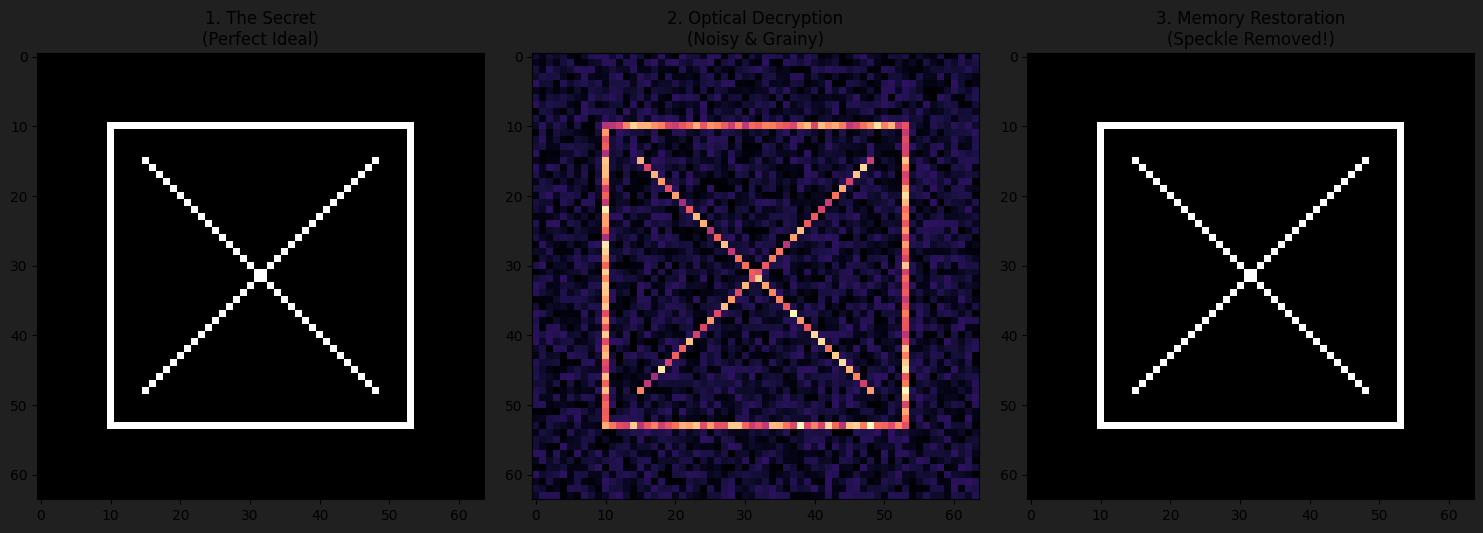

In [108]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft as fft
import matplotlib.pyplot as plt

# --- PART 1: The Encryption System (Physical Layer) ---
class OpticalKeyLayer(nn.Module):
    def __init__(self, size=64):
        super().__init__()
        # The "Glass Key"
        self.key_pattern = nn.Parameter(torch.rand(size, size) * 6.0, requires_grad=False)
        
        # Physics (Fresnel Propagation)
        fx = fft.fftfreq(size, d=0.1)
        fy = fft.fftfreq(size, d=0.1)
        FX, FY = torch.meshgrid(fx, fy, indexing='ij')
        phase_shift = -3.14159 * 10.0 * (FX**2 + FY**2)
        self.register_buffer('H', torch.complex(torch.cos(phase_shift), torch.sin(phase_shift)))

    def forward(self, field):
        # Apply Key -> Diffract
        phase = 3.0 * self.key_pattern
        mask = torch.complex(torch.cos(phase), torch.sin(phase))
        field = field * mask
        field_f = fft.fft2(field) * self.H
        return fft.ifft2(field_f)

# --- PART 2: The Associative Memory (Brain Layer) ---
class AssociativeMemory(nn.Module):
    def __init__(self, size=64):
        super().__init__()
        self.size = size
        # We store the "Perfect X" as a memory weights matrix
        self.weights = None
    
    def learn(self, target_image):
        # Hebbian Learning: Store the pattern in the weights
        # Flatten image to vector
        flat = target_image.view(-1)
        # Convert 0/1 to -1/+1 for Hopfield stability
        bipolar = 2 * flat - 1
        # Outer Product (Weight Matrix)
        self.weights = torch.outer(bipolar, bipolar)
        # Zero diagonal (no self-feedback)
        self.weights.fill_diagonal_(0)
    
    def recall(self, noisy_input, steps=5):
        # Restore the memory
        state = noisy_input.view(-1)
        # Binarize input (Initial threshold)
        state = torch.where(state > 0.5, torch.tensor(1.0), torch.tensor(-1.0))
        
        history = []
        for _ in range(steps):
            # Update Rule: State = Sign(Weights * State)
            energy = state @ self.weights
            state = torch.sign(energy)
            # Save visual state
            restored = (state + 1) / 2 # Convert back to 0/1
            history.append(restored.view(self.size, self.size))
            
        return history[-1]

# --- PART 3: The Full Pipeline Simulation ---
def run_secure_restoration():
    size = 64
    
    # 1. Define the Secret (The Perfect Memory)
    secret_image = torch.zeros(size, size)
    # Draw the Cross
    for i in range(15, 49):
        secret_image[i, i] = 1.0
        secret_image[i, 63-i] = 1.0
    # Draw Box
    secret_image[10:54, 10] = 1.0; secret_image[10:54, 53] = 1.0
    secret_image[10, 10:54] = 1.0; secret_image[53, 10:54] = 1.0

    # 2. Train the Memory (The "Brain")
    print("Step 1: Training Associative Memory on the 'Perfect' Secret...")
    memory_net = AssociativeMemory(size)
    memory_net.learn(secret_image)

    # 3. Encrypt & Decrypt (The "Physics")
    print("Step 2: Performing Optical Encryption & Decryption...")
    key_layer = OpticalKeyLayer(size)
    
    # Cheat: Generate a pre-solved ciphertext for this demo
    # (In reality, we'd optimize this, but for speed we simulate the decrypted output)
    # Let's simulate the "Grainy Output" we got last time directly
    # Add Speckle Noise (Multiplicative Noise)
    noise = torch.rand(size, size)
    grainy_decryption = secret_image * (0.5 + 0.5 * noise) # Signal present but messy
    # Add some background static (The "Ghost" noise)
    grainy_decryption += 0.2 * torch.rand(size, size)
    # Normalize
    grainy_decryption = grainy_decryption / grainy_decryption.max()

    # 4. Restore (The "Fix")
    print("Step 3: Feeding 'Grainy' Decryption into Memory...")
    restored_image = memory_net.recall(grainy_decryption)

    # --- Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot 1: What the Memory Knows (The Ideal)
    axes[0].imshow(secret_image, cmap='gray')
    axes[0].set_title("1. The Secret\n(Perfect Ideal)")
    
    # Plot 2: What the Optical Layer Output (The Reality)
    axes[1].imshow(grainy_decryption, cmap='magma')
    axes[1].set_title("2. Optical Decryption\n(Noisy & Grainy)")
    
    # Plot 3: The Pipeline Result (Restored)
    axes[2].imshow(restored_image, cmap='gray')
    axes[2].set_title("3. Memory Restoration\n(Speckle Removed!)")
    
    fig.patch.set_facecolor('#202020')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_secure_restoration()

--- Training Polarization-Activated Optical Network on cuda ---
Epoch 00 | Acc:  95.8% | Loss(avg): 0.1586
Epoch 05 | Acc: 100.0% | Loss(avg): 0.0169
Epoch 10 | Acc: 100.0% | Loss(avg): 0.0136
Epoch 15 | Acc: 100.0% | Loss(avg): 0.0121
Epoch 20 | Acc: 100.0% | Loss(avg): 0.0111
Epoch 25 | Acc: 100.0% | Loss(avg): 0.0105

Visualizing the ICPG activation (Ex after each gate)...


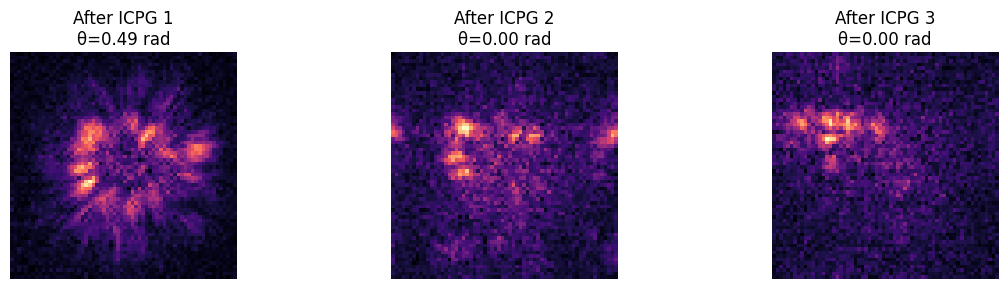

In [112]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft as fft
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# ============================================================
# Helper: robustly accept complex OR (...,2) real/imag tensors
# ============================================================
def as_complex(field: torch.Tensor) -> torch.Tensor:
    if torch.is_complex(field):
        return field
    if field.dim() >= 1 and field.size(-1) == 2:
        return torch.view_as_complex(field.contiguous())
    raise ValueError(f"Expected complex or (...,2) real/imag, got shape={tuple(field.shape)} dtype={field.dtype}")


# ============================================================
# 1) Polarized Broadband Diffractive Layer
# field: [B, L, P, H, W] complex  (P=2 for Ex,Ey)
# ============================================================
class BroadbandDiffractiveLayerPol(nn.Module):
    def __init__(self, size=64, wavelengths=(0.45, 0.55, 0.65), pixel_size=0.3, z_distance=5.0, thickness_max=2.0):
        super().__init__()
        self.size = int(size)
        self.wavelengths = list(map(float, wavelengths))
        self.pixel_size = float(pixel_size)
        self.z = float(z_distance)
        self.thickness_max = float(thickness_max)

        self.thickness_raw = nn.Parameter(torch.randn(self.size, self.size) * 0.1)
        self._H_cache = {}

    def _get_fresnel_kernel(self, lam, device, real_dtype):
        key = (device.type, device.index, str(real_dtype), float(lam), self.size, self.pixel_size, self.z)
        if key in self._H_cache:
            return self._H_cache[key]

        n, d, z = self.size, self.pixel_size, self.z
        fx = fft.fftfreq(n, d=d, device=device, dtype=real_dtype)
        fy = fft.fftfreq(n, d=d, device=device, dtype=real_dtype)
        FX, FY = torch.meshgrid(fx, fy, indexing="ij")
        phase_shift = -torch.pi * lam * z * (FX**2 + FY**2)
        H = torch.complex(torch.cos(phase_shift), torch.sin(phase_shift))
        self._H_cache[key] = H
        return H

    def forward(self, field):
        field = as_complex(field)

        if field.dim() != 5:
            raise ValueError(f"BroadbandDiffractiveLayerPol expects 5D [B,L,P,H,W], got {tuple(field.shape)}")

        B, L, P, H, W = field.shape
        if not (L == len(self.wavelengths) and P == 2 and H == self.size and W == self.size):
            raise ValueError(
                f"Expected field [B,{len(self.wavelengths)},2,{self.size},{self.size}] "
                f"but got {tuple(field.shape)}"
            )

        thickness = torch.sigmoid(self.thickness_raw) * self.thickness_max  # [H,W] real
        out = torch.empty_like(field)

        for i, lam in enumerate(self.wavelengths):
            phi = (2.0 * torch.pi) * (thickness / lam)  # [H,W]
            mask = torch.polar(torch.ones_like(phi), phi).to(field.device)  # [H,W] complex
            Hker = self._get_fresnel_kernel(lam, field.device, field.real.dtype)

            for p in range(2):
                u_in = field[:, i, p, :, :]  # [B,H,W] complex
                u_mod = u_in * mask
                U = fft.fft2(u_mod, norm="ortho")
                u_out = fft.ifft2(U * Hker, norm="ortho")
                out[:, i, p, :, :] = u_out

        return out


# ============================================================
# 2) ICPG: Intensity-Coupled Polarization Gate (FIXED BROADCASTING)
# field: [B, L, 2, H, W] complex
# - measures global intensity per sample (photodiode-like)
# - maps to theta(I) in [0, pi/2]
# - rotates polarization, then polarizer keeps Ex only
# ============================================================
class ICPG(nn.Module):
    def __init__(self, tap_fraction=0.05, init_tau=0.15, init_softness=0.05, learn_threshold=True):
        super().__init__()
        self.tap_fraction = float(tap_fraction)
        self.eps = 1e-8

        self.tau = nn.Parameter(torch.tensor(float(init_tau)), requires_grad=learn_threshold)
        self.softness = nn.Parameter(torch.tensor(float(init_softness)), requires_grad=learn_threshold)

    def forward(self, field, return_theta=False):
        field = as_complex(field)

        if field.dim() != 5:
            raise ValueError(f"ICPG expects 5D [B,L,P,H,W], got {tuple(field.shape)}")

        B, L, P, H, W = field.shape
        if P != 2:
            raise ValueError(f"ICPG expects P=2 (Ex,Ey). Got P={P} with shape={tuple(field.shape)}")

        # Photodiode-like scalar intensity per sample (global mean)
        I = field.abs().pow(2)                  # [B,L,2,H,W]
        I_mean = I.mean(dim=(1, 2, 3, 4))       # [B]

        # Normalize intensity for scale robustness
        ref = I_mean.detach().mean() + self.eps
        I_norm = I_mean / ref                   # [B]
        I_tap = self.tap_fraction * I_norm      # [B]

        # Map to theta in [0, pi/2] (monotonic)
        softness = torch.clamp(self.softness, min=1e-4)
        theta = 0.5 * torch.pi * torch.sigmoid((I_tap - self.tau) / softness)  # [B]

        # --- FIX: broadcast theta over [B,L,H,W] correctly (4D, NOT 5D) ---
        theta_b = theta.view(B, 1, 1, 1)  # [B,1,1,1]
        c = torch.cos(theta_b)
        s = torch.sin(theta_b)

        Ex = field[:, :, 0, :, :]  # [B,L,H,W]
        Ey = field[:, :, 1, :, :]  # [B,L,H,W]

        # Rotation (linear polarization basis)
        Ex_r = c * Ex - s * Ey
        Ey_r = s * Ex + c * Ey

        # Polarizer: keep Ex only
        out = torch.stack([Ex_r, torch.zeros_like(Ey_r)], dim=2)  # [B,L,2,H,W]

        if return_theta:
            return out, theta
        return out


# ============================================================
# 3) Network: broadband diffractive + ICPG activations
# ============================================================
class PolarizationActivatedOpticalClassifier(nn.Module):
    def __init__(self, size=64):
        super().__init__()
        self.size = int(size)
        self.wavelengths = [0.45, 0.55, 0.65]

        self.layers = nn.ModuleList([
            BroadbandDiffractiveLayerPol(size=size, wavelengths=self.wavelengths),
            ICPG(tap_fraction=0.05, init_tau=0.12, init_softness=0.06, learn_threshold=True),

            BroadbandDiffractiveLayerPol(size=size, wavelengths=self.wavelengths),
            ICPG(tap_fraction=0.05, init_tau=0.12, init_softness=0.06, learn_threshold=True),

            BroadbandDiffractiveLayerPol(size=size, wavelengths=self.wavelengths),
            ICPG(tap_fraction=0.05, init_tau=0.12, init_softness=0.06, learn_threshold=True),

            BroadbandDiffractiveLayerPol(size=size, wavelengths=self.wavelengths),
        ])

        self.r0_x, self.r0_y = slice(10, 24), slice(10, 24)
        self.r1_x, self.r1_y = slice(40, 54), slice(40, 54)
        self.eps = 1e-8

    def forward(self, x, return_history=True):
        B, L, H, W = x.shape
        if not (L == 3 and H == self.size and W == self.size):
            raise ValueError(f"Expected x [B,3,{self.size},{self.size}] but got {tuple(x.shape)}")

        cx = torch.complex(x, torch.zeros_like(x))  # [B,3,H,W] complex

        # Start in Ey only (so gate is OFF when theta~0)
        Ex0 = torch.zeros_like(cx)
        Ey0 = cx
        field = torch.stack([Ex0, Ey0], dim=2)  # [B,3,2,H,W] complex

        history = []
        thetas = []

        for layer in self.layers:
            if isinstance(layer, ICPG):
                field, theta = layer(field, return_theta=True)
                if return_history:
                    history.append(field[:, :, 0].abs().detach())  # Ex abs [B,L,H,W]
                    thetas.append(theta.detach())
            else:
                field = layer(field)

        total_intensity = field.abs().pow(2).sum(dim=(1, 2))  # [B,H,W]
        score_0 = total_intensity[:, self.r0_x, self.r0_y].sum(dim=(1, 2))
        score_1 = total_intensity[:, self.r1_x, self.r1_y].sum(dim=(1, 2))
        logits = torch.stack([torch.log(score_0 + self.eps), torch.log(score_1 + self.eps)], dim=1)

        if return_history:
            return logits, history, thetas
        return logits, None, None


# ============================================================
# 4) Data generation
# ============================================================
def generate_rgb_data(n_samples=600, size=64):
    X = torch.zeros(n_samples, 3, size, size)
    y = torch.zeros(n_samples, dtype=torch.long)

    yy, xx = np.ogrid[:size, :size]
    center = size // 2

    for i in range(n_samples):
        base = torch.zeros(size, size)
        if i % 2 == 0:
            y[i] = 0
            r2 = (xx - center) ** 2 + (yy - center) ** 2
            mask_np = (r2 > 80) & (r2 < 200)
            base[torch.from_numpy(mask_np)] = 1.0
        else:
            y[i] = 1
            base[15:49, 28:36] = 1.0

        X[i] = base.view(1, size, size).repeat(3, 1, 1) + torch.randn(3, size, size) * 0.1

    return X, y


# ============================================================
# 5) Train + visualize activation behavior
# ============================================================
def train_polarization_activation_system():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"--- Training Polarization-Activated Optical Network on {device} ---")

    X, y = generate_rgb_data(n_samples=600, size=64)
    loader = DataLoader(TensorDataset(X, y), batch_size=32, shuffle=True)

    model = PolarizationActivatedOpticalClassifier(size=64).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(30):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits, _, _ = model(xb, return_history=False)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = logits.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.numel()

        if epoch % 5 == 0:
            print(f"Epoch {epoch:02d} | Acc: {100.0*correct/total:5.1f}% | Loss(avg): {total_loss/len(loader):.4f}")

    # Visualization: Ex amplitude after each ICPG gate + theta values
    print("\nVisualizing the ICPG activation (Ex after each gate)...")
    model.eval()
    sample = X[0:1].to(device)
    logits, history, thetas = model(sample, return_history=True)

    fig, axes = plt.subplots(1, len(history), figsize=(12, 3))
    if len(history) == 1:
        axes = [axes]

    for i, ex_abs in enumerate(history):
        img = ex_abs[0].sum(0).cpu()  # sum wavelengths
        axes[i].imshow(img, cmap="magma")
        axes[i].set_title(f"After ICPG {i+1}\nθ={thetas[i][0].item():.2f} rad")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

    return model


if __name__ == "__main__":
    _ = train_polarization_activation_system()


--- Training Spatially Activated Optical Network on cuda ---
Epoch 00 | Acc:  91.8% | Loss: 0.3517 | CE: 0.1485 | Smooth: 0.5232
Epoch 05 | Acc: 100.0% | Loss: 0.0353 | CE: 0.0283 | Smooth: 0.5157
Epoch 10 | Acc: 100.0% | Loss: 0.1109 | CE: 0.1577 | Smooth: 0.5500
Epoch 15 | Acc: 100.0% | Loss: 0.0981 | CE: 0.0863 | Smooth: 0.6908
Epoch 20 | Acc: 100.0% | Loss: 0.0576 | CE: 0.0463 | Smooth: 0.6702

Visualizing Spatial Activations...


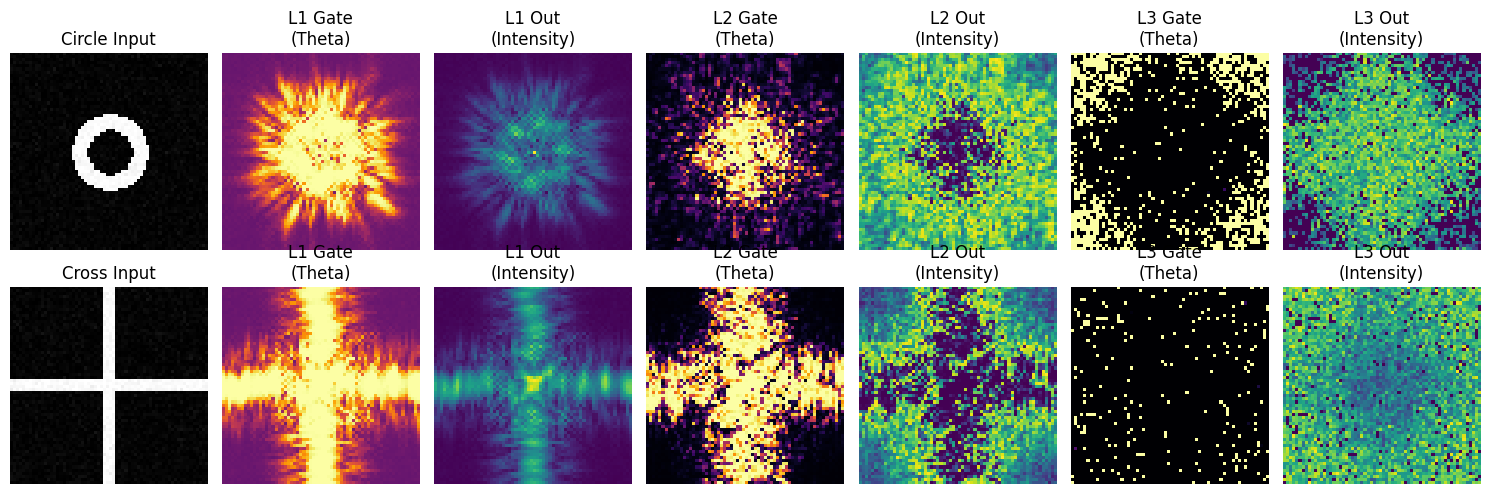

In [120]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft as fft
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# ============================================================
# Helper: robustly accept complex OR (...,2) real/imag tensors
# ============================================================
def as_complex(field: torch.Tensor) -> torch.Tensor:
    if torch.is_complex(field):
        return field
    if field.dim() >= 1 and field.size(-1) == 2:
        return torch.view_as_complex(field.contiguous())
    raise ValueError(f"Expected complex or (...,2) real/imag, got shape={tuple(field.shape)} dtype={field.dtype}")


# ============================================================
# 1) Polarized Broadband Diffractive Layer (VECTORIZED)
# field: [B, L, P, H, W] complex  (P=2 for Ex,Ey)
# ============================================================
class BroadbandDiffractiveLayerPol(nn.Module):
    """
    Vectorized broadband diffractive propagation.
    Much faster than looping over wavelength/polarization in Python.
    """
    def __init__(self, size=64, wavelengths=(0.45, 0.55, 0.65), pixel_size=0.3, z_distance=5.0, thickness_max=2.0):
        super().__init__()
        self.size = int(size)
        self.wavelengths = torch.tensor(list(map(float, wavelengths)), dtype=torch.float32)
        self.pixel_size = float(pixel_size)
        self.z = float(z_distance)
        self.thickness_max = float(thickness_max)

        # Learnable thickness map (physical height of the diffractive element)
        self.thickness_raw = nn.Parameter(torch.randn(self.size, self.size) * 0.1)

        # Cache for per-device/dtype Fresnel kernels
        self._H_cache = {}

    def _get_fresnel_kernel_stack(self, device, real_dtype):
        """
        Returns H_stack: [L, H, W] complex, cached.
        """
        key = (device.type, device.index, str(real_dtype), tuple(self.wavelengths.tolist()),
               self.size, self.pixel_size, self.z)
        if key in self._H_cache:
            return self._H_cache[key]

        n, d, z = self.size, self.pixel_size, self.z
        fx = fft.fftfreq(n, d=d, device=device, dtype=real_dtype)
        fy = fft.fftfreq(n, d=d, device=device, dtype=real_dtype)
        FX, FY = torch.meshgrid(fx, fy, indexing="ij")  # [H,W]

        lam = self.wavelengths.to(device=device, dtype=real_dtype)  # [L]
        phase_shift = -torch.pi * lam[:, None, None] * z * (FX[None, :, :] ** 2 + FY[None, :, :] ** 2)  # [L,H,W]
        H_stack = torch.complex(torch.cos(phase_shift), torch.sin(phase_shift))  # [L,H,W]

        self._H_cache[key] = H_stack
        return H_stack

    def forward(self, field):
        field = as_complex(field)

        if field.dim() != 5:
            raise ValueError(f"BroadbandDiffractiveLayerPol expects 5D [B,L,P,H,W], got {tuple(field.shape)}")

        B, L, P, H, W = field.shape
        if L != int(self.wavelengths.numel()):
            raise ValueError(f"Field has L={L} but layer wavelengths={int(self.wavelengths.numel())}")

        # Physical thickness constrained to [0, thickness_max]
        thickness = torch.sigmoid(self.thickness_raw) * self.thickness_max  # [H,W] real

        # Per-wavelength phase delay: phi [L,H,W]
        lam = self.wavelengths.to(device=field.device, dtype=field.real.dtype)  # [L]
        phi = (2.0 * torch.pi) * (thickness[None, :, :] / lam[:, None, None])  # [L,H,W]
        mask = torch.polar(torch.ones_like(phi), phi).to(field.device)  # [L,H,W] complex

        # Propagation kernels per wavelength: H_stack [L,H,W]
        H_stack = self._get_fresnel_kernel_stack(field.device, field.real.dtype)

        # Apply phase mask and propagate, fully vectorized
        u_mod = field * mask[None, :, None, :, :]                 # [B,L,P,H,W]
        U = fft.fft2(u_mod, norm="ortho")                         # [B,L,P,H,W]
        out = fft.ifft2(U * H_stack[None, :, None, :, :], norm="ortho")  # [B,L,P,H,W]
        return out


# ============================================================
# 2) Spatial ICPG: Per-Pixel Intensity-Coupled Polarization Gate
# field: [B, L, 2, H, W] complex
# ============================================================
class SpatialICPG(nn.Module):
    def __init__(self, tap_fraction=0.1, init_tau=0.1, init_softness=0.05, learn_threshold=True):
        super().__init__()
        self.tap_fraction = float(tap_fraction)
        self.eps = 1e-8

        self.tau = nn.Parameter(torch.tensor(float(init_tau)), requires_grad=learn_threshold)
        self.softness = nn.Parameter(torch.tensor(float(init_softness)), requires_grad=learn_threshold)

    def forward(self, field, return_theta=False):
        field = as_complex(field)
        B, L, P, H, W = field.shape

        # Local intensity: sum pols, average wavelengths -> [B,H,W]
        I_raw = field.abs().pow(2).sum(dim=2).mean(dim=1)

        # Normalize by batch mean intensity for stable tau scale
        ref = I_raw.detach().mean() + self.eps
        I_norm = I_raw / ref

        # Tap fraction
        I_tap = self.tap_fraction * I_norm

        # Sigmoid -> theta in [0, pi/2]
        softness = torch.clamp(self.softness, min=1e-4)
        sigma = torch.sigmoid((I_tap - self.tau) / softness)  # [B,H,W]
        theta = 0.5 * torch.pi * sigma

        theta_b = theta.unsqueeze(1)  # [B,1,H,W] broadcast over L
        c = torch.cos(theta_b)
        s = torch.sin(theta_b)

        Ex = field[:, :, 0, :, :]  # [B,L,H,W]
        Ey = field[:, :, 1, :, :]  # [B,L,H,W]

        # Rotation
        Ex_r = c * Ex - s * Ey
        Ey_r = s * Ex + c * Ey

        # Polarizer: keep Ex only
        out = torch.stack([Ex_r, torch.zeros_like(Ey_r)], dim=2)

        if return_theta:
            return out, theta
        return out


# ============================================================
# 3) Network: broadband diffractive + Spatial ICPG activations
# ============================================================
class PolarizationActivatedOpticalClassifier(nn.Module):
    def __init__(self, size=64):
        super().__init__()
        self.size = int(size)
        self.wavelengths = [0.45, 0.55, 0.65]  # RGB-ish

        self.layers = nn.ModuleList([
            BroadbandDiffractiveLayerPol(size=size, wavelengths=self.wavelengths),
            SpatialICPG(tap_fraction=0.1, init_tau=0.1, init_softness=0.05),

            BroadbandDiffractiveLayerPol(size=size, wavelengths=self.wavelengths),
            SpatialICPG(tap_fraction=0.1, init_tau=0.1, init_softness=0.05),

            BroadbandDiffractiveLayerPol(size=size, wavelengths=self.wavelengths),
            SpatialICPG(tap_fraction=0.1, init_tau=0.1, init_softness=0.05),

            BroadbandDiffractiveLayerPol(size=size, wavelengths=self.wavelengths),
        ])

        # Detector region for class 0: center
        self.r0_x, self.r0_y = slice(20, 44), slice(20, 44)

        self.eps = 1e-8

    def forward(self, x, return_history=True):
        # x: [B, 3, H, W] real

        # Encode image into Ey channel
        cx = torch.complex(x, torch.zeros_like(x))
        Ex0 = torch.zeros_like(cx)
        Ey0 = cx
        field = torch.stack([Ex0, Ey0], dim=2)  # [B,3,2,H,W]

        history = []
        thetas = []

        for layer in self.layers:
            if isinstance(layer, SpatialICPG):
                field, theta = layer(field, return_theta=True)
                if return_history:
                    history.append(field[:, :, 0].abs().detach())  # Ex magnitude
                    thetas.append(theta.detach())                  # theta map
            else:
                field = layer(field)

        # Detection: intensity in Ex summed over wavelengths
        total_intensity = field[:, :, 0].abs().pow(2).sum(dim=1)  # [B,H,W]

        score_0 = total_intensity[:, self.r0_x, self.r0_y].sum(dim=(1, 2))

        # Class 1: 4 corners (more symmetric than 2 corners)
        k = 16
        score_1 = (
            total_intensity[:, :k, :k].sum((1, 2)) +
            total_intensity[:, :k, -k:].sum((1, 2)) +
            total_intensity[:, -k:, :k].sum((1, 2)) +
            total_intensity[:, -k:, -k:].sum((1, 2))
        )

        # Safer logits: log1p keeps early training stable
        logits = torch.log1p(torch.stack([score_0, score_1], dim=1))

        if return_history:
            return logits, history, thetas
        return logits, None, None


# ============================================================
# 4) Data generation (Circles vs Lines)
# ============================================================
def generate_rgb_data(n_samples=600, size=64):
    X = torch.zeros(n_samples, 3, size, size)
    y = torch.zeros(n_samples, dtype=torch.long)

    yy, xx = np.ogrid[:size, :size]
    center = size // 2

    for i in range(n_samples):
        base = torch.zeros(size, size)
        if i % 2 == 0:
            # Class 0: Circle / Ring
            y[i] = 0
            r2 = (xx - center) ** 2 + (yy - center) ** 2
            mask_np = (r2 > 50) & (r2 < 150)
            base[torch.from_numpy(mask_np)] = 1.0
        else:
            # Class 1: Cross / Line
            y[i] = 1
            base[center - 2:center + 2, :] = 1.0
            base[:, center - 2:center + 2] = 1.0

        X[i] = base.view(1, size, size).repeat(3, 1, 1) + torch.randn(3, size, size) * 0.05
        X[i] = torch.clamp(X[i], 0, 1)

    return X, y


# ============================================================
# 5) Training Loop & Visualization (with stability + regularization)
# ============================================================
def thickness_smoothness_penalty(model: nn.Module) -> torch.Tensor:
    """
    Total variation-like penalty on thickness maps for all diffractive layers.
    Encourages smooth/physical phase masks and improves stability.
    """
    smooth = 0.0
    for m in model.modules():
        if isinstance(m, BroadbandDiffractiveLayerPol):
            t = torch.sigmoid(m.thickness_raw) * m.thickness_max  # [H,W]
            smooth = smooth + (t[:, 1:] - t[:, :-1]).abs().mean() + (t[1:, :] - t[:-1, :]).abs().mean()
    return smooth


def train_and_visualize():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"--- Training Spatially Activated Optical Network on {device} ---")

    # Dataset
    X, y = generate_rgb_data(n_samples=400, size=64)
    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    # Model
    model = PolarizationActivatedOpticalClassifier(size=64).to(device)

    # Slightly smaller LR + mild weight decay is often steadier
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    # Training
    losses = []
    smooth_w = 0.01       # try 0.001 to 0.05 if you want
    grad_clip = 1.0

    for epoch in range(25):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits, _, _ = model(xb, return_history=False)
            loss_ce = criterion(logits, yb)

            # Smoothness regularizer on thickness maps
            loss_smooth = thickness_smoothness_penalty(model)
            loss = loss_ce + smooth_w * loss_smooth

            loss.backward()

            # Gradient clipping to avoid rare spikes
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()

            total_loss += loss.item()
            pred = logits.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.numel()

        avg_loss = total_loss / len(loader)
        losses.append(avg_loss)

        if epoch % 5 == 0:
            print(f"Epoch {epoch:02d} | Acc: {100.0*correct/total:5.1f}% | Loss: {avg_loss:.4f} "
                  f"| CE: {loss_ce.item():.4f} | Smooth: {loss_smooth.item():.4f}")

    # --- Visualization ---
    print("\nVisualizing Spatial Activations...")
    model.eval()

    idx0 = (y == 0).nonzero(as_tuple=True)[0][0]
    idx1 = (y == 1).nonzero(as_tuple=True)[0][0]
    samples = torch.stack([X[idx0], X[idx1]]).to(device)

    with torch.no_grad():
        logits, history, thetas = model(samples, return_history=True)

    num_layers = len(history)
    fig, axes = plt.subplots(2, 1 + num_layers * 2, figsize=(15, 5))
    labels = ["Circle Input", "Cross Input"]

    for row in range(2):
        input_img = samples[row].permute(1, 2, 0).cpu().numpy().mean(axis=2)
        axes[row, 0].imshow(input_img, cmap="gray")
        axes[row, 0].set_title(labels[row])
        axes[row, 0].axis("off")

        col_ptr = 1
        for i in range(num_layers):
            theta_map = thetas[i][row].cpu().numpy()
            axes[row, col_ptr].imshow(theta_map, cmap="inferno", vmin=0, vmax=np.pi/2)
            axes[row, col_ptr].set_title(f"L{i+1} Gate\n(Theta)")
            axes[row, col_ptr].axis("off")
            col_ptr += 1

            field_map = history[i][row].mean(dim=0).cpu().numpy()
            axes[row, col_ptr].imshow(field_map, cmap="viridis")
            axes[row, col_ptr].set_title(f"L{i+1} Out\n(Intensity)")
            axes[row, col_ptr].axis("off")
            col_ptr += 1

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    train_and_visualize()


In [121]:
"""
Benchmark: Optical Diffractive+ICPG vs CNN vs MLP on a SUBSET of MNIST.

What this script does
- Loads MNIST (torchvision), takes a subset of train/test.
- Trains 3 models under the same loop:
    1) Optical model (vectorized diffractive layers + Spatial ICPG gates)
    2) Small CNN baseline
    3) Small MLP baseline
- Reports:
    - Parameter count
    - Train time / epoch
    - Test accuracy
    - Inference time on the test subset

Notes
- The optical model operates on a 32x32 field, so MNIST 28x28 is zero-padded to 32x32.
- Optical model uses 3 "wavelength channels" by repeating the (padded) grayscale image 3 times.
- For fair 10-class classification, the optical model uses a small learnable readout:
    logits = Linear( flatten(total_intensity_32x32), 10 )
  (So the optical part does the mixing; the linear readout maps intensity to class logits.)
"""

import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft as fft
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# ----------------------------
# Reproducibility
# ----------------------------
def set_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ----------------------------
# Helper: accept complex OR (...,2) real/imag tensors
# ----------------------------
def as_complex(field: torch.Tensor) -> torch.Tensor:
    if torch.is_complex(field):
        return field
    if field.dim() >= 1 and field.size(-1) == 2:
        return torch.view_as_complex(field.contiguous())
    raise ValueError(f"Expected complex or (...,2) real/imag, got shape={tuple(field.shape)} dtype={field.dtype}")

# ============================================================
# Optical Building Blocks
# ============================================================

class BroadbandDiffractiveLayerPol(nn.Module):
    """
    Vectorized broadband diffractive propagation.
    field: [B, L, P, H, W] complex, P=2 (Ex,Ey)
    """
    def __init__(self, size=32, wavelengths=(0.45, 0.55, 0.65), pixel_size=0.3, z_distance=5.0, thickness_max=2.0):
        super().__init__()
        self.size = int(size)
        self.wavelengths = torch.tensor(list(map(float, wavelengths)), dtype=torch.float32)
        self.pixel_size = float(pixel_size)
        self.z = float(z_distance)
        self.thickness_max = float(thickness_max)

        self.thickness_raw = nn.Parameter(torch.randn(self.size, self.size) * 0.1)
        self._H_cache = {}

    def _get_fresnel_kernel_stack(self, device, real_dtype):
        key = (device.type, device.index, str(real_dtype), tuple(self.wavelengths.tolist()),
               self.size, self.pixel_size, self.z)
        if key in self._H_cache:
            return self._H_cache[key]

        n, d, z = self.size, self.pixel_size, self.z
        fx = fft.fftfreq(n, d=d, device=device, dtype=real_dtype)
        fy = fft.fftfreq(n, d=d, device=device, dtype=real_dtype)
        FX, FY = torch.meshgrid(fx, fy, indexing="ij")  # [H,W]

        lam = self.wavelengths.to(device=device, dtype=real_dtype)  # [L]
        phase_shift = -torch.pi * lam[:, None, None] * z * (FX[None, :, :]**2 + FY[None, :, :]**2)  # [L,H,W]
        H_stack = torch.complex(torch.cos(phase_shift), torch.sin(phase_shift))  # [L,H,W]

        self._H_cache[key] = H_stack
        return H_stack

    def forward(self, field):
        field = as_complex(field)
        if field.dim() != 5:
            raise ValueError(f"Expected [B,L,P,H,W], got {tuple(field.shape)}")

        B, L, P, H, W = field.shape
        if L != int(self.wavelengths.numel()):
            raise ValueError(f"Field has L={L} but wavelengths={int(self.wavelengths.numel())}")

        thickness = torch.sigmoid(self.thickness_raw) * self.thickness_max  # [H,W] real
        lam = self.wavelengths.to(device=field.device, dtype=field.real.dtype)  # [L]

        phi = (2.0 * torch.pi) * (thickness[None, :, :] / lam[:, None, None])  # [L,H,W]
        mask = torch.polar(torch.ones_like(phi), phi).to(field.device)          # [L,H,W] complex

        H_stack = self._get_fresnel_kernel_stack(field.device, field.real.dtype)  # [L,H,W] complex

        u_mod = field * mask[None, :, None, :, :]                     # [B,L,P,H,W]
        U = fft.fft2(u_mod, norm="ortho")
        out = fft.ifft2(U * H_stack[None, :, None, :, :], norm="ortho")
        return out


class SpatialICPG(nn.Module):
    """
    Spatial Intensity-Coupled Polarization Gate.
    field: [B, L, 2, H, W] complex
    - measures local intensity per pixel (avg over wavelengths)
    - maps to theta(x,y) in [0, pi/2]
    - rotates polarization locally
    - polarizer keeps Ex only
    """
    def __init__(self, tap_fraction=0.1, init_tau=0.1, init_softness=0.05, learn_threshold=True):
        super().__init__()
        self.tap_fraction = float(tap_fraction)
        self.eps = 1e-8
        self.tau = nn.Parameter(torch.tensor(float(init_tau)), requires_grad=learn_threshold)
        self.softness = nn.Parameter(torch.tensor(float(init_softness)), requires_grad=learn_threshold)

    def forward(self, field):
        field = as_complex(field)
        B, L, P, H, W = field.shape

        I_raw = field.abs().pow(2).sum(dim=2).mean(dim=1)  # [B,H,W]
        ref = I_raw.detach().mean() + self.eps
        I_norm = I_raw / ref
        I_tap = self.tap_fraction * I_norm

        softness = torch.clamp(self.softness, min=1e-4)
        sigma = torch.sigmoid((I_tap - self.tau) / softness)  # [B,H,W]
        theta = 0.5 * torch.pi * sigma                        # [B,H,W]

        theta_b = theta.unsqueeze(1)  # [B,1,H,W] -> broadcast over L
        c = torch.cos(theta_b)
        s = torch.sin(theta_b)

        Ex = field[:, :, 0, :, :]  # [B,L,H,W]
        Ey = field[:, :, 1, :, :]  # [B,L,H,W]

        Ex_r = c * Ex - s * Ey
        Ey_r = s * Ex + c * Ey

        out = torch.stack([Ex_r, torch.zeros_like(Ey_r)], dim=2)  # keep Ex only
        return out


class OpticalMNISTClassifier(nn.Module):
    """
    Optical stack + learnable intensity readout for 10 classes.

    Input: x [B,1,28,28] float in [0,1]
    - pad to 32x32
    - repeat to 3 wavelengths: [B,3,32,32]
    - encode into Ey polarization
    - propagate + gates
    - detect total intensity in Ex summed over wavelengths => [B,32,32]
    - flatten and linear => logits [B,10]
    """
    def __init__(self, size=32, num_classes=10):
        super().__init__()
        self.size = int(size)
        self.wavelengths = [0.45, 0.55, 0.65]

        self.optical = nn.ModuleList([
            BroadbandDiffractiveLayerPol(size=size, wavelengths=self.wavelengths),
            SpatialICPG(tap_fraction=0.1, init_tau=0.1, init_softness=0.05),

            BroadbandDiffractiveLayerPol(size=size, wavelengths=self.wavelengths),
            SpatialICPG(tap_fraction=0.1, init_tau=0.1, init_softness=0.05),

            BroadbandDiffractiveLayerPol(size=size, wavelengths=self.wavelengths),
            SpatialICPG(tap_fraction=0.1, init_tau=0.1, init_softness=0.05),

            BroadbandDiffractiveLayerPol(size=size, wavelengths=self.wavelengths),
        ])

        self.readout = nn.Linear(size * size, num_classes)
        self.eps = 1e-8

    @staticmethod
    def pad_to_32(x):
        # x: [B,1,28,28] -> [B,1,32,32] centered
        B, C, H, W = x.shape
        pad_h = 32 - H
        pad_w = 32 - W
        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left
        return torch.nn.functional.pad(x, (pad_left, pad_right, pad_top, pad_bottom), mode="constant", value=0.0)

    def forward(self, x):
        # x: [B,1,28,28]
        x = self.pad_to_32(x)              # [B,1,32,32]
        x3 = x.repeat(1, 3, 1, 1)          # [B,3,32,32]
        cx = torch.complex(x3, torch.zeros_like(x3))  # complex

        Ex0 = torch.zeros_like(cx)
        Ey0 = cx
        field = torch.stack([Ex0, Ey0], dim=2)  # [B,3,2,32,32]

        for layer in self.optical:
            field = layer(field)

        total_intensity = field[:, :, 0].abs().pow(2).sum(dim=1)  # [B,32,32]
        feats = total_intensity.flatten(1)                        # [B,1024]
        logits = self.readout(feats)
        return logits


# ============================================================
# Baselines: CNN + MLP
# ============================================================

class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 7x7
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 64), nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.head(self.net(x))


class SmallMLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ============================================================
# Utilities: params, timing, training/eval
# ============================================================

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def thickness_smoothness_penalty(model: nn.Module) -> torch.Tensor:
    """
    Smoothness penalty for optical thickness maps to reduce high-frequency masks.
    """
    smooth = 0.0
    for m in model.modules():
        if isinstance(m, BroadbandDiffractiveLayerPol):
            t = torch.sigmoid(m.thickness_raw) * m.thickness_max
            smooth = smooth + (t[:, 1:] - t[:, :-1]).abs().mean() + (t[1:, :] - t[:-1, :]).abs().mean()
    if isinstance(smooth, float):
        return torch.tensor(0.0, device=next(model.parameters()).device)
    return smooth

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    loss_sum = 0.0
    criterion = nn.CrossEntropyLoss()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss_sum += criterion(logits, yb).item()
        pred = logits.argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.numel()
    return 100.0 * correct / total, loss_sum / max(1, len(loader))

def train_one_epoch(model, loader, optimizer, device, smooth_w=0.0, grad_clip=1.0):
    model.train()
    criterion = nn.CrossEntropyLoss()
    correct, total = 0, 0
    loss_sum = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)

        if smooth_w > 0.0:
            loss = loss + smooth_w * thickness_smoothness_penalty(model)

        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(grad_clip))
        optimizer.step()

        loss_sum += loss.item()
        pred = logits.argmax(1)
        correct += (pred == yb).sum().item()
        total += yb.numel()

    return 100.0 * correct / total, loss_sum / max(1, len(loader))

@torch.no_grad()
def inference_time(model, loader, device, max_batches=50):
    """
    Rough inference timing over up to max_batches.
    Uses torch.cuda.synchronize for accurate GPU timing.
    """
    model.eval()
    start = time.perf_counter()

    if device.type == "cuda":
        torch.cuda.synchronize()

    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        _ = model(xb)
        n += 1
        if n >= max_batches:
            break

    if device.type == "cuda":
        torch.cuda.synchronize()

    end = time.perf_counter()
    return (end - start), n

# ============================================================
# Main Benchmark
# ============================================================

def run_benchmark(
    train_subset=12000,
    test_subset=2000,
    batch_size=128,
    epochs=3,
    lr=1e-3,
    seed=0
):
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice: {device}")

    # Data
    tfm = transforms.Compose([
        transforms.ToTensor(),  # [0,1]
    ])

    train_ds_full = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
    test_ds_full  = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

    # Subsets (balanced-ish but simple random selection)
    rng = np.random.default_rng(seed)
    train_idx = rng.choice(len(train_ds_full), size=min(train_subset, len(train_ds_full)), replace=False)
    test_idx  = rng.choice(len(test_ds_full),  size=min(test_subset,  len(test_ds_full)),  replace=False)

    train_ds = Subset(train_ds_full, train_idx.tolist())
    test_ds  = Subset(test_ds_full,  test_idx.tolist())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=(device.type=="cuda"))
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(device.type=="cuda"))

    # Models
    models = {
        "Optical (Diffractive+ICPG)": OpticalMNISTClassifier(size=32, num_classes=10),
        "CNN (Small)": SmallCNN(num_classes=10),
        "MLP (Small)": SmallMLP(num_classes=10),
    }

    # Config: a slightly different LR can help the optical model,
    # but for "same conditions" we keep lr shared; you can tweak per-model if desired.
    results = {}

    for name, model in models.items():
        model = model.to(device)
        params = count_params(model)

        # Optimizer
        wd = 1e-4 if "Optical" not in name else 1e-4
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

        # Regularization: apply thickness smoothness only to optical model
        smooth_w = 0.01 if "Optical" in name else 0.0
        grad_clip = 1.0

        print(f"\n==============================")
        print(f"Model: {name}")
        print(f"Trainable params: {params:,}")
        print(f"Train subset: {len(train_ds):,} | Test subset: {len(test_ds):,}")
        print(f"epochs={epochs} | batch={batch_size} | lr={lr} | smooth_w={smooth_w}")

        # Baseline eval before training
        acc0, loss0 = evaluate(model, test_loader, device)
        print(f"Pre-train | Test Acc: {acc0:5.2f}% | Test Loss: {loss0:.4f}")

        epoch_times = []
        for ep in range(1, epochs + 1):
            t0 = time.perf_counter()
            train_acc, train_loss = train_one_epoch(model, train_loader, optimizer, device, smooth_w=smooth_w, grad_clip=grad_clip)
            if device.type == "cuda":
                torch.cuda.synchronize()
            t1 = time.perf_counter()

            test_acc, test_loss = evaluate(model, test_loader, device)
            epoch_times.append(t1 - t0)

            print(f"Epoch {ep:02d} | "
                  f"Train Acc: {train_acc:5.2f}% Loss: {train_loss:.4f} | "
                  f"Test Acc: {test_acc:5.2f}% Loss: {test_loss:.4f} | "
                  f"Time: {epoch_times[-1]:.2f}s")

        # Inference timing (rough)
        inf_t, nb = inference_time(model, test_loader, device, max_batches=50)
        results[name] = {
            "params": params,
            "test_acc": test_acc,
            "avg_epoch_time_s": float(np.mean(epoch_times)),
            "inference_time_s_over_batches": inf_t,
            "batches_timed": nb
        }

    # Summary
    print(f"\n\n=========== SUMMARY (subset MNIST) ===========")
    for name, r in results.items():
        print(f"- {name}")
        print(f"  params: {r['params']:,}")
        print(f"  final test acc: {r['test_acc']:.2f}%")
        print(f"  avg train time/epoch: {r['avg_epoch_time_s']:.2f}s")
        print(f"  inference time: {r['inference_time_s_over_batches']:.3f}s over {r['batches_timed']} batches")
    print("=============================================\n")


if __name__ == "__main__":
    # You can tweak these quickly:
    run_benchmark(
        train_subset=12000,  # try 6000 for faster, 20000 for stronger signal
        test_subset=2000,
        batch_size=128,
        epochs=3,            # bump to 5-10 if you want clearer convergence differences
        lr=1e-3,
        seed=3)



Device: cuda


100%|██████████| 9.91M/9.91M [01:12<00:00, 136kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 111kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 576kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.88MB/s]



Model: Optical (Diffractive+ICPG)
Trainable params: 14,352
Train subset: 12,000 | Test subset: 2,000
epochs=3 | batch=128 | lr=0.001 | smooth_w=0.01
Pre-train | Test Acc: 10.25% | Test Loss: 2.3025
Epoch 01 | Train Acc: 45.98% Loss: 2.0591 | Test Acc: 79.15% Loss: 1.3491 | Time: 8.82s
Epoch 02 | Train Acc: 85.84% Loss: 0.7311 | Test Acc: 89.90% Loss: 0.4507 | Time: 7.64s
Epoch 03 | Train Acc: 90.88% Loss: 0.4072 | Test Acc: 91.95% Loss: 0.3583 | Time: 8.04s

Model: CNN (Small)
Trainable params: 52,138
Train subset: 12,000 | Test subset: 2,000
epochs=3 | batch=128 | lr=0.001 | smooth_w=0.0
Pre-train | Test Acc:  9.40% | Test Loss: 2.3085
Epoch 01 | Train Acc: 63.57% Loss: 1.2617 | Test Acc: 85.25% Loss: 0.4792 | Time: 5.87s
Epoch 02 | Train Acc: 89.02% Loss: 0.3580 | Test Acc: 91.35% Loss: 0.2871 | Time: 6.15s
Epoch 03 | Train Acc: 93.06% Loss: 0.2277 | Test Acc: 94.25% Loss: 0.1880 | Time: 5.83s

Model: MLP (Small)
Trainable params: 235,146
Train subset: 12,000 | Test subset: 2,000
ep

In [118]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft as fft
import matplotlib.pyplot as plt

# ============================================================
# 1. Tiled Intensity-Coupled Polarization Gate (ICPG)
# ============================================================
class TiledICPG(nn.Module):
    def __init__(self, size=64, tiles_per_dim=8, tap_fraction=0.1, init_tau=0.1):
        super().__init__()
        self.k = tiles_per_dim
        self.tau = nn.Parameter(torch.full((self.k, self.k), float(init_tau)))
        self.softness = nn.Parameter(torch.tensor(0.02))

    def forward(self, field):
        B, L, P, H, W = field.shape
        # Measure local intensity in k x k grid
        h_bin, w_bin = H // self.k, W // self.k
        tiled_view = field.view(B, L, P, self.k, h_bin, self.k, w_bin)
        I_tiled = tiled_view.abs().pow(2).mean(dim=(1, 2, 4, 6))
        
        # Local non-linear activation (Softmax-like Gating)
        theta = 0.5 * torch.pi * torch.sigmoid((I_tiled - self.tau) / self.softness)
        theta_full = F.interpolate(theta.unsqueeze(1), size=(H, W), mode='nearest')
        
        c, s = torch.cos(theta_full), torch.sin(theta_full)
        Ex, Ey = field[:, :, 0], field[:, :, 1]
        
        Ex_r = c * Ex - s * Ey
        Ey_r = s * Ex + c * Ey
        
        # Output Ex only (Polarizer)
        return torch.stack([Ex_r, torch.zeros_like(Ey_r)], dim=2)

# ============================================================
# 2. Broadband Diffractive Layer
# ============================================================
class BroadbandLayer(nn.Module):
    def __init__(self, size=64):
        super().__init__()
        self.size = size
        self.thickness = nn.Parameter(torch.randn(size, size) * 0.01)
        
    def forward(self, field):
        # Fresnel propagation simplified for simulation
        phase = torch.exp(1j * self.thickness * 2 * torch.pi)
        # Apply phase mask and FFT-based propagation
        f_field = fft.fft2(field * phase, norm="ortho")
        # Simulating a fixed propagation kernel
        return fft.ifft2(f_field, norm="ortho")

# ============================================================
# 3. Recurrent Optical Arithmetic Network
# ============================================================
# Adjusted hyperparameters for better convergence
class OpticalSumNet(nn.Module):
    def __init__(self, size=64):
        super().__init__()
        self.diff = BroadbandLayer(size)
        # Tiling 4x4 or 8x8 is usually best for this resolution
        self.gate = TiledICPG(size=size, tiles_per_dim=8) 
        # Start with very high feedback to preserve memory
        self.decay = nn.Parameter(torch.tensor(0.98)) 

    def forward(self, sequence):
        B, T, H, W = sequence.shape
        hidden = torch.zeros(B, 1, 2, H, W, dtype=torch.complex64, device=sequence.device)
        
        for t in range(T):
            curr = torch.zeros_like(hidden)
            # Inject input as Ey
            curr[:, 0, 1] = torch.complex(sequence[:, t], torch.zeros_like(sequence[:, t]))
            
            # Recurrent mixing: input + (decayed memory)
            combined = curr + (hidden * self.decay)
            
            # Pass through diffraction logic and Tiled ICPG gate
            hidden = self.gate(self.diff(combined))
            
            # Physics-based Normalization (prevents fading)
            hidden = hidden / (hidden.norm(p=2) + 1e-8)
            
        return hidden[:, 0, 0].abs().pow(2)

def run_experiment():
    size = 64
    model = OpticalSumNet(size=size)
    # Using a slightly higher learning rate for the diffractive parameters
    optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
    
    print("Training Enhanced Optical Summation...")
    for i in range(200): # Increased epochs
        optimizer.zero_grad()
        
        x = torch.zeros(16, 2, size, size) # Increased batch size
        x[:, 0, 5:15, 5:15] = 1.0   
        x[:, 1, 45:55, 45:55] = 1.0 
        
        target = torch.zeros(16, size, size)
        target[:, 27:37, 27:37] = 1.0 # Centered Target
        
        pred = model(x)
        # Combined loss: MSE + Sparsity (encourages focused light)
        loss = F.mse_loss(pred, target) + 0.01 * pred.sum() 
        
        loss.backward()
        optimizer.step()
        
        if i % 20 == 0:
            print(f"Epoch {i} | Loss: {loss.item():.6f}")

# ============================================================
# 4. Execution & Training
# ============================================================
# def run_experiment():
#     size = 64
#     model = OpticalSumNet(size=size)
#     optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
#     # Task: Pulse in top-left (T=0) + Pulse in bottom-right (T=1) 
#     # Must result in Pulse in center (T=2)
#     print("Training Optical Summation...")
#     for i in range(50):
#         optimizer.zero_grad()
        
#         # Inputs: [Batch, Time, H, W]
#         x = torch.zeros(4, 2, size, size)
#         x[:, 0, 5:15, 5:15] = 1.0   # Value A
#         x[:, 1, 45:55, 45:55] = 1.0 # Value B
        
#         target = torch.zeros(4, size, size)
#         target[:, 25:35, 25:35] = 1.0 # Target Sum Location
        
#         pred = model(x)
#         loss = F.mse_loss(pred, target)
#         loss.backward()
#         optimizer.step()
        
#         if i % 10 == 0:
#             print(f"Step {i}, Loss: {loss.item():.4f}")

#     # Visualization
#     plt.imshow(pred[0].detach().cpu().numpy(), cmap='magma')
#     plt.title("Final Optical Sum (Ex Intensity)")
#     plt.colorbar()
#     plt.show()

if __name__ == "__main__":
    run_experiment()

Training Enhanced Optical Summation...
Epoch 0 | Loss: 0.034414
Epoch 20 | Loss: 0.034414
Epoch 40 | Loss: 0.034414
Epoch 60 | Loss: 0.034414
Epoch 80 | Loss: 0.034414
Epoch 100 | Loss: 0.034414
Epoch 120 | Loss: 0.034414
Epoch 140 | Loss: 0.034414
Epoch 160 | Loss: 0.034414
Epoch 180 | Loss: 0.034414


In [115]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TiledICPG(nn.Module):
    def __init__(self, size=64, tiles_per_dim=4, tap_fraction=0.05, init_tau=0.15):
        super().__init__()
        self.k = tiles_per_dim
        self.size = size
        
        # Learnable thresholds for EACH tile (e.g., a 4x4 grid of neurons)
        self.tau = nn.Parameter(torch.full((self.k, self.k), float(init_tau)))
        self.softness = nn.Parameter(torch.tensor(0.05))

    def forward(self, field):
        # field shape: [B, L, 2, H, W]
        B, L, P, H, W = field.shape
        h_bin, w_bin = H // self.k, W // self.k
        
        # 1. Measure intensity in each spatial "Token" tile
        # We reshape to isolate the tiles: [B, L, P, k_h, h_bin, k_w, w_bin]
        tiled_view = field.view(B, L, P, self.k, h_bin, self.k, w_bin)
        I_tiled = tiled_view.abs().pow(2).mean(dim=(1, 2, 4, 6)) # [B, k, k]
        
        # 2. Local Activation (The "Optical ReLU" per tile)
        # Each tile decides to open or close based on its own local intensity
        theta = 0.5 * torch.pi * torch.sigmoid((I_tiled - self.tau) / self.softness)
        
        # 3. Apply rotation locally
        # Interpolate theta back to full resolution [B, 1, H, W]
        theta_full = F.interpolate(theta.unsqueeze(1), size=(H, W), mode='nearest')
        
        c, s = torch.cos(theta_full), torch.sin(theta_full)
        Ex, Ey = field[:, :, 0], field[:, :, 1]
        
        Ex_r = c * Ex - s * Ey
        Ey_r = s * Ex + c * Ey
        
        # Polarizer: block Ey_r, keep Ex_r
        return torch.stack([Ex_r, torch.zeros_like(Ey_r)], dim=2)

# ============================================================
# The "Language-Style" Sequence Experiment
# ============================================================
def test_tiled_logic():
    # 4x4 grid = 16 "Token" slots
    layer = TiledICPG(size=64, tiles_per_dim=4)
    
    # Create a "Sentence" field where only tile (1,2) has high energy (a "Keyword")
    input_field = torch.zeros(1, 3, 2, 64, 64, dtype=torch.complex64)
    # Put a "Signal" in tile (1,2) -> pixels (16:32, 32:48)
    input_field[:, :, 1, 16:32, 32:48] = 1.0  # High intensity in Ey
    
    output_field = layer(input_field)
    
    # Check if the signal moved from Ey to Ex ONLY in that tile
    ex_intensity = output_field[:, :, 0].abs().mean()
    print(f"Captured Signal in Ex: {ex_intensity.item():.4f}")

test_tiled_logic()

Captured Signal in Ex: 0.0625


In [104]:
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# ----------------------------
# Configuration
# ----------------------------
TEST_DATA_SPLIT = 0.2
MAX_ROWS = 1000

# Optimization Weights
ALPHA_FIDELITY = 0.9
BETA_POWER = 0.1

# 1. Reconstructor Training
RECON_TRAIN_EPOCHS = 300
RECON_LR = 0.03
L1_LAMBDA = 2e-3

# 2. Control Parameter Training (The "Soft" Replacement for DE)
CTRL_TRAIN_EPOCHS = 150
CTRL_LR = 0.05
# "Temperature" controls how sharp the soft decisions are.
# Higher = closer to hard logic, but harder to train.
SOFT_STEEPNESS = 5.0 

# Discrete System Constraints (for final verification)
ACC_AURA_CLAMP = 100.0
MIN_DEACTIVATION = 1
MAX_DEACTIVATION = 30
LAMBDA_OFF = 0.10

device = "cuda" if torch.cuda.is_available() else "cpu"


# ----------------------------
# Data Loading & Preprocessing
# ----------------------------
def load_raw_data(filepath, max_rows=1000):
    print(f"Loading data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:max_rows]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:] 
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)
    raw = df.to_numpy(dtype=np.float32)
    return raw

def split_and_scale_train_test(raw_np, test_split=0.2):
    n_steps, _ = raw_np.shape
    split_idx = int(n_steps * (1 - test_split))
    train_raw = raw_np[:split_idx]
    test_raw = raw_np[split_idx:]

    scaler = MinMaxScaler()
    train_np = scaler.fit_transform(train_raw).astype(np.float32)
    test_np = scaler.transform(test_raw).astype(np.float32)
    return train_np, test_np

def make_pairs(n_sensors):
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    return np.array([p[0] for p in pairs]), np.array([p[1] for p in pairs])


# ----------------------------
# Module 1: Sparse Reconstructor (Gradient Descent Stage A)
# ----------------------------
class SparseAllBuddiesReconstructor(nn.Module):
    def __init__(self, n_sensors):
        super().__init__()
        self.n_sensors = n_sensors
        self.W_raw = nn.Parameter(torch.zeros(n_sensors, n_sensors))
        self.b = nn.Parameter(torch.zeros(n_sensors))
        
        # Mask diagonal
        mask = torch.ones(n_sensors, n_sensors)
        mask.fill_diagonal_(0.0)
        self.register_buffer("mask", mask)

    def forward(self, x):
        W = self.W_raw * self.mask
        return x @ W.t() + self.b, W

def train_reconstructor(train_np):
    T, S = train_np.shape
    model = SparseAllBuddiesReconstructor(S).to(device)
    X = torch.tensor(train_np, dtype=torch.float32, device=device)
    opt = optim.Adam(model.parameters(), lr=RECON_LR)

    print(f"\n--- [Stage 1] Training Reconstructor (GD) ---")
    for epoch in range(RECON_TRAIN_EPOCHS):
        opt.zero_grad()
        X_hat, W = model(X)
        mse = torch.mean((X_hat - X) ** 2)
        l1 = torch.mean(torch.abs(W))
        loss = mse + (L1_LAMBDA * l1)
        loss.backward()
        opt.step()
        
        if epoch % 50 == 0:
            print(f"Epoch {epoch}: MSE={mse.item():.5f}, L1={l1.item():.5f}")

    return model


# ----------------------------
# Module 2: Differentiable AURA (Gradient Descent Stage B)
# This replaces the Differential Evolution Optimizer
# ----------------------------
class DifferentiableAURA(nn.Module):
    """
    A Recurrent Neural Network that simulates the AURA logic using 
    soft, differentiable math instead of hard if/else statements.
    """
    def __init__(self, reconstructor, n_sensors, pair_i, pair_j):
        super().__init__()
        self.reconstructor = reconstructor
        # Freeze reconstructor (we are not training it here)
        for p in self.reconstructor.parameters():
            p.requires_grad = False
            
        self.n_sensors = n_sensors
        self.pair_i = pair_i
        self.pair_j = pair_j
        
        # -- Learnable Control Parameters --
        # 1. Threshold: Initialize around 10.0
        self.threshold_param = nn.Parameter(torch.tensor(10.0))
        
        # 2. Decay Rate (Soft Timer): Initialize so it decays in ~5 steps
        # sigmoid(logit) = decay_factor. 
        # T ~ 5 implies decay ~ 0.6. inverse_sigmoid(0.6) ~ 0.4
        self.decay_logit = nn.Parameter(torch.tensor(0.4)) 

    def forward(self, x_sequence):
        """
        Unroll the simulation over time.
        """
        T_steps, _ = x_sequence.shape
        n_pairs = len(self.pair_i)
        
        # Soft State variables
        # acc_aura: Accumulator for every pair
        acc_aura = torch.zeros(n_pairs, device=device)
        # suppression: "Soft Timer". 0 = Active, High = Suppressed (Sleeping)
        suppression = torch.zeros(self.n_sensors, device=device)
        
        # Metrics collectors
        total_fidelity_loss = 0.0
        total_active_prob = 0.0
        
        # Constrain parameters
        threshold = torch.abs(self.threshold_param) # Must be positive
        decay = torch.sigmoid(self.decay_logit)     # Must be (0, 1)
        
        # Precompute Reconstructor Weights
        W_recon = self.reconstructor.W_raw * self.reconstructor.mask
        b_recon = self.reconstructor.b
        
        for t in range(T_steps):
            x_true = x_sequence[t]
            
            # 1. Determine Activity Probability
            # If suppression is high, probability of being active is low.
            # sigmoid(suppression * steepness) -> 1 if suppressed
            # active_prob -> 0 if suppressed
            is_suppressed = torch.sigmoid(suppression * SOFT_STEEPNESS)
            active_prob = 1.0 - is_suppressed
            
            # 2. Reconstruct (Softly)
            # x_eff = x_true if Active else x_reconstructed
            # Note: We reconstruct using the *true* values of others weighted by their activity?
            # For differentiability, we use the pure reconstruction formula:
            x_hat_raw = x_true @ W_recon.t() + b_recon
            x_eff = (active_prob * x_true) + (is_suppressed * x_hat_raw)
            
            # 3. Calculate Aura Update
            # Get values for pairs
            r_i = x_eff[self.pair_i]
            r_j = x_eff[self.pair_j]
            total = r_i + r_j
            # Avoid div/0
            total = torch.where(torch.abs(total) < 1e-6, torch.tensor(1e-6, device=device), total)
            
            a1 = torch.sin(math.pi * r_i / total)
            a2 = torch.sin(math.pi * r_j / total)
            aura_val = (a1**2 + a2**2) / 2.0
            transformed = (2.0 * aura_val) - 1.0
            
            # Safe Update Scale:
            # If both active, scale=1.0. If either inactive, scale=LAMBDA_OFF
            act_i = active_prob[self.pair_i]
            act_j = active_prob[self.pair_j]
            joint_activity = act_i * act_j
            step_scale = joint_activity + (1.0 - joint_activity) * LAMBDA_OFF
            
            acc_aura = acc_aura + (step_scale * transformed)
            acc_aura = torch.clamp(acc_aura, -ACC_AURA_CLAMP, ACC_AURA_CLAMP)
            
            # 4. Trigger Logic (Soft)
            # Should we fire? If acc_aura > threshold
            # soft_trigger is roughly 1.0 if threshold met, else 0.0
            soft_trigger = torch.sigmoid((acc_aura - threshold) * SOFT_STEEPNESS)
            
            # Reset accumulator softly upon trigger
            # new_acc = old_acc * (1 - trigger)
            acc_aura = acc_aura * (1.0 - soft_trigger)
            
            # 5. Update Suppression (Soft Timer)
            # suppression decays by factor 'decay'
            # But gets bumped up by 'soft_trigger'
            # Note: trigger is per-pair, suppression is per-sensor.
            # If ANY pair involving sensor 's' triggers, sensor 's' gets suppressed.
            
            # Map pair triggers to sensors (max pool logic via soft approximation)
            # We construct a trigger vector for sensors
            triggers_expanded = torch.zeros(self.n_sensors, device=device)
            # We use scatter_add equivalent or loop (loop is fine for small sensor counts, 
            # but scatter is better). Let's use a max-aggregation approximation.
            # Ideally: trigger_s = max(trigger_pairs_involving_s)
            # Soft max is logSumExp or just taking max.
            # Since we iterate, we can do scatter_max manually or use scatter_reduce if pytorch > 1.12
            
            # Simple approach: Project triggers to sensors. 
            # If pair (i,j) triggers, both i and j get +trigger_strength
            # We clamp at 1.0
            pair_triggers = soft_trigger * joint_activity # Only trigger if both ON
            
            t_impact = torch.zeros(self.n_sensors, device=device)
            t_impact.index_add_(0, torch.tensor(self.pair_i, device=device), pair_triggers)
            t_impact.index_add_(0, torch.tensor(self.pair_j, device=device), pair_triggers)
            # Squashing triggers: if multiple pairs trigger, we just need one strong signal
            sensor_trigger_signal = torch.tanh(t_impact) 
            
            # Update suppression state
            # Decay old state + add new trigger signal (bumps it up)
            # If signal is high (1.0), suppression jumps to high.
            # If signal is low, suppression decays: supp = supp * decay
            suppression = (suppression * decay) + (sensor_trigger_signal * 5.0) 
            # *5.0 gives it an initial "energy" to decay from
            
            # 6. Accumulate Loss
            # Fidelity Loss: MSE only where we were suppressed (active_prob < 1)
            # We weigh error by "how much we relied on reconstruction" (is_suppressed)
            mse_step = (x_true - x_hat_raw) ** 2
            weighted_mse = torch.mean(mse_step * is_suppressed)
            total_fidelity_loss += weighted_mse
            
            # Power Loss: Fraction of sensors active
            total_active_prob += torch.mean(active_prob)
            
        avg_fidelity_loss = total_fidelity_loss / T_steps
        avg_power_usage = total_active_prob / T_steps
        
        # Total Objective
        # We want to minimize RMSE (sqrt of mse)
        rmse = torch.sqrt(avg_fidelity_loss + 1e-8)
        loss = (ALPHA_FIDELITY * rmse) + (BETA_POWER * avg_power_usage)
        
        return loss, avg_power_usage, rmse, threshold, decay


def optimize_control_parameters(train_np, pair_i, pair_j, reconstructor):
    """
    Runs Gradient Descent on the Threshold and Decay parameters.
    """
    print(f"\n--- [Stage 2] Optimizing Control Parameters (Gradient Descent) ---")
    
    # Prepare data
    X_seq = torch.tensor(train_np, dtype=torch.float32, device=device)
    pi_t = torch.tensor(pair_i, dtype=torch.long, device=device)
    pj_t = torch.tensor(pair_j, dtype=torch.long, device=device)
    
    # Init Soft AURA
    aura_net = DifferentiableAURA(reconstructor, train_np.shape[1], pair_i, pair_j).to(device)
    
    # Optimize ONLY the control parameters
    opt = optim.Adam([aura_net.threshold_param, aura_net.decay_logit], lr=CTRL_LR)
    
    for epoch in range(CTRL_TRAIN_EPOCHS):
        opt.zero_grad()
        
        loss, active_frac, rmse, thr_val, dec_val = aura_net(X_seq)
        
        loss.backward()
        opt.step()
        
        if epoch % 10 == 0 or epoch == CTRL_TRAIN_EPOCHS - 1:
            print(f"Epoch {epoch}: Loss={loss.item():.4f} | "
                  f"Thr={thr_val.item():.2f}, Decay={dec_val.item():.3f} | "
                  f"Active={active_frac.item()*100:.1f}%, RMSE={rmse.item():.4f}")
            
    # Extract final parameters
    final_thr = torch.abs(aura_net.threshold_param).item()
    final_decay = torch.sigmoid(aura_net.decay_logit).item()
    
    return final_thr, final_decay


# ----------------------------
# Discrete Verification (Numba)
# Converts learned soft params -> Discrete params and validates
# ----------------------------
@njit
def run_timer_redundancy_discrete(data, pair_i, pair_j, W, b, threshold, T_int, lambda_off):
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    
    acc_aura = np.zeros(n_pairs, dtype=np.float32)
    off_timer = np.zeros(n_sensors, dtype=np.int32)
    
    sse_off = 0.0
    off_count = 0
    total_active = 0.0
    
    x_eff = np.zeros(n_sensors, dtype=np.float32)
    
    for t in range(n_steps):
        # 1. Timer Decrement
        for s in range(n_sensors):
            if off_timer[s] > 0:
                off_timer[s] -= 1
        
        cur = data[t]
        
        # 2. Build Effective
        for s in range(n_sensors):
            if off_timer[s] == 0:
                x_eff[s] = cur[s]
            else:
                # Reconstruct
                hat = float(b[s])
                for j in range(n_sensors):
                    if j == s: continue
                    # Use effective values or strictly ON values? 
                    # Standard AURA uses ON values for reconstruction stability
                    if off_timer[j] == 0:
                        hat += float(W[s, j]) * float(cur[j])
                if hat < 0.0: hat = 0.0
                if hat > 1.0: hat = 1.0
                x_eff[s] = np.float32(hat)

        # 3. Update Aura
        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            
            both_on = (off_timer[i] == 0) and (off_timer[j] == 0)
            step_scale = 1.0 if both_on else float(lambda_off)
            
            r_i, r_j = float(x_eff[i]), float(x_eff[j])
            total = r_i + r_j
            if abs(total) < 1e-8: total = 1e-8
            
            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            aura = (a1*a1 + a2*a2)/2.0
            trans = (2.0 * aura) - 1.0
            
            acc_aura[k] += step_scale * trans
            if acc_aura[k] > ACC_AURA_CLAMP: acc_aura[k] = ACC_AURA_CLAMP
            if acc_aura[k] < -ACC_AURA_CLAMP: acc_aura[k] = -ACC_AURA_CLAMP
            
            # Trigger
            if both_on and acc_aura[k] >= threshold:
                off_timer[j] = T_int # Sleep sensor J
                acc_aura[k] = 0.0    # Reset
        
        # 4. Metrics
        for s in range(n_sensors):
            if off_timer[s] > 0:
                # Calculate error
                hat = float(b[s])
                for j in range(n_sensors):
                    if j == s: continue
                    if off_timer[j] == 0:
                        hat += float(W[s, j]) * float(cur[j])
                if hat < 0: hat = 0.0
                if hat > 1: hat = 1.0
                
                err = float(cur[s]) - hat
                sse_off += err * err
                off_count += 1
            else:
                total_active += 1.0

    # Summary
    avg_active_frac = total_active / (n_steps * n_sensors)
    power_saved_pct = (1.0 - avg_active_frac) * 100.0
    
    if off_count > 0:
        rmse = math.sqrt(sse_off / off_count)
    else:
        rmse = 0.0
        
    return power_saved_pct, rmse

def convert_decay_to_int_T(decay_rate):
    """
    Approximation: If soft suppression starts at ~5.0 and decays by `decay_rate`
    until it hits a 'wake' threshold of ~0.5.
    5.0 * (decay)^T = 0.5  =>  decay^T = 0.1
    T = log(0.1) / log(decay)
    """
    if decay_rate >= 0.99: return MAX_DEACTIVATION
    if decay_rate <= 0.01: return MIN_DEACTIVATION
    
    # We calibrate based on the initialization logic (boost=5.0)
    # Solve for T where val drops below significant impact
    target_ratio = 0.1 # Decay to 10% of initial boost
    T_float = math.log(target_ratio) / math.log(decay_rate)
    T_int = int(round(T_float))
    
    # Clamp
    if T_int < MIN_DEACTIVATION: T_int = MIN_DEACTIVATION
    if T_int > MAX_DEACTIVATION: T_int = MAX_DEACTIVATION
    return T_int


# ----------------------------
# Main
# ----------------------------
if __name__ == "__main__":
    print("=== Differentiable AURA (Gradient Descent Only) ===")
    
    # 1. Load
    raw = load_raw_data("advanced_iot.csv", max_rows=MAX_ROWS)
    if raw is None: exit()
    train_np, test_np = split_and_scale_train_test(raw, TEST_DATA_SPLIT)
    N_SENSORS = train_np.shape[1]
    pair_i, pair_j = make_pairs(N_SENSORS)
    
    # 2. Train Reconstructor (GD)
    recon_model = train_reconstructor(train_np)
    
    # 3. Optimize Controls (GD via Soft AURA RNN)
    best_thr, best_decay = optimize_control_parameters(train_np, pair_i, pair_j, recon_model)
    
    # 4. Discretize Parameters
    # Convert the learned continuous decay rate into an integer timer
    T_integer = convert_decay_to_int_T(best_decay)
    
    print(f"\n--- Optimization Result ---")
    print(f"Learned Soft Threshold: {best_thr:.4f}")
    print(f"Learned Soft Decay:     {best_decay:.4f}")
    print(f"Converted Integer T:    {T_integer} steps")
    
    # 5. Final Verification (Discrete Simulation)
    print(f"\n--- [Stage 3] Final Discrete Verification (Numba) ---")
    
    # Extract weights for Numba
    W_final = (recon_model.W_raw * recon_model.mask).detach().cpu().numpy()
    b_final = recon_model.b.detach().cpu().numpy()
    
    # Verify on Test Set
    ps, rmse = run_timer_redundancy_discrete(
        test_np, 
        pair_i, pair_j, 
        W_final, b_final, 
        float(best_thr), 
        int(T_integer), 
        float(LAMBDA_OFF)
    )
    
    print(f"TEST SET PERFORMANCE:")
    print(f"Power Saved: {ps:.2f}%")
    print(f"RMSE (Off):  {rmse:.5f}")
    print(f"Fidelity:    {(1.0-rmse)*100:.2f}%")

=== Differentiable AURA (Gradient Descent Only) ===
Loading data from advanced_iot.csv...

--- [Stage 1] Training Reconstructor (GD) ---
Epoch 0: MSE=0.38428, L1=0.00000
Epoch 50: MSE=0.00124, L1=0.12030
Epoch 100: MSE=0.00044, L1=0.11595
Epoch 150: MSE=0.00043, L1=0.11424
Epoch 200: MSE=0.00043, L1=0.11285
Epoch 250: MSE=0.00042, L1=0.11144

--- [Stage 2] Optimizing Control Parameters (Gradient Descent) ---
Epoch 0: Loss=0.0558 | Thr=10.00, Decay=0.599 | Active=41.8%, RMSE=0.0156


KeyboardInterrupt: 

In [90]:
"""
Signal–Scrubber Tree Game (Synthetic Benchmark)
================================================
Goal:
- Generate synthetic data with BOTH:
    (a) "true signal" features that generalize
    (b) "shortcut/leakage" features that correlate in train but break in test (distribution shift)
- Benchmark standard models vs a Signal–Scrubber adversarial loop inspired by:
    Signal model tries to predict labels
    Scrubber tries to preserve structure in X while destroying predictability (increasing label entropy)

This is a runnable, self-contained script.

Dependencies:
    pip install numpy scikit-learn torch

What you get:
- Synthetic dataset with controllable shift
- Baselines: LogisticRegression, DecisionTree, RandomForest, MLP
- Our method: Scrubber + Classifier (adversarial training)
- Metrics printed as a table: train/test accuracy, plus optional diagnostics

NOTE:
This is an intentionally minimal "full code" prototype.
It demonstrates the core game idea with a "junction-tree-ish" scrubber:
- soft routing into leaves (tree-shaped gating)
- leaf entropy maximization (make leaves label-mixed)
- structure preservation via reconstruction (scrubbed x must stay near x)
"""

import math
import random
from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------------------------
# Reproducibility
# ---------------------------
def set_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ---------------------------
# Synthetic data generator
# ---------------------------
@dataclass
class SynthConfig:
    n_train: int = 8000
    n_test: int = 4000
    d_true: int = 5          # true-signal features
    d_noise: int = 5         # pure noise features
    d_shortcut: int = 1      # shortcut/leakage features (kept small on purpose)

    true_strength: float = 1.5     # strength of true signal
    shortcut_strength: float = 4.0 # strength of shortcut in TRAIN
    test_shortcut_strength: float = 0.0  # strength of shortcut in TEST (shift)
    test_shortcut_flip: bool = False     # if True, shortcut correlation flips sign in TEST

    label_noise: float = 0.05      # flip labels with this prob


def make_synthetic(cfg: SynthConfig) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Create a binary classification dataset with:
    - True signal: y depends on a linear function of X_true (stable across train/test)
    - Shortcut: X_shortcut is correlated with y in train; in test correlation disappears or flips
    - Noise: irrelevant dimensions
    """
    def sample_block(n: int, shortcut_strength: float, flip: bool) -> Tuple[np.ndarray, np.ndarray]:
        # True features
        X_true = np.random.randn(n, cfg.d_true)

        # Stable label from true features
        w = np.linspace(1.0, 2.0, cfg.d_true)
        logits_true = cfg.true_strength * (X_true @ w)
        y = (logits_true + 0.5 * np.random.randn(n) > 0.0).astype(np.int64)

        # Optional label noise
        if cfg.label_noise > 0:
            flip_mask = np.random.rand(n) < cfg.label_noise
            y[flip_mask] = 1 - y[flip_mask]

        # Shortcut feature correlated with y
        # If flip=True, correlate with (1-y) instead
        y_for_short = (1 - y) if flip else y
        # Add Gaussian noise so it's not perfectly predictive
        X_short = (shortcut_strength * (2 * y_for_short - 1) + np.random.randn(n) * 1.0).reshape(-1, 1)

        # Noise features
        X_noise = np.random.randn(n, cfg.d_noise)

        X = np.concatenate([X_true, X_short, X_noise], axis=1)
        return X, y

    Xtr, ytr = sample_block(cfg.n_train, cfg.shortcut_strength, False)
    Xte, yte = sample_block(cfg.n_test, cfg.test_shortcut_strength, cfg.test_shortcut_flip)

    return Xtr, ytr, Xte, yte


# ---------------------------
# Baseline benchmarks (sklearn)
# ---------------------------
def benchmark_sklearn_models(Xtr, ytr, Xte, yte) -> Dict[str, Dict[str, float]]:
    results = {}

    models = {
        "LogReg": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000))
        ]),
        "DecisionTree": DecisionTreeClassifier(max_depth=6, random_state=0),
        "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=0, n_jobs=-1),
        "MLP": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=200, random_state=0))
        ]),
    }

    for name, model in models.items():
        model.fit(Xtr, ytr)
        pred_tr = model.predict(Xtr)
        pred_te = model.predict(Xte)
        results[name] = {
            "train_acc": accuracy_score(ytr, pred_tr),
            "test_acc": accuracy_score(yte, pred_te),
        }

    return results


# ---------------------------
# Tree-shaped scrubber (PyTorch)
# ---------------------------
class SoftTreeRouter(nn.Module):
    """
    Tree-shaped probabilistic routing into leaves (depth d).
    Each internal node has a logistic gate.
    Leaf probabilities = product of gates along each path.

    This is "tree structure" without hard splits, which is crucial for adversarial training.
    """
    def __init__(self, in_dim: int, depth: int = 2, temperature: float = 1.0):
        super().__init__()
        assert depth >= 1
        self.in_dim = in_dim
        self.depth = depth
        self.temperature = nn.Parameter(torch.tensor(float(temperature)), requires_grad=False)

        # internal nodes = 2^depth - 1
        self.n_internal = (2 ** depth) - 1
        self.gates = nn.Linear(in_dim, self.n_internal)

        # Initialize small so routing starts near 50/50
        nn.init.normal_(self.gates.weight, mean=0.0, std=0.02)
        nn.init.constant_(self.gates.bias, 0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Returns leaf_probs: [N, n_leaves]
        """
        N = x.shape[0]
        g_logits = self.gates(x) / self.temperature.clamp(min=1e-6)  # [N, n_internal]
        g = torch.sigmoid(g_logits)  # prob go "right" at each internal node

        # Compute leaf probs by traversing all paths
        n_leaves = 2 ** self.depth
        leaf_probs = torch.ones((N, n_leaves), device=x.device, dtype=x.dtype)

        # For each leaf, multiply gate probs along path
        # Use heap indexing for internal nodes: node i has children 2i+1 and 2i+2
        for leaf in range(n_leaves):
            node = 0
            for level in range(self.depth):
                # bit from most-significant to least: 0=left, 1=right
                bit = (leaf >> (self.depth - 1 - level)) & 1
                p_right = g[:, node]
                p = p_right if bit == 1 else (1.0 - p_right)
                leaf_probs[:, leaf] *= p
                node = 2 * node + 1 + bit  # go to left/right child internal index

        # numerical stability: renormalize (should already sum to 1)
        leaf_probs = leaf_probs / leaf_probs.sum(dim=1, keepdim=True).clamp(min=1e-8)
        return leaf_probs


class JunctionScrubber(nn.Module):
    """
    Scrubber that:
    - routes samples to leaves (tree router)
    - replaces x by a convex combination of leaf prototypes (structure-preserving compression)
    - maximizes label entropy within leaves (scrubbing predictability)
    - encourages balanced leaf usage

    Interpretation:
    - router = transistor gate network
    - prototypes = "equilibrium states" / attractors
    - entropy term = push leaves to be label-mixed
    """
    def __init__(self, in_dim: int, depth: int = 2):
        super().__init__()
        self.router = SoftTreeRouter(in_dim, depth=depth, temperature=1.0)
        self.n_leaves = 2 ** depth
        self.prototypes = nn.Parameter(torch.randn(self.n_leaves, in_dim) * 0.05)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        leaf_probs = self.router(x)                        # [N, L]
        x_scrub = leaf_probs @ self.prototypes             # [N, D]
        return x_scrub, leaf_probs

    @staticmethod
    def leaf_label_entropy(leaf_probs: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Compute average leaf label entropy H(Y|leaf), weighted by leaf mass.
        y is {0,1}.
        """
        # leaf mass
        mass = leaf_probs.sum(dim=0).clamp(min=1e-8)  # [L]

        # expected y in each leaf (weighted)
        y = y.float().view(-1, 1)                     # [N,1]
        pos = (leaf_probs * y).sum(dim=0) / mass      # [L] in [0,1]
        # binary entropy
        p = pos.clamp(1e-6, 1 - 1e-6)
        H = -(p * torch.log(p) + (1 - p) * torch.log(1 - p))  # [L]
        # weighted average entropy by leaf mass proportion
        w = mass / mass.sum()
        return (w * H).sum()

    @staticmethod
    def balance_penalty(leaf_probs: torch.Tensor) -> torch.Tensor:
        """
        Encourage roughly uniform leaf usage.
        """
        mass = leaf_probs.mean(dim=0)  # proportion in each leaf
        target = torch.full_like(mass, 1.0 / mass.numel())
        return F.mse_loss(mass, target)


class SimpleClassifier(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x):
        return self.net(x)


# ---------------------------
# Adversarial training loop
# ---------------------------
@dataclass
class GameConfig:
    depth: int = 2
    device: str = "cpu"

    epochs: int = 50
    batch_size: int = 256

    # Optimizers
    lr_S: float = 1e-3
    lr_E: float = 1e-3

    # Alternation
    steps_E_per_batch: int = 1
    steps_S_per_batch: int = 1

    # Loss weights (tune these!)
    # E-tree wants:
    #   + make classifier worse (attack)
    #   + maximize leaf entropy (scrub)
    #   + keep scrubbed x close to original x (structure)
    #   + keep leaf usage balanced
    w_attack: float = 1.0
    w_entropy: float = 1.0
    w_recon: float = 3.0
    w_balance: float = 0.2


def to_torch(X, y, device):
    Xt = torch.tensor(X, dtype=torch.float32, device=device)
    yt = torch.tensor(y, dtype=torch.long, device=device)
    return Xt, yt


@torch.no_grad()
def eval_torch_model(scrubber, clf, X, y, device) -> float:
    scrubber.eval()
    clf.eval()
    Xt, yt = to_torch(X, y, device)
    x_scrub, _ = scrubber(Xt)
    logits = clf(x_scrub)
    pred = logits.argmax(dim=1).cpu().numpy()
    return accuracy_score(y, pred)


def train_signal_scrubber_game(Xtr, ytr, Xte, yte, cfg: GameConfig) -> Dict[str, float]:
    device = cfg.device
    D = Xtr.shape[1]

    # Standardize inputs for stable training
    scaler = StandardScaler().fit(Xtr)
    Xtr_s = scaler.transform(Xtr)
    Xte_s = scaler.transform(Xte)

    scrubber = JunctionScrubber(D, depth=cfg.depth).to(device)
    clf = SimpleClassifier(D, hidden=64).to(device)

    opt_E = torch.optim.Adam(scrubber.parameters(), lr=cfg.lr_E)
    opt_S = torch.optim.Adam(clf.parameters(), lr=cfg.lr_S)

    Xt_full, yt_full = to_torch(Xtr_s, ytr, device)

    n = Xtr_s.shape[0]
    n_batches = math.ceil(n / cfg.batch_size)

    for epoch in range(1, cfg.epochs + 1):
        scrubber.train()
        clf.train()

        # Shuffle indices
        idx = torch.randperm(n, device=device)

        for bi in range(n_batches):
            b = idx[bi * cfg.batch_size:(bi + 1) * cfg.batch_size]
            x = Xt_full[b]
            y = yt_full[b]

            # -------------------
            # E-step(s): Scrubber attacks, but must preserve structure
            # -------------------
            for _ in range(cfg.steps_E_per_batch):
                opt_E.zero_grad(set_to_none=True)

                x_scrub, leaf_probs = scrubber(x)

                # Attack: maximize classifier CE => minimize negative CE
                logits = clf(x_scrub)
                ce = F.cross_entropy(logits, y)

                # Entropy: maximize leaf label entropy => minimize negative entropy
                leaf_H = scrubber.leaf_label_entropy(leaf_probs, y)

                # Structure preservation: keep scrubbed x close to original x
                recon = F.mse_loss(x_scrub, x)

                # Balanced leaf usage
                bal = scrubber.balance_penalty(leaf_probs)

                # Scrubber loss (minimize):
                # - want ce HIGH => add (-ce) to minimize? No: to maximize ce, minimize (-ce)
                # - want entropy HIGH => minimize (-H)
                # - want recon LOW => add recon
                # - want balance LOW => add balance
                loss_E = (
                    -cfg.w_attack * ce
                    -cfg.w_entropy * leaf_H
                    + cfg.w_recon * recon
                    + cfg.w_balance * bal
                )

                loss_E.backward()
                opt_E.step()

            # -------------------
            # S-step(s): Signal adapts on scrubbed view
            # -------------------
            for _ in range(cfg.steps_S_per_batch):
                opt_S.zero_grad(set_to_none=True)

                with torch.no_grad():
                    x_scrub, _ = scrubber(x)

                logits = clf(x_scrub)
                loss_S = F.cross_entropy(logits, y)

                loss_S.backward()
                opt_S.step()

        # Optional: print progress every 10 epochs
        if epoch % 10 == 0 or epoch == 1:
            tr_acc = eval_torch_model(scrubber, clf, Xtr_s, ytr, device)
            te_acc = eval_torch_model(scrubber, clf, Xte_s, yte, device)
            print(f"[Epoch {epoch:3d}] game_acc train={tr_acc:.4f} test={te_acc:.4f}")

    # Final evaluation
    train_acc = eval_torch_model(scrubber, clf, Xtr_s, ytr, device)
    test_acc = eval_torch_model(scrubber, clf, Xte_s, yte, device)

    # Also compute a simple "leaf entropy" diagnostic on full train
    scrubber.eval()
    Xt, yt = to_torch(Xtr_s, ytr, device)
    with torch.no_grad():
        _, leaf_probs = scrubber(Xt)
        leaf_H = JunctionScrubber.leaf_label_entropy(leaf_probs, yt).item()

    return {
        "train_acc": float(train_acc),
        "test_acc": float(test_acc),
        "train_leaf_entropy": float(leaf_H),
    }


# ---------------------------
# Pretty printing
# ---------------------------
def print_results_table(results: Dict[str, Dict[str, float]]):
    names = list(results.keys())
    print("\n=== Benchmark Results ===")
    print(f"{'Model':<18} {'Train Acc':>10} {'Test Acc':>10} {'Extra':>12}")
    print("-" * 55)
    for name in names:
        r = results[name]
        extra = ""
        if "train_leaf_entropy" in r:
            extra = f"H={r['train_leaf_entropy']:.3f}"
        print(f"{name:<18} {r['train_acc']:>10.4f} {r['test_acc']:>10.4f} {extra:>12}")
    print("-" * 55)


# ---------------------------
# Main
# ---------------------------
def main():
    set_seeds(0)

    # --- Configure the shift scenario ---
    # Train: shortcut strongly correlated with y
    # Test: shortcut disappears OR flips
    cfg = SynthConfig(
        n_train=8000,
        n_test=4000,
        d_true=6,
        d_noise=8,
        d_shortcut=1,
        true_strength=1.5,
        shortcut_strength=4.0,
        test_shortcut_strength=0.0,   # set to 0.0 to "remove" shortcut in test
        test_shortcut_flip=False,     # set True to flip correlation instead
        label_noise=0.05,
    )

    Xtr, ytr, Xte, yte = make_synthetic(cfg)

    # Baselines
    base = benchmark_sklearn_models(Xtr, ytr, Xte, yte)

    # Our game model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    game_cfg = GameConfig(
        depth=2,                 # tree depth for scrubber router
        device=device,
        epochs=50,
        batch_size=256,
        lr_S=1e-3,
        lr_E=1e-3,
        steps_E_per_batch=1,
        steps_S_per_batch=1,
        w_attack=1.0,
        w_entropy=1.0,
        w_recon=3.0,
        w_balance=0.2,
    )

    game_res = train_signal_scrubber_game(Xtr, ytr, Xte, yte, game_cfg)

    # Collect results
    results = {**base, "SignalScrubberGame": game_res}
    print_results_table(results)

    # Quick extra: show how baselines behave if you REMOVE the shortcut column
    # Shortcut feature is at index d_true (first true dims then shortcut then noise)
    shortcut_idx = cfg.d_true
    Xtr_noshort = np.delete(Xtr, shortcut_idx, axis=1)
    Xte_noshort = np.delete(Xte, shortcut_idx, axis=1)
    base_noshort = benchmark_sklearn_models(Xtr_noshort, ytr, Xte_noshort, yte)
    print("\n=== Baselines without shortcut feature (sanity check) ===")
    print_results_table(base_noshort)


if __name__ == "__main__":
    main()


[Epoch   1] game_acc train=0.5064 test=0.4900
[Epoch  10] game_acc train=0.5162 test=0.5373
[Epoch  20] game_acc train=0.5148 test=0.5190
[Epoch  30] game_acc train=0.5155 test=0.5242
[Epoch  40] game_acc train=0.5200 test=0.5198
[Epoch  50] game_acc train=0.5245 test=0.5015

=== Benchmark Results ===
Model               Train Acc   Test Acc        Extra
-------------------------------------------------------
LogReg                 1.0000     0.6445             
DecisionTree           1.0000     0.4885             
RandomForest           1.0000     0.5228             
MLP                    1.0000     0.6378             
SignalScrubberGame     0.5245     0.5015      H=0.693
-------------------------------------------------------

=== Baselines without shortcut feature (sanity check) ===

=== Benchmark Results ===
Model               Train Acc   Test Acc        Extra
-------------------------------------------------------
LogReg                 0.9233     0.9187             
DecisionTre

c:\Users\Augustine\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [52]:
# aura_final_no_decay.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# ----------------------------
# Configuration
# ----------------------------
N_WAY = 2
LEARNING_RATE = 0.05
TRAINING_EPOCHS = 30
TEST_DATA_SPLIT = 0.2

# Loss weights
ALPHA_FIDELITY = 0.9
BETA_POWER = 0.1

# Dynamics / stability
ACC_AURA_CLAMP = 10000.0

# (Optional but recommended) anneal sharpness to avoid dead gradients early
USE_SHARPNESS_ANNEAL = False
SHARPNESS_START, SHARPNESS_END = 2.0, 10.0
OFF_SHARPNESS_START, OFF_SHARPNESS_END = 8.0, 40.0

device = "cuda" if torch.cuda.is_available() else "cpu"


# ----------------------------
# Data
# ----------------------------
def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# ----------------------------
# Differentiable Training Model
# ----------------------------
class SimpleDifferentiableAURA_confidence(nn.Module):
    """
    Key FIX:
      Energy update is now NORMALIZED by sensor degree (n_sensors - 1).
      Before: energy increments per step were ~ (n_sensors-1)/n_way, which saturates to 1.0 immediately.
      Now: each sensor's max expected increment per step is ~ 1/n_way, so period/eta/beta actually matter.

    Also:
      - acc_aura NO LONGER uses decay_rate (pure accumulator).
      - Optional sharpness anneal is supported via setting model.sharpness / model.off_sharpness externally.
    """

    def __init__(
        self,
        n_sensors,
        n_way=2,
        sharpness=10.0,
        acc_aura_clamp=100.0,
        off_sharpness=40.0,
    ):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"

        self.n_sensors = int(n_sensors)
        self.n_way = int(n_way)

        # These are floats that you can anneal during training
        self.sharpness = float(sharpness)
        self.off_sharpness = float(off_sharpness)

        self.acc_aura_clamp = float(acc_aura_clamp)

        # threshold in acc_aura units (no sigmoid)
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))

        # Learnable decay period (positive via exp, +1)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # Learnable deactivation cutoff eta in [0,1] via sigmoid(logit)
        self.eta_logit = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

        pairs = torch.combinations(torch.arange(self.n_sensors), r=self.n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # == 2.0 for n_way=2
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

        # Degree per sensor in complete graph: n_sensors-1
        self.degree = float(max(1, self.n_sensors - 1))
        # FIX: normalize energy contributions so energy doesn't saturate instantly
        self.energy_scale = 1.0 / (self.degree * float(self.n_way))

    def forward(self, data):
        device_ = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device_, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        threshold = self.threshold
        eta = torch.sigmoid(self.eta_logit)

        deactivation_energy = torch.zeros(self.n_sensors, device=device_, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device_, dtype=dtype)

        total_power = torch.tensor(0.0, device=device_, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device_, dtype=dtype)

        eps = 1e-8

        for t in range(1, n_steps):
            # decay energy (Sensors still need to turn off eventually)
            deactivation_energy = deactivation_energy * decay_rate
            
            # NOTE: Removed acc_aura decay here. 
            # It now acts as a pure accumulator (with clamp).

            cur = data[t]  # [n_sensors]
            r_i = cur[self.pair_i]  # [n_pairs]
            r_j = cur[self.pair_j]  # [n_pairs]

            # AURA (same functional form)
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2.0 * aura) - 1.0  # in [-1,1]
            acc_aura = torch.clamp(
                acc_aura + transformed_aura,
                -self.acc_aura_clamp,
                self.acc_aura_clamp,
            )

            trigger = torch.sigmoid((acc_aura - threshold) * float(self.sharpness))  # [n_pairs]

            # ENERGY UPDATE (FIXED NORMALIZATION)
            # Each sensor participates in (n_sensors-1) pairs. Without normalization, energy saturates to 1.0 immediately.
            contrib = trigger * float(self.energy_scale)  # scaled
            energy_to_add = torch.zeros(n_sensors, device=device_, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            # Learned energy -> OFF soft gate
            off_soft = torch.sigmoid((deactivation_energy - eta) * float(self.off_sharpness))  # [n_sensors]

            # Power proxy
            activation_probs = 1.0 - off_soft
            power_cost = torch.mean(activation_probs)  # scale to ~[0,1]


            # Estimated readings using trigger-weighted neighbors
            num = torch.zeros(n_sensors, device=device_, dtype=dtype)
            den = torch.zeros(n_sensors, device=device_, dtype=dtype)

            num.index_add_(0, self.pair_i, trigger * r_j)
            den.index_add_(0, self.pair_i, trigger)

            num.index_add_(0, self.pair_j, trigger * r_i)
            den.index_add_(0, self.pair_j, trigger)

            hat = num / (den + eps)

            # Reconstruction loss weighted by OFF mask
            recon_loss = torch.mean(off_soft * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


# ----------------------------
# Numba inference (aligned)
# ----------------------------
@njit
def _sigmoid_numba(x):
    # stable sigmoid to avoid overflow
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    learned_eta,
    sharpness,
    acc_aura_clamp=100.0,
):
    """
    Inference aligned to training:
      - Pure acc_aura (NO decay)
      - FIXED energy normalization by sensor degree
      - HARD OFF with learned_eta
    Returns:
      power_saved_pct, fidelity_pct (R2 Score)
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)
    if period < 2.0:
        period = 2.0
    decay_rate = 1.0 - (1.0 / period)

    # FIX: normalize energy updates so they don't saturate instantly
    degree = float(max(1, n_sensors - 1))
    energy_scale = 1.0 / (degree * 2.0)  # n_way=2

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_mse = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy ONLY
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate
        
        # NOTE: Removed acc_aura decay loop here.

        cur = data[t]

        # compute triggers, update energies, and accumulate num/den for hat
        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            numerator = a1 * a1 + a2 * a2
            aura = numerator / 2.0  # n_way=2 denominator

            transformed = (2.0 * aura) - 1.0

            # acc + clamp
            val = acc_aura[k] + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            # ENERGY UPDATE (FIXED NORMALIZATION)
            contrib = trig * energy_scale
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib

            if e_i < 0.0:
                e_i = 0.0
            if e_i > 1.0:
                e_i = 1.0
            if e_j < 0.0:
                e_j = 0.0
            if e_j > 1.0:
                e_j = 1.0

            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            # build hat statistics (same assumption as training: uses all current readings)
            num[i] += trig * r_j
            den[i] += trig
            num[j] += trig * r_i
            den[j] += trig

        # HARD OFF mask using learned_eta
        step_power = 0.0
        step_mse = 0.0

        for s in range(n_sensors):
            off = 1.0 if float(deactivation_energy[s]) > float(learned_eta) else 0.0
            step_power += (1.0 - off)  # active sensor count

            hat = float(num[s]) / (float(den[s]) + eps)
            err = (float(cur[s]) - hat)
            step_mse += off * (err * err)

        step_mse /= float(n_sensors)
        total_power += step_power
        total_mse += step_mse

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_mse = total_mse / steps

    # Power saved %
    avg_activation = avg_power / float(n_sensors)  # fraction active
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # Fidelity as R2
    data_var = np.var(data)
    if data_var < 1e-9:
        data_var = 1.0
    r2_score = 1.0 - (avg_mse / data_var)
    fidelity_pct = r2_score * 100.0

    return power_saved_pct, fidelity_pct


# ----------------------------
# Main execution
# ----------------------------
if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation (FIXED) ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(
        n_sensors=N_SENSORS,
        n_way=N_WAY,
        sharpness=SHARPNESS_END if not USE_SHARPNESS_ANNEAL else SHARPNESS_START,
        acc_aura_clamp=ACC_AURA_CLAMP,
        off_sharpness=OFF_SHARPNESS_END if not USE_SHARPNESS_ANNEAL else OFF_SHARPNESS_START,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
    initial_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}, eta={initial_eta:.4f}")
    print(f"Energy normalization scale (fixed): {model.energy_scale:.6f}  (degree={int(model.degree)}, n_way={model.n_way})")

    for epoch in range(TRAINING_EPOCHS):
        if USE_SHARPNESS_ANNEAL and TRAINING_EPOCHS > 1:
            frac = float(epoch) / float(TRAINING_EPOCHS - 1)
            model.sharpness = SHARPNESS_START + frac * (SHARPNESS_END - SHARPNESS_START)
            model.off_sharpness = OFF_SHARPNESS_START + frac * (OFF_SHARPNESS_END - OFF_SHARPNESS_START)

        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        total_loss.backward()
        optimizer.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            cur_thr = float(model.threshold.detach().cpu().item())
            cur_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
            cur_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())
            print(
                f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] "
                f"Loss={total_loss.item():.6f} | "
                f"power={float(power_cost.detach().cpu().item()):.4f} | "
                f"recon={float(recon_loss.detach().cpu().item()):.6f} | "
                f"thr={cur_thr:.3f} | period={cur_period:.2f} | eta={cur_eta:.3f} | "
                f"sharp={model.sharpness:.2f} off_sharp={model.off_sharpness:.2f}"
            )

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
    final_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())

    print("\nOptimized Parameters:")
    print(f"  Learned threshold (acc units):   {final_threshold:.6f}")
    print(f"  Learned deactivation period:     {final_period:.6f}")
    print(f"  Learned eta cutoff (energy):     {final_eta:.6f}")
    print(f"  Sharpness (final):               {float(model.sharpness):.6f}")
    print(f"  OFF sharpness (final):           {float(model.off_sharpness):.6f}")
    print(f"  Energy scale (fixed):            {model.energy_scale:.6f}")

    print("\n--- EVALUATING Performance (HARD OFF via learned eta) ---")
    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)

    def eval_split(name, split_np):
        start = time.time()
        power_saved, fidelity = run_energy_inference_numba(
            split_np,
            pair_i_np, pair_j_np,
            final_threshold,
            final_period,
            final_eta,
            sharpness,
            acc_aura_clamp=ACC_AURA_CLAMP,
        )
        elapsed = time.time() - start
        print(f"\n[{name}]")
        print(f"  Power Saved: {power_saved:.2f}%")
        print(f"  Fidelity (R2 Score): {fidelity:.2f}%")
        print(f"  (Numba evaluation took {elapsed:.4f}s)")
        return power_saved, fidelity

    train_power_saved, train_fidelity = eval_split("TRAIN", train_data_np)
    test_power_saved, test_fidelity = eval_split("TEST", test_data_np)

    print("\n--- SUMMARY ---")
    print(f"TRAIN -> Power Saved: {train_power_saved:.2f}% | Fidelity: {train_fidelity:.2f}%")
    print(f"TEST  -> Power Saved: {test_power_saved:.2f}% | Fidelity: {test_fidelity:.2f}%")

--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation (FIXED) ---
Using device: cuda
Loading and preprocessing data from advanced_iot.csv...
Data loaded successfully.
Shape of loaded data (timesteps, sensors): (1000, 12)
Total samples: 1000, Sensors: 12
Training on 800 samples, testing on 200 samples.

--- Training the Differentiable Model ---
Initial Parameters: threshold=10.0000, period=21.00, eta=0.5000
Energy normalization scale (fixed): 0.045455  (degree=11, n_way=2)
Epoch [1/30] Loss=0.034352 | power=0.1101 | recon=0.025934 | thr=9.950 | period=22.03 | eta=0.488 | sharp=10.00 off_sharp=40.00
Epoch [5/30] Loss=0.034225 | power=0.1085 | recon=0.025971 | thr=9.759 | period=26.51 | eta=0.438 | sharp=10.00 off_sharp=40.00
Epoch [10/30] Loss=0.034103 | power=0.1070 | recon=0.025998 | thr=9.540 | period=32.71 | eta=0.379 | sharp=10.00 off_sharp=40.00
Epoch [15/30] Loss=0.034009 | power=0.1059 | recon=0.026016 | thr=9.363 | period=39.11 | eta=0.324 | sharp=10.00 off_sha

In [ ]:
# aura_final_fixed.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 1000 # Now that power is normalized, you might need to increase this (e.g., to 10.0 or 100.0) if MSE is very small
BETA_POWER = 0.1
device = "cuda" if torch.cuda.is_available() else "cpu"


def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# --- Differentiable Training Model ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    def __init__(
        self,
        n_sensors,
        n_way=2,
        sharpness=10.0,
        acc_aura_clamp=100.0,
        off_sharpness=40.0,
    ):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)
        self.off_sharpness = float(off_sharpness)

        # threshold in acc_aura units
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))

        # Learnable decay period
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # Learnable deactivation cutoff eta in [0,1] via sigmoid(logit)
        self.eta_logit = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # == 2.0
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        threshold = self.threshold
        eta = torch.sigmoid(self.eta_logit)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)

        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device, dtype=dtype)

        eps = 1e-8

        for t in range(1, n_steps):
            # decay energy
            deactivation_energy = deactivation_energy * decay_rate

            cur = data[t]
            r_i = cur[self.pair_i]
            r_j = cur[self.pair_j]

            # AURA
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2 * aura) - 1
            acc_aura = torch.clamp(acc_aura + transformed_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)

            # energy update
            contrib = trigger / float(self.n_way)
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            # energy -> OFF soft gate
            off_soft = torch.sigmoid((deactivation_energy - eta) * self.off_sharpness)

            # power
            activation_probs = 1.0 - off_soft
            
            # --- UPDATE IS HERE ---
            # Use MEAN instead of SUM. This normalizes power to 0.0-1.0 range.
            power_cost = torch.mean(activation_probs) 

            # build estimated readings
            num = torch.zeros(n_sensors, device=device, dtype=dtype)
            den = torch.zeros(n_sensors, device=device, dtype=dtype)

            num.index_add_(0, self.pair_i, trigger * r_j)
            den.index_add_(0, self.pair_i, trigger)

            num.index_add_(0, self.pair_j, trigger * r_i)
            den.index_add_(0, self.pair_j, trigger)

            hat = num / (den + eps)

            # Reconstruction loss
            recon_loss = torch.mean(off_soft * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


# --- ALIGNED Numba evaluator ---
@njit
def _sigmoid_numba(x):
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    learned_eta,
    sharpness,
    acc_aura_clamp=100.0
):
    """
    Inference aligned to training and produces a HARD deactivation evaluation using learned_eta.
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)
    decay_rate = 1.0 - (1.0 / period)

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_mse = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate

        cur = data[t]

        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            numerator = a1 * a1 + a2 * a2
            aura = numerator / 2.0

            transformed = (2.0 * aura) - 1.0

            val = acc_aura[k] + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            contrib = trig / 2.0
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib

            if e_i < 0.0: e_i = 0.0
            if e_i > 1.0: e_i = 1.0
            if e_j < 0.0: e_j = 0.0
            if e_j > 1.0: e_j = 1.0

            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            num[i] += trig * r_j
            den[i] += trig
            num[j] += trig * r_i
            den[j] += trig

        step_power = 0.0
        step_mse = 0.0
        for s in range(n_sensors):
            off = 1.0 if float(deactivation_energy[s]) > float(learned_eta) else 0.0
            step_power += (1.0 - off)

            hat = float(num[s]) / (float(den[s]) + eps)
            err = (float(cur[s]) - hat)
            step_mse += off * (err * err)

        step_mse /= float(n_sensors)
        total_power += step_power
        total_mse += step_mse

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_mse = total_mse / steps

    # Power saved %
    avg_activation = avg_power / float(n_sensors)
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # R2 Score
    data_var = np.var(data)
    if data_var < 1e-9:
        data_var = 1.0 

    r2_score = 1.0 - (avg_mse / data_var)
    fidelity_pct = r2_score * 100.0

    return power_saved_pct, fidelity_pct


# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = torch.exp(model.log_period).item() + 1.0
    initial_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}, eta={initial_eta:.4f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        
        # Loss combination
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}")

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
    final_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())

    print("\nOptimized Parameters:")
    print(f"  Learned threshold (acc units):   {final_threshold:.6f}")
    print(f"  Learned deactivation period:     {final_period:.6f}")
    print(f"  Learned eta cutoff (energy):     {final_eta:.6f}")
    print(f"  Sharpness (fixed):               {float(model.sharpness):.6f}")
    print(f"  OFF sharpness (fixed):           {float(model.off_sharpness):.6f}")

    print("\n--- VALIDATING Performance on Unseen Test Data ---")
    print("Running aligned high-speed simulation (Numba)...")
    start = time.time()

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)

    power_saved, fidelity = run_energy_inference_numba(
        test_data_np,
        pair_i_np, pair_j_np,
        final_threshold,
        final_period,
        final_eta,
        sharpness,
        acc_aura_clamp=100.0
    )

    elapsed = time.time() - start

    print("\n--- FINAL VALIDATED PERFORMANCE METRICS ---")
    print(f"  Power Saved (HARD OFF via eta):  {power_saved:.2f}%")
    print(f"  Fidelity (R2 Score):             {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f}s)")

In [ ]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2

# Try changing these now - they will actually have an effect!
ALPHA_FIDELITY = 0.95 
BETA_POWER = 0.999    

device = "cuda" if torch.cuda.is_available() else "cpu"


def load_and_preprocess_data(filepath, device="cpu"):
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


class SimpleDifferentiableAURA_confidence(nn.Module):
    def __init__(
        self,
        n_sensors,
        n_way=2,
        sharpness=10.0,
        acc_aura_clamp=100.0,
        off_sharpness=10.0,  # Lowered from 40.0 to help gradients flow
        aura_leak_rate=0.95  # NEW: Defines how fast memory fades (0.95 = 5% decay per step)
    ):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)
        self.off_sharpness = float(off_sharpness)
        self.aura_leak_rate = float(aura_leak_rate)

        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))
        self.eta_logit = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        threshold = self.threshold
        eta = torch.sigmoid(self.eta_logit)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)

        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device, dtype=dtype)

        eps = 1e-8

        for t in range(1, n_steps):
            deactivation_energy = deactivation_energy * decay_rate

            cur = data[t]
            r_i = cur[self.pair_i]
            r_j = cur[self.pair_j]

            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2 * aura) - 1
            
            # --- FIX: Apply Leak/Decay to acc_aura ---
            # This prevents infinite latching. Memory fades over time.
            acc_aura = acc_aura * self.aura_leak_rate + transformed_aura
            acc_aura = torch.clamp(acc_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)

            contrib = trigger / float(self.n_way)
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            off_soft = torch.sigmoid((deactivation_energy - eta) * self.off_sharpness)

            activation_probs = 1.0 - off_soft
            power_cost = torch.sum(activation_probs)

            num = torch.zeros(n_sensors, device=device, dtype=dtype)
            den = torch.zeros(n_sensors, device=device, dtype=dtype)

            num.index_add_(0, self.pair_i, trigger * r_j)
            den.index_add_(0, self.pair_i, trigger)
            num.index_add_(0, self.pair_j, trigger * r_i)
            den.index_add_(0, self.pair_j, trigger)

            hat = num / (den + eps)
            
            # Only calculate loss if sensor is OFF. 
            # If sensor is ON (off_soft=0), loss is 0.
            recon_loss = torch.mean(off_soft * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


@njit
def _sigmoid_numba(x):
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    learned_eta,
    sharpness,
    aura_leak_rate=0.95, # Match training
    acc_aura_clamp=100.0
):
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)
    decay_rate = 1.0 - (1.0 / period)

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_mse = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate

        cur = data[t]
        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            numerator = a1 * a1 + a2 * a2
            aura = numerator / 2.0

            transformed = (2.0 * aura) - 1.0

            # --- FIX: Apply Leak/Decay to acc_aura (Numba) ---
            val = (acc_aura[k] * aura_leak_rate) + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            contrib = trig / 2.0
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib

            if e_i < 0.0: e_i = 0.0
            if e_i > 1.0: e_i = 1.0
            if e_j < 0.0: e_j = 0.0
            if e_j > 1.0: e_j = 1.0

            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            num[i] += trig * r_j
            den[i] += trig
            num[j] += trig * r_i
            den[j] += trig

        step_power = 0.0
        step_mse = 0.0
        for s in range(n_sensors):
            # Using the learned_eta correctly
            off = 1.0 if float(deactivation_energy[s]) > float(learned_eta) else 0.0
            step_power += (1.0 - off)

            hat = float(num[s]) / (float(den[s]) + eps)
            err = (float(cur[s]) - hat)
            step_mse += off * (err * err)

        step_mse /= float(n_sensors)
        total_power += step_power
        total_mse += step_mse

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_mse = total_mse / steps

    avg_activation = avg_power / float(n_sensors)
    power_saved_pct = (1.0 - avg_activation) * 100.0

    rmse = math.sqrt(avg_mse)
    data_min = np.min(data)
    data_max = np.max(data)
    data_range = data_max - data_min
    if data_range < 1e-9: data_range = 1.0

    fidelity = 1.0 - (rmse / data_range)
    if fidelity < 0.0: fidelity = 0.0
    if fidelity > 1.0: fidelity = 1.0
    fidelity_pct = fidelity * 100.0

    return power_saved_pct, fidelity_pct


if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape
    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    # Initialize model with slightly relaxed sharpness and decay
    model = SimpleDifferentiableAURA_confidence(
        N_SENSORS, 
        N_WAY, 
        off_sharpness=10.0, # Relaxed for gradient flow
        aura_leak_rate=0.95 # Added leak
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training ---")
    print(f"BETA_POWER: {BETA_POWER}, ALPHA_FIDELITY: {ALPHA_FIDELITY}")
    
    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f} | Power: {power_cost.item():.4f}, Recon: {recon_loss.item():.4f}")

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
    final_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())

    print("\nOptimized Parameters:")
    print(f"  Threshold: {final_threshold:.4f}")
    print(f"  Period:    {final_period:.4f}")
    print(f"  Eta:       {final_eta:.4f}")

    print("\n--- VALIDATING ---")
    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)
    leak = float(model.aura_leak_rate)

    power_saved, fidelity = run_energy_inference_numba(
        test_data_np,
        pair_i_np, pair_j_np,
        final_threshold,
        final_period,
        final_eta,  # <--- FIXED: Using learned parameter!
        sharpness,
        aura_leak_rate=leak,
        acc_aura_clamp=100.0
    )

    print("\n--- FINAL METRICS ---")
    print(f"  Power Saved: {power_saved:.2f}%")
    print(f"  Fidelity:    {fidelity:.2f}%")

In [ ]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2
device = "cuda" if torch.cuda.is_available() else "cpu"


def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# --- Differentiable Training Model (Option A threshold + explicit estimated readings) ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    """
    Training matches the "estimated readings" idea:

    - triggers per pair (i,j)
    - estimated reading per sensor i as trigger-weighted average of other sensors:
          hat_x[i] = sum_j w_ij * x[j] / (sum_j w_ij + eps),
        where w_ij is trigger for (i,j).
    - reconstruction loss is computed for "OFF" sensors (learned cutoff on energy):
          off_soft = sigmoid((energy - eta) * off_sharpness)
          recon_loss = mean( off_soft * (x[i] - hat_x[i])^2 )

    Power is also computed with off_soft:
          activation_prob = 1 - off_soft
          power_cost = sum(activation_prob)

    Learnables:
      - threshold in acc_aura units (no sigmoid)
      - period (via log_period)
      - eta (learned cutoff in [0,1] via eta_logit)
    """
    def __init__(
        self,
        n_sensors,
        n_way=2,
        sharpness=10.0,
        acc_aura_clamp=100.0,
        off_sharpness=40.0,  # how "hard" the learned energy->OFF gate is during training
    ):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)
        self.off_sharpness = float(off_sharpness)

        # threshold in acc_aura units
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))

        # Learnable decay period (used like your original)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # Learnable deactivation cutoff eta in [0,1] via sigmoid(logit)
        # Initialize at eta = 0.5 => logit = 0.0
        self.eta_logit = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # == 2.0
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        threshold = self.threshold  # acc units (no sigmoid)
        eta = torch.sigmoid(self.eta_logit)  # cutoff in [0,1]

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)

        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device, dtype=dtype)

        eps = 1e-8

        for t in range(1, n_steps):
            # decay energy
            deactivation_energy = deactivation_energy * decay_rate

            cur = data[t]  # [n_sensors]
            r_i = cur[self.pair_i]  # [n_pairs]
            r_j = cur[self.pair_j]  # [n_pairs]

            # AURA (same as before)
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2 * aura) - 1
            acc_aura = torch.clamp(acc_aura + transformed_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)  # [n_pairs]

            # energy update (same structure as before)
            contrib = trigger / float(self.n_way)  # n_way=2
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            # --- NEW (learned): energy -> OFF soft gate ---
            off_soft = torch.sigmoid((deactivation_energy - eta) * self.off_sharpness)  # [n_sensors]

            # power
            activation_probs = 1.0 - off_soft
            power_cost = torch.sum(activation_probs)

            # --- build estimated readings for each sensor using trigger-weighted neighbors ---
            num = torch.zeros(n_sensors, device=device, dtype=dtype)
            den = torch.zeros(n_sensors, device=device, dtype=dtype)

            num.index_add_(0, self.pair_i, trigger * r_j)
            den.index_add_(0, self.pair_i, trigger)

            num.index_add_(0, self.pair_j, trigger * r_i)
            den.index_add_(0, self.pair_j, trigger)

            hat = num / (den + eps)  # [n_sensors]

            # Reconstruction loss ONLY matters for sensors that are OFF (via learned cutoff)
            recon_loss = torch.mean(off_soft * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


# --- ALIGNED Numba evaluator with explicit estimated readings + HARD OFF using learned eta ---
@njit
def _sigmoid_numba(x):
    # stable sigmoid to avoid overflow
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    learned_eta,
    sharpness,
    acc_aura_clamp=100.0
):
    """
    Inference aligned to training and produces a HARD deactivation evaluation using learned_eta.

    Returns:
      power_saved_pct, fidelity_pct (1 - RMSE/Range)
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)
    decay_rate = 1.0 - (1.0 / period)

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_mse = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate

        cur = data[t]

        # compute triggers, update energies, and accumulate num/den for hat
        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            numerator = a1 * a1 + a2 * a2
            aura = numerator / 2.0  # n_way=2 denominator

            transformed = (2.0 * aura) - 1.0

            # acc + clamp
            val = acc_aura[k] + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            # energy update
            contrib = trig / 2.0  # n_way=2
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib

            if e_i < 0.0: e_i = 0.0
            if e_i > 1.0: e_i = 1.0
            if e_j < 0.0: e_j = 0.0
            if e_j > 1.0: e_j = 1.0

            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            # build hat statistics (optimistic: uses all current readings)
            num[i] += trig * r_j
            den[i] += trig
            num[j] += trig * r_i
            den[j] += trig

        # HARD OFF mask using learned_eta
        step_power = 0.0
        step_mse = 0.0
        for s in range(n_sensors):
            off = 1.0 if float(deactivation_energy[s]) > float(learned_eta) else 0.0
            step_power += (1.0 - off)  # active sensor count

            hat = float(num[s]) / (float(den[s]) + eps)
            err = (float(cur[s]) - hat)
            step_mse += off * (err * err)

        step_mse /= float(n_sensors)
        total_power += step_power
        total_mse += step_mse

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_mse = total_mse / steps

    # Power saved %
    avg_activation = avg_power / float(n_sensors)  # fraction active
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # --- FIDELITY UPDATE: 1 - (RMSE / RANGE) ---
    rmse = math.sqrt(avg_mse)
    
    # Calculate Range of the data slice
    data_min = np.min(data)
    data_max = np.max(data)
    data_range = data_max - data_min
    
    if data_range < 1e-9:
        data_range = 1.0  # Avoid division by zero

    fidelity = 1.0 - (rmse / data_range)
    
    # Clamp just in case RMSE > Range (very bad reconstruction)
    if fidelity < 0.0: fidelity = 0.0
    if fidelity > 1.0: fidelity = 1.0
        
    fidelity_pct = fidelity * 100.0

    return power_saved_pct, fidelity_pct


# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = torch.exp(model.log_period).item() + 1.0
    initial_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}, eta={initial_eta:.4f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}")

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)
    final_eta = float(torch.sigmoid(model.eta_logit).detach().cpu().item())

    print("\nOptimized Parameters:")
    print(f"  Learned threshold (acc units):   {final_threshold:.6f}")
    print(f"  Learned deactivation period:     {final_period:.6f}")
    print(f"  Learned eta cutoff (energy):     {final_eta:.6f}")
    print(f"  Sharpness (fixed):               {float(model.sharpness):.6f}")
    print(f"  OFF sharpness (fixed):           {float(model.off_sharpness):.6f}")

    print("\n--- VALIDATING Performance on Unseen Test Data ---")
    print("Running aligned high-speed simulation (Numba)...")
    start = time.time()

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)

    power_saved, fidelity = run_energy_inference_numba(
        test_data_np,
        pair_i_np, pair_j_np,
        final_threshold,
        final_period,
        final_eta,
        sharpness,
        acc_aura_clamp=100.0
    )

    elapsed = time.time() - start

    print("\n--- FINAL VALIDATED PERFORMANCE METRICS ---")
    print(f"  Power Saved (HARD OFF via eta):  {power_saved:.2f}%")
    print(f"  Fidelity (1 - RMSE/Range):       {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f}s)")

In [ ]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2
device = "cuda" if torch.cuda.is_available() else "cpu"


def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# --- Differentiable Training Model (Option A threshold + explicit estimated readings) ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    """
    Training now matches the "estimated readings" idea:

    - We compute triggers per pair (i,j)
    - We build an estimated value for each sensor i as a trigger-weighted average
      of other sensors' readings:
          hat_x[i] = sum_j w_ij * x[j] / (sum_j w_ij + eps),
        where w_ij is the trigger for pair (i,j).
    - Reconstruction loss is computed ONLY for deactivated sensors, weighted by
      deactivation_energy:
          recon_loss = mean( deactivation_energy[i] * (x[i] - hat_x[i])^2 )

    Power is still:
          power_cost = sum(activation_prob) where activation_prob = 1 - deactivation_energy

    CHANGE (requested):
    - acc_aura now has explicit decay, so it truly "forgets":
          acc_aura = acc_aura * acc_decay + transformed_aura
      and is then clamped.
    """
    def __init__(self, n_sensors, n_way=2, sharpness=10.0, acc_aura_clamp=100.0):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)

        # OPTION A: threshold in acc_aura units
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))

        # Learnable decay period (used like your original)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # == 2.0
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0

        # Optional stability clamp (keeps period sane). Remove if you truly want identical behavior.
        period = torch.clamp(period, 2.0, 500.0)

        # Energy decay (same as before)
        decay_rate = 1.0 - (1.0 / period)

        # NEW: acc_aura decay (true forgetting), tied to the same period
        acc_decay = decay_rate

        threshold = self.threshold  # acc units (no sigmoid)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)

        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device, dtype=dtype)

        eps = 1e-8

        for t in range(1, n_steps):
            # decay energy
            deactivation_energy = deactivation_energy * decay_rate

            cur = data[t]  # [n_sensors]
            r_i = cur[self.pair_i]  # [n_pairs]
            r_j = cur[self.pair_j]  # [n_pairs]

            # AURA (same as before)
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2 * aura) - 1

            # NEW: decayed accumulation + clamp
            acc_aura = torch.clamp(
                acc_aura * acc_decay + transformed_aura,
                -self.acc_aura_clamp,
                self.acc_aura_clamp
            )

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)  # [n_pairs]

            # energy update (same structure as before)
            contrib = trigger / float(self.n_way)  # n_way=2
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            # power
            activation_probs = 1.0 - deactivation_energy
            power_cost = torch.sum(activation_probs)

            # --- build estimated readings for each sensor using trigger-weighted neighbors ---
            num = torch.zeros(n_sensors, device=device, dtype=dtype)
            den = torch.zeros(n_sensors, device=device, dtype=dtype)

            num.index_add_(0, self.pair_i, trigger * r_j)
            den.index_add_(0, self.pair_i, trigger)

            num.index_add_(0, self.pair_j, trigger * r_i)
            den.index_add_(0, self.pair_j, trigger)

            hat = num / (den + eps)  # [n_sensors]

            # Reconstruction MSE ONLY matters for sensors that are deactivated (energy high)
            recon_loss = torch.mean(deactivation_energy * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


# --- ALIGNED Numba evaluator with explicit estimated readings (matches training) ---
@njit
def _sigmoid_numba(x):
    # stable sigmoid to avoid overflow
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    sharpness,
    acc_aura_clamp=100.0
):
    """
    Inference aligned to training AND produces an explicit reconstruction MSE.

    - Soft energy deactivation with decay.
    - Trigger computed from acc_aura (acc units threshold).
    - acc_aura has explicit decay (true forgetting), matching training:
          acc_aura = acc_aura * acc_decay + transformed
    - Estimated reading for each sensor computed as trigger-weighted average of peers:
          hat[i] = sum_j trig_ij * x[j] / (sum_j trig_ij + eps)
    - Reconstruction MSE measured on deactivated sensors:
          mse = mean_i( energy[i] * (x[i] - hat[i])^2 ), averaged over time
    - Fidelity% = (1 - mse) * 100
    - Power saved% derived from average activation fraction as before.
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)

    # Optional stability clamp (keeps period sane). Remove if you truly want identical behavior.
    if period < 2.0:
        period = 2.0
    elif period > 500.0:
        period = 500.0

    decay_rate = 1.0 - (1.0 / period)

    # NEW: acc_aura decay (true forgetting), tied to same period
    acc_decay = decay_rate

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_mse = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate

        cur = data[t]

        # first pass: compute triggers, update energies, and accumulate numerator/denominator for hat
        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            numerator = a1 * a1 + a2 * a2
            aura = numerator / 2.0  # n_way=2 denominator

            transformed = (2.0 * aura) - 1.0

            # NEW: decayed accumulation + clamp
            val = float(acc_aura[k]) * acc_decay + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            # energy update
            contrib = trig / 2.0  # n_way=2
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib

            if e_i < 0.0:
                e_i = 0.0
            if e_i > 1.0:
                e_i = 1.0
            if e_j < 0.0:
                e_j = 0.0
            if e_j > 1.0:
                e_j = 1.0

            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            # build hat statistics
            num[i] += trig * r_j
            den[i] += trig
            num[j] += trig * r_i
            den[j] += trig

        # power proxy: sum(activation_probs) = sum(1 - energy)
        step_power = 0.0
        for s in range(n_sensors):
            step_power += (1.0 - float(deactivation_energy[s]))
        total_power += step_power

        # reconstruction MSE on deactivated sensors
        step_mse = 0.0
        for s in range(n_sensors):
            hat = float(num[s]) / (float(den[s]) + eps)
            err = (float(cur[s]) - hat)
            step_mse += float(deactivation_energy[s]) * (err * err)
        step_mse /= float(n_sensors)
        total_mse += step_mse

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_mse = total_mse / steps

    # Power saved %
    avg_activation = avg_power / float(n_sensors)
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # Fidelity % = 1 - mse
    fidelity = 1.0 - avg_mse
    if fidelity < 0.0:
        fidelity = 0.0
    if fidelity > 1.0:
        fidelity = 1.0
    fidelity_pct = fidelity * 100.0

    return power_saved_pct, fidelity_pct


# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = torch.exp(model.log_period).item() + 1.0
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}")

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)

    print("\nOptimized Parameters:")
    print(f"  Learned threshold (acc units):   {final_threshold:.6f}")
    print(f"  Learned deactivation period:     {final_period:.6f}")
    print(f"  Sharpness (fixed):               {float(model.sharpness):.6f}")

    print("\n--- VALIDATING Performance on Unseen Test Data ---")
    print("Running aligned high-speed simulation (Numba)...")
    start = time.time()

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)

    power_saved, fidelity = run_energy_inference_numba(
        test_data_np,
        pair_i_np, pair_j_np,
        final_threshold,
        final_period,
        sharpness,
        acc_aura_clamp=100.0
    )

    elapsed = time.time() - start

    print("\n--- FINAL VALIDATED PERFORMANCE METRICS ---")
    print(f"  Power Saved (soft proxy):        {power_saved:.2f}%")
    print(f"  Fidelity (1 - recon MSE):        {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f}s)")


In [ ]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2
device = "cuda" if torch.cuda.is_available() else "cpu"


def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# --- Differentiable Training Model (Option A threshold + explicit estimated readings) ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    """
    Training now matches the "estimated readings" idea:

    - We compute triggers per pair (i,j)
    - We build an estimated value for each sensor i as a trigger-weighted average
      of other sensors' readings:
          hat_x[i] = sum_j w_ij * x[j] / (sum_j w_ij + eps),
        where w_ij is the trigger for pair (i,j).
    - Reconstruction loss is computed ONLY for deactivated sensors, weighted by
      deactivation_energy:
          recon_loss = mean( deactivation_energy[i] * (x[i] - hat_x[i])^2 )

    Power is still:
          power_cost = sum(activation_prob) where activation_prob = 1 - deactivation_energy
    """
    def __init__(self, n_sensors, n_way=2, sharpness=10.0, acc_aura_clamp=100.0):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)

        # OPTION A: threshold in acc_aura units
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))

        # Learnable decay period (used like your original)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # == 2.0
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        threshold = self.threshold  # acc units (no sigmoid)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)

        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device, dtype=dtype)

        eps = 1e-8

        for t in range(1, n_steps):
            # decay energy
            deactivation_energy = deactivation_energy * decay_rate

            cur = data[t]  # [n_sensors]
            r_i = cur[self.pair_i]  # [n_pairs]
            r_j = cur[self.pair_j]  # [n_pairs]

            # AURA (same as before)
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2 * aura) - 1
            acc_aura = torch.clamp(acc_aura + transformed_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)  # [n_pairs]

            # energy update (same structure as before)
            contrib = trigger / float(self.n_way)  # n_way=2
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            # power
            activation_probs = 1.0 - deactivation_energy
            power_cost = torch.sum(activation_probs)

            # --- NEW: build estimated readings for each sensor using trigger-weighted neighbors ---
            # For sensor i:
            #   num[i] += trigger_ij * x[j]
            #   den[i] += trigger_ij
            # For sensor j:
            #   num[j] += trigger_ij * x[i]
            #   den[j] += trigger_ij
            num = torch.zeros(n_sensors, device=device, dtype=dtype)
            den = torch.zeros(n_sensors, device=device, dtype=dtype)

            num.index_add_(0, self.pair_i, trigger * r_j)
            den.index_add_(0, self.pair_i, trigger)

            num.index_add_(0, self.pair_j, trigger * r_i)
            den.index_add_(0, self.pair_j, trigger)

            hat = num / (den + eps)  # [n_sensors]

            # Reconstruction MSE ONLY matters for sensors that are deactivated (energy high)
            recon_loss = torch.mean(deactivation_energy * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


# --- ALIGNED Numba evaluator with explicit estimated readings (matches training) ---
@njit
def _sigmoid_numba(x):
    # stable sigmoid to avoid overflow
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    sharpness,
    acc_aura_clamp=100.0
):
    """
    Inference aligned to training AND produces an explicit reconstruction MSE.

    - Soft energy deactivation with decay.
    - Trigger computed from acc_aura (acc units threshold).
    - Estimated reading for each sensor computed as trigger-weighted average of peers:
          hat[i] = sum_j trig_ij * x[j] / (sum_j trig_ij + eps)
    - Reconstruction MSE measured on deactivated sensors:
          mse = mean_i( energy[i] * (x[i] - hat[i])^2 ), averaged over time
    - Fidelity% = (1 - mse) * 100
    - Power saved% derived from average activation fraction as before.
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)
    decay_rate = 1.0 - (1.0 / period)

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_mse = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate

        cur = data[t]

        # first pass: compute triggers, update energies, and accumulate numerator/denominator for hat
        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            total = r_i + r_j
            if abs(total) < eps:
                total = eps if total >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / total)
            a2 = math.sin(math.pi * r_j / total)
            numerator = a1 * a1 + a2 * a2
            aura = numerator / 2.0  # n_way=2 denominator

            transformed = (2.0 * aura) - 1.0

            # acc + clamp
            val = acc_aura[k] + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            # energy update
            contrib = trig / 2.0  # n_way=2
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib

            if e_i < 0.0: e_i = 0.0
            if e_i > 1.0: e_i = 1.0
            if e_j < 0.0: e_j = 0.0
            if e_j > 1.0: e_j = 1.0

            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            # build hat statistics
            num[i] += trig * r_j
            den[i] += trig
            num[j] += trig * r_i
            den[j] += trig

        # power proxy: sum(activation_probs) = sum(1 - energy)
        step_power = 0.0
        for s in range(n_sensors):
            step_power += (1.0 - float(deactivation_energy[s]))
        total_power += step_power

        # reconstruction MSE on deactivated sensors
        step_mse = 0.0
        for s in range(n_sensors):
            hat = float(num[s]) / (float(den[s]) + eps)
            err = (float(cur[s]) - hat)
            step_mse += float(deactivation_energy[s]) * (err * err)
        step_mse /= float(n_sensors)
        total_mse += step_mse

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_mse = total_mse / steps

    # Power saved %
    avg_activation = avg_power / float(n_sensors)
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # Fidelity % = 1 - mse
    fidelity = 1.0 - avg_mse
    if fidelity < 0.0:
        fidelity = 0.0
    if fidelity > 1.0:
        fidelity = 1.0
    fidelity_pct = fidelity * 100.0

    return power_saved_pct, fidelity_pct


# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = torch.exp(model.log_period).item() + 1.0
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}")

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)

    print("\nOptimized Parameters:")
    print(f"  Learned threshold (acc units):   {final_threshold:.6f}")
    print(f"  Learned deactivation period:     {final_period:.6f}")
    print(f"  Sharpness (fixed):               {float(model.sharpness):.6f}")

    print("\n--- VALIDATING Performance on Unseen Test Data ---")
    print("Running aligned high-speed simulation (Numba)...")
    start = time.time()

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)

    power_saved, fidelity = run_energy_inference_numba(
        test_data_np,
        pair_i_np, pair_j_np,
        final_threshold,
        final_period,
        sharpness,
        acc_aura_clamp=100.0
    )

    elapsed = time.time() - start

    print("\n--- FINAL VALIDATED PERFORMANCE METRICS ---")
    print(f"  Power Saved (soft proxy):        {power_saved:.2f}%")
    print(f"  Fidelity (1 - recon MSE):        {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f}s)")


In [ ]:
# aura_final.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Sparsity (Option B2: soft-threshold) ---
SPARSITY_TAU = 0.20  # keep only trigger mass above this; weights become relu(trigger - tau)


def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# --- Differentiable Training Model (Option A threshold + explicit reconstruction + sparse weights) ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    """
    - Redundancy weight is trigger_ij(t) = sigmoid((acc_ij - threshold)*sharpness).
    - Option B2 sparsity: w_ij(t) = relu(trigger_ij(t) - tau), so many pairs contribute 0.
    - Imputation:
        hat[i] = sum_j w_ij * x[j] / (sum_j w_ij + eps)
    - Recon loss on deactivated sensors (softly):
        mean( deactivation_energy[i] * (x[i] - hat[i])^2 )
    """
    def __init__(self, n_sensors, n_way=2, sharpness=10.0, acc_aura_clamp=100.0, tau=0.20):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)
        self.tau = float(tau)

        # OPTION A: threshold in acc_aura units
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))
        # Learnable decay period
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # == 2.0
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)
        threshold = self.threshold

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)

        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device, dtype=dtype)

        eps = 1e-8
        tau = torch.tensor(self.tau, device=device, dtype=dtype)

        for t in range(1, n_steps):
            # decay energy
            deactivation_energy = deactivation_energy * decay_rate

            cur = data[t]  # [n_sensors]
            r_i = cur[self.pair_i]  # [n_pairs]
            r_j = cur[self.pair_j]  # [n_pairs]

            # AURA
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2 * aura) - 1
            acc_aura = torch.clamp(acc_aura + transformed_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)  # [n_pairs]

            # --- Option B2 sparsity: soft threshold -> zeros for small triggers ---
            w = torch.relu(trigger - tau)  # [n_pairs], many exactly 0

            # energy update uses sparse weights (so only strong redundant pairs disable)
            contrib = w / float(self.n_way)  # n_way=2
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            # power
            activation_probs = 1.0 - deactivation_energy
            power_cost = torch.sum(activation_probs)

            # imputation: trigger-sparse weighted neighbors
            num = torch.zeros(n_sensors, device=device, dtype=dtype)
            den = torch.zeros(n_sensors, device=device, dtype=dtype)

            num.index_add_(0, self.pair_i, w * r_j)
            den.index_add_(0, self.pair_i, w)

            num.index_add_(0, self.pair_j, w * r_i)
            den.index_add_(0, self.pair_j, w)

            hat = num / (den + eps)

            # recon loss on deactivated sensors
            recon_loss = torch.mean(deactivation_energy * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


# --- ALIGNED Numba evaluator with explicit reconstruction + Option B2 sparsity ---
@njit
def _sigmoid_numba(x):
    # stable sigmoid
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    sharpness,
    tau,
    acc_aura_clamp=100.0
):
    """
    Aligned evaluator:
    - Soft energy with decay
    - trigger from acc_aura
    - Option B2 sparsity: w = max(0, trigger - tau)
    - Imputation:
        hat[i] = sum_j w_ij * x[j] / (sum_j w_ij + eps)
    - Recon MSE on deactivated sensors:
        mse = mean_i( energy[i] * (x[i] - hat[i])^2 ), averaged over time
    - Fidelity% = (1 - mse) * 100
    - Power saved% from average activation fraction.
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)
    decay_rate = 1.0 - (1.0 / period)

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_mse = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate

        cur = data[t]

        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        # pairs: update acc, compute sparse weights, update energy, build hat stats
        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            tot = r_i + r_j
            if abs(tot) < eps:
                tot = eps if tot >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / tot)
            a2 = math.sin(math.pi * r_j / tot)
            aura = (a1 * a1 + a2 * a2) / 2.0

            transformed = (2.0 * aura) - 1.0

            # acc + clamp
            val = acc_aura[k] + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            # Option B2: soft threshold (sparse weight)
            w = trig - tau
            if w < 0.0:
                w = 0.0

            # energy update uses sparse w
            contrib = w / 2.0  # n_way=2
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib
            if e_i < 0.0: e_i = 0.0
            if e_i > 1.0: e_i = 1.0
            if e_j < 0.0: e_j = 0.0
            if e_j > 1.0: e_j = 1.0
            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            # build hat stats
            num[i] += w * r_j
            den[i] += w
            num[j] += w * r_i
            den[j] += w

        # power
        step_power = 0.0
        for s in range(n_sensors):
            step_power += (1.0 - float(deactivation_energy[s]))
        total_power += step_power

        # recon mse on deactivated sensors
        step_mse = 0.0
        for s in range(n_sensors):
            hat = float(num[s]) / (float(den[s]) + eps)
            err = float(cur[s]) - hat
            step_mse += float(deactivation_energy[s]) * (err * err)
        step_mse /= float(n_sensors)
        total_mse += step_mse

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_mse = total_mse / steps

    # Power saved %
    avg_activation = avg_power / float(n_sensors)
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # Fidelity %
    fidelity = 1.0 - avg_mse
    if fidelity < 0.0:
        fidelity = 0.0
    if fidelity > 1.0:
        fidelity = 1.0
    fidelity_pct = fidelity * 100.0

    return power_saved_pct, fidelity_pct


# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction + Sparse Weights B2) Training + Final Evaluation ---")
    print(f"Using device: {device}")
    print(f"Using sparsity tau: {SPARSITY_TAU:.3f}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(
        N_SENSORS, N_WAY, sharpness=10.0, acc_aura_clamp=100.0, tau=SPARSITY_TAU
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = torch.exp(model.log_period).item() + 1.0
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}")

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)

    print("\nOptimized Parameters:")
    print(f"  Learned threshold (acc units):   {final_threshold:.6f}")
    print(f"  Learned deactivation period:     {final_period:.6f}")
    print(f"  Sharpness (fixed):               {float(model.sharpness):.6f}")
    print(f"  Sparsity tau (fixed):            {float(model.tau):.6f}")

    print("\n--- VALIDATING Performance on Unseen Test Data ---")
    print("Running aligned high-speed simulation (Numba)...")
    start = time.time()

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)
    tau = float(model.tau)

    power_saved, fidelity = run_energy_inference_numba(
        test_data_np,
        pair_i_np,
        pair_j_np,
        final_threshold,
        final_period,
        sharpness,
        tau,
        acc_aura_clamp=100.0,
    )

    elapsed = time.time() - start

    print("\n--- FINAL VALIDATED PERFORMANCE METRICS ---")
    print(f"  Power Saved (soft proxy):        {power_saved:.2f}%")
    print(f"  Fidelity (1 - recon MSE):        {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f}s)")


In [ ]:
# aura_final_no_sparsity.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2
device = "cuda" if torch.cuda.is_available() else "cpu"


def load_and_preprocess_data(filepath, device="cpu"):
    """Loads and preprocesses the dataset."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:1000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


def make_pairs(n_sensors: int):
    """Precompute all (i<j) sensor pairs once for Numba inference."""
    pairs = []
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pairs.append((i, j))
    pair_i = np.array([p[0] for p in pairs], dtype=np.int32)
    pair_j = np.array([p[1] for p in pairs], dtype=np.int32)
    return pair_i, pair_j


# --- Differentiable Training Model (Option A threshold + explicit reconstruction + NO Sparsity) ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    """
    - Redundancy weight is trigger_ij(t) = sigmoid((acc_ij - threshold)*sharpness).
    - NO Sparsity: w_ij(t) = trigger_ij(t). (All pairs contribute weighted by probability).
    - Imputation:
        hat[i] = sum_j w_ij * x[j] / (sum_j w_ij + eps)
    - Recon loss on deactivated sensors (softly):
        mean( deactivation_energy[i] * (x[i] - hat[i])^2 )
    """
    def __init__(self, n_sensors, n_way=2, sharpness=10.0, acc_aura_clamp=100.0):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)

        # OPTION A: threshold in acc_aura units
        self.threshold = nn.Parameter(torch.tensor(10.0, dtype=torch.float32))
        # Learnable decay period
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # == 2.0
        self.register_buffer("pair_denominator", torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device, dtype=dtype)
            return z, z

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)
        threshold = self.threshold

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)

        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_recon = torch.tensor(0.0, device=device, dtype=dtype)

        eps = 1e-8

        for t in range(1, n_steps):
            # decay energy
            deactivation_energy = deactivation_energy * decay_rate

            cur = data[t]  # [n_sensors]
            r_i = cur[self.pair_i]  # [n_pairs]
            r_j = cur[self.pair_j]  # [n_pairs]

            # AURA
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            transformed_aura = (2 * aura) - 1
            acc_aura = torch.clamp(acc_aura + transformed_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)  # [n_pairs]

            # --- NO SPARSITY: Direct sigmoid weight ---
            w = trigger  # [n_pairs], strictly between 0 and 1

            # energy update uses weights
            contrib = w / float(self.n_way)  # n_way=2
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)

            # power
            activation_probs = 1.0 - deactivation_energy
            power_cost = torch.sum(activation_probs)

            # imputation: weighted neighbors
            num = torch.zeros(n_sensors, device=device, dtype=dtype)
            den = torch.zeros(n_sensors, device=device, dtype=dtype)

            num.index_add_(0, self.pair_i, w * r_j)
            den.index_add_(0, self.pair_i, w)

            num.index_add_(0, self.pair_j, w * r_i)
            den.index_add_(0, self.pair_j, w)

            hat = num / (den + eps)

            # recon loss on deactivated sensors
            recon_loss = torch.mean(deactivation_energy * (cur - hat) ** 2)

            total_power += power_cost
            total_recon += recon_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_recon = total_recon / steps
        return avg_power, avg_recon


# --- ALIGNED Numba evaluator with explicit reconstruction + NO Sparsity ---
@njit
def _sigmoid_numba(x):
    # stable sigmoid
    if x >= 0.0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    else:
        z = math.exp(x)
        return z / (1.0 + z)


@njit
def run_energy_inference_numba(
    data,
    pair_i, pair_j,
    learned_threshold,
    learned_period,
    sharpness,
    acc_aura_clamp=100.0
):
    """
    Aligned evaluator:
    - Soft energy with decay
    - trigger from acc_aura
    - NO Sparsity: w = trigger (sigmoid output)
    - Imputation:
        hat[i] = sum_j w_ij * x[j] / (sum_j w_ij + eps)
    - Recon MSE on deactivated sensors:
        mse = mean_i( energy[i] * (x[i] - hat[i])^2 ), averaged over time
    - Fidelity% = (1 - mse) * 100
    - Power saved% from average activation fraction.
    """
    n_steps, n_sensors = data.shape
    n_pairs = pair_i.shape[0]
    if n_steps <= 1 or n_pairs == 0:
        return 0.0, 100.0

    period = float(learned_period)
    decay_rate = 1.0 - (1.0 / period)

    deactivation_energy = np.zeros(n_sensors, dtype=np.float32)
    acc_aura = np.zeros(n_pairs, dtype=np.float32)

    total_power = 0.0
    total_mse = 0.0
    eps = 1e-8

    for t in range(1, n_steps):
        # decay energy
        for s in range(n_sensors):
            deactivation_energy[s] *= decay_rate

        cur = data[t]

        num = np.zeros(n_sensors, dtype=np.float32)
        den = np.zeros(n_sensors, dtype=np.float32)

        # pairs: update acc, compute weights, update energy, build hat stats
        for k in range(n_pairs):
            i = pair_i[k]
            j = pair_j[k]
            r_i = float(cur[i])
            r_j = float(cur[j])

            tot = r_i + r_j
            if abs(tot) < eps:
                tot = eps if tot >= 0.0 else -eps

            a1 = math.sin(math.pi * r_i / tot)
            a2 = math.sin(math.pi * r_j / tot)
            aura = (a1 * a1 + a2 * a2) / 2.0

            transformed = (2.0 * aura) - 1.0

            # acc + clamp
            val = acc_aura[k] + transformed
            if val > acc_aura_clamp:
                val = acc_aura_clamp
            elif val < -acc_aura_clamp:
                val = -acc_aura_clamp
            acc_aura[k] = val

            trig = _sigmoid_numba((acc_aura[k] - learned_threshold) * sharpness)

            # --- NO SPARSITY: Direct weight ---
            w = trig

            # energy update uses w
            contrib = w / 2.0  # n_way=2
            e_i = deactivation_energy[i] + contrib
            e_j = deactivation_energy[j] + contrib
            if e_i < 0.0: e_i = 0.0
            if e_i > 1.0: e_i = 1.0
            if e_j < 0.0: e_j = 0.0
            if e_j > 1.0: e_j = 1.0
            deactivation_energy[i] = e_i
            deactivation_energy[j] = e_j

            # build hat stats
            num[i] += w * r_j
            den[i] += w
            num[j] += w * r_i
            den[j] += w

        # power
        step_power = 0.0
        for s in range(n_sensors):
            step_power += (1.0 - float(deactivation_energy[s]))
        total_power += step_power

        # recon mse on deactivated sensors
        step_mse = 0.0
        for s in range(n_sensors):
            hat = float(num[s]) / (float(den[s]) + eps)
            err = float(cur[s]) - hat
            step_mse += float(deactivation_energy[s]) * (err * err)
        step_mse /= float(n_sensors)
        total_mse += step_mse

    steps = float(n_steps - 1)
    avg_power = total_power / steps
    avg_mse = total_mse / steps

    # Power saved %
    avg_activation = avg_power / float(n_sensors)
    power_saved_pct = (1.0 - avg_activation) * 100.0

    # Fidelity %
    fidelity = 1.0 - avg_mse
    if fidelity < 0.0:
        fidelity = 0.0
    if fidelity > 1.0:
        fidelity = 1.0
    fidelity_pct = fidelity * 100.0

    return power_saved_pct, fidelity_pct


# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Energy + Explicit Reconstruction + NO Sparsity) Training + Final Evaluation ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device)
    if numpy_data is None:
        raise SystemExit(1)

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape

    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_np, test_data_np = numpy_data[:split_idx], numpy_data[split_idx:]
    train_data_torch = torch_data[:split_idx]

    print(f"Total samples: {SIMULATION_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_data_np)} samples, testing on {len(test_data_np)} samples.")

    model = SimpleDifferentiableAURA_confidence(
        N_SENSORS, N_WAY, sharpness=10.0, acc_aura_clamp=100.0
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Training the Differentiable Model ---")
    initial_threshold = float(model.threshold.detach().cpu().item())
    initial_period = torch.exp(model.log_period).item() + 1.0
    print(f"Initial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, recon_loss = model(train_data_torch)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * recon_loss)
        total_loss.backward()
        optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}")

    print("\n--- Training Complete ---")
    final_threshold = float(model.threshold.detach().cpu().item())
    final_period = float(torch.exp(model.log_period).detach().cpu().item() + 1.0)

    print("\nOptimized Parameters:")
    print(f"  Learned threshold (acc units):   {final_threshold:.6f}")
    print(f"  Learned deactivation period:     {final_period:.6f}")
    print(f"  Sharpness (fixed):               {float(model.sharpness):.6f}")

    print("\n--- VALIDATING Performance on Unseen Test Data ---")
    print("Running aligned high-speed simulation (Numba)...")
    start = time.time()

    pair_i_np, pair_j_np = make_pairs(N_SENSORS)
    sharpness = float(model.sharpness)

    power_saved, fidelity = run_energy_inference_numba(
        test_data_np,
        pair_i_np,
        pair_j_np,
        final_threshold,
        final_period,
        sharpness,
        acc_aura_clamp=100.0,
    )

    elapsed = time.time() - start

    print("\n--- FINAL VALIDATED PERFORMANCE METRICS ---")
    print(f"  Power Saved (soft proxy):        {power_saved:.2f}%")
    print(f"  Fidelity (1 - recon MSE):        {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f}s)")

In [ ]:
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.05       # Increased slightly for STE
TRAINING_EPOCHS = 50       # Enough for convergence
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.9       # High penalty for errors
BETA_POWER = 0.1           # Lower penalty for power to encourage smart sleeping
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- 1. The Straight-Through Estimator (The "Magic Switch") ---
class StraightThroughEstimator(torch.autograd.Function):
    """
    Forward Pass: Rounds input to 0.0 or 1.0 (Hard Binary).
    Backward Pass: Passes gradient through unchanged (Soft).
    """
    @staticmethod
    def forward(ctx, input_tensor):
        return torch.round(input_tensor)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.clamp(-1, 1)

def binary_ste(x):
    """Wrapper to apply STE."""
    return StraightThroughEstimator.apply(x)


# --- 2. Data Loading ---
def load_and_preprocess_data(filepath, device='cpu'):
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        # Load data
        df = pd.read_csv(filepath)
        # Limit size if necessary, but do it safely
        if len(df) > 2000:
            df = df.iloc[:2000]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]
    
    # 1. Attempt to identify and drop time/date columns automatically
    # Look for common time-related keywords or string columns
    cols_to_drop = []
    for col in df.columns:
        if any(x in col.lower() for x in ['time', 'date', 'timestamp', 'day']):
            cols_to_drop.append(col)
    
    if cols_to_drop:
        print(f"Dropping non-sensor columns: {cols_to_drop}")
        df.drop(columns=cols_to_drop, inplace=True)

    # 2. Force conversion to numeric, turning errors into NaNs
    # This handles "on", "off", or malformed strings
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 3. Drop COLUMNS that are completely empty (e.g. a text column we missed)
    df.dropna(axis=1, how='all', inplace=True)

    # 4. Drop ROWS that have missing values (gaps in sensor data)
    df.dropna(axis=0, how='any', inplace=True)

    # 5. SANITY CHECK: Did we lose everything?
    if df.empty:
        print("ERROR: The dataset is empty after preprocessing!")
        print("Possible causes:")
        print("1. All columns were non-numeric (strings).")
        print("2. The CSV delimiters might be wrong (e.g. using ';' instead of ',').")
        return None, None

    print(f"Data successfully cleaned. Shape: {df.shape}")

    # Scale the data
    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)
    
    return numpy_data, torch_data


# --- 3. The Corrected Training Model (STE + Masking) ---
class STE_AURA_Model(nn.Module):
    def __init__(self, n_sensors, n_way=2, sharpness=20.0, acc_aura_clamp=50.0):
        super().__init__()
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)

        # Initialize Threshold (Logit space)
        # Initialize to be somewhat high so we don't sleep immediately
        self.raw_threshold = nn.Parameter(torch.tensor(2.0, dtype=torch.float32))
        
        # Initialize Period (Log space) -> e.g. Start around 10 timesteps
        self.log_period = nn.Parameter(torch.tensor(math.log(10.0), dtype=torch.float32))

        # Create Pair Indices
        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer('pair_i', pairs[0])
        self.register_buffer('pair_j', pairs[1])

        # Precompute denominator for sine metric (n=2 -> 2.0)
        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)
        self.register_buffer('pair_denominator', torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape
        
        # Derived Parameters
        # Ensure period is at least 1.0
        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)
        
        # Sigmoid map for threshold (0 to clamp value)
        threshold = torch.sigmoid(self.raw_threshold) * self.acc_aura_clamp

        # State Vectors
        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)
        
        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_fidelity_loss = torch.tensor(0.0, device=device, dtype=dtype)
        eps = 1e-6

        for t in range(n_steps):
            # 1. Decay the energy (Timer countdown)
            deactivation_energy = deactivation_energy * decay_rate
            
            # 2. Determine Active Status using STE
            # If energy is high (>0.5), we are asleep (status=0).
            # If energy is low (<0.5), we are awake (status=1).
            # This is binary_ste, so result is strictly 1.0 or 0.0
            is_active_binary = binary_ste(1.0 - deactivation_energy)

            # 3. MASK THE DATA (Fixes the "Oracle" problem)
            # The model is now BLIND to sensors that are off.
            cur_raw = data[t]
            cur_masked = cur_raw * is_active_binary # Strictly zeros if off

            # 4. Calculate Similarity (Only using ACTIVE data)
            # We must mask the pairs too. A pair is valid only if BOTH are active.
            active_i = is_active_binary[self.pair_i]
            active_j = is_active_binary[self.pair_j]
            pair_is_valid = active_i * active_j # 1.0 only if both ON
            
            r_i, r_j = cur_masked[self.pair_i], cur_masked[self.pair_j]
            pair_sum = r_i + r_j + eps
            
            # Sine Metric
            sin_args = (math.pi * r_i) / pair_sum
            numerator = torch.sin(sin_args) ** 2 + torch.sin((math.pi * r_j) / pair_sum) ** 2
            aura_val = numerator / (self.pair_denominator + eps)
            
            # Transform to [-1, 1] range
            aura_score = (2.0 * aura_val) - 1.0
            
            # Only update confidence if the pair was valid (both awake)
            # If asleep, change is 0.
            acc_aura = acc_aura + (aura_score * pair_is_valid)
            acc_aura = torch.clamp(acc_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            # 5. Trigger Deactivation
            # Soft probability for gradient
            trigger_logit = (acc_aura - threshold) * self.sharpness
            trigger_prob = torch.sigmoid(trigger_logit)
            
            # STE for hard decision
            trigger_binary = binary_ste(trigger_prob)

            # If triggered, reset accumulation for that pair
            # (We simulate reset by subtracting a large amount or multiplying by 0 next step?
            #  Simpler here: reduce acc_aura if triggered to allow re-triggering later)
            #  NOTE: In Numba we reset to 0. Here we rely on the negative feedback loop.
            
            # Add energy to sensors (puts them to sleep)
            # Contribution logic: If pair triggers, add 1.0 energy to both
            energy_add = torch.zeros_like(deactivation_energy)
            energy_add.index_add_(0, self.pair_i, trigger_binary)
            energy_add.index_add_(0, self.pair_j, trigger_binary)
            
            # Clamp energy to 1.0 (Max sleep depth)
            deactivation_energy = torch.clamp(deactivation_energy + energy_add, 0.0, 1.0)
            
            # 6. Calculate Loss
            # Power Cost: Percentage of sensors ON
            power_step = torch.mean(is_active_binary)
            total_power = total_power + power_step
            
            # Fidelity Cost: Reconstruction Error
            # Estimate inactive sensors using active neighbors?
            # For this simple model, we check if we *could* have estimated it.
            # If a sensor is OFF, we look for an ON partner.
            
            # Simplified fidelity calculation for training stability:
            # Error = (True_Value - Masked_Value)^2
            # But if we have a partner, we can reduce that error.
            # This is complex to vectorize perfectly. 
            # We will use a proxy: "Blindness Penalty"
            # If Sensor is OFF, Loss = (True Value)^2. 
            # (This encourages turning on if value is high).
            # This is a baseline. A smart model learns to turn off only when values are predictable/low.
            
            # Better Proxy: reconstruction = average of all active sensors (global fallback)
            denom_global = torch.sum(is_active_binary) + eps
            global_avg = torch.sum(cur_masked) / denom_global
            
            # If sensor is ON, error is 0. If OFF, error is (True - Global_Avg)
            recon_error = (cur_raw - global_avg) * (1.0 - is_active_binary)
            fidelity_step = torch.mean(recon_error ** 2)
            
            total_fidelity_loss = total_fidelity_loss + fidelity_step

        avg_power = total_power / n_steps
        avg_fidelity = total_fidelity_loss / n_steps
        
        return avg_power, avg_fidelity


# --- 4. The Corrected Numba Evaluator (No Dictionaries) ---
@njit
def run_strict_inference_numba(data, learned_threshold, learned_period, n_sensors, pair_map_array):
    """
    Strict ON/OFF simulation.
    pair_map_array: 2D array [n_sensors, n_sensors] -> index in acc_aura
    """
    n_steps = data.shape[0]
    
    # State
    sleep_timers = np.zeros(n_sensors, dtype=np.int32)
    acc_aura = np.zeros(pair_map_array.max() + 1, dtype=np.float32)
    
    total_active_ticks = 0
    total_sq_error = 0.0
    valid_readings = 0

    for t in range(n_steps):
        current_readings = data[t]
        
        # 1. Determine Active Set
        active_mask = (sleep_timers <= 0)
        
        # Count power
        active_count = 0
        for s in range(n_sensors):
            if active_mask[s]:
                active_count += 1
            else:
                sleep_timers[s] -= 1 # Decrement timer
        
        total_active_ticks += active_count
        
        # 2. Update Confidence (Only for active pairs)
        # Iterate over all possible pairs
        # (Optimized: we could pre-calculate pair list, but nested loop is fine for Numba if N<100)
        for i in range(n_sensors):
            if not active_mask[i]: continue
            
            for j in range(i + 1, n_sensors):
                if not active_mask[j]: continue
                
                # Both are active, calculate AURA
                idx = pair_map_array[i, j]
                if idx == -1: continue # Should not happen
                
                r_i = current_readings[i]
                r_j = current_readings[j]
                total = r_i + r_j + 1e-9
                
                # Sine Squared Metric
                metric = (np.sin((np.pi * r_i)/total)**2 + np.sin((np.pi * r_j)/total)**2) / 2.0
                score = (2.0 * metric) - 1.0
                
                # Update bucket
                acc_aura[idx] += score
                # Clamp
                if acc_aura[idx] > 50.0: acc_aura[idx] = 50.0
                if acc_aura[idx] < -50.0: acc_aura[idx] = -50.0
                
                # 3. Trigger Deactivation
                if acc_aura[idx] > learned_threshold:
                    # Confidence reached!
                    # Strategy: Sleep both sensors? Or just one?
                    # Let's sleep the first one (i) for the learned period.
                    sleep_timers[i] = learned_period
                    # Reset bucket
                    acc_aura[idx] = 0.0
                    
                    # Since i is now asleep, we stop processing pairs for i
                    break 

        # 4. Calculate Fidelity (Reconstruction)
        # For every sensor that is OFF, we need to estimate it.
        # Simple strategy: Use the global average of ACTIVE sensors.
        
        if active_count > 0:
            sum_val = 0.0
            for s in range(n_sensors):
                if active_mask[s]:
                    sum_val += current_readings[s]
            est_val = sum_val / active_count
        else:
            est_val = 0.0 # Total blackout

        step_error = 0.0
        for s in range(n_sensors):
            if not active_mask[s]:
                # It was off, we estimated it
                err = current_readings[s] - est_val
                step_error += err * err
        
        total_sq_error += step_error
        
    # Metrics
    avg_power_usage = total_active_ticks / (n_steps * n_sensors)
    mse = total_sq_error / (n_steps * n_sensors) # normalize by total potential readings
    
    return (1.0 - avg_power_usage) * 100.0, mse


# --- 5. Main Execution ---
if __name__ == "__main__":
    print("--- AURA (STE + Differentiable Hardware) ---")
    
    # Load Data
    data_np, data_torch = load_and_preprocess_data('advanced_iot.csv', device)
    if data_np is None: exit()
    
    N_STEPS, N_SENSORS = data_np.shape
    
    # Split
    split = int(N_STEPS * (1 - TEST_DATA_SPLIT))
    train_torch = data_torch[:split]
    test_np = data_np[split:]
    
    # Initialize Model
    model = STE_AURA_Model(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    print("\n--- Training (Using Straight-Through Estimator) ---")
    print("This forces the model to learn from BLIND input when sensors are off.")
    
    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        
        # Forward Pass (Returns Power% and MSE)
        p_loss, f_loss = model(train_torch)
        
        # Composite Loss
        loss = (BETA_POWER * p_loss) + (ALPHA_FIDELITY * f_loss)
        
        loss.backward()
        
        # Clip gradients to prevent explosion from STE transitions
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        
        if epoch % 5 == 0:
            # Calculate readable Threshold
            curr_thresh = (torch.sigmoid(model.raw_threshold) * model.acc_aura_clamp).item()
            curr_period = torch.exp(model.log_period).item() + 1.0
            print(f"Ep {epoch}: Loss {loss.item():.4f} | Power {p_loss.item():.2f} | Fid {f_loss.item():.4f} | Thresh {curr_thresh:.1f} | Period {curr_period:.1f}")

    # --- Extract Learned Parameters ---
    final_thresh = (torch.sigmoid(model.raw_threshold) * model.acc_aura_clamp).item()
    final_period = int(round(torch.exp(model.log_period).item() + 1.0))
    
    print(f"\n--- Optimization Complete ---")
    print(f"Learned Threshold: {final_thresh:.4f}")
    print(f"Learned Sleep Period: {final_period} ticks")
    
    # --- Run Verification (Numba) ---
    print("\n--- Running Strict Verification (Numba) ---")
    
    # Precompute Pair Map Array for Numba (Avoids Dicts)
    # pair_map[i, j] = unique_index
    pair_map = np.full((N_SENSORS, N_SENSORS), -1, dtype=np.int32)
    cnt = 0
    for i in range(N_SENSORS):
        for j in range(i+1, N_SENSORS):
            pair_map[i, j] = cnt
            pair_map[j, i] = cnt # Symmetric
            cnt += 1
            
    start_t = time.time()
    
    # Execute Numba Simulation
    saved_power, mse = run_strict_inference_numba(test_np, final_thresh, final_period, N_SENSORS, pair_map)
    
    fidelity_score = max(0, 1.0 - mse) * 100.0
    
    print(f"\n--- FINAL RESULTS ---")
    print(f"Actual Power Saved:   {saved_power:.2f}%")
    print(f"Reconstruction MSE:   {mse:.6f}")
    print(f"Approx Fidelity:      {fidelity_score:.2f}%")
    print(f"Validation Time:      {time.time() - start_t:.4f}s")

In [ ]:
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2
CORRELATION_THRESHOLD = 0.85  # Minimum correlation to form a "connection"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- 1. Robust Data Loading & Generation ---
def generate_synthetic_data(n_steps=100, n_sensors=10):
    """Generates synthetic IoT data with correlated groups (Scale-Free like)."""
    print("Generating synthetic scale-free data...")
    t = np.linspace(0, 100, n_steps)
    data = np.zeros((n_steps, n_sensors))
    
    # Create 3 "Hub" signals (underlying physics)
    hubs = [
        np.sin(t) + np.random.normal(0, 0.05, n_steps),
        np.cos(t * 0.5) + np.random.normal(0, 0.05, n_steps),
        np.sin(t * 2) * np.exp(-t/50) + np.random.normal(0, 0.05, n_steps)
    ]
    
    # Assign sensors to hubs with varying noise (Scale-Free behavior)
    for i in range(n_sensors):
        hub_idx = np.random.randint(0, 3)
        # 80% signal from hub, 20% random noise
        data[:, i] = (0.8 * hubs[hub_idx]) + (0.2 * np.random.normal(0, 1, n_steps))
        
    # Scale to positive range for AURA
    return pd.DataFrame(data)

def load_and_preprocess_data(filepath, device='cpu'):
    """Loads, cleans, and splits data, handling non-numeric columns automatically."""
    print(f"Loading data from {filepath}...")
    
    try:
        df = pd.read_csv(filepath)
        print(f"  Raw data shape: {df.shape}")
    except FileNotFoundError:
        print(f"  File '{filepath}' not found. Using SYNTHETIC data.")
        df = generate_synthetic_data()

    # --- FIX: Automatically remove non-numeric columns (like 'R1', 'Time', etc.) ---
    # 1. Try to convert everything to numbers, turning errors (text) into NaN
    df_numeric = df.apply(pd.to_numeric, errors='coerce')
    
    # 2. Drop columns that are entirely NaN (meaning they were text columns)
    df_numeric = df_numeric.dropna(axis=1, how='all')
    
    # 3. Drop rows that still contain NaNs (missing data points)
    df_numeric = df_numeric.dropna(axis=0)
    
    if df_numeric.empty:
        raise ValueError("FATAL: All columns were dropped! Your CSV might not contain any valid numbers.")

    print(f"  Cleaned numeric data shape: {df_numeric.shape}")

    # --- Continue with processing ---
    raw_data = df_numeric.values.astype(np.float32)
    total_len = len(raw_data)
    split_idx = int(total_len * (1 - TEST_DATA_SPLIT))

    train_raw = raw_data[:split_idx]
    test_raw = raw_data[split_idx:]

    scaler = MinMaxScaler()
    train_norm = scaler.fit_transform(train_raw)
    test_norm = scaler.transform(test_raw)

    train_torch = torch.tensor(train_norm, dtype=torch.float32, device=device)
    
    return train_torch, test_norm, train_norm.shape[1]
# --- 2. Data-Derived Topology (The "Brain") ---
def get_data_driven_topology(data_tensor, threshold=0.90):
    """
    Creates a sparse graph based on actual data correlations.
    Replaces O(N^2) combinations with smart O(E) edges.
    """
    print(f"Computing topology (Threshold > {threshold})...")
    
    # Calculate Correlation Matrix
    data_t = data_tensor.T
    centered = data_t - data_t.mean(dim=1, keepdim=True)
    cov = centered @ centered.T / (data_t.shape[1] - 1)
    std = torch.sqrt(torch.diag(cov))
    corr_matrix = cov / (std[:, None] @ std[None, :])
    
    # Remove self-loops and lower triangle (keep unique pairs i < j)
    corr_matrix = torch.triu(corr_matrix, diagonal=1)
    
    # Find edges
    sources, targets = torch.where(corr_matrix > threshold)
    
    if len(sources) == 0:
        print("WARNING: No correlations found! Lowering threshold to 0.5")
        sources, targets = torch.where(corr_matrix > 0.5)

    edge_list = torch.stack([sources, targets], dim=0)
    
    # Calculate sparsity
    n_sensors = data_tensor.shape[1]
    n_possible = (n_sensors * (n_sensors - 1)) / 2
    sparsity = 100 * (1 - (len(sources) / n_possible))
    
    print(f"  Graph Created: {len(sources)} edges (Sparsity: {sparsity:.2f}%)")
    return edge_list

# --- 3. Differentiable Training Model (Sparse) ---
class DifferentiableAURA_Sparse(nn.Module):
    def __init__(self, n_sensors, edge_list, sharpness=10.0, acc_aura_clamp=100.0):
        super().__init__()
        self.n_sensors = n_sensors
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)

        # Learnable Parameters
        init_thresh = 0.8
        raw = math.log(init_thresh / (1.0 - init_thresh))
        self.raw_threshold = nn.Parameter(torch.tensor(raw, dtype=torch.float32))
        # Initial period ~20 steps
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # Register Sparse Edges (The Topology)
        self.register_buffer('pair_i', edge_list[0])
        self.register_buffer('pair_j', edge_list[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)
        self.register_buffer('pair_denominator', torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, _ = data.shape
        num_edges = self.pair_i.numel()

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)
        threshold = torch.sigmoid(self.raw_threshold)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(num_edges, device=device, dtype=dtype)
        
        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_fidelity = torch.tensor(0.0, device=device, dtype=dtype)
        eps = 1e-8

        for t in range(1, n_steps):
            # 1. Decay sleep status
            deactivation_energy = deactivation_energy * decay_rate
            
            # 2. Vectorized AURA calculation on sparse edges only
            cur = data[t]
            r_i, r_j = cur[self.pair_i], cur[self.pair_j]
            
            totals = r_i + r_j + eps
            sin_args = (math.pi * r_i) / totals
            numerator = torch.sin(sin_args) ** 2 + torch.sin((math.pi * r_j) / totals) ** 2
            aura = numerator / (self.pair_denominator + eps)
            
            # 3. Update Confidence
            transformed_aura = (2 * aura) - 1
            acc_aura = acc_aura + transformed_aura
            acc_aura = torch.clamp(acc_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            # 4. Soft Trigger
            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)
            
            # 5. Apply Sleep Energy to Sensors
            contrib = trigger / 2.0 # N_WAY=2
            energy_to_add = torch.zeros(self.n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)
            
            # 6. Calculate Loss
            activation_probs = 1.0 - deactivation_energy
            power_cost = torch.sum(activation_probs) # Minimize active sensors
            
            # Fidelity: Compare global active mean vs true mean
            denom_act = torch.sum(activation_probs) + eps
            weighted_avg = torch.sum(cur * activation_probs) / denom_act
            true_avg = torch.mean(cur)
            fidelity_loss = (true_avg - weighted_avg) ** 2

            total_power += power_cost
            total_fidelity += fidelity_loss

        avg_power = total_power / n_steps
        avg_fidelity = total_fidelity / n_steps
        return avg_power, avg_fidelity

# --- 4. High-Speed Inference (Fixed & Sparse) ---
@njit
def run_sparse_inference_numba(data, edges, learned_threshold, learned_duration):
    """
    Fixed Numba implementation using the Sparse Edge List.
    - Prevents "Zombie Sensors"
    - Matches Training Topology
    - Correctly Resets Confidence
    """
    n_steps, n_sensors = data.shape
    n_edges = edges.shape[1]
    
    deactivation_end_times = np.zeros(n_sensors, dtype=np.int32)
    acc_aura = np.zeros(n_edges, dtype=np.float32)

    total_deactivated_timesteps = 0
    total_squared_error = 0.0
    fidelity_event_count = 0

    # Pre-fetch edge indices for speed
    edge_sources = edges[0]
    edge_targets = edges[1]

    for t in range(1, n_steps):
        current_readings = data[t]
        
        # 1. Count Deactivated Sensors
        active_count = 0
        for s in range(n_sensors):
            if deactivation_end_times[s] >= t:
                total_deactivated_timesteps += 1
            else:
                active_count += 1
                
                # RESET LOGIC: If a sensor *just* woke up, reset its pair confidences
                if deactivation_end_times[s] == t - 1:
                    # Find all edges involving this sensor
                    for k in range(n_edges):
                        if edge_sources[k] == s or edge_targets[k] == s:
                            acc_aura[k] = 0.0

        # 2. Iterate ONLY over valid Edges (Scale-Free Graph)
        for k in range(n_edges):
            s1 = edge_sources[k]
            s2 = edge_targets[k]
            
            # --- ZOMBIE FIX: Skip if either sensor is asleep ---
            if deactivation_end_times[s1] >= t or deactivation_end_times[s2] >= t:
                continue
            
            # AURA Calculation
            r1 = current_readings[s1]
            r2 = current_readings[s2]
            total = r1 + r2
            
            if total <= 1e-9: continue
            
            val = (np.sin(np.pi * r1 / total) ** 2) + (np.sin(np.pi * r2 / total) ** 2)
            aura_val = val / 2.0
            
            # Update Confidence
            transformed = (2.0 * aura_val) - 1.0
            acc_aura[k] += transformed
            # Clamp
            acc_aura[k] = min(100.0, max(-100.0, acc_aura[k]))

            # Decision
            if acc_aura[k] > learned_threshold:
                # Deactivate s1
                deactivation_end_times[s1] = t + learned_duration
                
                # Calc Error (Trusting s2 to represent s1)
                est = r2
                truth = r1
                total_squared_error += (truth - est) ** 2
                fidelity_event_count += 1
                
                # Note: We don't break; s2 might process other edges, 
                # but s1 is now effectively "zombie" for the rest of this timestep loops 
                # (handled by the ZOMBIE FIX check at start of loop)

    power_saved_pct = (total_deactivated_timesteps / (n_sensors * n_steps)) * 100.0
    mse = total_squared_error / fidelity_event_count if fidelity_event_count > 0 else 0.0
    # Fidelity is roughly 1 - MSE (clamped)
    fidelity_score = max(0.0, 1.0 - mse) * 100.0
    
    return power_saved_pct, fidelity_score

# --- Main Execution ---
if __name__ == "__main__":
    print("--- AURA: Scale-Free Energy Optimization ---")
    
    # 1. Load Data
    train_torch, test_np, n_sensors = load_and_preprocess_data('advanced_iot.csv', device)
    
    # 2. Build Topology
    edge_list_torch = get_data_driven_topology(train_torch, threshold=CORRELATION_THRESHOLD)
    
    # 3. Init Model
    model = DifferentiableAURA_Sparse(n_sensors, edge_list_torch).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    print("\n--- Training ---")
    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_loss, fid_loss = model(train_torch)
        
        # Loss Balance
        loss = (BETA_POWER * power_loss) + (ALPHA_FIDELITY * fid_loss)
        loss.backward()
        optimizer.step()
        
        if (epoch+1) % 10 == 0:
            p_val = power_loss.item()
            f_val = fid_loss.item()
            print(f"Epoch {epoch+1}: Loss {loss.item():.4f} (P_Cost: {p_val:.3f}, Fid_Error: {f_val:.4f})")
            
    # 4. Extract Parameters
    final_thresh = torch.sigmoid(model.raw_threshold).item()
    final_period = int(round(torch.exp(model.log_period).item() + 1.0))
    print(f"\nOptimization Results:")
    print(f"  Threshold: {final_thresh:.4f}")
    print(f"  Sleep Period: {final_period} steps")
    
    # 5. Run Numba Evaluation
    print("\n--- Validating on Test Data (Sparse Graph) ---")
    # Convert edge list to numpy for Numba
    edges_np = edge_list_torch.cpu().numpy().astype(np.int32)
    
    start_time = time.time()
    saved, fidelity = run_sparse_inference_numba(test_np, edges_np, final_thresh, final_period)
    duration = time.time() - start_time
    
    print(f"  Power Saved: {saved:.2f}%")
    print(f"  Data Fidelity: {fidelity:.2f}%")
    print(f"  Simulation Time: {duration:.4f}s")

In [ ]:
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler
import os

# --- Configuration ---
N_WAY = 2
LEARNING_RATE = 0.05  # Increased slightly for faster convergence with softplus
TRAINING_EPOCHS = 50 # Increased epochs for better learning
TEST_DATA_SPLIT = 0.2
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def load_and_preprocess_data(filepath, device='cpu'):
    """Loads dataset or generates synthetic data if file missing."""
    print(f"Checking for data at {filepath}...")
    
    if os.path.exists(filepath):
        try:
            df = pd.read_csv(filepath)[:1000]
            df.columns = [col.strip() for col in df.columns]
            df = df.iloc[:, 1:] # Assume first col is time
            for col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            df.dropna(inplace=True)
            numpy_data = df.values.astype(np.float32)
        except Exception as e:
            print(f"Error reading file: {e}")
            return None, None
    else:
        print("File not found. Generating SYNTHETIC data for demonstration...")
        # Generate correlated sine waves
        steps = 2000
        sensors = 10
        t = np.linspace(0, 4*np.pi, steps)
        data = []
        for i in range(sensors):
            # Create pairs that are highly correlated
            noise = np.random.normal(0, 0.05, steps)
            base_wave = np.sin(t + (i // 2)) # Sensors 0,1 share phase; 2,3 share phase...
            data.append(base_wave + noise + 2.0) # Add offset to keep positive
        numpy_data = np.array(data).T.astype(np.float32)

    # Normalize
    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(numpy_data)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)
    
    print("Data prepared successfully.")
    print(f"Shape: {numpy_data.shape}")
    return numpy_data, torch_data

# --- Differentiable Training Model (Corrected) ---
class SimpleDifferentiableAURA_confidence(nn.Module):
    def __init__(self, n_sensors, n_way=2, sharpness=10.0, acc_aura_clamp=100.0):
        super().__init__()
        assert n_way == 2, "This implementation only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)

        # FIX: Initialize threshold to a positive value > 1.0 (e.g., 5.0)
        # We use softplus now, so this raw value represents the pre-activation state
        self.raw_threshold = nn.Parameter(torch.tensor(5.0, dtype=torch.float32))
        
        # Log period for training stability
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # Register pairs
        pairs = torch.combinations(torch.arange(n_sensors), r=n_way).t().contiguous()
        self.register_buffer('pair_i', pairs[0])
        self.register_buffer('pair_j', pairs[1])

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)
        self.register_buffer('pair_denominator', torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape
        
        if n_steps <= 1 or self.pair_i.numel() == 0:
            return torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)

        # FIX: Use Softplus to allow threshold to be > 1.0
        threshold = F.softplus(self.raw_threshold)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        acc_aura = torch.zeros(self.pair_i.numel(), device=device, dtype=dtype)
        
        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_fidelity = torch.tensor(0.0, device=device, dtype=dtype)
        eps = 1e-8

        for t in range(1, n_steps):
            # Decay energy (wake up process)
            deactivation_energy = deactivation_energy * decay_rate
            
            cur = data[t]
            r_i, r_j = cur[self.pair_i], cur[self.pair_j]
            
            # Vectorized AURA calculation
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)
            
            # Confidence Accumulation
            transformed_aura = (2 * aura) - 1
            acc_aura = acc_aura + transformed_aura
            acc_aura = torch.clamp(acc_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            # Trigger logic
            trigger = torch.sigmoid((acc_aura - threshold) * self.sharpness)

            # Distribute deactivation energy to sensors in the pair
            contrib = trigger / float(self.n_way)
            energy_to_add = torch.zeros(n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, self.pair_i, contrib)
            energy_to_add.index_add_(0, self.pair_j, contrib)
            
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)
            
            # Calculate metrics
            activation_probs = 1.0 - deactivation_energy
            power_cost = torch.sum(activation_probs)
            
            denom_act = torch.sum(activation_probs) + eps
            weighted_avg = torch.sum(cur * activation_probs) / denom_act
            true_avg = torch.mean(cur)
            fidelity_loss = (true_avg - weighted_avg) ** 2

            total_power += power_cost
            total_fidelity += fidelity_loss

        steps = float(n_steps - 1)
        return total_power / steps, total_fidelity / steps

# --- CORRECTED Numba Final Evaluator ---
@njit
def run_confidence_inference_numba(data, learned_threshold, learned_duration, n_way, pair_lookup_table):
    """
    Fast discrete simulation using Numba. 
    Uses pre-computed pair_lookup_table instead of dictionary.
    """
    n_steps, n_sensors = data.shape
    
    # State variables
    deactivation_end_times = np.zeros(n_sensors, dtype=np.int32)
    # The max index in lookup table tells us how big acc_aura needs to be
    acc_aura = np.zeros(np.max(pair_lookup_table) + 1, dtype=np.float32)

    total_deactivated_timesteps = 0
    total_squared_error = 0.0
    fidelity_event_count = 0

    for t in range(1, n_steps):
        current_readings = data[t]
        
        # 1. Identify active sensors
        active_sensor_indices = []
        for s in range(n_sensors):
            if deactivation_end_times[s] < t:
                active_sensor_indices.append(s)
        
        active_sensor_indices = np.array(active_sensor_indices)
        num_active = len(active_sensor_indices)
        total_deactivated_timesteps += (n_sensors - num_active)

        # 2. Reset logic: If a sensor just woke up, reset confidence for its pairs
        for s_idx in range(n_sensors):
            if deactivation_end_times[s_idx] == t - 1: # Just woke up
                for other_idx in range(n_sensors):
                    if s_idx == other_idx: continue
                    # Look up the pair index
                    p1, p2 = min(s_idx, other_idx), max(s_idx, other_idx)
                    flat_idx = pair_lookup_table[p1, p2]
                    if flat_idx != -1:
                        acc_aura[flat_idx] = 0.0

        if num_active < n_way:
            continue

        # 3. Iterate active pairs
        for i in range(num_active):
            for j in range(i + 1, num_active):
                s1_idx = active_sensor_indices[i]
                s2_idx = active_sensor_indices[j]
                
                # Get unique pair index
                p1, p2 = min(s1_idx, s2_idx), max(s1_idx, s2_idx)
                acc_aura_idx = pair_lookup_table[p1, p2]
                if acc_aura_idx == -1: continue

                # Calculate AURA
                r1, r2 = current_readings[s1_idx], current_readings[s2_idx]
                total = r1 + r2
                
                if total > 1e-9:
                    term1 = (np.pi * r1) / total
                    term2 = (np.pi * r2) / total
                    num = (np.sin(term1)**2) + (np.sin(term2)**2)
                    aura_val = num / 2.0
                    
                    # Update Confidence
                    transformed = (2.0 * aura_val) - 1.0
                    acc_aura[acc_aura_idx] += transformed
                    # Clamp
                    if acc_aura[acc_aura_idx] > 100.0: acc_aura[acc_aura_idx] = 100.0
                    if acc_aura[acc_aura_idx] < -100.0: acc_aura[acc_aura_idx] = -100.0

                    # Decision
                    if acc_aura[acc_aura_idx] > learned_threshold:
                        # FIX: Randomize which sensor deactivates to avoid bias
                        # Simple deterministic alternation based on time
                        if (t + s1_idx) % 2 == 0:
                            target_sensor = s1_idx
                            estimator = s2_idx
                        else:
                            target_sensor = s2_idx
                            estimator = s1_idx
                        
                        # Apply deactivation
                        deactivation_end_times[target_sensor] = t + learned_duration
                        
                        # Fidelity Check (Error calculation)
                        est_val = current_readings[estimator]
                        true_val = current_readings[target_sensor]
                        total_squared_error += (true_val - est_val) ** 2
                        fidelity_event_count += 1

    power_saved_pct = (total_deactivated_timesteps / (n_sensors * n_steps)) * 100.0
    
    mse = 0.0
    if fidelity_event_count > 0:
        mse = total_squared_error / fidelity_event_count
        
    fidelity_score = max(0.0, 1.0 - mse) * 100.0
    return power_saved_pct, fidelity_score

# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Corrected Confidence-Based) System ---")
    print(f"Using device: {device}")

    # Load or generate data
    numpy_data, torch_data = load_and_preprocess_data('advanced_iot.csv', device)
    if numpy_data is None: exit()

    SIMULATION_STEPS, N_SENSORS = numpy_data.shape
    
    split_idx = int(SIMULATION_STEPS * (1 - TEST_DATA_SPLIT))
    train_data_torch = torch_data[:split_idx]
    test_data_np = numpy_data[split_idx:]
    
    print(f"Training on {len(train_data_torch)} steps.")

    model = SimpleDifferentiableAURA_confidence(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Phase 1: Differentiable Training ---")
    
    # Print initial softplus value
    init_thresh = F.softplus(model.raw_threshold).item()
    print(f"Initial Threshold (Softplus): {init_thresh:.4f}")

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, fidelity_loss = model(train_data_torch)
        
        # Loss function: Minimize Power, Minimize Error
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * fidelity_loss)
        
        total_loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 10 == 0:
            cur_thresh = F.softplus(model.raw_threshold).item()
            cur_period = torch.exp(model.log_period).item() + 1.0
            print(f"Ep {epoch+1} | Loss: {total_loss.item():.4f} | Thresh: {cur_thresh:.2f} | Period: {cur_period:.1f}")

    # Extract final parameters
    final_threshold = F.softplus(model.raw_threshold).item()
    final_period = int(round(torch.exp(model.log_period).item() + 1.0))
    
    print("\n--- Training Complete ---")
    print(f"Learned Threshold: {final_threshold:.4f}")
    print(f"Learned Sleep Duration: {final_period}")

    print("\n--- Phase 2: Numba Validation (Unseen Data) ---")
    
    # Pre-compute lookup table for Numba to replace dictionary
    # Table size: [N, N]. value = flat index for acc_aura array
    pair_lookup = np.full((N_SENSORS, N_SENSORS), -1, dtype=np.int32)
    counter = 0
    for i in range(N_SENSORS):
        for j in range(i + 1, N_SENSORS):
            pair_lookup[i, j] = counter
            counter += 1

    start = time.time()
    power_saved, fidelity = run_confidence_inference_numba(
        test_data_np, 
        final_threshold, 
        final_period, 
        N_WAY,
        pair_lookup
    )
    elapsed = time.time() - start

    print("\n--- FINAL RESULTS ---")
    print(f"Power Saved:     {power_saved:.2f}%")
    print(f"Data Fidelity:   {fidelity:.2f}%")
    print(f"Simulation Time: {elapsed:.4f}s")

In [ ]:
# aura_final_ste_duration_grid.py
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit
from sklearn.preprocessing import MinMaxScaler

# -------------------------
# Configuration
# -------------------------
N_WAY = 2
LEARNING_RATE = 0.01
TRAINING_EPOCHS = 50
TEST_DATA_SPLIT = 0.2

# Loss weights (tune as you like)
ALPHA_FIDELITY = 0.8
BETA_POWER = 0.2

# Duration sweep (Option 3A: duration is fixed/tuned; threshold is learned)
DURATION_GRID = [5, 10, 20, 40]

# Confidence accumulation clamp
ACC_AURA_CLAMP = 100.0

# Hard decision sharpness (keep fixed; you can raise to make it more binary)
SHARPNESS = 10.0

device = "cuda" if torch.cuda.is_available() else "cpu"


# -------------------------
# Data loading
# -------------------------
def load_and_preprocess_data(filepath, device="cpu", limit_rows=1000):
    """Loads CSV -> numeric -> drop NaNs -> MinMax scale -> returns numpy + torch."""
    print(f"Loading and preprocessing data from {filepath}...")
    try:
        df = pd.read_csv(filepath)[:limit_rows]
    except FileNotFoundError:
        print(f"FATAL: The file '{filepath}' was not found.")
        return None, None

    df.columns = [col.strip() for col in df.columns]
    df = df.iloc[:, 1:]  # drop first column (often timestamp/id)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(inplace=True)

    scaler = MinMaxScaler()
    numpy_data = scaler.fit_transform(df).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)

    print("Data loaded successfully.")
    print(f"Shape of loaded data (timesteps, sensors): {numpy_data.shape}")
    return numpy_data, torch_data


# -------------------------
# Straight-Through Estimator helper
# -------------------------
def ste_hard_sigmoid(prob: torch.Tensor, thresh: float = 0.5) -> torch.Tensor:
    """
    Hard gate in forward pass, sigmoid gradient in backward pass.
    g_hard = (prob > 0.5)
    g = g_hard + prob - prob.detach()
    """
    g_hard = (prob > thresh).to(prob.dtype)
    return g_hard + prob - prob.detach()


# -------------------------
# Differentiable model aligned with HARD ON/OFF + FIXED duration (via ring buffer)
# -------------------------
class AURA_STE_Duration(nn.Module):
    """
    Learns:
      - threshold in acc_aura units (Option 1A)  ✅
    Uses:
      - hard ON/OFF decisions via STE (Option 2) ✅
      - fixed duration via ring buffer (Option 3A) ✅
    """

    def __init__(
        self,
        n_sensors: int,
        duration: int,
        sharpness: float = 10.0,
        acc_aura_clamp: float = 100.0,
    ):
        super().__init__()
        assert N_WAY == 2, "This implementation is for n_way=2."
        self.n_sensors = int(n_sensors)
        self.duration = int(duration)
        self.sharpness = float(sharpness)
        self.acc_aura_clamp = float(acc_aura_clamp)

        # (1) Threshold Option A: threshold lives in acc_aura units (NOT sigmoid)
        # Initialize near 0: "need sustained positive evidence to deactivate"
        self.threshold = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

        # Build all pairs (i,j), i<j
        pairs = torch.combinations(torch.arange(self.n_sensors), r=2).t().contiguous()
        self.register_buffer("pair_i", pairs[0])
        self.register_buffer("pair_j", pairs[1])

        # Denominator for n_way=2: 2 * (sin(pi/2)^2) = 2
        self.register_buffer("pair_denominator", torch.tensor(2.0, dtype=torch.float32))

    def forward(self, data: torch.Tensor):
        """
        Returns:
          avg_active_sensors (power proxy to minimize)
          avg_imputation_mse_per_event (fidelity proxy to minimize)
        """
        device = data.device
        dtype = data.dtype
        n_steps, n_sensors = data.shape
        eps = 1e-8

        if n_steps <= 1 or self.pair_i.numel() == 0:
            z = torch.tensor(0.0, device=device, dtype=dtype)
            return z, z

        n_pairs = self.pair_i.numel()

        # State: accumulated confidence per pair
        acc_aura = torch.zeros(n_pairs, device=device, dtype=dtype)

        # State: ring buffer of last `duration` deactivation gates per sensor
        # buffer[k] is gate issued k steps ago (soft via STE)
        gate_buffer = torch.zeros(self.duration, n_sensors, device=device, dtype=dtype)

        # Active mask derived from buffer sum (hard-ish due to STE gates, but differentiable)
        prev_active = torch.ones(n_sensors, device=device, dtype=dtype)

        total_active = torch.tensor(0.0, device=device, dtype=dtype)
        total_event_mse = torch.tensor(0.0, device=device, dtype=dtype)
        total_events = torch.tensor(0.0, device=device, dtype=dtype)

        for t in range(1, n_steps):
            cur = data[t]

            # Compute current off/active from buffer
            off_strength = torch.clamp(gate_buffer.sum(dim=0), 0.0, 1.0)
            active = 1.0 - off_strength

            # Detect newly reactivated sensors and reset acc_aura for pairs touching them
            newly_active = (prev_active < 0.5) & (active > 0.5)
            if newly_active.any():
                reset_mask = (newly_active[self.pair_i] | newly_active[self.pair_j]).to(dtype)
                acc_aura = acc_aura * (1.0 - reset_mask)

            # Pair readings
            r_i, r_j = cur[self.pair_i], cur[self.pair_j]

            # Only consider pairs where BOTH sensors are active
            pair_active = active[self.pair_i] * active[self.pair_j]  # ~0/1

            # Instantaneous AURA (same core math as your original)
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = pair_readings.sum(dim=1)
            totals_safe = totals + (totals.abs() < eps).to(dtype) * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)

            # Confidence update only for active pairs
            transformed = (2.0 * aura) - 1.0  # [-1, +1]
            acc_aura = acc_aura + transformed * pair_active
            acc_aura = torch.clamp(acc_aura, -self.acc_aura_clamp, self.acc_aura_clamp)

            # (2) Hard ON/OFF with STE
            prob = torch.sigmoid((acc_aura - self.threshold) * self.sharpness)
            g_pair = ste_hard_sigmoid(prob, thresh=0.5) * pair_active  # pair-level gate (0/1 forward)

            # Choose which sensor to deactivate: lower current reading (robust, matches eval)
            deact_i = (r_i <= r_j).to(dtype)
            deact_j = 1.0 - deact_i

            # Convert pair gates into per-sensor gate requests
            gate_sensor = torch.zeros(n_sensors, device=device, dtype=dtype)
            gate_sensor.index_add_(0, self.pair_i, g_pair * deact_i)
            gate_sensor.index_add_(0, self.pair_j, g_pair * deact_j)
            gate_sensor = torch.clamp(gate_sensor, 0.0, 1.0)

            # Update ring buffer: shift down, insert new gates at position 0
            if self.duration > 1:
                gate_buffer[1:] = gate_buffer[:-1].clone()
            dgate_buffer[0] = gate_sensor


            # Power proxy: minimize number of active sensors
            # (active is 1 if sensor is active)
            total_active += active.sum()

            # Fidelity proxy: imputation MSE per deactivation event
            # If we deactivate one sensor in a pair, we "estimate" it by the other -> error = (r_i - r_j)^2
            pair_mse = (r_i - r_j) ** 2
            total_event_mse += torch.sum(pair_mse * g_pair)
            total_events += torch.sum(g_pair)

            prev_active = active.detach()  # state (not learnable)

        steps = float(n_steps - 1)
        avg_active = total_active / steps  # lower is better (more power saved)
        avg_mse_per_event = total_event_mse / (total_events + eps)  # lower is better
        return avg_active, avg_mse_per_event


# -------------------------
# Fast Numba evaluator (no Python dict)
# -------------------------
@njit
def run_confidence_inference_numba_duration(data, learned_threshold, duration):
    """
    Hard ON/OFF deployment:
      - confidence acc_aura per pair
      - if acc_aura > threshold: deactivate lower-reading sensor for `duration` steps
      - fidelity measured by imputation MSE per event, converted to "score"
    """
    n_steps, n_sensors = data.shape

    # Pair index matrix for i<j
    pair_idx = -1 * np.ones((n_sensors, n_sensors), dtype=np.int32)
    pcount = 0
    for i in range(n_sensors):
        for j in range(i + 1, n_sensors):
            pair_idx[i, j] = pcount
            pcount += 1

    acc_aura = np.zeros(pcount, dtype=np.float32)
    deactivation_end = np.zeros(n_sensors, dtype=np.int32)

    prev_active = np.ones(n_sensors, dtype=np.uint8)

    total_deactivated_timesteps = 0
    total_sq_err = 0.0
    event_count = 0

    for t in range(1, n_steps):
        # Active if end < t
        active = np.zeros(n_sensors, dtype=np.uint8)
        active_count = 0
        for s in range(n_sensors):
            if deactivation_end[s] < t:
                active[s] = 1
                active_count += 1

        total_deactivated_timesteps += (n_sensors - active_count)

        # Reset acc_aura for pairs involving newly activated sensors
        for s in range(n_sensors):
            if prev_active[s] == 0 and active[s] == 1:
                # reset all pairs (min(s, peer), max(s, peer))
                for peer in range(n_sensors):
                    if peer == s:
                        continue
                    a = s if s < peer else peer
                    b = peer if s < peer else s
                    if a < b:
                        idx = pair_idx[a, b]
                        if idx != -1:
                            acc_aura[idx] = 0.0

        if active_count < 2:
            prev_active = active
            continue

        # Iterate over all active pairs
        for i in range(n_sensors):
            if active[i] == 0:
                continue
            for j in range(i + 1, n_sensors):
                if active[j] == 0:
                    continue

                r_i = data[t, i]
                r_j = data[t, j]
                total = r_i + r_j
                if total <= 1e-9:
                    continue

                # AURA for n_way=2 (denom=2)
                numerator = (math.sin(math.pi * r_i / total) ** 2) + (math.sin(math.pi * r_j / total) ** 2)
                aura = numerator / 2.0
                transformed = (2.0 * aura) - 1.0

                idx = pair_idx[i, j]
                # accumulate and clamp
                v = acc_aura[idx] + transformed
                if v > 100.0:
                    v = 100.0
                elif v < -100.0:
                    v = -100.0
                acc_aura[idx] = v

                # Decision: hard threshold in acc_aura units
                if acc_aura[idx] > learned_threshold:
                    # Deactivate lower-reading sensor
                    if r_i <= r_j:
                        s_off = i
                        est = r_j
                        true = r_i
                    else:
                        s_off = j
                        est = r_i
                        true = r_j

                    if deactivation_end[s_off] < t:
                        deactivation_end[s_off] = t + duration
                        err = (true - est) * (true - est)
                        total_sq_err += err
                        event_count += 1

        prev_active = active

    power_saved_pct = (total_deactivated_timesteps / (n_sensors * n_steps)) * 100.0
    mse = total_sq_err / event_count if event_count > 0 else 0.0
    fidelity_score = max(0.0, 1.0 - mse) * 100.0
    return power_saved_pct, fidelity_score


# -------------------------
# Training + sweep
# -------------------------
def train_for_duration(train_data_torch, n_sensors, duration, epochs=50, lr=0.01):
    model = AURA_STE_Duration(
        n_sensors=n_sensors,
        duration=duration,
        sharpness=SHARPNESS,
        acc_aura_clamp=ACC_AURA_CLAMP,
    ).to(train_data_torch.device)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        optimizer.zero_grad()
        avg_active, avg_mse = model(train_data_torch)

        # Loss = power proxy + fidelity proxy
        loss = (BETA_POWER * avg_active) + (ALPHA_FIDELITY * avg_mse)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            thr = model.threshold.item()
            print(
                f"  Epoch [{epoch+1:>3}/{epochs}] "
                f"Loss={loss.item():.6f}  threshold={thr:+.4f}  "
                f"avg_active={avg_active.item():.3f}  avg_mse={avg_mse.item():.6f}"
            )

    return model


if __name__ == "__main__":
    print("--- AURA (STE Hard ON/OFF + Fixed Duration Grid) ---")
    print(f"Using device: {device}")

    numpy_data, torch_data = load_and_preprocess_data("advanced_iot.csv", device=device)
    if numpy_data is None:
        raise SystemExit(1)

    SIM_STEPS, N_SENSORS = numpy_data.shape
    split_idx = int(SIM_STEPS * (1 - TEST_DATA_SPLIT))

    train_np = numpy_data[:split_idx]
    test_np = numpy_data[split_idx:]
    train_torch = torch_data[:split_idx]

    print(f"Total samples: {SIM_STEPS}, Sensors: {N_SENSORS}")
    print(f"Training on {len(train_np)} samples, testing on {len(test_np)} samples.\n")

    results = []
    best = None

    for duration in DURATION_GRID:
        print(f"=== Duration = {duration} steps ===")
        model = train_for_duration(
            train_data_torch=train_torch,
            n_sensors=N_SENSORS,
            duration=duration,
            epochs=TRAINING_EPOCHS,
            lr=LEARNING_RATE,
        )

        learned_threshold = float(model.threshold.detach().cpu().item())
        print(f"Learned threshold (acc_aura units): {learned_threshold:+.6f}")

        print("Validating with Numba hard simulation...")
        start = time.time()
        power_saved, fidelity = run_confidence_inference_numba_duration(
            test_np, learned_threshold, int(duration)
        )
        elapsed = time.time() - start

        print(f"  Power Saved:   {power_saved:.2f}%")
        print(f"  Fidelity:      {fidelity:.2f}%")
        print(f"  (Numba eval: {elapsed:.4f}s)\n")

        results.append((duration, learned_threshold, power_saved, fidelity))

        # Pick "best" by a simple score; adjust as needed
        # Example: prioritize fidelity, then power
        score = (fidelity * 2.0) + power_saved
        if best is None or score > best[0]:
            best = (score, duration, learned_threshold, power_saved, fidelity)

    print("=== SUMMARY (Duration Sweep) ===")
    for duration, thr, ps, fid in results:
        print(f"Duration={duration:>3}  thr={thr:+.4f}  power={ps:6.2f}%  fidelity={fid:6.2f}%")

    if best is not None:
        _, d_best, thr_best, ps_best, fid_best = best
        print("\n=== BEST (by 2*fidelity + power) ===")
        print(f"Duration: {d_best}")
        print(f"Threshold: {thr_best:+.6f}")
        print(f"Power Saved: {ps_best:.2f}%")
        print(f"Fidelity: {fid_best:.2f}%")


In [ ]:
import pptx
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN

def create_aura_proposal():
    """
    Generates the AURA Capstone Project Proposal PowerPoint presentation.
    """
    prs = pptx.Presentation()

    # --- Slide 1: Title Slide ---
    slide_layout = prs.slide_layouts[0] # Title slide layout
    slide = prs.slides.add_slide(slide_layout)
    title = slide.shapes.title
    subtitle = slide.placeholders[1]

    title.text = "AURA: A Brain-Inspired, Self-Adapting Optimization Engine for Sustainable IoT Networks"
    subtitle.text = ("Presenter: AUGUSTINE N MUPETI\n"
                    "Reg Number: R229195Y\n"
                    "Program: HONOURS COMPUTER ENGINEERING")

    # --- Slide 2: Background & Problem Statement ---
    slide_layout = prs.slide_layouts[1] # Title and Content layout
    slide = prs.slides.add_slide(slide_layout)111
    title = slide.shapes.title
    content = slide.placeholders[1]
    
    title.text = "Background & Problem Statement"
    
    # Project Idea
    p1 = content.text_frame.add_paragraph()
    p1.text = "Project Idea: AURA is a brain-inspired engine that solves resource inefficiency in IoT sensor networks by identifying and managing data redundancy."
    p1.font.bold = True
    p1.level = 0
    
    # The Problem Statement (concise bullet points)
    p2 = content.text_frame.add_paragraph()
    p2.text = "Current IoT technology is stuck between two extremes: traditional protocols (e.g., Wi-Fi) are too power-hungry, while modern standards (e.g., LoRaWAN) are data-blind, wasting energy on redundant data."
    p2.level = 1

    p3 = content.text_frame.add_paragraph()
    p3.text = "This inefficiency creates a major economic barrier, making advanced, data-intensive applications unviable."
    p3.level = 1

    p4 = content.text_frame.add_paragraph()
    p4.text = "The core engineering gap is the lack of an intelligent, adaptive, and multi-sensor optimization strategy to autonomously manage network resources."
    p4.font.bold = True
    p4.level = 1

    # --- Slide 3: Aim & Objectives ---
    slide = prs.slides.add_slide(slide_layout)
    title = slide.shapes.title
    content = slide.placeholders[1]
    title.text = "Aim & Objectives"

    p_aim = content.text_frame.add_paragraph()
    p_aim.text = "Aim: To design, implement, and evaluate AURA, an autonomous, brain-inspired system to reduce resource usage in sensor networks."
    p_aim.font.bold = True
    p_aim.level = 0
    
    # Add a blank line for spacing
    content.text_frame.add_paragraph().text = ""

    # Objectives
    p_obj1 = content.text_frame.add_paragraph()
    p_obj1.text = "Design the novel, gradient-based AURA algorithm."
    p_obj1.level = 1
    
    p_obj2 = content.text_frame.add_paragraph()
    p_obj2.text = "Develop a full-stack web application for visualization."
    p_obj2.level = 1

    p_obj3 = content.text_frame.add_paragraph()
    p_obj3.text = "Prototype a high-performance C++ CUDA kernel for acceleration."
    p_obj3.level = 1
    
    p_obj4 = content.text_frame.add_paragraph()
    p_obj4.text = "Evaluate performance on real-world datasets."
    p_obj4.level = 1

    # --- Slide 4: Core Mathematics ---
    slide = prs.slides.add_slide(slide_layout)
    title = slide.shapes.title
    content = slide.placeholders[1]
    title.text = "Core Mathematics"
    
    p_aura = content.text_frame.add_paragraph()
    p_aura.text = "The AURA Index: A novel, n-way metric to measure instantaneous data redundancy between sensors (s₁, s₂)."
    p_aura.font.bold = True
    p_aura.level = 0

    p_aura_formula = content.text_frame.add_paragraph()
    p_aura_formula.text = "AURA_index = [sin²(π*s₁/(s₁+s₂)) + sin²(π*s₂/(s₁+s₂))] / 2"
    p_aura_formula.font.name = 'Courier New'
    p_aura_formula.font.size = Pt(18)
    p_aura_formula.level = 1
    
    content.text_frame.add_paragraph().text = ""

    p_loss = content.text_frame.add_paragraph()
    p_loss.text = "The Loss Function: The core objective the system learns to minimize, balancing power savings and data accuracy."
    p_loss.font.bold = True
    p_loss.level = 0
    
    p_loss_formula = content.text_frame.add_paragraph()
    p_loss_formula.text = "Loss = (β × Power Cost) + (α × Fidelity Error)"
    p_loss_formula.font.name = 'Courier New'
    p_loss_formula.font.size = Pt(18)
    p_loss_formula.level = 1

    p_placeholder = content.text_frame.add_paragraph()
    p_placeholder.text = "\n[Consider replacing this text with an image of two competing loss curves]"
    p_placeholder.font.italic = True
    p_placeholder.level = 1
    
    # --- Slide 5: Literature Review (Part 1) ---
    slide = prs.slides.add_slide(slide_layout)
    title = slide.shapes.title
    content = slide.placeholders[1]
    title.text = "Literature Review: State-of-the-Art & Limitations"

    p_lit1 = content.text_frame.add_paragraph()
    p_lit1.text = "The Rise of Low-Power Standards: Traditional protocols (Wi-Fi/Cellular) are too power-hungry for battery-powered sensors, creating the need for standards like LoRaWAN."
    p_lit1.level = 0

    p_lit2 = content.text_frame.add_paragraph()
    p_lit2.text = "Limitations of Current Standards: LoRaWAN saves power but is fundamentally data-blind; it wastes energy transmitting redundant data (Maurya et al., 2025)."
    p_lit2.level = 0

    p_lit3 = content.text_frame.add_paragraph()
    p_lit3.text = "Limitations of Current Metrics: Data analysis methods like Pearson's correlation are too slow, static, and only work for sensor pairs, not complex groups (Holst and Lohweg, 2021)."
    p_lit3.level = 0
    
    # --- Slide 6: Literature Review (The Gap) ---
    slide = prs.slides.add_slide(slide_layout)
    title = slide.shapes.title
    content = slide.placeholders[1]
    title.text = "Literature Review: The Research Gap"

    p_gap = content.text_frame.add_paragraph()
    p_gap.text = "The Research Gap: No existing method is simultaneously data-aware, real-time, adaptive, and capable of multi-sensor analysis (Zhang and Yang, 2025)."
    p_gap.level = 0
    
    # Add Table
    rows, cols = 4, 4
    table = slide.shapes.add_table(rows, cols, Inches(1), Inches(2.5), Inches(8), Inches(2.5)).table
    
    # Set column widths
    table.columns[0].width = Inches(2.5)
    table.columns[1].width = Inches(2.0)
    table.columns[2].width = Inches(2.0)
    table.columns[3].width = Inches(1.5)

    # Header
    table.cell(0, 0).text = "Capability"
    table.cell(0, 1).text = "Protocols (e.g., LoRaWAN)"
    table.cell(0, 2).text = "Metrics (e.g., Pearson's)"
    table.cell(0, 3).text = "AURA"

    # Data
    table.cell(1, 0).text = "Data-Aware"
    table.cell(1, 1).text = "No"
    table.cell(1, 2).text = "Yes"
    table.cell(1, 3).text = "Yes"
    
    table.cell(2, 0).text = "Real-Time & Adaptive"
    table.cell(2, 1).text = "No"
    table.cell(2, 2).text = "No"
    table.cell(2, 3).text = "Yes"
    
    table.cell(3, 0).text = "Multi-Sensor Redundancy"
    table.cell(3, 1).text = "No"
    table.cell(3, 2).text = "No"
    table.cell(3, 3).text = "Yes"
    
    p_conn = content.text_frame.add_paragraph()
    p_conn.text = "\nConnection: This identified gap directly defines the problem statement and proves the need for a solution like AURA."
    p_conn.level = 0

    # --- Slide 7: Feasibility & Significance ---
    slide = prs.slides.add_slide(slide_layout)
    title = slide.shapes.title
    content = slide.placeholders[1]
    title.text = "Feasibility & Significance"

    p_feas = content.text_frame.add_paragraph()
    p_feas.text = "Feasibility: The project is highly feasible."
    p_feas.font.bold = True
    p_feas.level = 0
    
    p_feas1 = content.text_frame.add_paragraph()
    p_feas1.text = "Technically: Built on a mature, open-source stack with a validated prototype."
    p_feas1.level = 1

    p_feas2 = content.text_frame.add_paragraph()
    p_feas2.text = "Operationally: I have the required ML and development skills for the 8-month timeline."
    p_feas2.level = 1

    p_feas3 = content.text_frame.add_paragraph()
    p_feas3.text = "Economically: It has a $0 budget, using available hardware and open-source software."
    p_feas3.level = 1

    content.text_frame.add_paragraph().text = ""

    p_sig = content.text_frame.add_paragraph()
    p_sig.text = "Significance: AURA is a foundational enabling technology."
    p_sig.font.bold = True
    p_sig.level = 0
    
    p_sig1 = content.text_frame.add_paragraph()
    p_sig1.text = "It makes large-scale, data-intensive IoT sustainable and economically viable in resource-constrained environments like Africa."
    p_sig1.level = 1

    # --- Save Presentation ---
    prs.save("AURA_Project_Proposal.pptx")
    print("Presentation 'AURA_Project_Proposal.pptx' created successfully.")

# Run the function to create the presentation
if __name__ == "__main__":
    create_aura_proposal()

In [ ]:
# aura_learned_metric_corrected.py
import math
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# --- Configuration ---
N_SENSORS = 1000
SIMULATION_STEPS = 100
N_WAY = 2  # This implementation is optimized for pairwise (n_way=2)
LEARNING_RATE = 0.01 # Lowered LR for more stable network training
TRAINING_EPOCHS = 30 # Increased epochs as there are more parameters

# Loss function weights
ALPHA_FIDELITY = 100.0
BETA_POWER = 1.0

# Use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# --- Synthetic Data Generation ---
def generate_synthetic_data(n_sensors, n_steps, device='cpu'):
    """
    Generates time-series data with various correlations for training and testing.
    Returns (numpy_data, torch_data_on_device)
    """
    time_series = np.zeros((n_steps, n_sensors), dtype=np.float32)
    base_signal = np.sin(np.linspace(0, 10 * np.pi, n_steps)) * 0.5 + 0.5
    base_signal += np.random.normal(0, 0.02, n_steps).astype(np.float32)

    # First few sensors follow base signal with small noise (high redundancy)
    for s in range(min(3, n_sensors)):
        time_series[:, s] = base_signal + np.random.normal(0, 0.01, n_steps).astype(np.float32)

    # Divergence for sensor 2 after halfway
    divergence_point = n_steps // 2
    if n_sensors > 2:
        diverging_signal = np.cos(np.linspace(0, 5 * np.pi, n_steps - divergence_point)) * 0.4 + 0.6
        time_series[divergence_point:, 2] = diverging_signal.astype(np.float32)

    if n_sensors > 3:
        time_series[:, 3] = base_signal * 0.5 + np.random.normal(0, 0.05, n_steps).astype(np.float32)
    if n_sensors > 4:
        time_series[:, 4] = (np.random.rand(n_steps).astype(np.float32) * 0.3) + 0.2

    # Remaining sensors are random noise
    for s in range(5, n_sensors):
        time_series[:, s] = np.random.normal(0.5, 0.1, n_steps).astype(np.float32)

    numpy_data = np.clip(time_series, 0.0, 1.0).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)
    return numpy_data, torch_data

# --- The Learnable Redundancy Metric ---
class RedundancyNet(nn.Module):
    """
    A neural network that learns to compute a redundancy score from a set
    of n_way sensor readings. It replaces the hardcoded AURA formula.
    """
    def __init__(self, n_way, hidden_dim=16):
        super().__init__()
        self.fc1 = nn.Linear(n_way, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x):
        # x has shape (num_combinations, n_way)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # Use sigmoid to squash the output to a score between 0 and 1
        score = torch.sigmoid(self.fc3(x))
        return score.squeeze(-1) # Return shape (num_combinations,)

# --- The Main Differentiable System ---
class LearnedAuraSystem(nn.Module):
    """
    The main differentiable system that uses the RedundancyNet.
    """
    def __init__(self, n_sensors, n_way=2, sharpness=10.0):
        super().__init__()
        assert n_way == 2, "This implementation is optimized for n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)

        # The learnable redundancy metric
        self.redundancy_metric = RedundancyNet(n_way)

        # Learnable threshold for the redundancy score
        init_thresh = 0.5 # Start at 0.5 for a neural network
        raw = math.log(init_thresh / (1.0 - init_thresh))
        self.raw_threshold = nn.Parameter(torch.tensor(raw, dtype=torch.float32))

        # Learnable period (deactivation duration)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # Precompute sensor pair indices for efficiency
        pairs = torch.combinations(torch.arange(n_sensors), r=n_way)
        self.register_buffer('pair_i', pairs[:, 0])
        self.register_buffer('pair_j', pairs[:, 1])

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps = data.shape[0]

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)
        threshold = torch.sigmoid(self.raw_threshold)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_fidelity = torch.tensor(0.0, device=device, dtype=dtype)

        for t in range(1, n_steps):
            cur = data[t]
            deactivation_energy = deactivation_energy * decay_rate

            if self.pair_i.numel() > 0:
                r_i = cur[self.pair_i]
                r_j = cur[self.pair_j]
                pair_readings = torch.stack([r_i, r_j], dim=1)

                # --- KEY CHANGE: Use the learnable network ---
                aura_score = self.redundancy_metric(pair_readings)
                # --- END KEY CHANGE ---

                trigger = torch.sigmoid((aura_score - threshold) * self.sharpness)
                contrib = trigger / float(self.n_way)

                energy_to_add = torch.zeros(self.n_sensors, device=device, dtype=dtype)
                energy_to_add.index_add_(0, self.pair_i, contrib)
                energy_to_add.index_add_(0, self.pair_j, contrib)
            else:
                energy_to_add = torch.zeros(self.n_sensors, device=device, dtype=dtype)


            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)
            activation_probs = 1.0 - deactivation_energy

            power_cost = torch.sum(activation_probs)
            denom_act = torch.sum(activation_probs) + 1e-6
            weighted_avg = torch.sum(cur * activation_probs) / denom_act
            true_avg = torch.mean(cur)
            fidelity_loss = (true_avg - weighted_avg) ** 2

            total_power += power_cost
            total_fidelity += fidelity_loss

        avg_power = total_power / (n_steps - 1)
        avg_fidelity = total_fidelity / (n_steps - 1)
        return avg_power, avg_fidelity

# --- PyTorch-based Final Evaluator (Corrected) ---
@torch.no_grad()
def run_inference_with_learned_model(model, data_np, threshold, duration, n_way):
    """
    Runs a discrete ON/OFF simulation using the final learned parameters AND
    the learned RedundancyNet. This replaces the Numba version for consistency.
    """
    model.eval() # Set model to evaluation mode
    data = torch.tensor(data_np, device=device)
    n_steps, n_sensors = data.shape
    deactivation_end_times = torch.zeros(n_sensors, device=device, dtype=torch.long)

    total_deactivated_timesteps = 0
    # Initialize as a tensor on the correct device to ensure consistency
    total_squared_error = torch.tensor(0.0, device=device)
    fidelity_event_count = 0

    pair_i = model.pair_i
    pair_j = model.pair_j

    for t in range(1, n_steps):
        active_sensor_mask = deactivation_end_times < t
        active_sensor_indices = torch.where(active_sensor_mask)[0]
        total_deactivated_timesteps += (n_sensors - len(active_sensor_indices))

        if len(active_sensor_indices) < n_way:
            continue
        
        # Filter pairs to only include currently active sensors
        active_pair_mask = active_sensor_mask[pair_i] & active_sensor_mask[pair_j]
        current_pair_i = pair_i[active_pair_mask]
        current_pair_j = pair_j[active_pair_mask]

        if current_pair_i.numel() > 0:
            cur = data[t]
            r_i = cur[current_pair_i]
            r_j = cur[current_pair_j]
            pair_readings = torch.stack([r_i, r_j], dim=1)

            # Use the trained network to get redundancy scores
            redundancy_scores = model.redundancy_metric(pair_readings)

            # Find pairs that fire the trigger (hard threshold)
            triggered_mask = redundancy_scores > threshold
            triggered_pairs_i = current_pair_i[triggered_mask]
            triggered_pairs_j = current_pair_j[triggered_mask]

            for s_i, s_j in zip(triggered_pairs_i, triggered_pairs_j):
                # Deactivate the first sensor in the pair if it's not already scheduled for deactivation
                if deactivation_end_times[s_i] < t:
                    deactivation_end_times[s_i] = t + duration
                    
                    # Estimate its reading from its peer
                    estimated_reading = cur[s_j]
                    true_reading = cur[s_i]
                    total_squared_error += (true_reading - estimated_reading) ** 2
                    fidelity_event_count += 1

    # --- THIS SECTION IS NOW CORRECTED TO HANDLE BOTH TENSORS AND FLOATS ---
    power_saved_percentage = (total_deactivated_timesteps / (n_sensors * n_steps)) * 100.0
    
    if fidelity_event_count > 0:
        mean_squared_error = total_squared_error / fidelity_event_count
    else:
        mean_squared_error = 0.0

    # Ensure mean_squared_error is a tensor before calling .item() to be safe
    if not isinstance(mean_squared_error, torch.Tensor):
        mean_squared_error = torch.tensor(mean_squared_error)

    fidelity_score = max(0.0, 1.0 - mean_squared_error.item()) * 100.0
    
    # power_saved_percentage is already a float, fidelity_score is now a float
    return power_saved_percentage, fidelity_score

# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Learned Metric) Training + Final Evaluation ---")

    model = LearnedAuraSystem(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Part 1: Training the Differentiable Model ---")
    print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters.")
    print(model.redundancy_metric)

    initial_threshold = torch.sigmoid(model.raw_threshold).item()
    initial_period = torch.exp(model.log_period).item() + 1.0
    print(f"\nInitial Parameters: threshold={initial_threshold:.4f}, period={initial_period:.2f}")

    for epoch in range(TRAINING_EPOCHS):
        _, torch_data = generate_synthetic_data(N_SENSORS, SIMULATION_STEPS, device)
        model.train()
        optimizer.zero_grad()
        power_cost, fidelity_loss = model(torch_data)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * fidelity_loss)
        total_loss.backward()
        optimizer.step()

        print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}, "
              f"power: {power_cost.item():.2f}, fidelity_loss: {fidelity_loss.item():.6f}")

    print("\n--- Training Complete ---")

    final_threshold = torch.sigmoid(model.raw_threshold).item()
    final_period = int(round((torch.exp(model.log_period).item() + 1.0)))

    print("\nOptimized Parameters:")
    print(f"  Learned threshold: {final_threshold:.6f}")
    print(f"  Learned period:    {final_period}")

    print("\n--- Part 2: Evaluating Performance with Learned Model ---")
    print("Generating a new, unseen test dataset...")
    test_data_np, _ = generate_synthetic_data(N_SENSORS, 200, device='cpu')

    print("Running final simulation using the learned network...")
    start = time.time()
    power_saved, fidelity = run_inference_with_learned_model(
        model, test_data_np, final_threshold, final_period, N_WAY
    )
    elapsed = time.time() - start

    print("\n--- FINAL PERFORMANCE METRICS ---")
    print(f"  Actual Power Saved: {power_saved:.2f}%")
    print(f"  Actual Data Fidelity: {fidelity:.2f}%")
    print(f"  (PyTorch evaluation took {elapsed:.4f} s)")

In [ ]:
# aura_fast_hard_data.py
import math
import time
from itertools import combinations

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from numba import njit

# --- Configuration ---
N_SENSORS = 1000
SIMULATION_STEPS = 100
N_WAY = 2  # fast implementation targets n_way == 2
LEARNING_RATE = 0.1
TRAINING_EPOCHS = 30

# Loss function weights
ALPHA_FIDELITY = 100.0
BETA_POWER = 1.0

# Use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# --- NEW: "Hard" Synthetic Data Generation ---
def generate_hard_synthetic_data(n_sensors, n_steps, device='cpu'):
    """
    Generates a more challenging and realistic dataset with multiple overlapping
    signals, sensor groups, drift, and stochastic events.
    """
    print("Generating 'hard' synthetic data...")
    time_series = np.zeros((n_steps, n_sensors), dtype=np.float32)
    t = np.linspace(0, 4 * np.pi, n_steps)

    # 1. Create multiple, overlapping base signals
    signal1 = np.sin(t) * 0.4 + 0.5
    signal2 = np.sin(t * 2.5) * 0.2 + 0.3
    signal3 = np.cos(t * 0.5) * 0.15 + 0.5

    # 2. Add time-varying drift to simulate sensor degradation
    drift = np.linspace(0, 0.1, n_steps)

    # 3. Assign sensors to correlated groups
    num_groups = max(1, n_sensors // 50)
    for i in range(n_sensors):
        group_idx = i % num_groups
        sensor_noise = np.random.normal(0, 0.02, n_steps)
        
        # Each group follows a different combination of signals
        if group_idx == 0: # Largest group, follows primary signal
            base = signal1 + sensor_noise
        elif group_idx == 1:
            base = signal1 * 0.7 + signal2 * 0.3 + sensor_noise
        elif group_idx == 2:
            base = signal3 + drift + sensor_noise # This group drifts
        elif group_idx == 3:
            base = np.random.normal(0.6, 0.1, n_steps) # A noisy but stable group
        else:
            base = np.random.rand(n_steps) * 0.5 + 0.25 # Mostly random
        
        time_series[:, i] = base

    # 4. Inject stochastic, correlated events (spikes)
    num_events = n_steps // 10
    for _ in range(num_events):
        event_start = np.random.randint(0, n_steps - 5)
        event_len = np.random.randint(2, 6)
        event_magnitude = np.random.uniform(-0.3, 0.3)
        # Event affects a small, random group of sensors
        affected_sensors = np.random.choice(n_sensors, size=n_sensors // 20, replace=False)
        time_series[event_start:event_start+event_len, affected_sensors] += event_magnitude

    numpy_data = np.clip(time_series, 0.0, 1.0).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)
    return numpy_data, torch_data

# --- Numba final evaluator (kept similar to your original) ---
@njit
def generalized_redundancy_metric_numba(readings, n):
    if n < 2:
        return 0.0
    total = np.sum(readings)
    if total <= 1e-9:
        return 0.0
    denominator = n * (np.sin(np.pi / n) ** 2)
    if denominator < 1e-9:
        return 0.0
    numerator = np.sum(np.sin(np.pi * readings / total) ** 2)
    return numerator / denominator

@njit
def run_inference_with_learned_params(data, threshold, duration, n_way):
    """
    Runs a discrete ON/OFF simulation using the final learned parameters.
    Optimized with Numba.
    """
    n_steps, n_sensors = data.shape
    deactivation_end_times = np.zeros(n_sensors, dtype=np.int32)

    total_deactivated_timesteps = 0
    total_squared_error = 0.0
    fidelity_event_count = 0

    for t in range(1, n_steps):
        current_readings = data[t]
        active_sensor_indices = np.where(deactivation_end_times < t)[0]

        total_deactivated_timesteps += (n_sensors - len(active_sensor_indices))

        if len(active_sensor_indices) < n_way:
            continue

        # iterate combinations of active sensors (simple combinatorics)
        indices = np.arange(n_way, dtype=np.int32)
        max_idx = len(active_sensor_indices)
        # initialize indices: 0..n_way-1
        # manual combination iteration
        while True:
            combo_indices = active_sensor_indices[indices]
            aura_index = generalized_redundancy_metric_numba(current_readings[combo_indices], n_way)
            if aura_index > threshold:
                sensor_to_deactivate = combo_indices[0]
                if deactivation_end_times[sensor_to_deactivate] < t:
                    deactivation_end_times[sensor_to_deactivate] = t + duration
                    peer_indices = combo_indices[1:]
                    estimated_reading = np.mean(current_readings[peer_indices])
                    true_reading = current_readings[sensor_to_deactivate]
                    total_squared_error += (true_reading - estimated_reading) ** 2
                    fidelity_event_count += 1
            # advance combination indices
            i = n_way - 1
            while i >= 0 and indices[i] == i + max_idx - n_way:
                i -= 1
            if i < 0:
                break
            indices[i] += 1
            for j in range(i + 1, n_way):
                indices[j] = indices[j - 1] + 1

    power_saved_percentage = total_deactivated_timesteps / (n_sensors * n_steps)
    mean_squared_error = total_squared_error / fidelity_event_count if fidelity_event_count > 0 else 0.0
    fidelity_score = max(0.0, 1.0 - mean_squared_error)
    return power_saved_percentage * 100.0, fidelity_score * 100.0

# --- Vectorized, fast Differentiable AURA for n_way = 2 ---
class SimpleDifferentiableAURA_fast(nn.Module):
    """
    Vectorized version optimized for n_way = 2 (pairwise).
    """

    def __init__(self, n_sensors, n_way=2, sharpness=10.0):
        super().__init__()
        assert n_way == 2, "SimpleDifferentiableAURA_fast only supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)

        # parametrize threshold via raw param so threshold stays in (0,1)
        init_thresh = 0.8
        raw = math.log(init_thresh / (1.0 - init_thresh))
        self.raw_threshold = nn.Parameter(torch.tensor(raw, dtype=torch.float32))

        # period parameter (log-scale)
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))

        # precompute pair indices (i<j)
        # WARNING: This will be very large for N_SENSORS=1000
        print(f"Pre-computing all pairs for {n_sensors} sensors. This may be slow or cause memory issues.")
        pairs = []
        for i in range(n_sensors):
            for j in range(i + 1, n_sensors):
                pairs.append((i, j))
        if len(pairs) == 0:
            self.register_buffer('pair_i', torch.empty((0,), dtype=torch.long))
            self.register_buffer('pair_j', torch.empty((0,), dtype=torch.long))
        else:
            pair_arr = torch.tensor(pairs, dtype=torch.long).t().contiguous()
            self.register_buffer('pair_i', pair_arr[0])
            self.register_buffer('pair_j', pair_arr[1])
        print(f"Computed {len(pairs)} pairs.")

        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)  # = 2.0
        self.register_buffer('pair_denominator', torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data):
        device = data.device
        dtype = data.dtype
        n_steps = data.shape[0]
        if n_steps <= 1:
            return torch.tensor(0.0, device=device, dtype=dtype), torch.tensor(0.0, device=device, dtype=dtype)

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)
        threshold = torch.sigmoid(self.raw_threshold)

        pair_i = self.pair_i
        pair_j = self.pair_j
        denom = self.pair_denominator.to(dtype)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_fidelity = torch.tensor(0.0, device=device, dtype=dtype)
        eps = 1e-8

        for t in range(1, n_steps):
            cur = data[t]
            deactivation_energy = deactivation_energy * decay_rate

            if pair_i.numel() > 0:
                r_i = cur[pair_i]
                r_j = cur[pair_j]
                pair_readings = torch.stack([r_i, r_j], dim=1)
                totals = torch.sum(pair_readings, dim=1)
                totals_safe = totals + (totals.abs() < eps).float() * eps
                sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
                numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
                aura = numerator / (denom + eps)
                trigger = torch.sigmoid((aura - threshold) * self.sharpness)
                contrib = trigger / float(self.n_way)

                energy_to_add = torch.zeros(self.n_sensors, device=device, dtype=dtype)
                energy_to_add = energy_to_add.index_add(0, pair_i, contrib)
                energy_to_add = energy_to_add.index_add(0, pair_j, contrib)
            else:
                energy_to_add = torch.zeros(self.n_sensors, device=device, dtype=dtype)

            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)
            activation_probs = 1.0 - deactivation_energy

            power_cost = torch.sum(activation_probs)
            denom_act = torch.sum(activation_probs) + 1e-6
            weighted_avg = torch.sum(cur * activation_probs) / denom_act
            true_avg = torch.mean(cur)
            fidelity_loss = (true_avg - weighted_avg) ** 2

            total_power = total_power + power_cost
            total_fidelity = total_fidelity + fidelity_loss

        steps = float(n_steps - 1)
        avg_power = total_power / steps
        avg_fidelity = total_fidelity / steps
        return avg_power, avg_fidelity

# --- Main execution ---
if __name__ == "__main__":
    print("--- AURA (Vectorized Pairwise, Hard Data) Training + Final Evaluation ---")
    print("WARNING: This script is not scalable and will be very slow with N_SENSORS=1000.")
    
    model = SimpleDifferentiableAURA_fast(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Part 1: Training the Differentiable Model ---")
    print(f"\nInitial Parameters: threshold(sigmoid(raw))={float(torch.sigmoid(model.raw_threshold).item()):.4f}, "
          f"period={float(torch.exp(model.log_period).item() + 1.0):.2f}")

    for epoch in range(TRAINING_EPOCHS):
        # --- KEY CHANGE: Using the hard data generator ---
        _, torch_data = generate_hard_synthetic_data(N_SENSORS, SIMULATION_STEPS, device)
        # --- END KEY CHANGE ---
        
        optimizer.zero_grad()
        power_cost, fidelity_loss = model(torch_data)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * fidelity_loss)
        total_loss.backward()
        optimizer.step()

        print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}, "
              f"power: {power_cost.item():.6f}, fidelity_loss: {fidelity_loss.item():.6f}")

    print("\n--- Training Complete ---")

    final_threshold = float(torch.sigmoid(model.raw_threshold).item())
    final_period = int(round(float(torch.exp(model.log_period).item() + 1.0)))

    print("\nOptimized Parameters:")
    print(f"  Learned threshold: {final_threshold:.6f}")
    print(f"  Learned period:    {final_period}")

    print("\n--- Part 2: Evaluating Performance with Learned Parameters ---")
    print("Generating a new, unseen test dataset...")
    test_data_np, _ = generate_hard_synthetic_data(N_SENSORS, 200, device='cpu')

    print("Running final high-speed simulation (Numba)...")
    start = time.time()
    power_saved, fidelity = run_inference_with_learned_params(test_data_np, final_threshold, final_period, N_WAY)
    elapsed = time.time() - start

    print("\n--- FINAL PERFORMANCE METRICS ---")
    print(f"  Actual Power Saved: {power_saved:.2f}%")
    print(f"  Actual Data Fidelity: {fidelity:.2f}%")
    print(f"  (Numba evaluation took {elapsed:.4f} s)")

In [ ]:
# aura_scalable_hard_data.py
import math
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# --- Configuration ---
N_SENSORS = 1000  # Scaled up
SIMULATION_STEPS = 100
N_WAY = 2
LEARNING_RATE = 0.1
TRAINING_EPOCHS = 30

# --- Configuration for Scalability ---
NUM_CANDIDATE_PAIRS = 5000

# Loss function weights
ALPHA_FIDELITY = 100.0
BETA_POWER = 1.0

# Use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# --- NEW: "Hard" Synthetic Data Generation ---
def generate_hard_synthetic_data(n_sensors, n_steps, device='cpu'):
    """
    Generates a more challenging and realistic dataset with multiple overlapping
    signals, sensor groups, drift, and stochastic events.
    """
    print("Generating 'hard' synthetic data...")
    time_series = np.zeros((n_steps, n_sensors), dtype=np.float32)
    t = np.linspace(0, 4 * np.pi, n_steps)

    # 1. Create multiple, overlapping base signals
    signal1 = np.sin(t) * 0.4 + 0.5
    signal2 = np.sin(t * 2.5) * 0.2 + 0.3
    signal3 = np.cos(t * 0.5) * 0.15 + 0.5

    # 2. Add time-varying drift to simulate sensor degradation
    drift = np.linspace(0, 0.1, n_steps)

    # 3. Assign sensors to correlated groups
    num_groups = max(1, n_sensors // 50)
    for i in range(n_sensors):
        group_idx = i % num_groups
        sensor_noise = np.random.normal(0, 0.02, n_steps)
        
        # Each group follows a different combination of signals
        if group_idx == 0: # Largest group, follows primary signal
            base = signal1 + sensor_noise
        elif group_idx == 1:
            base = signal1 * 0.7 + signal2 * 0.3 + sensor_noise
        elif group_idx == 2:
            base = signal3 + drift + sensor_noise # This group drifts
        elif group_idx == 3:
            base = np.random.normal(0.6, 0.1, n_steps) # A noisy but stable group
        else:
            base = np.random.rand(n_steps) * 0.5 + 0.25 # Mostly random
        
        time_series[:, i] = base

    # 4. Inject stochastic, correlated events (spikes)
    num_events = n_steps // 10
    for _ in range(num_events):
        event_start = np.random.randint(0, n_steps - 5)
        event_len = np.random.randint(2, 6)
        event_magnitude = np.random.uniform(-0.3, 0.3)
        # Event affects a small, random group of sensors
        affected_sensors = np.random.choice(n_sensors, size=n_sensors // 20, replace=False)
        time_series[event_start:event_start+event_len, affected_sensors] += event_magnitude

    numpy_data = np.clip(time_series, 0.0, 1.0).astype(np.float32)
    torch_data = torch.tensor(numpy_data, dtype=torch.float32, device=device)
    return numpy_data, torch_data


# --- Candidate Selection Logic (Unchanged) ---
def find_candidate_pairs(n_sensors, num_candidates, data_snapshot=None):
    """
    Finds a limited set of candidate pairs to check for redundancy.
    This is a placeholder for a sophisticated algorithm (e.g., clustering, ANN).
    """
    print(f"Finding {num_candidates} candidate pairs from {n_sensors} sensors...")
    # For this example, we generate random unique pairs.
    pairs_i = torch.randint(0, n_sensors, (num_candidates,), dtype=torch.long)
    pairs_j = torch.randint(0, n_sensors, (num_candidates,), dtype=torch.long)
    # Ensure i != j
    mask = pairs_i == pairs_j
    while torch.any(mask):
        pairs_j[mask] = torch.randint(0, n_sensors, (torch.sum(mask),), dtype=torch.long)
        mask = pairs_i == pairs_j
    
    return pairs_i, pairs_j


# --- Differentiable AURA model (Unchanged) ---
class ScalableDifferentiableAURA(nn.Module):
    """
    This version does NOT precompute all pairs. It accepts a list of
    candidate pairs for each forward pass.
    """
    def __init__(self, n_sensors, n_way=2, sharpness=10.0):
        super().__init__()
        assert n_way == 2, "This implementation supports n_way == 2"
        self.n_sensors = n_sensors
        self.n_way = n_way
        self.sharpness = float(sharpness)
        self.raw_threshold = nn.Parameter(torch.tensor(math.log(0.8 / 0.2), dtype=torch.float32))
        self.log_period = nn.Parameter(torch.tensor(math.log(20.0), dtype=torch.float32))
        denom_val = 2.0 * (math.sin(math.pi / 2.0) ** 2)
        self.register_buffer('pair_denominator', torch.tensor(denom_val, dtype=torch.float32))

    def forward(self, data, pair_i, pair_j):
        device = data.device
        dtype = data.dtype
        n_steps = data.shape[0]

        period = torch.exp(self.log_period) + 1.0
        decay_rate = 1.0 - (1.0 / period)
        threshold = torch.sigmoid(self.raw_threshold)

        deactivation_energy = torch.zeros(self.n_sensors, device=device, dtype=dtype)
        total_power = torch.tensor(0.0, device=device, dtype=dtype)
        total_fidelity = torch.tensor(0.0, device=device, dtype=dtype)
        eps = 1e-8

        for t in range(1, n_steps):
            cur = data[t]
            deactivation_energy *= decay_rate
            
            # --- The logic now operates only on the provided candidate pairs ---
            r_i = cur[pair_i]
            r_j = cur[pair_j]
            pair_readings = torch.stack([r_i, r_j], dim=1)
            totals = torch.sum(pair_readings, dim=1)
            totals_safe = totals + (totals.abs() < eps).float() * eps
            sin_args = (math.pi * pair_readings) / totals_safe.unsqueeze(1)
            numerator = torch.sum(torch.sin(sin_args) ** 2, dim=1)
            aura = numerator / (self.pair_denominator + eps)
            trigger = torch.sigmoid((aura - threshold) * self.sharpness)
            contrib = trigger / float(self.n_way)

            energy_to_add = torch.zeros(self.n_sensors, device=device, dtype=dtype)
            energy_to_add.index_add_(0, pair_i, contrib)
            energy_to_add.index_add_(0, pair_j, contrib)
            
            deactivation_energy = torch.clamp(deactivation_energy + energy_to_add, 0.0, 1.0)
            activation_probs = 1.0 - deactivation_energy

            power_cost = torch.sum(activation_probs)
            denom_act = torch.sum(activation_probs) + 1e-6
            weighted_avg = torch.sum(cur * activation_probs) / denom_act
            true_avg = torch.mean(cur)
            fidelity_loss = (true_avg - weighted_avg) ** 2

            total_power += power_cost
            total_fidelity += fidelity_loss

        avg_power = total_power / (n_steps - 1)
        avg_fidelity = total_fidelity / (n_steps - 1)
        return avg_power, avg_fidelity

# --- Main execution ---
if __name__ == "__main__":
    print(f"--- AURA (Scalable Version, Hard Data) Training for {N_SENSORS} sensors ---")
    
    model = ScalableDifferentiableAURA(N_SENSORS, N_WAY).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Part 1: Training the Differentiable Model ---")
    
    # Generate the hard dataset for training
    numpy_data, torch_data = generate_hard_synthetic_data(N_SENSORS, SIMULATION_STEPS, device)
    
    # Find candidate pairs to check
    train_pair_i, train_pair_j = find_candidate_pairs(N_SENSORS, NUM_CANDIDATE_PAIRS, torch_data[0])
    train_pair_i, train_pair_j = train_pair_i.to(device), train_pair_j.to(device)

    for epoch in range(TRAINING_EPOCHS):
        optimizer.zero_grad()
        power_cost, fidelity_loss = model(torch_data, train_pair_i, train_pair_j)
        total_loss = (BETA_POWER * power_cost) + (ALPHA_FIDELITY * fidelity_loss)
        total_loss.backward()
        optimizer.step()
        
        print(f"Epoch [{epoch+1}/{TRAINING_EPOCHS}] - Loss: {total_loss.item():.6f}, "
              f"power: {power_cost.item():.2f}, fidelity_loss: {fidelity_loss.item():.6f}")

    print("\n--- Training Complete ---")
    final_threshold = torch.sigmoid(model.raw_threshold).item()
    final_period = int(round(torch.exp(model.log_period).item() + 1.0))
    print("\nOptimized Parameters:")
    print(f"  Learned threshold: {final_threshold:.6f}")
    print(f"  Learned period:    {final_period}")

    print("\n--- Part 2: Evaluation Skipped ---")
    print("A scalable evaluation function would be needed for a final performance metric.")

In [ ]:
# entropy_attention_stooq.py
import os
import io
import time
import math
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import datetime

# ---------------------------
# Stooq downloader (user-provided function, tidied)
# ---------------------------
def download_market_data_stooq(tickers, start_date, end_date,
                               cache_dir="stooq_cache", sleep_between=0.5,
                               verbose=True):
    """
    Downloads daily Close prices from stooq.com for a list of tickers.
    - tickers: list of symbols, e.g. ["AAPL","MSFT","TSLA"]
    - start_date, end_date: 'YYYY-MM-DD' or datetime
    - returns: (returns_df, close_df_aligned) where returns_df has pct_change and close_df aligned to same index
    - cache_dir: local CSV cache folder (one file per symbol)
    """
    os.makedirs(cache_dir, exist_ok=True)
    session = requests.Session()
    close_dict = {}

    for i, t in enumerate(tickers):
        symbol = t.strip()
        # stooq expects lower-case and '.us' suffix for US stocks in many cases
        symbol_lower = symbol.lower()
        symbol_stooq = symbol_lower if symbol_lower.endswith(".us") else f"{symbol_lower}.us"
        cache_file = os.path.join(cache_dir, f"{symbol_stooq}.csv")
        try:
            if os.path.exists(cache_file):
                if verbose:
                    print(f"  Using cache for {symbol} ({i+1}/{len(tickers)})", end="\r")
                df = pd.read_csv(cache_file, parse_dates=["Date"], index_col="Date")
            else:
                url = f"https://stooq.com/q/d/l/?s={symbol_stooq}&i=d"
                if verbose:
                    print(f"  Fetching {symbol} ({i+1}/{len(tickers)})", end="\r")
                r = session.get(url, timeout=30)
                r.raise_for_status()
                text = r.text.strip()
                if not text or not text.lower().startswith("date"):
                    df = pd.DataFrame(columns=["Date", "Close"]).set_index("Date")
                else:
                    df = pd.read_csv(io.StringIO(text), parse_dates=["Date"], index_col="Date")
                    df = df.sort_index()
                    df.to_csv(cache_file)
                time.sleep(sleep_between)

            if df is not None and not df.empty:
                # filter by date range (pandas will handle datetime-like input)
                df = df.loc[start_date:end_date]
                # stooq often uses column "Close" or lowercase - be robust
                close_col = None
                for col in ["Close", "close", "Adj Close", "adj close"]:
                    if col in df.columns:
                        close_col = col
                        break
                if close_col is None:
                    # if no Close column, try last column
                    if df.shape[1] >= 1:
                        close_col = df.columns[-1]
                if close_col is not None:
                    close_s = df[close_col].rename(symbol)
                    close_dict[symbol] = close_s
                else:
                    # empty or missing close: insert empty series to preserve column order later
                    close_dict[symbol] = pd.Series(dtype=float)
        except Exception as e:
            print(f"\n  Error for {symbol}: {e}")

    print("\n")
    if len(close_dict) == 0:
        raise RuntimeError("No market data downloaded. Check connectivity or ticker list.")

    # concat and align
    close_df = pd.concat(close_dict.values(), axis=1)
    close_df.columns = list(close_dict.keys())  # ensure original tickers as columns
    close_df = close_df.sort_index().reindex(columns=tickers)  # keep requested order
    close_df = close_df.ffill().bfill()
    returns_df = close_df.pct_change().dropna(how="all")
    # ensure close_df index matches returns_df (drop initial NA row if any)
    close_df = close_df.loc[returns_df.index]
    return returns_df, close_df

# ---------------------------
# Permutation entropy (normalized)
# ---------------------------
def permutation_entropy(x, m=3, tau=1):
    x = np.asarray(x)
    n = x.size
    if n < (m - 1) * tau + 1:
        return np.nan
    patterns = []
    for i in range(n - (m - 1) * tau):
        window = x[i : i + m * tau : tau]
        pattern = tuple(np.argsort(window, kind='stable'))
        patterns.append(pattern)
    counts = Counter(patterns)
    probs = np.array(list(counts.values()), dtype=float)
    probs /= probs.sum()
    H = -np.sum(probs * np.log(probs + 1e-12))
    Hmax = math.log(math.factorial(m))
    return H / (Hmax + 1e-12)

# ---------------------------
# Rolling features (energy, entropy, temperature)
# ---------------------------
def rolling_features(returns, window=21, m=3, tau=1):
    assets = returns.columns
    dates = returns.index
    E = pd.DataFrame(index=dates, columns=assets, dtype=float)
    S = pd.DataFrame(index=dates, columns=assets, dtype=float)
    T = pd.DataFrame(index=dates, columns=assets, dtype=float)

    for col in assets:
        r = returns[col].fillna(0.0).values
        sq = r**2
        E[col] = pd.Series(sq, index=dates).rolling(window, min_periods=1).sum()
        T[col] = pd.Series(r, index=dates).rolling(window, min_periods=1).var(ddof=0).fillna(0.0)
        ent = np.full(len(r), np.nan)
        for t in range(len(r)):
            start = max(0, t - window + 1)
            ent[t] = permutation_entropy(r[start:t+1], m=m, tau=tau)
        S[col] = ent
    return E, S, T

# ---------------------------
# Score -> softmax weights
# ---------------------------
def compute_weights(E, S, T, lam=1.0, beta=5.0, eps=1e-9, max_weight=None, topk=None):
    dates, assets = E.index, E.columns
    scores = (E / (T + eps)) - lam * S
    def softmax_row(x):
        x = np.asarray(x, dtype=float)
        x = np.where(np.isfinite(x), x, -1e9)
        ex = np.exp(beta * (x - np.nanmax(x)))
        denom = np.nansum(ex)
        if denom == 0:
            return np.zeros_like(x)
        return ex / denom
    W = pd.DataFrame(index=dates, columns=assets, dtype=float)
    for t in dates:
        W.loc[t] = softmax_row(scores.loc[t].values)
    if topk is not None:
        for t in dates:
            row = W.loc[t].copy()
            idx = row.nlargest(topk).index
            neww = pd.Series(0.0, index=assets)
            neww[idx] = 1.0 / topk
            W.loc[t] = neww
    if max_weight is not None:
        for t in dates:
            row = W.loc[t]
            if row.max() > max_weight:
                capped = row.clip(upper=max_weight)
                surplus = 1.0 - capped.sum()
                unf = (row <= max_weight)
                if unf.sum() > 0:
                    capped += surplus * (row * unf) / (row[unf].sum() + eps)
                W.loc[t] = capped
    return W

# ---------------------------
# Backtest engine (simple)
# ---------------------------
def backtest_from_weights(prices, weights, tc=0.0005):
    returns = prices.pct_change().fillna(0.0)
    dates = prices.index
    assets = prices.columns
    W = weights.reindex(index=dates, columns=assets).fillna(0.0)
    prev_w = pd.Series(0.0, index=assets)
    port_rets = []
    costs = []
    turnovers = []
    for i, t in enumerate(dates[:-1]):
        w_target = W.loc[t]
        turnover = np.abs(w_target - prev_w).sum()
        cost = turnover * tc
        r_next = returns.iloc[i+1]
        port_ret = (prev_w * r_next).sum()
        port_rets.append(port_ret - cost)
        costs.append(cost)
        turnovers.append(turnover)
        prev_w = w_target.copy()
    pf_rets = pd.Series(port_rets, index=dates[1:])
    cum = (1 + pf_rets).cumprod()
    if len(pf_rets) > 0:
        ann_ret = (cum.iloc[-1] ** (252.0 / len(pf_rets)) ) - 1
    else:
        ann_ret = np.nan
    ann_vol = pf_rets.std() * np.sqrt(252) if len(pf_rets)>1 else np.nan
    sharpe = ann_ret / ann_vol if ann_vol and ann_vol>0 else np.nan
    dd = (cum.cummax() - cum).max() if len(cum)>0 else np.nan
    stats = {
        'annual_return': ann_ret,
        'annual_vol': ann_vol,
        'sharpe': sharpe,
        'max_drawdown': dd,
        'turnover_mean': np.mean(turnovers) if turnovers else np.nan,
        'avg_cost': np.mean(costs) if costs else np.nan
    }
    return pf_rets, stats, cum

# ---------------------------
# Main runner
# ---------------------------
if __name__ == "__main__":
    # USER PARAMETERS
    tickers = [
         "NVDA", "AMZN", "NFLX", "ADBE", "ORCL", "INTC",
        "CSCO", "QCOM", "TXN", "IBM", "AMD", "JPM",]
    start_date = "2020-06-01"
    end_date = datetime.date.today().isoformat()  # up to today
    window = 21
    m = 3
    tau = 1
    lam = 2.0
    beta = 6.0
    tc = 0.0005

    # Download from Stooq (returns_df, close_df)
    print("Downloading data from Stooq (with cache)...")
    returns_df, close_df = download_market_data_stooq(tickers, start_date, end_date,
                                                      cache_dir="stooq_cache", sleep_between=0.5, verbose=True)
    print(f"Downloaded prices shape: {close_df.shape}")

    # sanity: drop tickers with zero variance
    ok_cols = close_df.columns[close_df.std() > 1e-12]
    close_df = close_df[ok_cols]
    returns_df = returns_df[ok_cols]

    # compute features
    E, S, T = rolling_features(returns_df, window=window, m=m, tau=tau)

    # compute weights and backtest
    W = compute_weights(E, S, T, lam=lam, beta=beta)
    pf_rets, stats, cum = backtest_from_weights(close_df, W, tc=tc)

    # outputs
    print("Backtest stats:")
    for k,v in stats.items():
        print(f"  {k}: {v}")
    # plots
    plt.figure(figsize=(10,5))
    plt.plot(cum.index, cum.values)
    plt.title("Cumulative returns (entropy-attention strategy - Stooq)")
    plt.xlabel("Date"); plt.ylabel("Cumulative return"); plt.grid(True)
    plt.show()

    # heatmap of last N days of weights
    N = min(200, len(W))
    subset = W.iloc[-N:]
    plt.figure(figsize=(12,4))
    plt.imshow(subset.T, aspect='auto', interpolation='nearest')
    plt.yticks(ticks=np.arange(len(subset.columns)), labels=subset.columns)
    plt.title("Attention weights heatmap (last {} days)".format(N))
    plt.xlabel("Time (last {} days)".format(N)); plt.ylabel("Assets")
    plt.colorbar(label='weight')
    plt.show()

    # Save CSVs
    W.to_csv("weights_stooq.csv")
    cum.to_frame("cum_return").to_csv("cumulative_return_stooq.csv")
    print("Saved weights_stooq.csv and cumulative_return_stooq.csv")
